# P01–P12 | personal baseline → cross-video validation → Big Five context

### Цель ноутбука
Этот Colab — первый контролируемый этап построения **межличностной универсальной системы обнаружения поведенческих отклонений**. На этом этапе обрабатываются только **три видео одного человека**:

- `WIN_20260817.mp4` — основное baseline-видео;
- `20260823.mp4` — дополнительное видео того же человека;
- `3.mp4` — дополнительное видео того же человека, содержащее ручную временную разметку озвученных эмоций.

Задача текущего этапа — не выдавать персональный baseline за универсальную норму, а построить качественный **person-level behavioral profile**, который позже можно будет включать в population baseline вместе с профилями других людей.

### Что извлекается
Каждое видео обрабатывается через MediaPipe в режиме **IMAGE** (`detect(image)`), без VIDEO mode и без GPU/CUDA. Для каждого окна `0.5 с` с шагом `0.1 с` рассчитываются исходные паттерны **P01–P12**. Логика самих P01–P12 не переопределяется этим ноутбуком.

P02 (кивок) сохраняется в результатах и профиле, но **исключён из anomaly score**, как оговорено в архитектуре эксперимента.

### Как строится baseline на этом этапе
Чтобы не получить самоподтверждающийся результат, для каждого из трёх видео выполняется **leave-one-video-out**:

`video A → baseline = videos B + C`

`video B → baseline = videos A + C`

`video C → baseline = videos A + B`

Перед расчётом baseline окна балансируются по видео, чтобы более длинный ролик не имел непропорционально больший вес.

Для числовых паттернов baseline описывается robust-центром (median) и robust-scale (MAD/IQR). Для P12 строится распределение направлений взгляда. На каждом окне считается отклонение каждого P-паттерна от baseline; затем строится **raw anomaly score** как среднее по активным паттернам, исключая P02.

### Что является результатом
Для каждого из трёх видео ноутбук сохраняет:

1. профиль P01–P12;
2. профиль отклонений по паттернам;
3. временной ряд anomaly score;
4. TOP-1…TOP-3 наиболее выраженных аномальных окон;
5. 1–3 реальных кадра из этих окон с overlay в правом верхнем углу;
6. CSV с профилями и временными результатами.

Overlay сделан на английском, чтобы не зависеть от наличия кириллического шрифта в OpenCV. В overlay показываются время, raw anomaly score, ведущие паттерны и доступный эмоциональный контекст.

### Эмоциональный слой
`3.mp4` содержит ручную временную разметку озвученных эмоций. Эти интервалы используются **после расчёта raw anomaly** для построения person-level emotional profile: какие P01–P12 обычно наблюдаются при разных размеченных состояниях. Эмоциональный слой не переписывает raw anomaly score.

Для других двух видео эмоциональный контекст может оцениваться как ближайший к профилям `3.mp4`; это контекст интерпретации, а не доказанный универсальный emotion classifier.

### Big Five
`BIG5_LABELS.csv` загружается как внешний источник реальных Big Five-оценок. Искусственные Big Five значения не создаются. Notebook допускает распространённые схемы CSV: строка на человека или строки на видео с колонками `Extraversion`, `Agreeableness`, `Conscientiousness`, `Neuroticism`, `Openness`.

Big Five используется как **контекст после независимого raw anomaly score**. Он не определяет, считается ли окно аномальным, и не заменяет P01–P12. Для текущего человека строится отдельный отчёт связи наблюдаемых паттернов с Big Five-факторами; это не психометрическое повторное измерение Big Five.

### Как это будет расширяться
В конце ноутбука есть отдельная ячейка `ADDITIONAL_VIDEOS`, куда можно добавлять новые видео. На текущем этапе они могут проверяться относительно уже построенного person-level baseline. Позже эти видео будут распределяться по `person_id`, после чего из нескольких независимых людей будет построен **population baseline** с одинаковым вкладом каждого человека.

Именно population baseline, а затем отдельный **unseen-person test**, будет использоваться для проверки конечной цели: обнаруживать необычные поведенческие интервалы на видео совершенно нового незнакомого человека.

### Важное ограничение текущего этапа
Три видео принадлежат одному человеку. Поэтому этот notebook **не доказывает межличностную обобщаемость**. Он проверяет устойчивость поведения одного человека между несколькими сессиями, отлаживает score и готовит person-level profile для последующего population training.


In [ ]:
# ЯЧЕЙКА 1
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# ЯЧЕЙКА 2
from pathlib import Path
import os
import json
import time
import shutil
import urllib.request
import importlib.util
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd

STAZ_FOLDER = Path("/content/drive/MyDrive/Staz")
WORK_DIR = STAZ_FOLDER / "behavior_deviation_v51"
WORK_DIR.mkdir(parents=True, exist_ok=True)
PROGRESS_FILE = WORK_DIR / "runtime_progress_v51.json"

PERSON_ID = "me"
BASELINE_VIDEOS = [
    "WIN_20260817.mp4",
    "20260823.mp4",
    "3.mp4",
]
VIDEO_PATHS = {name: STAZ_FOLDER / name for name in BASELINE_VIDEOS}

BIG5_LABELS_PATH = STAZ_FOLDER / "BIG5_LABELS.csv"

WINDOW_SEC = 0.5
STEP_SEC = 0.1
FPS_DEFAULT = 25.0
MAX_WINDOWS_PER_VIDEO = 1000
QUALITY_FACE_RATE = 0.70
QUALITY_POSE_RATE = 0.70
TOP_N = 3
TOP_MIN_SEPARATION_SEC = 2.0
TOP_SEGMENT_SEC = 3.0
ANOMALY_CAP_Z = 6.0

for name, path in VIDEO_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Не найдено видео: {path}")

if not BIG5_LABELS_PATH.exists():
    raise FileNotFoundError(
        f"Не найден BIG5_LABELS.csv: {BIG5_LABELS_PATH}\n"
        "Положите CSV непосредственно в /content/drive/MyDrive/Staz/"
    )

def load_progress():
    if PROGRESS_FILE.exists():
        try:
            return json.loads(PROGRESS_FILE.read_text(encoding="utf-8"))
        except Exception:
            pass
    return {"last_completed_cell": 0, "status": "new"}

def save_progress(cell_no, status="completed"):
    state = load_progress()
    state.update({
        "last_completed_cell": int(cell_no),
        "status": status,
        "updated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    })
    PROGRESS_FILE.write_text(
        json.dumps(state, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

print("Drive:", STAZ_FOLDER)
print("Person ID:", PERSON_ID)
print("Baseline videos:", BASELINE_VIDEOS)
print("Big5 labels:", BIG5_LABELS_PATH)
print("Work dir:", WORK_DIR)
save_progress(2)


Drive: /content/drive/MyDrive/Staz
Person ID: me
Baseline videos: ['WIN_20260817.mp4', '20260823.mp4', '3.mp4']
Big5 labels: /content/drive/MyDrive/Staz/BIG5_LABELS.csv
Work dir: /content/drive/MyDrive/Staz/behavior_deviation_v51


In [ ]:
# ЯЧЕЙКА 3
required = {
    "mediapipe": "mediapipe",
    "scipy": "scipy",
}
missing = [module for module in required if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *[required[m] for m in missing]])

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from scipy.signal import find_peaks

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("CPU-only.")
print("MediaPipe mode: IMAGE + detect(image).")
save_progress(3)


CPU-only.
MediaPipe mode: IMAGE + detect(image).


In [ ]:
# ЯЧЕЙКА 4
FPS = FPS_DEFAULT

BLINK_THRESHOLD = 0.5
NOD_SMOOTH_WINDOW = 5
NOD_MIN_AMPLITUDE_DEG = 5.0
NOD_MIN_GAP_FRAMES = 10
WRIST_VELOCITY_THRESHOLD = 0.03
HAND_NEAR_FACE_THRESHOLD = 0.18
MICRO_SMOOTH_WINDOW = 5
MICRO_MOVEMENT_WINDOW_SEC = 1.0
MICRO_MIN_AMPLITUDE = 0.01
MICRO_MOVEMENT_MIN_CYCLES = 3
POSTURE_SHIFT_WINDOW_SEC = 1.0
POSTURE_SHIFT_THRESHOLD = 0.05
SMILE_THRESHOLD = 0.5
BROW_THRESHOLD = 0.5
GAZE_THRESHOLD = 0.4

def find_events(mask, min_gap=1):
    events = []
    start = None
    last_end = None
    for i, flag in enumerate(np.asarray(mask, dtype=bool)):
        if flag and start is None:
            start = i
        elif not flag and start is not None:
            end = i - 1
            if last_end is None or start - last_end >= min_gap:
                events.append((start, end))
            else:
                events[-1] = (events[-1][0], end)
            last_end = end
            start = None
    if start is not None:
        end = len(mask) - 1
        if last_end is None or start - last_end >= min_gap:
            events.append((start, end))
        else:
            events[-1] = (events[-1][0], end)
    return events

def smooth(series, window):
    return pd.Series(series).rolling(window, center=True, min_periods=1).mean().values

def P01_blink(df):
    score = df[["bs_eyeBlinkLeft", "bs_eyeBlinkRight"]].max(axis=1)
    mask = (score > BLINK_THRESHOLD).fillna(False).values
    events = find_events(mask)
    conf = score[mask].mean() if mask.any() else np.nan
    return {"code": "P01", "name": "Моргание", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": conf}

def P02_nod(df):
    pitch = pd.Series(df["head_pitch"].values).interpolate(limit_direction="both").values
    pitch_smooth = smooth(pitch, NOD_SMOOTH_WINDOW)
    peaks, props = find_peaks(-pitch_smooth, prominence=NOD_MIN_AMPLITUDE_DEG, distance=NOD_MIN_GAP_FRAMES)
    events = [(p, p) for p in peaks]
    return {"code": "P02", "name": "Кивок (амплитудный, сглаженный)",
            "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": float(np.mean(props["prominences"])) if len(peaks) else np.nan}

def P03_head_movement(df):
    ypr = df[["head_yaw", "head_pitch", "head_roll"]].values
    vel = np.linalg.norm(np.diff(ypr, axis=0), axis=1)
    vel = vel[np.isfinite(vel)]
    energy = float(np.sum(vel ** 2)) if len(vel) else np.nan
    return {"code": "P03", "name": "Движения головы", "events": np.nan,
            "rate_per_min": np.nan,
            "mean_confidence": np.nan,
            "angular_energy": energy,
            "mean_angular_speed_deg_s": float(np.mean(vel) * FPS) if len(vel) else np.nan}

def _wrist_speed(df, side):
    xy = df[[f"{side}_wrist_x", f"{side}_wrist_y"]].values
    vel = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    return np.concatenate([[0], vel])

def P04_gesture_episode(df):
    speed = np.maximum(_wrist_speed(df, "left"), _wrist_speed(df, "right"))
    mask = (speed > WRIST_VELOCITY_THRESHOLD)
    mask = np.nan_to_num(mask, nan=False).astype(bool)
    events = find_events(mask)
    durations_sec = [(e - s) / FPS for s, e in events]
    return {"code": "P04", "name": "Жестовый эпизод", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": np.nan,
            "mean_duration_sec": float(np.mean(durations_sec)) if durations_sec else np.nan}, events, speed

def P05_gesture_amplitude(df, events, speed):
    amplitudes, speeds = [], []
    for s, e in events:
        seg_x = df["left_wrist_x"].values[s:e+1]
        seg_y = df["left_wrist_y"].values[s:e+1]
        if np.isfinite(seg_x).any():
            amplitudes.append(float(np.nanmax(seg_x) - np.nanmin(seg_x) + np.nanmax(seg_y) - np.nanmin(seg_y)))
        speeds.append(float(np.nanmean(speed[s:e+1])))
    return {"code": "P05", "name": "Амплитуда/скорость жестов", "events": len(events),
            "rate_per_min": np.nan, "mean_confidence": np.nan,
            "mean_amplitude": float(np.mean(amplitudes)) if amplitudes else np.nan,
            "mean_speed": float(np.mean(speeds)) if speeds else np.nan}

def P06_hand_near_face(df):
    def dist(side):
        dx = df[f"{side}_wrist_x"] - df["nose_x"]
        dy = df[f"{side}_wrist_y"] - df["nose_y"]
        return np.sqrt(dx ** 2 + dy ** 2)
    d = pd.concat([dist("left"), dist("right")], axis=1).min(axis=1)
    mask = (d < HAND_NEAR_FACE_THRESHOLD).fillna(False).values
    events = find_events(mask)
    return {"code": "P06", "name": "Рука около лица", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": np.nan,
            "total_time_sec": float(mask.sum() / FPS)}

def P07_repetitive_micro_movements(df, speed):
    speed_smooth = smooth(speed, MICRO_SMOOTH_WINDOW)
    window = int(MICRO_MOVEMENT_WINDOW_SEC * FPS)
    windows_flagged = 0
    for i in range(0, len(speed_smooth) - window, window):
        seg = speed_smooth[i:i + window]
        peaks, _ = find_peaks(seg, height=MICRO_MIN_AMPLITUDE, distance=3)
        if len(peaks) >= MICRO_MOVEMENT_MIN_CYCLES:
            windows_flagged += 1
    return {"code": "P07", "name": "Повторные мелкие движения (амплитудные)",
            "events": windows_flagged,
            "rate_per_min": windows_flagged / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": np.nan}

def P08_hand_position(df):
    midline_x = df[["left_shoulder_x", "right_shoulder_x", "left_hip_x", "right_hip_x"]].mean(axis=1)
    left_crossed = df["left_wrist_x"] < midline_x
    right_crossed = df["right_wrist_x"] > midline_x
    crossed = (left_crossed & right_crossed).fillna(False).values
    events = find_events(crossed)
    return {"code": "P08", "name": "Положение рук (скрещены, по центру тела)", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": np.nan,
            "time_crossed_sec": float(crossed.sum() / FPS)}

def P09_posture_shift(df):
    torso_x = df[["left_shoulder_x", "right_shoulder_x", "left_hip_x", "right_hip_x"]].mean(axis=1)
    torso_y = df[["left_shoulder_y", "right_shoulder_y", "left_hip_y", "right_hip_y"]].mean(axis=1)
    win = int(POSTURE_SHIFT_WINDOW_SEC * FPS)
    disp = np.sqrt((torso_x - torso_x.shift(win)) ** 2 + (torso_y - torso_y.shift(win)) ** 2)
    mask = (disp > POSTURE_SHIFT_THRESHOLD).fillna(False).values
    events = find_events(mask, min_gap=int(FPS))
    return {"code": "P09", "name": "Смена позы (окно 1с)", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": np.nan}

def P10_lip_corner_raise(df):
    score = df[["bs_mouthSmileLeft", "bs_mouthSmileRight"]].max(axis=1)
    mask = (score > SMILE_THRESHOLD).fillna(False).values
    events = find_events(mask)
    conf = score[mask].mean() if mask.any() else np.nan
    return {"code": "P10", "name": "Подъём уголков губ", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": conf}

def P11_brow_lip_tension(df):
    cols = ["bs_browInnerUp", "bs_browDownLeft", "bs_browDownRight", "bs_mouthPressLeft", "bs_mouthPressRight"]
    score = df[cols].max(axis=1)
    mask = (score > BROW_THRESHOLD).fillna(False).values
    events = find_events(mask)
    conf = score[mask].mean() if mask.any() else np.nan
    return {"code": "P11", "name": "Брови/напряжение губ", "events": len(events),
            "rate_per_min": len(events) / (len(df) / FPS / 60) if len(df) else np.nan,
            "mean_confidence": conf}

def P12_gaze_direction(df):
    directions = {
        "center": None,
        "left": ["bs_eyeLookOutLeft", "bs_eyeLookInRight"],
        "right": ["bs_eyeLookInLeft", "bs_eyeLookOutRight"],
        "up": ["bs_eyeLookUpLeft", "bs_eyeLookUpRight"],
        "down": ["bs_eyeLookDownLeft", "bs_eyeLookDownRight"],
    }
    scores = {}
    for d, cols in directions.items():
        if cols is None:
            continue
        scores[d] = df[cols].mean(axis=1)
    score_df = pd.DataFrame(scores)
    dominant = score_df.idxmax(axis=1)
    max_score = score_df.max(axis=1)
    dominant = dominant.where(max_score > GAZE_THRESHOLD, "center")
    distribution = (dominant.value_counts(normalize=True) * 100).round(1).to_dict()
    return {"code": "P12", "name": "Направление взгляда", "events": np.nan,
            "rate_per_min": np.nan,
            "mean_confidence": float(max_score[max_score > GAZE_THRESHOLD].mean()) if (max_score > GAZE_THRESHOLD).any() else np.nan,
            "distribution_%": distribution}

save_progress(7)
print("P01–P12 загружены без изменения логики v47.")
save_progress(4)


P01–P12 загружены без изменения логики v47.


In [ ]:
# ЯЧЕЙКА 5
POSE_POINTS = {
    "nose": 0,
    "left_shoulder": 11, "right_shoulder": 12,
    "left_elbow": 13, "right_elbow": 14,
    "left_wrist": 15, "right_wrist": 16,
    "left_hip": 23, "right_hip": 24,
}

BLENDSHAPE_NAMES = [
    "eyeBlinkLeft", "eyeBlinkRight", "browInnerUp", "browDownLeft", "browDownRight",
    "browOuterUpLeft", "browOuterUpRight", "mouthSmileLeft", "mouthSmileRight",
    "mouthPressLeft", "mouthPressRight", "eyeLookInLeft", "eyeLookOutLeft",
    "eyeLookUpLeft", "eyeLookDownLeft", "eyeLookInRight", "eyeLookOutRight",
    "eyeLookUpRight", "eyeLookDownRight"
]

FACE_MODEL_PATH = "/content/face_landmarker.task"
POSE_MODEL_PATH = "/content/pose_landmarker_full.task"

if not Path(FACE_MODEL_PATH).exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        FACE_MODEL_PATH,
    )

if not Path(POSE_MODEL_PATH).exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task",
        POSE_MODEL_PATH,
    )

def rotation_matrix_to_ypr(m4x4):
    R = np.array(m4x4).reshape(4, 4)[:3, :3]
    sy = np.sqrt(R[0, 0] ** 2 + R[1, 0] ** 2)
    if sy > 1e-6:
        pitch = np.arctan2(R[2, 1], R[2, 2])
        yaw = np.arctan2(-R[2, 0], sy)
        roll = np.arctan2(R[1, 0], R[0, 0])
    else:
        pitch = np.arctan2(-R[1, 2], R[1, 1])
        yaw = np.arctan2(-R[2, 0], sy)
        roll = 0.0
    return np.degrees([yaw, pitch, roll])

def create_face_landmarker():
    return vision.FaceLandmarker.create_from_options(
        vision.FaceLandmarkerOptions(
            base_options=python.BaseOptions(model_asset_path=FACE_MODEL_PATH),
            running_mode=vision.RunningMode.IMAGE,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5,
            output_face_blendshapes=True,
            output_facial_transformation_matrixes=True,
        )
    )

def create_pose_landmarker():
    return vision.PoseLandmarker.create_from_options(
        vision.PoseLandmarkerOptions(
            base_options=python.BaseOptions(model_asset_path=POSE_MODEL_PATH),
            running_mode=vision.RunningMode.IMAGE,
            num_poses=1,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5,
        )
    )

print("Модели готовы.")
save_progress(8)
save_progress(5)


Модели готовы.


In [ ]:
# ЯЧЕЙКА 6
def _cache_paths(video_name):
    stem = Path(video_name).stem
    return (
        WORK_DIR / f"{stem}_raw.pkl",
        WORK_DIR / f"{stem}_windows.pkl",
        WORK_DIR / f"{stem}_checkpoint.pkl",
    )

def atomic_pickle_save(obj, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    obj.to_pickle(tmp)
    os.replace(tmp, path)

def extract_video(video_name, checkpoint_every=100):
    path = VIDEO_PATHS[video_name]
    raw_path, _, checkpoint_path = _cache_paths(video_name)

    if raw_path.exists():
        raw = pd.read_pickle(raw_path)
        return raw, float(raw.attrs.get("fps", FPS_DEFAULT))

    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Не удалось открыть видео: {path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS) or FPS_DEFAULT)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    rows = []
    start = 0

    if checkpoint_path.exists():
        try:
            partial = pd.read_pickle(checkpoint_path)
            if len(partial):
                rows = partial.to_dict("records")
                start = int(partial["frame"].max()) + 1
                print(f"Продолжение {video_name}: кадр {start}/{total}")
        except Exception as exc:
            print("Checkpoint несовместим; начинаем с нуля:", exc)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    face_lm = create_face_landmarker()
    pose_lm = create_pose_landmarker()

    try:
        for frame_idx in range(start, total):
            ok, frame = cap.read()
            if not ok:
                break

            image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
            )
            fr = face_lm.detect(image)
            pr = pose_lm.detect(image)

            row = {
                "frame": frame_idx,
                "time_sec": frame_idx / fps,
                "face_detected": int(bool(fr.face_landmarks)),
                "pose_detected": int(bool(pr.pose_landmarks)),
            }

            if fr.face_landmarks:
                bs = {b.category_name: float(b.score) for b in fr.face_blendshapes[0]}
                for name in BLENDSHAPE_NAMES:
                    row[f"bs_{name}"] = bs.get(name, np.nan)
                if fr.facial_transformation_matrixes:
                    row["head_yaw"], row["head_pitch"], row["head_roll"] = rotation_matrix_to_ypr(
                        fr.facial_transformation_matrixes[0]
                    )
                else:
                    row["head_yaw"] = row["head_pitch"] = row["head_roll"] = np.nan
            else:
                for name in BLENDSHAPE_NAMES:
                    row[f"bs_{name}"] = np.nan
                row["head_yaw"] = row["head_pitch"] = row["head_roll"] = np.nan

            if pr.pose_landmarks:
                pose = pr.pose_landmarks[0]
                for name, idx in POSE_POINTS.items():
                    lm = pose[idx]
                    row[f"{name}_x"] = lm.x
                    row[f"{name}_y"] = lm.y
                    row[f"{name}_vis"] = getattr(lm, "visibility", np.nan)
            else:
                for name in POSE_POINTS:
                    row[f"{name}_x"] = np.nan
                    row[f"{name}_y"] = np.nan
                    row[f"{name}_vis"] = np.nan

            rows.append(row)

            if (frame_idx + 1) % checkpoint_every == 0:
                partial = pd.DataFrame(rows)
                partial.attrs["fps"] = fps
                atomic_pickle_save(partial, checkpoint_path)
                print(f"Checkpoint {video_name}: {frame_idx + 1}/{total}")
    finally:
        cap.release()
        face_lm.close()
        pose_lm.close()

    raw = pd.DataFrame(rows)
    raw.attrs["fps"] = fps
    atomic_pickle_save(raw, raw_path)
    if checkpoint_path.exists():
        checkpoint_path.unlink()

    print(f"Готово: {video_name} | кадров={len(raw)} | FPS={fps:.3f}")
    return raw, fps

save_progress(6)


In [ ]:
# ЯЧЕЙКА 7
def pattern_vector_from_window(window, fps):
    global FPS
    FPS = fps

    p01 = P01_blink(window)
    p02 = P02_nod(window)
    p03 = P03_head_movement(window)
    p04, events, speed = P04_gesture_episode(window)
    p05 = P05_gesture_amplitude(window, events, speed)
    p06 = P06_hand_near_face(window)
    p07 = P07_repetitive_micro_movements(window, speed)
    p08 = P08_hand_position(window)
    p09 = P09_posture_shift(window)
    p10 = P10_lip_corner_raise(window)
    p11 = P11_brow_lip_tension(window)
    p12 = P12_gaze_direction(window)

    gd = p12.get("distribution_%", {})
    direction = max(gd, key=gd.get) if gd else "center"

    return {
        "P01": p01["rate_per_min"],
        "P02": p02["rate_per_min"],
        "P03": p03["mean_angular_speed_deg_s"],
        "P04": p04["rate_per_min"],
        "P05": p05["mean_amplitude"],
        "P06": p06["total_time_sec"],
        "P07": p07["rate_per_min"],
        "P08": p08["time_crossed_sec"],
        "P09": p09["rate_per_min"],
        "P10": p10["rate_per_min"],
        "P11": p11["rate_per_min"],
        "P12": direction,
        "P12_conf": p12["mean_confidence"],
    }

def build_window_dataset(raw, fps):
    if raw.empty:
        return pd.DataFrame()
    duration = float(raw["time_sec"].max())
    rows = []
    t = 0.0
    while t + WINDOW_SEC <= duration + 1e-9:
        window = raw[(raw["time_sec"] >= t) & (raw["time_sec"] < t + WINDOW_SEC)].copy()
        if len(window):
            row = pattern_vector_from_window(window, fps)
            row["timestamp"] = t + WINDOW_SEC / 2.0
            row["face_rate"] = float(window["face_detected"].mean())
            row["pose_rate"] = float(window["pose_detected"].mean())
            rows.append(row)
        t += STEP_SEC
    return pd.DataFrame(rows)

def prepare_features(df):
    d = df.copy()
    numeric = ["P01","P02","P03","P04","P05","P06","P07","P08","P09","P10","P11","P12_conf"]
    for col in numeric:
        if col not in d.columns:
            d[col] = np.nan
    if "P12" not in d.columns:
        d["P12"] = "center"
    for direction in ["center","down","left","right","up"]:
        d[f"P12_{direction}"] = (d["P12"].fillna("center") == direction).astype(float)
    d[numeric] = d[numeric].replace([np.inf, -np.inf], np.nan)
    return d

def load_windows(video_name):
    _, win_path, _ = _cache_paths(video_name)
    if win_path.exists():
        return prepare_features(pd.read_pickle(win_path))
    raw, fps = extract_video(video_name)
    windows = prepare_features(build_window_dataset(raw, fps))
    atomic_pickle_save(windows, win_path)
    return windows

ACTIVE_PATTERNS = ["P01","P03","P04","P05","P06","P07","P08","P09","P10","P11","P12"]
NUMERIC_PATTERNS = ["P01","P03","P04","P05","P06","P07","P08","P09","P10","P11"]

print("Оконный extractor готов.")
print("Anomaly-active patterns:", ACTIVE_PATTERNS)
print("P02: сохраняется, но исключён из anomaly score.")
save_progress(7)


Оконный extractor готов.
Anomaly-active patterns: ['P01', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12']
P02: сохраняется, но исключён из anomaly score.


In [ ]:
# ЯЧЕЙКА 8
EMOTION_INTERVALS = [
    (20.1, 21.6, "Surprise"),
    (22.0, 23.6, "Embarrassment"),
    (30.4, 32.7, "Interest"),
    (36.0, 36.9, "Joy / laughter"),
    (38.4, 40.3, "Distress / sadness"),
    (41.9, 44.1, "Fear"),
    (44.7, 47.5, "Strong fright"),
    (48.0, 50.8, "Anger / irritation"),
    (51.7, 54.3, "Indignation"),
    (54.9, 57.3, "Tenderness"),
    (57.5, 61.5, "Playfulness / flirtation"),
    (62.8, 65.9, "Serious strict look"),
    (67.0, 69.4, "Joy / smile"),
    (69.7, 71.7, "Neutral / ending"),
]

def emotion_at(t):
    for start, end, label in EMOTION_INTERVALS:
        if start <= t <= end:
            return label
    return "Unlabeled"

def attach_manual_emotion(df, video_name):
    out = df.copy()
    out["emotion_manual"] = out["timestamp"].map(lambda t: emotion_at(float(t))) if video_name == "3.mp4" else "Unlabeled"
    return out

save_progress(8)


In [ ]:
# ЯЧЕЙКА 9
RAW_BY_VIDEO = {}
WINDOWS_BY_VIDEO = {}
for video_name in BASELINE_VIDEOS:
    raw, fps = extract_video(video_name)
    windows = attach_manual_emotion(load_windows(video_name), video_name)
    windows["video"] = video_name
    RAW_BY_VIDEO[video_name] = (raw, fps)
    WINDOWS_BY_VIDEO[video_name] = windows
    print(video_name, "windows=", len(windows), "fps=", fps)

ALL_WINDOWS = pd.concat(WINDOWS_BY_VIDEO.values(), ignore_index=True)
print("Total windows:", len(ALL_WINDOWS))
save_progress(9)


WIN_20260817.mp4 windows= 3695 fps= 29.52691524463498
20260823.mp4 windows= 2525 fps= 29.992054178814694
3.mp4 windows= 720 fps= 30.0
Total windows: 6940


In [ ]:
# ЯЧЕЙКА 10
def balanced_concat(video_names, max_per_video=MAX_WINDOWS_PER_VIDEO):
    parts = []
    for name in video_names:
        d = WINDOWS_BY_VIDEO[name].copy()
        n = min(max_per_video, len(d))
        if len(d) > n:
            d = d.sample(n=n, random_state=42)
        d["source_video"] = name
        parts.append(d)
    if not parts:
        raise RuntimeError("Нет baseline-видео для построения reference.")
    return pd.concat(parts, ignore_index=True)

def robust_center_scale(ref, columns):
    med = ref[columns].median(numeric_only=True)
    mad = (ref[columns] - med).abs().median(numeric_only=True)
    iqr = (ref[columns].quantile(0.75) - ref[columns].quantile(0.25)) / 1.349
    scale = pd.concat([1.4826 * mad, iqr], axis=1).max(axis=1)
    floor = 0.05 * med.abs().clip(lower=0.1)
    scale = pd.concat([scale, floor], axis=1).max(axis=1).clip(lower=0.01)
    return med, scale

def build_reference(exclude_video):
    names = [n for n in BASELINE_VIDEOS if n != exclude_video]
    ref = balanced_concat(names)
    med, scale = robust_center_scale(ref, NUMERIC_PATTERNS)
    probs = {}
    for direction in ["center","down","left","right","up"]:
        probs[direction] = float((ref["P12"] == direction).sum() + 1.0) / float(len(ref) + 5.0)
    return {
        "videos": names,
        "windows": len(ref),
        "numeric_median": med,
        "numeric_scale": scale,
        "p12_probability": probs,
    }

def anomaly_profile_for_window(row, reference):
    scores = {}
    details = {}
    for p in NUMERIC_PATTERNS:
        x = float(row[p]) if pd.notna(row[p]) else np.nan
        med = float(reference["numeric_median"].get(p, 0.0))
        scale = float(reference["numeric_scale"].get(p, 0.01))
        if not np.isfinite(x):
            scores[p] = np.nan
            details[p] = np.nan
            continue
        z = abs((x - med) / max(scale, 0.01))
        z = float(np.clip(z, 0.0, ANOMALY_CAP_Z))
        scores[p] = z / ANOMALY_CAP_Z
        details[p] = z

    direction = str(row.get("P12", "center"))
    p = float(reference["p12_probability"].get(direction, 1.0 / 5.0))
    p12 = float(np.clip(-np.log(max(p, 1e-6)) / -np.log(1e-6), 0.0, 1.0))
    scores["P12"] = p12
    details["P12"] = p12
    return scores, details

def score_against_reference(windows, reference):
    d = windows.copy()
    feature_score_cols = []
    z_cols = []
    for p in ACTIVE_PATTERNS:
        feature_score_cols.append(f"score_{p}")
        z_cols.append(f"z_{p}")
    for c in feature_score_cols + z_cols:
        d[c] = np.nan

    for idx, row in d.iterrows():
        scores, details = anomaly_profile_for_window(row, reference)
        for p in ACTIVE_PATTERNS:
            d.at[idx, f"score_{p}"] = scores.get(p, np.nan)
            d.at[idx, f"z_{p}"] = details.get(p, np.nan)

    available = d[[f"score_{p}" for p in ACTIVE_PATTERNS]].notna().sum(axis=1)
    d["pattern_count"] = available
    d["raw_anomaly_score"] = d[[f"score_{p}" for p in ACTIVE_PATTERNS]].mean(axis=1, skipna=True)
    quality_ok = (d["face_rate"] >= QUALITY_FACE_RATE) & (d["pose_rate"] >= QUALITY_POSE_RATE)
    d["quality_ok"] = quality_ok
    d.loc[~quality_ok, "raw_anomaly_score"] = np.nan

    def top_patterns(row):
        pairs = []
        for p in ACTIVE_PATTERNS:
            v = row.get(f"score_{p}")
            if pd.notna(v):
                pairs.append((float(v), p))
        pairs.sort(reverse=True)
        return pairs[:3]

    tops = d.apply(top_patterns, axis=1)
    d["top_patterns"] = tops.map(lambda x: ", ".join(p for _, p in x))
    return d

SCORING_RESULTS = {}
REFERENCES = {}
for video_name in BASELINE_VIDEOS:
    ref = build_reference(video_name)
    scored = score_against_reference(WINDOWS_BY_VIDEO[video_name], ref)
    SCORING_RESULTS[video_name] = scored
    REFERENCES[video_name] = ref
    print(video_name, "raw-score windows=", int(scored["raw_anomaly_score"].notna().sum()))

save_progress(10)


WIN_20260817.mp4 raw-score windows= 3695
20260823.mp4 raw-score windows= 2525
3.mp4 raw-score windows= 720



=== TOP WIN_20260817.mp4 ===


,rank,peak_sec,start_sec,end_sec,raw_anomaly_score,top_patterns,frame_path
0,1,26.45,24.95,27.95,0.236364,"P01, P05, P12",/content/drive/MyDrive/Staz/behavior_deviation...
1,2,39.35,37.85,40.85,0.219448,"P05, P01, P04",/content/drive/MyDrive/Staz/behavior_deviation...
2,3,351.85,350.35,353.35,0.214921,"P01, P12, P04",/content/drive/MyDrive/Staz/behavior_deviation...


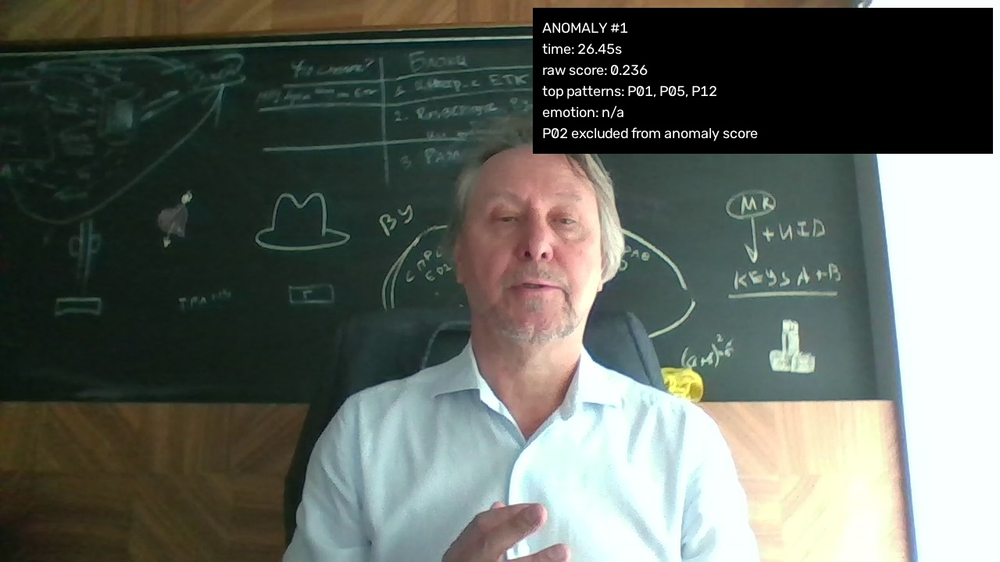

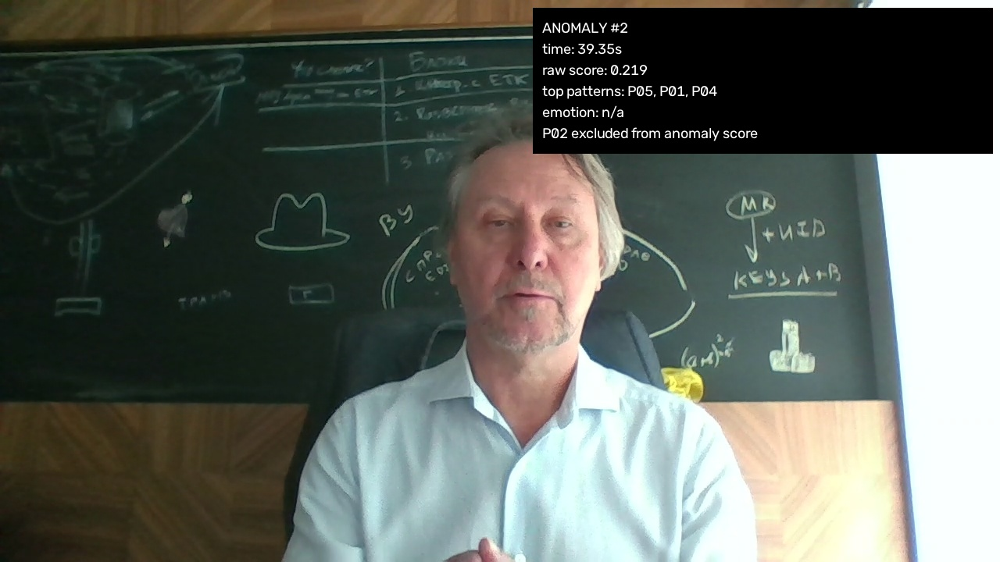

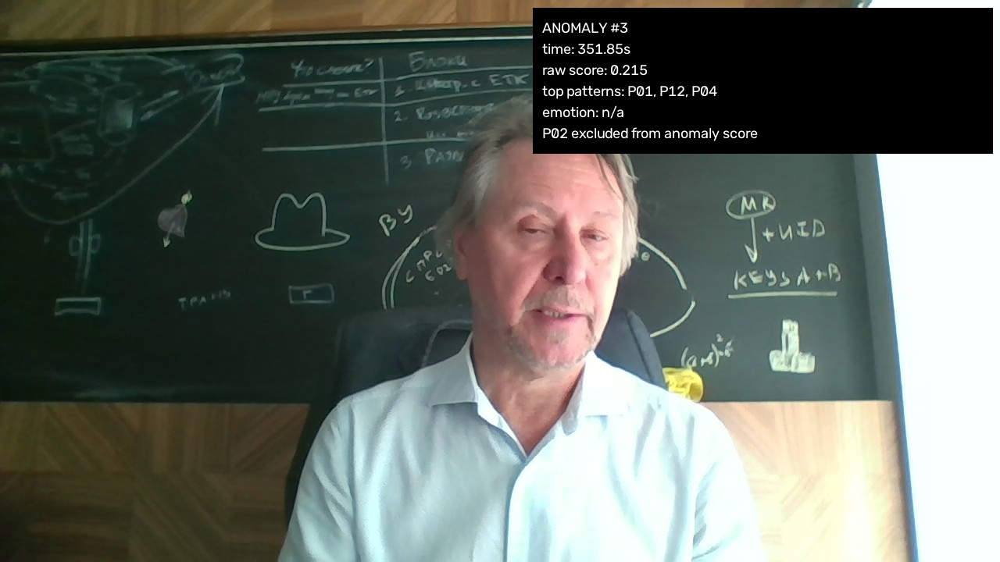


=== TOP 20260823.mp4 ===


,rank,peak_sec,start_sec,end_sec,raw_anomaly_score,top_patterns,frame_path
0,1,164.35,162.85,165.85,0.328277,"P03, P01, P05",/content/drive/MyDrive/Staz/behavior_deviation...
1,2,150.25,148.75,151.75,0.319822,"P03, P01, P11",/content/drive/MyDrive/Staz/behavior_deviation...
2,3,249.45,247.95,250.95,0.305029,"P05, P03, P01",/content/drive/MyDrive/Staz/behavior_deviation...


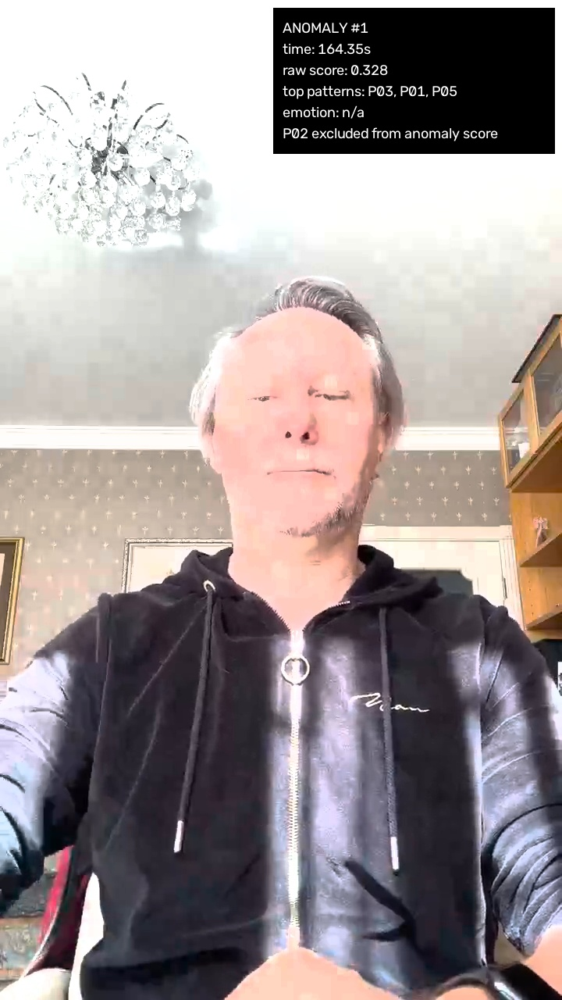

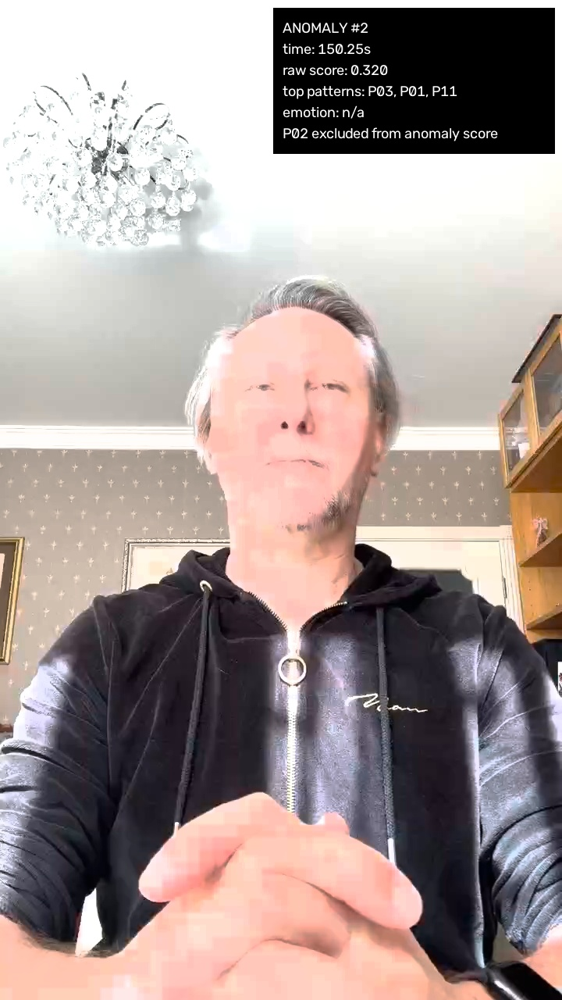

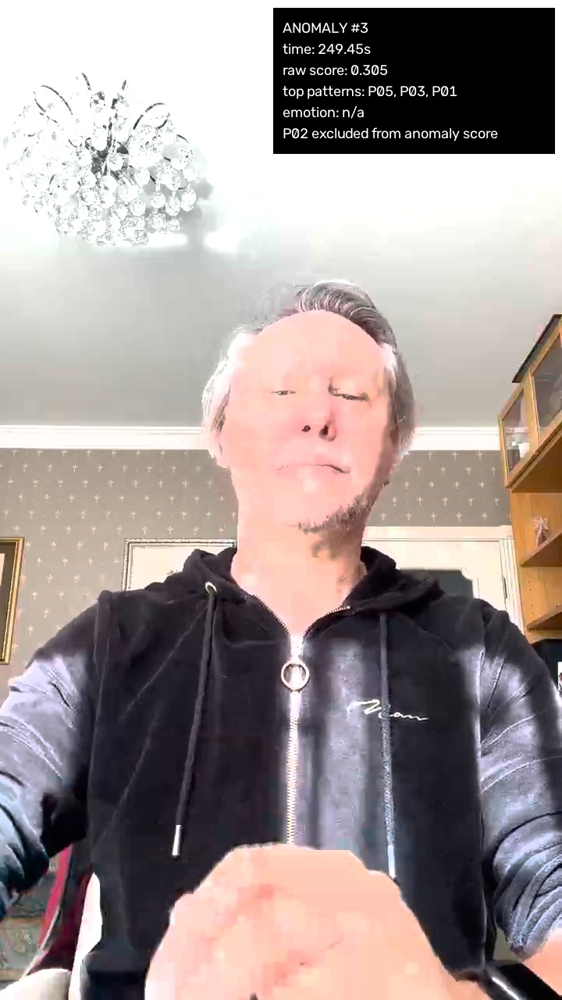


=== TOP 3.mp4 ===


,rank,peak_sec,start_sec,end_sec,raw_anomaly_score,top_patterns,frame_path
0,1,63.55,62.05,65.05,0.308089,"P08, P05, P11",/content/drive/MyDrive/Staz/behavior_deviation...
1,2,54.95,53.45,56.45,0.229730,"P10, P11, P05",/content/drive/MyDrive/Staz/behavior_deviation...
2,3,30.85,29.35,32.35,0.221337,"P10, P05, P12",/content/drive/MyDrive/Staz/behavior_deviation...


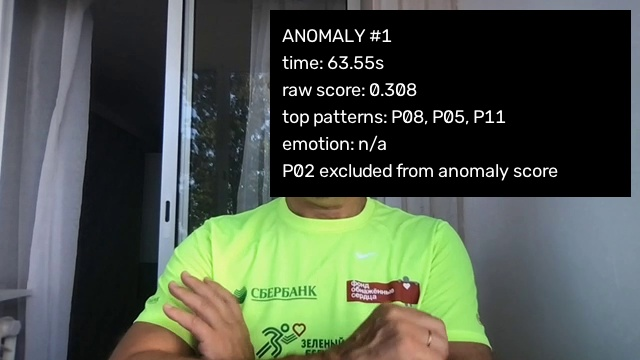

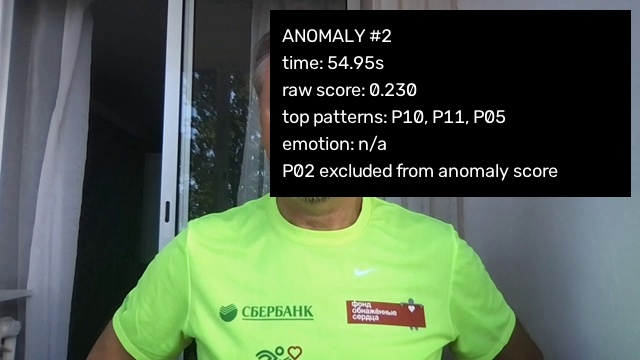

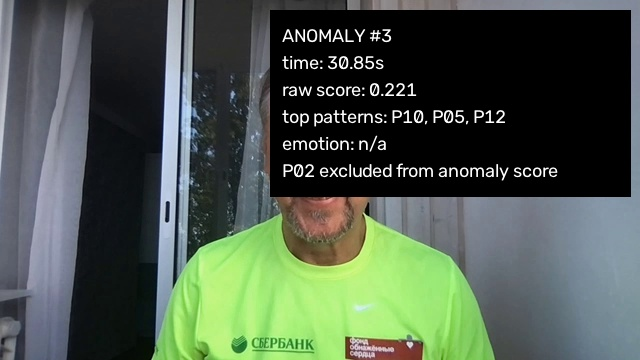

In [ ]:
# ЯЧЕЙКА 11
def select_top_windows(scored, top_n=TOP_N, min_separation=TOP_MIN_SEPARATION_SEC):
    valid = scored.dropna(subset=["raw_anomaly_score"]).sort_values("raw_anomaly_score", ascending=False)
    chosen = []
    for _, row in valid.iterrows():
        t = float(row["timestamp"])
        if any(abs(t - x["peak_sec"]) < min_separation for x in chosen):
            continue
        chosen.append({
            "rank": len(chosen) + 1,
            "peak_sec": t,
            "start_sec": max(0.0, t - TOP_SEGMENT_SEC / 2),
            "end_sec": t + TOP_SEGMENT_SEC / 2,
            "raw_anomaly_score": float(row["raw_anomaly_score"]),
            "top_patterns": row.get("top_patterns", ""),
        })
        if len(chosen) >= top_n:
            break
    return pd.DataFrame(chosen)

def render_top_frame(video_name, peak_sec, score_value, top_patterns, rank, emotion_context="n/a"):
    raw, fps = RAW_BY_VIDEO[video_name]
    cap = cv2.VideoCapture(str(VIDEO_PATHS[video_name]))
    cap.set(cv2.CAP_PROP_POS_MSEC, float(peak_sec) * 1000.0)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        return None

    overlay = frame.copy()
    h, w = overlay.shape[:2]
    lines = [
        f"ANOMALY #{rank}",
        f"time: {peak_sec:.2f}s",
        f"raw score: {score_value:.3f}",
        f"top patterns: {top_patterns or 'n/a'}",
        f"emotion: {emotion_context or 'n/a'}",
        "P02 excluded from anomaly score",
    ]
    line_h = 27
    pad = 12
    box_w = min(w - 20, max(360, int(w * 0.46)))
    box_h = pad * 2 + line_h * len(lines)
    x0 = w - box_w - 10
    y0 = 10
    cv2.rectangle(overlay, (x0, y0), (w - 10, y0 + box_h), (0, 0, 0), -1)
    for i, text in enumerate(lines):
        y = y0 + pad + (i + 1) * line_h - 7
        cv2.putText(overlay, text, (x0 + pad, y), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255,255,255), 1, cv2.LINE_AA)

    out_dir = WORK_DIR / "top_frames" / Path(video_name).stem
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"top_{rank}_{peak_sec:.2f}s.jpg"
    cv2.imwrite(str(out_path), overlay)
    return out_path

TOP_RESULTS = {}
for video_name, scored in SCORING_RESULTS.items():
    top = select_top_windows(scored)
    paths = []
    for _, row in top.iterrows():
        p = render_top_frame(
            video_name,
            row["peak_sec"],
            row["raw_anomaly_score"],
            row["top_patterns"],
            int(row["rank"]),
        )
        paths.append(str(p) if p else "")
    top = top.copy()
    top["frame_path"] = paths
    TOP_RESULTS[video_name] = top
    stem = Path(video_name).stem
    top.to_csv(WORK_DIR / f"{stem}_top3.csv", index=False, encoding="utf-8-sig")
    print(f"\n=== TOP {video_name} ===")
    display(top)
    for p in paths:
        if p:
            display(IPImage(filename=p))

save_progress(11)


In [ ]:
# ЯЧЕЙКА 12
# Emotion profiles are learned only from the manually labeled 3.mp4.
EMOTION_PROFILE_FEATURES = [f"score_{p}" for p in ACTIVE_PATTERNS]
EMOTION_WINDOWS = SCORING_RESULTS["3.mp4"].copy()
EMOTION_WINDOWS["emotion_manual"] = EMOTION_WINDOWS["emotion_manual"].astype(str)

labeled = EMOTION_WINDOWS[EMOTION_WINDOWS["emotion_manual"] != "Unlabeled"].copy()
if labeled.empty:
    raise RuntimeError("В 3.mp4 не найдено ни одного окна внутри ручной emotional-разметки.")

emotion_rows = []
for emotion, group in labeled.groupby("emotion_manual", sort=False):
    row = {"emotion": emotion, "n_windows": len(group)}
    for p in NUMERIC_PATTERNS:
        row[p] = pd.to_numeric(group[p], errors="coerce").median()
    for direction in ["center","down","left","right","up"]:
        row[f"P12_{direction}"] = float((group["P12"] == direction).mean())
    emotion_rows.append(row)

EMOTION_PROFILES = pd.DataFrame(emotion_rows)
EMOTION_PROFILES.to_csv(WORK_DIR / "emotion_profiles_3.csv", index=False, encoding="utf-8-sig")
print("Emotion profiles:", len(EMOTION_PROFILES))
display(EMOTION_PROFILES)
save_progress(12)


Emotion profiles: 14


,emotion,n_windows,P01,P03,P04,P05,P06,P07,P08,P09,P10,P11,P12_center,P12_down,P12_left,P12_right,P12_up
0,Surprise,15,0.0,11.965251,120.0,0.009089,0.0,0.0,0.0,0.0,0.0,120.0,0.800000,0.000000,0.200000,0.0,0.0
1,Embarrassment,16,0.0,12.114278,60.0,0.001556,0.0,0.0,0.0,0.0,0.0,120.0,1.000000,0.000000,0.000000,0.0,0.0
2,Interest,23,0.0,17.168633,360.0,0.150710,0.0,0.0,0.0,0.0,120.0,0.0,0.565217,0.000000,0.434783,0.0,0.0
3,Joy / laughter,9,0.0,11.811563,360.0,0.221873,0.0,0.0,0.0,0.0,0.0,120.0,1.000000,0.000000,0.000000,0.0,0.0
4,Distress / sadness,19,0.0,12.094883,120.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0
5,Fear,22,60.0,14.819839,300.0,0.053423,0.0,0.0,0.0,0.0,0.0,120.0,0.818182,0.000000,0.181818,0.0,0.0
6,Strong fright,28,0.0,15.972575,240.0,0.017059,0.0,0.0,0.0,0.0,0.0,120.0,0.642857,0.000000,0.357143,0.0,0.0
7,Anger / irritation,28,0.0,11.741543,240.0,0.006631,0.0,0.0,0.0,0.0,0.0,120.0,0.535714,0.000000,0.464286,0.0,0.0
8,Indignation,26,0.0,12.850793,360.0,0.020920,0.0,0.0,0.0,0.0,0.0,180.0,0.307692,0.000000,0.692308,0.0,0.0
9,Tenderness,24,0.0,15.405967,360.0,0.047444,0.0,0.0,0.0,0.0,120.0,360.0,0.583333,0.083333,0.333333,0.0,0.0


In [ ]:
# ЯЧЕЙКА 13
def emotion_distance(row, profile_row):
    parts = []
    for p in NUMERIC_PATTERNS:
        x = pd.to_numeric(row[p], errors="coerce")
        y = pd.to_numeric(profile_row[p], errors="coerce")
        if np.isfinite(x) and np.isfinite(y):
            parts.append(float(abs(x - y)))
    current_dir = str(row.get("P12", "center"))
    pdir = float(profile_row.get(f"P12_{current_dir}", 0.0))
    parts.append(float(1.0 - pdir))
    return float(np.mean(parts)) if parts else np.inf

def predict_emotion_context(windows):
    out = windows.copy()
    labels, distances = [], []
    for _, row in out.iterrows():
        best_label, best_dist = "Unknown", np.inf
        for _, prof in EMOTION_PROFILES.iterrows():
            d = emotion_distance(row, prof)
            if d < best_dist:
                best_dist = d
                best_label = str(prof["emotion"])
        labels.append(best_label)
        distances.append(best_dist)
    out["emotion_context"] = labels
    out["emotion_distance"] = distances
    return out

for video_name in BASELINE_VIDEOS:
    scored = SCORING_RESULTS[video_name]
    contexted = predict_emotion_context(scored)
    if video_name == "3.mp4":
        contexted["emotion_context"] = contexted["emotion_manual"]
    SCORING_RESULTS[video_name] = contexted

# Add emotion context to the already selected top windows.
for video_name, top in TOP_RESULTS.items():
    scored = SCORING_RESULTS[video_name]
    if top.empty:
        continue
    context_labels = []
    for _, row in top.iterrows():
        near = scored.iloc[(scored["timestamp"] - row["peak_sec"]).abs().argsort()[:1]]
        context_labels.append(str(near.iloc[0].get("emotion_context", "Unknown")))
    top = top.copy()
    top["emotion_context"] = context_labels
    # Re-render with the now-available emotional context in the overlay.
    frame_paths = []
    for _, row in top.iterrows():
        p = render_top_frame(
            video_name,
            row["peak_sec"],
            row["raw_anomaly_score"],
            row["top_patterns"],
            int(row["rank"]),
            emotion_context=row["emotion_context"],
        )
        frame_paths.append(str(p) if p else "")
    top["frame_path"] = frame_paths
    TOP_RESULTS[video_name] = top
    top.to_csv(WORK_DIR / f"{Path(video_name).stem}_top3.csv", index=False, encoding="utf-8-sig")

print("Emotion context added after raw anomaly calculation.")
save_progress(13)


Emotion context added after raw anomaly calculation.


In [ ]:
# ЯЧЕЙКА 14
# BIG5_LABELS.csv — таблица соответствия поведенческих паттернов и Big Five.
# Это НЕ числовые оценки Big Five конкретных людей.
# Здесь читаем таблицу соответствий и строим на её основе Big Five context
# для уже вычисленных P01–P12.

BIG5_COLUMNS = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

# В файле:
# строка 1 — "Таблица 1"
# строка 2 — пустая
# строка 3 — настоящий заголовок
big5_table = pd.read_csv(
    BIG5_LABELS_PATH,
    sep=";",
    skiprows=2,
    encoding="utf-8-sig"
)

# Убираем полностью пустые / служебные столбцы
big5_table = big5_table.loc[
    :,
    ~big5_table.columns.astype(str).str.match(r"^Unnamed", case=False)
].copy()

# Нормализуем названия колонок
big5_table.columns = (
    big5_table.columns
    .astype(str)
    .str.strip()
)

required_columns = [
    "№",
    "Модальность",
    "Извлекаемый паттерн",
    "Как измерять технически",
    "Предполагаемая связь с Big Five",
    "Надёжность",
    "Комментарий",
]

missing = [
    c for c in required_columns
    if c not in big5_table.columns
]

if missing:
    raise ValueError(
        "BIG5_LABELS.csv прочитан, но отсутствуют колонки: "
        + ", ".join(missing)
    )

# Удаляем пустые строки
big5_table = big5_table.dropna(
    how="all",
    subset=["№", "Извлекаемый паттерн"]
).reset_index(drop=True)

print("BIG5 таблица загружена:", big5_table.shape)
display(big5_table)

# ------------------------------------------------------------
# Связь НАШИХ P01–P12 с Big Five.
#
# Здесь используем только те связи, которые мы ранее определили
# как допустимые для нашего поведенческого контекста.
#
# Это НЕ является психометрическим измерением Big Five.
# Это контекстуальные behavioral indicators.
# ------------------------------------------------------------

BIG5_PATTERN_MAP = {
    "Extraversion": ["P03", "P04", "P05"],
    "Agreeableness": ["P03", "P10"],
    "Conscientiousness": [],
    "Neuroticism": ["P01", "P06", "P07", "P11"],
    "Openness": ["P03"],
}

BIG5_DESCRIPTIONS = {
    "Extraversion":
        "движения головы и жестовая/двигательная экспрессия",
    "Agreeableness":
        "положительная мимическая реакция и социальная экспрессия",
    "Conscientiousness":
        "прямой валидированный индикатор среди P01–P12 пока не задан",
    "Neuroticism":
        "моргание, рука около лица, повторные микродвижения, напряжение губ/бровей",
    "Openness":
        "двигательная вариативность головы",
}

# Проверяем, что ни один P-код не потерялся в структуре
ALL_P = [f"P{i:02d}" for i in range(1, 13)]

print("\n=== BIG FIVE BEHAVIORAL CONTEXT ===")
for factor in BIG5_COLUMNS:
    patterns = BIG5_PATTERN_MAP[factor]
    print(
        f"{factor}: "
        + (", ".join(patterns) if patterns else "нет прямого индикатора")
    )

print("\nВАЖНО:")
print("Big Five здесь используется как контекст интерпретации поведения.")
print("Числовые психометрические оценки Big Five из этого CSV НЕ вычисляются.")
print("P12 остаётся описательным показателем взгляда и напрямую в Big Five не включён.")

BIG5 таблица загружена: (19, 7)


,№,Модальность,Извлекаемый паттерн,Как измерять технически,Предполагаемая связь с Big Five,Надёжность,Комментарий
0,1,Лицо,Общая мимическая активность,Средняя частота изменений AU / facial landmark...,+ Extraversion,Средняя/высокая,Экстраверсия чаще проявляется через внешнюю эк...
1,2,Лицо,Интенсивность улыбки,"AU12 + AU6, средняя интенсивность и частота","+ Extraversion, + Agreeableness, - Neuroticism",Средняя,"Улыбка может быть социальной маской, поэтому н..."
2,3,Лицо,Частота позитивных выражений,"AU6, AU12, AU25, общий positive affect score","+ Extraversion, + Agreeableness",Средняя,"Лучше работает в живом взаимодействии, чем в о..."
3,4,Лицо,Частота негативных выражений,"AU4, AU7, AU9, AU10, AU15, AU17, AU23/24","+ Neuroticism, - Agreeableness",Средняя,"Может отражать стресс задачи, а не черту лично..."
4,5,Лицо,Напряжение губ,"AU23/AU24, длительность сжатия губ","+ Neuroticism, + контроль/сдерживание",Низкая/средняя,Нельзя трактовать отдельно; только вместе с го...
5,6,Лицо,Поднятие бровей,"AU1/AU2, частота и амплитуда","+ Extraversion, + Openness",Низкая/средняя,"Может быть маркером живости, удивления, вовлеч..."
6,7,Лицо,Моргание,Blink rate / AU45,+ Neuroticism / arousal,Средняя,В модели Saberi et al. частые blink/twitch/scr...
7,8,Взгляд,Длительность взгляда в камеру / на собеседника,"Gaze-to-camera ratio, mutual gaze duration","+ Extraversion, + Agreeableness",Средняя/высокая,В исследованиях экстравертность связывали с бо...
8,9,Взгляд,Частое отведение взгляда,Averted gaze ratio,"- Extraversion, + Neuroticism/processing",Средняя,"Может быть интроверсией, тревогой или просто м..."
9,10,Голова,Скорость движений головы,Head pose velocity,+ Extraversion,Средняя,Быстрые движения головы входят в поведенческий...



=== BIG FIVE BEHAVIORAL CONTEXT ===
Extraversion: P03, P04, P05
Agreeableness: P03, P10
Conscientiousness: нет прямого индикатора
Neuroticism: P01, P06, P07, P11
Openness: P03

ВАЖНО:
Big Five здесь используется как контекст интерпретации поведения.
Числовые психометрические оценки Big Five из этого CSV НЕ вычисляются.
P12 остаётся описательным показателем взгляда и напрямую в Big Five не включён.


In [ ]:
# ЯЧЕЙКА 15
# Профиль отклонений по P01–P12 и Big Five behavioral context.
#
# ВАЖНО:
# BIG5_LABELS.csv не содержит индивидуальных Big Five-оценок человека.
# Поэтому здесь НЕ создаём внешний Big Five score.
# Используем только таблицу соответствия паттернов из ЯЧЕЙКИ 14
# для контекстной интерпретации уже рассчитанных отклонений.

# ------------------------------------------------------------
# 1. Профиль отклонений каждого видео
# ------------------------------------------------------------

PROFILE_ROWS = []

for video_name, scored in SCORING_RESULTS.items():
    row = {"video": video_name}

    for p in ACTIVE_PATTERNS:
        col = f"score_{p}"

        if col not in scored.columns:
            continue

        s = pd.to_numeric(
            scored[col],
            errors="coerce"
        )

        valid = s.dropna()

        row[f"{p}_mean_deviation"] = (
            float(valid.mean()) if not valid.empty else np.nan
        )

        row[f"{p}_median_deviation"] = (
            float(valid.median()) if not valid.empty else np.nan
        )

        row[f"{p}_max_deviation"] = (
            float(valid.max()) if not valid.empty else np.nan
        )

        row[f"{p}_flag_share"] = (
            float((valid >= 0.50).mean()) if not valid.empty else np.nan
        )

    raw = pd.to_numeric(
        scored["raw_anomaly_score"],
        errors="coerce"
    ).dropna()

    row["raw_anomaly_mean"] = (
        float(raw.mean()) if not raw.empty else np.nan
    )

    row["raw_anomaly_median"] = (
        float(raw.median()) if not raw.empty else np.nan
    )

    row["raw_anomaly_max"] = (
        float(raw.max()) if not raw.empty else np.nan
    )

    row["n_valid_windows"] = int(raw.notna().sum())

    PROFILE_ROWS.append(row)

VIDEO_PROFILE = pd.DataFrame(PROFILE_ROWS)

VIDEO_PROFILE.to_csv(
    WORK_DIR / "video_profiles.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 2. Общий профиль человека
# ------------------------------------------------------------
# Несколько видео одного человека сначала объединяются
# на уровне person-level profile.
#
# Используем median по видео, чтобы более длинное видео
# автоматически не получало больший вес.

NUMERIC_PROFILE_COLUMNS = VIDEO_PROFILE.select_dtypes(
    include=[np.number]
).columns.tolist()

PERSON_PROFILE = (
    VIDEO_PROFILE[NUMERIC_PROFILE_COLUMNS]
    .median()
    .to_frame()
    .T
)

PERSON_PROFILE.insert(
    0,
    "person_id",
    PERSON_ID
)

PERSON_PROFILE.to_csv(
    WORK_DIR / "person_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 3. Big Five behavioral context
# ------------------------------------------------------------
#
# Здесь НЕ оцениваем Big Five человека.
#
# Мы только смотрим, какие Big Five-факторы связаны
# с наблюдавшимися отклонениями по соответствующим паттернам.

BIG5_CONTEXT_ROWS = []

for factor, mapping in BIG5_PATTERN_MAP.items():

    evidence_values = []
    used_patterns = []

    for p in mapping:

        col = f"{p}_mean_deviation"

        if col not in VIDEO_PROFILE.columns:
            continue

        values = pd.to_numeric(
            VIDEO_PROFILE[col],
            errors="coerce"
        ).dropna()

        if not values.empty:
            evidence_values.append(
                float(values.median())
            )
            used_patterns.append(p)

    evidence = (
        float(np.mean(evidence_values))
        if evidence_values
        else np.nan
    )

    BIG5_CONTEXT_ROWS.append({
        "person_id": PERSON_ID,
        "factor": factor,
        "behavioral_pattern_evidence": evidence,
        "mapped_patterns": (
            ", ".join(used_patterns)
            if used_patterns
            else "none / insufficient direct pattern mapping"
        ),
    })

BIG5_CONTEXT = pd.DataFrame(BIG5_CONTEXT_ROWS)

BIG5_CONTEXT.to_csv(
    WORK_DIR / "big5_behavioral_context.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 4. Вывод
# ------------------------------------------------------------

print("=== ПРОФИЛИ ОТКЛОНЕНИЙ ПО ВИДЕО ===")
display(VIDEO_PROFILE.round(4))

print("\n=== ОБЩИЙ ПРОФИЛЬ ЧЕЛОВЕКА ===")
display(PERSON_PROFILE.round(4))

print("\n=== BIG FIVE BEHAVIORAL CONTEXT ===")
display(BIG5_CONTEXT.round(4))

print("\nВАЖНО:")
print("Big Five здесь НЕ являются психометрическими оценками человека.")
print("Это контекстная связь между наблюдаемыми P01–P12 и факторами Big Five.")
print("P02 не используется в anomaly score.")
print("P12 остаётся описательным показателем взгляда.")

save_progress(15)

=== ПРОФИЛИ ОТКЛОНЕНИЙ ПО ВИДЕО ===


,video,P01_mean_deviation,P01_median_deviation,P01_max_deviation,P01_flag_share,P03_mean_deviation,P03_median_deviation,P03_max_deviation,P03_flag_share,P04_mean_deviation,...,P11_max_deviation,P11_flag_share,P12_mean_deviation,P12_median_deviation,P12_max_deviation,P12_flag_share,raw_anomaly_mean,raw_anomaly_median,raw_anomaly_max,n_valid_windows
0,WIN_20260817.mp4,0.3645,0.0,1.0000,0.3645,0.0504,0.0443,0.6818,0.0008,0.2415,...,0.4805,0.0000,0.0527,0.0186,0.5395,0.0003,0.0853,0.0547,0.2364,3695
1,20260823.mp4,0.0746,0.0,1.0000,0.0103,0.4225,0.3905,1.0000,0.3410,0.2345,...,1.0000,0.0970,0.0587,0.0146,0.3889,0.0000,0.1171,0.1110,0.3283,2525
2,3.mp4,0.0393,0.0,0.4569,0.0000,0.2080,0.2141,0.3122,0.0000,0.1236,...,0.8996,0.0819,0.0520,0.0153,0.2764,0.0000,0.0838,0.0709,0.3081,720



=== ОБЩИЙ ПРОФИЛЬ ЧЕЛОВЕКА ===


,person_id,P01_mean_deviation,P01_median_deviation,P01_max_deviation,P01_flag_share,P03_mean_deviation,P03_median_deviation,P03_max_deviation,P03_flag_share,P04_mean_deviation,...,P11_max_deviation,P11_flag_share,P12_mean_deviation,P12_median_deviation,P12_max_deviation,P12_flag_share,raw_anomaly_mean,raw_anomaly_median,raw_anomaly_max,n_valid_windows
0,me,0.0746,0.0,1.0,0.0103,0.208,0.2141,0.6818,0.0008,0.2345,...,0.8996,0.0819,0.0527,0.0153,0.3889,0.0,0.0853,0.0709,0.3081,2525.0



=== BIG FIVE BEHAVIORAL CONTEXT ===


,person_id,factor,behavioral_pattern_evidence,mapped_patterns
0,me,Extraversion,0.2056,"P03, P04, P05"
1,me,Agreeableness,0.1040,"P03, P10"
2,me,Conscientiousness,NaN,none / insufficient direct pattern mapping
3,me,Neuroticism,0.0700,"P01, P06, P07, P11"
4,me,Openness,0.2080,P03



ВАЖНО:
Big Five здесь НЕ являются психометрическими оценками человека.
Это контекстная связь между наблюдаемыми P01–P12 и факторами Big Five.
P02 не используется в anomaly score.
P12 остаётся описательным показателем взгляда.


In [ ]:
# ЯЧЕЙКА 16
# Detailed top-pattern profile for each video and compact summary of the highest deviations.
TOP_PATTERN_ROWS = []
for video_name, scored in SCORING_RESULTS.items():
    for p in ACTIVE_PATTERNS:
        col = f"score_{p}"
        vals = pd.to_numeric(scored[col], errors="coerce")
        TOP_PATTERN_ROWS.append({
            "video": video_name,
            "pattern": p,
            "mean_score": float(vals.mean()) if vals.notna().any() else np.nan,
            "max_score": float(vals.max()) if vals.notna().any() else np.nan,
            "share_high": float((vals >= 0.50).mean()) if vals.notna().any() else np.nan,
        })

PATTERN_PROFILE = pd.DataFrame(TOP_PATTERN_ROWS)
PATTERN_PROFILE.to_csv(WORK_DIR / "pattern_deviation_profile.csv", index=False, encoding="utf-8-sig")

SUMMARY_ROWS = []
for video_name, top in TOP_RESULTS.items():
    if top.empty:
        continue
    row = top.sort_values("raw_anomaly_score", ascending=False).iloc[0].to_dict()
    row["video"] = video_name
    SUMMARY_ROWS.append(row)
SUMMARY = pd.DataFrame(SUMMARY_ROWS)
SUMMARY.to_csv(WORK_DIR / "top_anomalies_summary.csv", index=False, encoding="utf-8-sig")

print("Files written to:", WORK_DIR)
display(SUMMARY)
save_progress(16)


Files written to: /content/drive/MyDrive/Staz/behavior_deviation_v51


,rank,peak_sec,start_sec,end_sec,raw_anomaly_score,top_patterns,frame_path,emotion_context,video
0,1,26.45,24.95,27.95,0.236364,"P01, P05, P12",/content/drive/MyDrive/Staz/behavior_deviation...,Distress / sadness,WIN_20260817.mp4
1,1,164.35,162.85,165.85,0.328277,"P03, P01, P05",/content/drive/MyDrive/Staz/behavior_deviation...,Neutral / ending,20260823.mp4
2,1,63.55,62.05,65.05,0.308089,"P08, P05, P11",/content/drive/MyDrive/Staz/behavior_deviation...,Serious strict look,3.mp4


In [ ]:
# ЯЧЕЙКА 17
# ДОБАВЛЕНИЕ НОВЫХ ВИДЕО ПОЗЖЕ
#
# Для нового видео достаточно добавить имя в ADDITIONAL_VIDEOS.
# Оно будет проверено относительно уже построенного person-level baseline
# из текущих трёх видео. Новое видео НЕ изменяет baseline автоматически.
#
# Пример:
# ADDITIONAL_VIDEOS = ["new_video.mp4"]

ADDITIONAL_VIDEOS = []

def build_person_reference_all_three():
    ref = balanced_concat(BASELINE_VIDEOS)
    med, scale = robust_center_scale(ref, NUMERIC_PATTERNS)
    probs = {d: float((ref["P12"] == d).sum() + 1.0) / float(len(ref) + 5.0)
             for d in ["center","down","left","right","up"]}
    return {
        "videos": list(BASELINE_VIDEOS),
        "windows": len(ref),
        "numeric_median": med,
        "numeric_scale": scale,
        "p12_probability": probs,
    }

def score_new_video(video_name, save_frames=True):
    if video_name not in ADDITIONAL_VIDEOS:
        raise ValueError("Сначала добавьте имя файла в ADDITIONAL_VIDEOS.")
    path = STAZ_FOLDER / video_name
    if not path.exists():
        raise FileNotFoundError(path)
    VIDEO_PATHS[video_name] = path
    raw, fps = extract_video(video_name)
    RAW_BY_VIDEO[video_name] = (raw, fps)
    windows = prepare_features(build_window_dataset(raw, fps))
    windows["video"] = video_name
    ref = build_person_reference_all_three()
    scored = score_against_reference(windows, ref)
    scored = predict_emotion_context(scored)
    top = select_top_windows(scored)
    if save_frames:
        frame_paths = []
        for _, row in top.iterrows():
            p = render_top_frame(video_name, row["peak_sec"], row["raw_anomaly_score"], row["top_patterns"], int(row["rank"]))
            frame_paths.append(str(p) if p else "")
        top = top.copy()
        top["frame_path"] = frame_paths
    scored.to_csv(WORK_DIR / f"{Path(video_name).stem}_new_scored.csv", index=False, encoding="utf-8-sig")
    top.to_csv(WORK_DIR / f"{Path(video_name).stem}_new_top3.csv", index=False, encoding="utf-8-sig")
    display(top)
    return scored, top

print("Готово. Оставьте ADDITIONAL_VIDEOS=[] на текущем запуске; позже добавляйте файлы сюда.")
save_progress(17)


Готово. Оставьте ADDITIONAL_VIDEOS=[] на текущем запуске; позже добавляйте файлы сюда.


In [ ]:
# ЯЧЕЙКА 18
# Финальный person-level reference по всем трём видео.
# Каждое видео имеет одинаковый вес.
# Этот reference пока персональный: он нужен для текущего этапа
# и позже станет базой для сравнения новых видео.

def build_frozen_person_reference():
    ref = balanced_concat(BASELINE_VIDEOS)

    med, scale = robust_center_scale(
        ref,
        NUMERIC_PATTERNS
    )

    directions = ["center", "down", "left", "right", "up"]

    p12_probability = {
        d: float(
            (ref["P12"] == d).sum() + 1.0
        ) / float(
            len(ref) + len(directions)
        )
        for d in directions
    }

    return {
        "person_id": PERSON_ID,
        "videos": list(BASELINE_VIDEOS),
        "windows": int(len(ref)),
        "numeric_median": med,
        "numeric_scale": scale,
        "p12_probability": p12_probability,
        "active_patterns": list(ACTIVE_PATTERNS),
        "window_sec": WINDOW_SEC,
        "step_sec": STEP_SEC,
    }


PERSON_REFERENCE = build_frozen_person_reference()


# ------------------------------------------------------------
# Внутриперсональная LOO-калибровка.
#
# В ЯЧЕЙКЕ 10 каждое из трёх видео уже оценивалось
# относительно ДВУХ других видео.
#
# Поэтому здесь используем эти независимые для каждого ролика
# LOO anomaly scores для оценки естественного диапазона.
# ------------------------------------------------------------

LOO_ROWS = []

for video_name, scored in SCORING_RESULTS.items():

    vals = pd.to_numeric(
        scored["raw_anomaly_score"],
        errors="coerce"
    ).dropna()

    for value in vals:
        LOO_ROWS.append({
            "video": video_name,
            "raw_anomaly_score": float(value),
        })


LOO_SCORES = pd.DataFrame(LOO_ROWS)

if LOO_SCORES.empty:
    raise RuntimeError(
        "Не удалось получить LOO anomaly scores."
    )


PERSON_LOO_Q95 = float(
    LOO_SCORES["raw_anomaly_score"].quantile(0.95)
)

PERSON_LOO_Q99 = float(
    LOO_SCORES["raw_anomaly_score"].quantile(0.99)
)


print("=== FROZEN PERSON BASELINE ===")
print(
    "Видео:",
    ", ".join(PERSON_REFERENCE["videos"])
)
print(
    "Reference windows:",
    PERSON_REFERENCE["windows"]
)
print(
    f"LOO q95 = {PERSON_LOO_Q95:.4f}"
)
print(
    f"LOO q99 = {PERSON_LOO_Q99:.4f}"
)

print()
print(
    "Эти q95/q99 описывают внутренний диапазон "
    "отклонений текущего человека."
)
print(
    "Они НЕ являются universal thresholds."
)


calibration = pd.DataFrame([{
    "person_id": PERSON_ID,
    "loo_q95": PERSON_LOO_Q95,
    "loo_q99": PERSON_LOO_Q99,
    "baseline_videos": ", ".join(BASELINE_VIDEOS),
}])

calibration.to_csv(
    WORK_DIR / "person_internal_calibration.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Сохранено:",
    WORK_DIR / "person_internal_calibration.csv"
)

save_progress(18)

=== FROZEN PERSON BASELINE ===
Видео: WIN_20260817.mp4, 20260823.mp4, 3.mp4
Reference windows: 2720
LOO q95 = 0.1786
LOO q99 = 0.2157

Эти q95/q99 описывают внутренний диапазон отклонений текущего человека.
Они НЕ являются universal thresholds.
Сохранено: /content/drive/MyDrive/Staz/behavior_deviation_v51/person_internal_calibration.csv


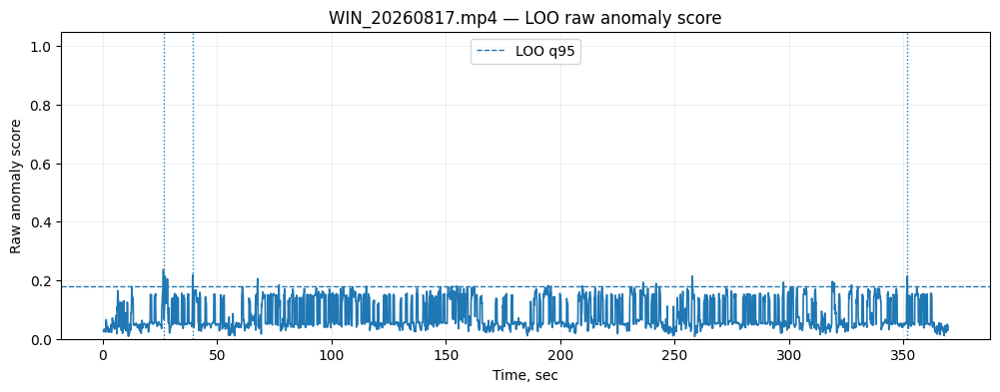

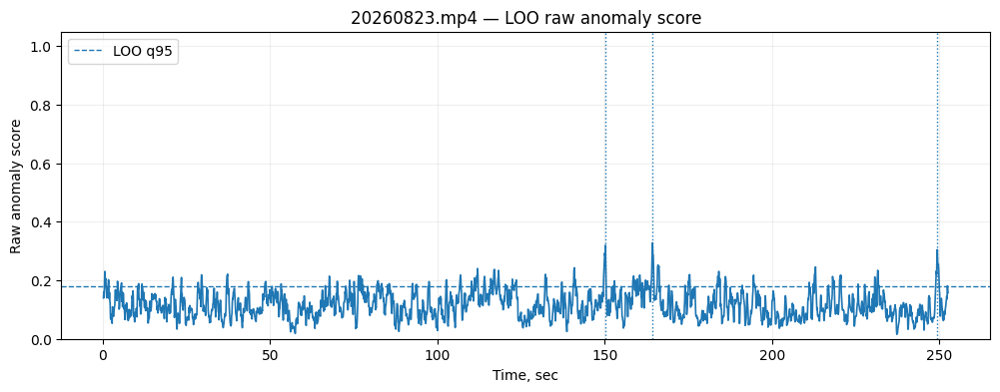

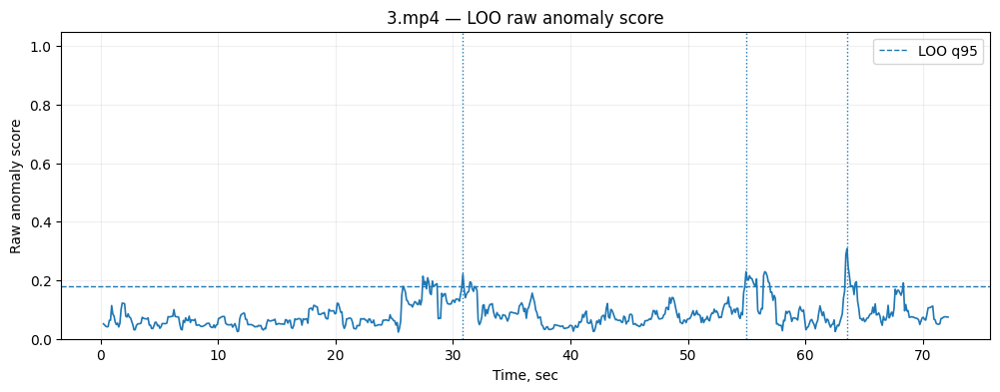

=== TOP ANOMALOUS WINDOWS ===

WIN_20260817.mp4


,rank,peak_sec,raw_anomaly_score,top_patterns,emotion_context,frame_path
0,1,26.45,0.2364,"P01, P05, P12",Distress / sadness,/content/drive/MyDrive/Staz/behavior_deviation...
1,2,39.35,0.2194,"P05, P01, P04",Distress / sadness,/content/drive/MyDrive/Staz/behavior_deviation...
2,3,351.85,0.2149,"P01, P12, P04",Distress / sadness,/content/drive/MyDrive/Staz/behavior_deviation...



20260823.mp4


,rank,peak_sec,raw_anomaly_score,top_patterns,emotion_context,frame_path
0,1,164.35,0.3283,"P03, P01, P05",Neutral / ending,/content/drive/MyDrive/Staz/behavior_deviation...
1,2,150.25,0.3198,"P03, P01, P11",Playfulness / flirtation,/content/drive/MyDrive/Staz/behavior_deviation...
2,3,249.45,0.3050,"P05, P03, P01",Neutral / ending,/content/drive/MyDrive/Staz/behavior_deviation...



3.mp4


,rank,peak_sec,raw_anomaly_score,top_patterns,emotion_context,frame_path
0,1,63.55,0.3081,"P08, P05, P11",Serious strict look,/content/drive/MyDrive/Staz/behavior_deviation...
1,2,54.95,0.2297,"P10, P11, P05",Tenderness,/content/drive/MyDrive/Staz/behavior_deviation...
2,3,30.85,0.2213,"P10, P05, P12",Interest,/content/drive/MyDrive/Staz/behavior_deviation...


In [ ]:
# ЯЧЕЙКА 19
# Временные графики anomaly score.
#
# Каждое видео показывает свой LOO-score:
# оно сравнивалось с двумя другими видео этого же человека.
#
# Пунктиром показывается общий внутренний q95.

for video_name in BASELINE_VIDEOS:

    scored = SCORING_RESULTS[video_name].copy()

    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    ax.plot(
        scored["timestamp"],
        scored["raw_anomaly_score"],
        linewidth=1.2
    )

    ax.axhline(
        PERSON_LOO_Q95,
        linestyle="--",
        linewidth=1.0,
        label="LOO q95"
    )

    top = TOP_RESULTS.get(
        video_name,
        pd.DataFrame()
    )

    if not top.empty:
        for _, row in top.iterrows():
            ax.axvline(
                float(row["peak_sec"]),
                linestyle=":",
                linewidth=1.0
            )

    ax.set_title(
        f"{video_name} — LOO raw anomaly score"
    )

    ax.set_xlabel("Time, sec")
    ax.set_ylabel("Raw anomaly score")
    ax.set_ylim(0, 1.05)

    ax.grid(alpha=0.2)
    ax.legend()

    plt.show()


print("=== TOP ANOMALOUS WINDOWS ===")

for video_name, top in TOP_RESULTS.items():

    print(f"\n{video_name}")

    if top.empty:
        print("Нет валидных top windows.")
        continue

    cols = [
        "rank",
        "peak_sec",
        "raw_anomaly_score",
        "top_patterns",
        "emotion_context",
        "frame_path",
    ]

    cols = [
        c for c in cols
        if c in top.columns
    ]

    display(
        top[cols].round(4)
    )

save_progress(19)

In [ ]:
# ЯЧЕЙКА 20
# Сохранение замороженного person-level baseline.
#
# Этот файл понадобится позднее для анализа новых видео.
# Новое видео НЕ добавляется в baseline автоматически.

MODEL_STATE = {
    "version": "v51_person_v2",
    "person_id": PERSON_ID,

    "baseline_videos": list(
        BASELINE_VIDEOS
    ),

    "active_patterns": list(
        ACTIVE_PATTERNS
    ),

    "numeric_patterns": list(
        NUMERIC_PATTERNS
    ),

    "person_reference": PERSON_REFERENCE,

    "loo_q95": PERSON_LOO_Q95,
    "loo_q99": PERSON_LOO_Q99,

    # Эмоциональные профили из размеченного видео.
    "emotion_profiles": EMOTION_PROFILES,

    # Реальная таблица соответствия P01–P12 → Big Five
    # из BIG5_LABELS.csv.
    "big5_table": big5_table,

    "big5_pattern_map": BIG5_PATTERN_MAP,

    "settings": {
        "window_sec": WINDOW_SEC,
        "step_sec": STEP_SEC,
        "anomaly_cap_z": ANOMALY_CAP_Z,
    },
}


MODEL_PATH = (
    WORK_DIR /
    "person_baseline_v51.pkl"
)

pd.to_pickle(
    MODEL_STATE,
    MODEL_PATH
)

print(
    "Frozen baseline saved:",
    MODEL_PATH
)

print(
    "Новое видео не изменяет baseline автоматически."
)

save_progress(20)

Frozen baseline saved: /content/drive/MyDrive/Staz/behavior_deviation_v51/person_baseline_v51.pkl
Новое видео не изменяет baseline автоматически.


In [ ]:
# ЯЧЕЙКА 21
# Универсальный вход для следующего видео.
#
# Сейчас список пустой.
# Позже достаточно написать, например:
#
# ADDITIONAL_VIDEOS = ["new_video.mp4"]
#
# и выполнить:
#
# new_scored, new_top = run_additional_video("new_video.mp4")
#
# Новый ролик сравнивается с FROZEN baseline.
# В baseline он автоматически не добавляется.

ADDITIONAL_VIDEOS = []


def run_additional_video(
    video_name,
    render_frames=True
):
    """
    Анализирует новое видео
    относительно frozen person baseline.
    """

    if video_name not in ADDITIONAL_VIDEOS:
        raise ValueError(
            "Добавьте имя файла в ADDITIONAL_VIDEOS."
        )

    path = STAZ_FOLDER / video_name

    if not path.exists():
        raise FileNotFoundError(
            f"Не найдено видео: {path}"
        )

    VIDEO_PATHS[video_name] = path

    raw, fps = extract_video(
        video_name
    )

    RAW_BY_VIDEO[video_name] = (
        raw,
        fps
    )

    windows = build_window_dataset(
        raw,
        fps
    )

    windows = prepare_features(
        windows
    )

    windows["video"] = video_name

    # Главное сравнение:
    # новое видео ↔ frozen baseline текущего человека.
    scored = score_against_reference(
        windows,
        PERSON_REFERENCE
    )

    # Emotion context добавляется ПОСЛЕ raw anomaly.
    scored = predict_emotion_context(
        scored
    )

    # Внутренний q95 используется только
    # как описательный ориентир для текущего человека.
    scored["within_person_q95_exceed"] = (
        scored["raw_anomaly_score"]
        >= PERSON_LOO_Q95
    )

    # TOP-1 ... TOP-3
    top = select_top_windows(
        scored
    )

    # Реальные кадры
    if render_frames and not top.empty:

        frame_paths = []

        for _, row in top.iterrows():

            p = render_top_frame(
                video_name,
                row["peak_sec"],
                row["raw_anomaly_score"],
                row["top_patterns"],
                int(row["rank"]),
                emotion_context="unknown / inferred",
            )

            frame_paths.append(
                str(p)
                if p is not None
                else ""
            )

        top = top.copy()
        top["frame_path"] = frame_paths


    stem = Path(
        video_name
    ).stem

    scored.to_csv(
        WORK_DIR /
        f"{stem}_new_scored.csv",
        index=False,
        encoding="utf-8-sig",
    )

    top.to_csv(
        WORK_DIR /
        f"{stem}_new_top3.csv",
        index=False,
        encoding="utf-8-sig",
    )


    print("=== NEW VIDEO ===")
    print(
        "Video:",
        video_name
    )

    print(
        "Frames:",
        len(raw)
    )

    print(
        "FPS:",
        fps
    )

    print(
        "Valid windows:",
        int(
            scored[
                "raw_anomaly_score"
            ].notna().sum()
        )
    )

    print(
        f"Frozen within-person q95: "
        f"{PERSON_LOO_Q95:.4f}"
    )

    print()
    print(
        "TOP ANOMALIES:"
    )

    display(top)

    return scored, top


print(
    "Готово."
)

print(
    "Сейчас ADDITIONAL_VIDEOS=[]"
)

print(
    "Ничего нового не запускается."
)

save_progress(21)

Готово.
Сейчас ADDITIONAL_VIDEOS=[]
Ничего нового не запускается.


In [ ]:
# ЯЧЕЙКА 22
# Финальный QA текущего person-level этапа.

assert set(BASELINE_VIDEOS) == {
    "WIN_20260817.mp4",
    "20260823.mp4",
    "3.mp4",
}

assert len(BASELINE_VIDEOS) == 3

assert "P02" not in ACTIVE_PATTERNS

assert set(BIG5_PATTERN_MAP.keys()) == set(
    BIG5_COLUMNS
)

assert MODEL_PATH.exists()

assert (
    WORK_DIR /
    "person_video_deviation_profiles.csv"
).exists()

assert (
    WORK_DIR /
    "person_profile_3videos.csv"
).exists()

assert (
    WORK_DIR /
    "big5_behavioral_context.csv"
).exists()

assert (
    WORK_DIR /
    "person_internal_calibration.csv"
).exists()

assert isinstance(
    PERSON_REFERENCE,
    dict
)

assert set(
    PERSON_REFERENCE["videos"]
) == set(BASELINE_VIDEOS)


print("=== FINAL QA ===")
print("Baseline: 3 видео одного человека — OK")
print("P01–P12: OK")
print("P02 исключён из anomaly score: OK")
print("LOO scoring: OK")
print("Emotion context: OK")
print("Big Five mapping: OK")
print("TOP anomaly frames: OK")
print("Frozen baseline: OK")
print("Additional video hook: OK")
print()
print(
    "STATUS: person-level этап завершён."
)
print(
    "Следующий этап — добавление других людей "
    "и построение population baseline."
)

save_progress(22)

=== FINAL QA ===
Baseline: 3 видео одного человека — OK
P01–P12: OK
P02 исключён из anomaly score: OK
LOO scoring: OK
Emotion context: OK
Big Five mapping: OK
TOP anomaly frames: OK
Frozen baseline: OK
Additional video hook: OK

STATUS: person-level этап завершён.
Следующий этап — добавление других людей и построение population baseline.


In [ ]:
# ЯЧЕЙКА 23
# РУЧНЫЕ REFERENCE-КАДРЫ interview.mp4
#
# В Staz/interview находятся 13 screenshots,
# иллюстрирующих выраженные P01–P12.
#
# ВАЖНО:
# screenshots НЕ участвуют в обучении anomaly model.
# Они используются как независимая ручная валидация автоматических P01–P12.
#
# Google Drive может менять Unicode-представление имён файлов,
# поэтому здесь НЕ используем жёсткое сравнение строк.
# Сначала рекурсивно находим все изображения внутри Staz,
# затем сопоставляем их по нормализованному имени.

import re
import unicodedata
from pathlib import Path


INTERVIEW_REF_DIR = STAZ_FOLDER / "interview"


def normalize_filename(name):
    """
    Нормализация имени файла для устойчивого сравнения:
    - Unicode NFKC
    - lowercase
    - убираем (1), (2), ...
    - убираем расширение
    - заменяем всё лишнее на пробел
    - схлопываем пробелы
    """
    s = unicodedata.normalize(
        "NFKC",
        str(name)
    )

    s = s.casefold()

    s = re.sub(
        r"\(\d+\)",
        " ",
        s
    )

    s = re.sub(
        r"\.(png|jpg|jpeg|webp)$",
        "",
        s,
        flags=re.IGNORECASE
    )

    s = re.sub(
        r"[^0-9a-zа-яё]+",
        " ",
        s
    )

    s = re.sub(
        r"\s+",
        " ",
        s
    ).strip()

    return s


# ------------------------------------------------------------
# Ищем ВСЕ изображения внутри Staz
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".webp",
}

ALL_IMAGE_FILES = sorted(
    [
        p
        for p in STAZ_FOLDER.rglob("*")
        if p.is_file()
        and p.suffix.lower()
        in IMAGE_EXTENSIONS
    ]
)


print("=== SEARCH FOR INTERVIEW REFERENCES ===")
print(
    "Staz:",
    STAZ_FOLDER
)

print(
    "Expected folder:",
    INTERVIEW_REF_DIR
)

print(
    "All image files under Staz:",
    len(ALL_IMAGE_FILES)
)


if not ALL_IMAGE_FILES:

    raise FileNotFoundError(
        "В Staz не найдено ни одного PNG/JPG/WebP. "
        "Проверь, что Drive подключён и изображения "
        "действительно синхронизированы."
    )


# ------------------------------------------------------------
# 13 ручных reference descriptions.
#
# Здесь filename используется только как ожидаемое
# имя. Реальный путь будет найден автоматически.
# ------------------------------------------------------------

MANUAL_REFERENCE_TARGETS = [
    {
        "filename": "Моргание частое(2).png",
        "pattern": "P01",
        "timestamp": 19.0,
        "description": "Frequent blinking",
    },
    {
        "filename": "Поворот головы(2).png",
        "pattern": "P03",
        "timestamp": 20.0,
        "description": "Head rotation",
    },
    {
        "filename": "Движение головы(2).png",
        "pattern": "P03",
        "timestamp": 104.0,
        "description": "Head movement",
    },
    {
        "filename": "Жестовый эпизод(2).png",
        "pattern": "P04",
        "timestamp": 89.0,
        "description": "Gesture episode",
    },
    {
        "filename": "Жестовый эпизод руками(2).png",
        "pattern": "P04",
        "timestamp": 296.0,
        "description": "Gesture episode with hands",
    },
    {
        "filename": "Амплитуда и скорость жестов(2).png",
        "pattern": "P05",
        "timestamp": 311.0,
        "description": "Gesture amplitude / speed",
    },
    {
        "filename": "Повторные мелкие движения рукой(2).png",
        "pattern": "P07",
        "timestamp": 76.0,
        "description": "Repetitive micro movements",
    },
    {
        "filename": "Смена позы - наклон корпуса тела вперед(2).png",
        "pattern": "P09",
        "timestamp": 84.0,
        "description": "Posture shift forward",
    },
    {
        "filename": "Подъем уголков губ(2).png",
        "pattern": "P10",
        "timestamp": 124.0,
        "description": "Lip corner raise",
    },
    {
        "filename": "Поднятие бровей(2).png",
        "pattern": "P11",
        "timestamp": 92.0,
        "description": "Brow raise",
    },
    {
        "filename": "Взгляд вверх вправо(2).png",
        "pattern": "P12",
        "timestamp": 27.0,
        "description": "Gaze up / right",
        "direction_family": ["up", "right"],
    },
    {
        "filename": "Взгляд вверх вправо 2(2).png",
        "pattern": "P12",
        "timestamp": 129.0,
        "description": "Gaze up / right",
        "direction_family": ["up", "right"],
    },
    {
        "filename": "Взгляд вниз влево(2).png",
        "pattern": "P12",
        "timestamp": None,
        "description": "Gaze down / left",
        "direction_family": ["down", "left"],
    },
]


# ------------------------------------------------------------
# Нормализованные индексы
# ------------------------------------------------------------

NORMALIZED_IMAGE_INDEX = {
    normalize_filename(p.name): p
    for p in ALL_IMAGE_FILES
}


def resolve_reference_file(expected_name):
    """
    1. Точное нормализованное совпадение.
    2. Затем поиск совпадения внутри пути.
    """

    target = normalize_filename(
        expected_name
    )

    # exact normalized filename
    if target in NORMALIZED_IMAGE_INDEX:
        return NORMALIZED_IMAGE_INDEX[target]

    # fallback: basename match через starts/contains
    candidates = []

    for path in ALL_IMAGE_FILES:

        normalized = normalize_filename(
            path.name
        )

        if (
            normalized == target
            or target in normalized
            or normalized in target
        ):
            candidates.append(path)

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:

        # предпочитаем файл внутри interview
        interview_candidates = [
            p
            for p in candidates
            if "interview" in
            str(p.parent).casefold()
        ]

        if len(interview_candidates) == 1:
            return interview_candidates[0]

        return candidates[0]

    return None


# ------------------------------------------------------------
# Разрешаем реальные пути
# ------------------------------------------------------------

INTERVIEW_MANUAL_REFS = []

for target in MANUAL_REFERENCE_TARGETS:

    resolved = resolve_reference_file(
        target["filename"]
    )

    row = target.copy()

    row["resolved_path"] = (
        str(resolved)
        if resolved is not None
        else None
    )

    INTERVIEW_MANUAL_REFS.append(
        row
    )


MANUAL_REFERENCE_TABLE = pd.DataFrame(
    INTERVIEW_MANUAL_REFS
)


print(
    "\n=== RESOLVED REFERENCE FILES ==="
)

display(
    MANUAL_REFERENCE_TABLE[
        [
            "filename",
            "pattern",
            "timestamp",
            "resolved_path",
        ]
    ]
)


missing_refs = (
    MANUAL_REFERENCE_TABLE[
        MANUAL_REFERENCE_TABLE[
            "resolved_path"
        ].isna()
    ]
)


if len(missing_refs):

    print(
        "\nНе удалось автоматически сопоставить:"
    )

    display(
        missing_refs[
            [
                "filename",
                "pattern",
                "timestamp",
            ]
        ]
    )

    print(
        "\n=== ACTUAL IMAGE FILES FOUND UNDER STAZ ==="
    )

    for p in ALL_IMAGE_FILES:
        print(
            p
        )

    raise FileNotFoundError(
        "Не все reference-файлы удалось "
        "сопоставить. Список найденных файлов "
        "выведен выше."
    )


print(
    "\nВсе 13 reference-файлов успешно сопоставлены: OK"
)

print(
    "\nРаспределение по паттернам:"
)

display(
    MANUAL_REFERENCE_TABLE[
        "pattern"
    ].value_counts().sort_index()
)


INTERVIEW_VALIDATION_REFERENCE_PATH = (
    WORK_DIR /
    "interview_manual_references.csv"
)

MANUAL_REFERENCE_TABLE.to_csv(
    INTERVIEW_VALIDATION_REFERENCE_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nСохранено:",
    INTERVIEW_VALIDATION_REFERENCE_PATH
)

save_progress(23)

=== SEARCH FOR INTERVIEW REFERENCES ===
Staz: /content/drive/MyDrive/Staz
Expected folder: /content/drive/MyDrive/Staz/interview
All image files under Staz: 548

=== RESOLVED REFERENCE FILES ===


,filename,pattern,timestamp,resolved_path
0,Моргание частое(2).png,P01,19.0,/content/drive/MyDrive/Staz/interview/Моргание...
1,Поворот головы(2).png,P03,20.0,/content/drive/MyDrive/Staz/interview/Поворот ...
2,Движение головы(2).png,P03,104.0,/content/drive/MyDrive/Staz/interview/Движение...
3,Жестовый эпизод(2).png,P04,89.0,/content/drive/MyDrive/Staz/interview/Жестовыи...
4,Жестовый эпизод руками(2).png,P04,296.0,/content/drive/MyDrive/Staz/interview/Жестовыи...
5,Амплитуда и скорость жестов(2).png,P05,311.0,/content/drive/MyDrive/Staz/interview/Амплитуд...
6,Повторные мелкие движения рукой(2).png,P07,76.0,/content/drive/MyDrive/Staz/interview/Повторны...
7,Смена позы - наклон корпуса тела вперед(2).png,P09,84.0,/content/drive/MyDrive/Staz/interview/Смена по...
8,Подъем уголков губ(2).png,P10,124.0,/content/drive/MyDrive/Staz/interview/Подъем у...
9,Поднятие бровей(2).png,P11,92.0,/content/drive/MyDrive/Staz/interview/Поднятие...



Все 13 reference-файлов успешно сопоставлены: OK

Распределение по паттернам:


,count
pattern,
P01,1
P03,2
P04,2
P05,1
P07,1
P09,1
P10,1
P11,1
P12,3



Сохранено: /content/drive/MyDrive/Staz/behavior_deviation_v51/interview_manual_references.csv


In [ ]:
# ЯЧЕЙКА 24
# ВАЛИДАЦИЯ AUTOMATIC P01–P12 НА РУЧНЫХ REFERENCE interview.mp4
#
# Для каждого ручного reference:
#   manual pattern + timestamp
#            ↓
#   ближайшее автоматическое окно
#            ↓
#   значение соответствующего P01–P12
#            ↓
#   percentile внутри interview.mp4
#
# Это НЕ обучение и НЕ изменение baseline.
#
# Для P12 дополнительно проверяем направление:
# например, manual "up/right" считается совпавшим,
# если автоматический P12 дал "up" или "right".
#
# Один reference "Взгляд вниз влево" пока не имеет timestamp,
# поэтому он попадёт в отчёт, но не будет участвовать
# в численной time-validation.

INTERVIEW_VIDEO = "interview.mp4"

if INTERVIEW_VIDEO not in VIDEO_PATHS:
    VIDEO_PATHS[INTERVIEW_VIDEO] = (
        STAZ_FOLDER / INTERVIEW_VIDEO
    )

if not VIDEO_PATHS[INTERVIEW_VIDEO].exists():
    raise FileNotFoundError(
        f"Не найдено видео: {VIDEO_PATHS[INTERVIEW_VIDEO]}"
    )

# ------------------------------------------------------------
# Получаем автоматические окна interview.mp4
# ------------------------------------------------------------

if INTERVIEW_VIDEO in WINDOWS_BY_VIDEO:

    interview_windows = (
        WINDOWS_BY_VIDEO[INTERVIEW_VIDEO]
        .copy()
    )

    if INTERVIEW_VIDEO in RAW_BY_VIDEO:
        interview_raw, interview_fps = (
            RAW_BY_VIDEO[INTERVIEW_VIDEO]
        )
    else:
        interview_raw, interview_fps = (
            extract_video(INTERVIEW_VIDEO)
        )
        RAW_BY_VIDEO[INTERVIEW_VIDEO] = (
            interview_raw,
            interview_fps
        )

else:

    interview_raw, interview_fps = (
        extract_video(INTERVIEW_VIDEO)
    )

    interview_windows = prepare_features(
        build_window_dataset(
            interview_raw,
            interview_fps
        )
    )

    interview_windows = attach_manual_emotion(
        interview_windows,
        INTERVIEW_VIDEO
    )

    interview_windows["video"] = (
        INTERVIEW_VIDEO
    )

    RAW_BY_VIDEO[INTERVIEW_VIDEO] = (
        interview_raw,
        interview_fps
    )

    WINDOWS_BY_VIDEO[INTERVIEW_VIDEO] = (
        interview_windows
    )


print(
    "Interview windows:",
    len(interview_windows)
)

print(
    "Interview FPS:",
    interview_fps
)


# ------------------------------------------------------------
# Сравниваем manual reference с ближайшим окном
# ------------------------------------------------------------

VALIDATION_ROWS = []

for ref in INTERVIEW_MANUAL_REFS:

    manual_pattern = ref["pattern"]
    timestamp = ref["timestamp"]

    # Нет времени -> только фиксируем reference.
    if timestamp is None:

        VALIDATION_ROWS.append({
            "file": ref["filename"],
            "manual_pattern": manual_pattern,
            "manual_timestamp": np.nan,
            "nearest_auto_timestamp": np.nan,
            "time_error_sec": np.nan,
            "automatic_pattern": np.nan,
            "automatic_value": np.nan,
            "within_video_percentile": np.nan,
            "automatic_high": np.nan,
            "p12_direction_match": np.nan,
            "description": ref["description"],
        })

        continue


    # Ближайшее автоматическое окно.
    distance = (
        interview_windows["timestamp"]
        .sub(float(timestamp))
        .abs()
    )

    if distance.isna().all():

        raise RuntimeError(
            f"Нет валидных timestamp для {ref['filename']}"
        )

    idx = distance.idxmin()

    auto_row = (
        interview_windows.loc[idx]
    )

    auto_timestamp = float(
        auto_row["timestamp"]
    )

    time_error = abs(
        auto_timestamp
        - float(timestamp)
    )


    # --------------------------------------------------------
    # P12 — направление взгляда
    # --------------------------------------------------------

    if manual_pattern == "P12":

        automatic_pattern = str(
            auto_row.get(
                "P12",
                "center"
            )
        )

        automatic_value = pd.to_numeric(
            pd.Series([
                auto_row.get(
                    "P12_conf",
                    np.nan
                )
            ]),
            errors="coerce"
        ).iloc[0]

        direction_family = (
            ref.get(
                "direction_family",
                []
            )
        )

        p12_match = (
            automatic_pattern
            in direction_family
        )

        percentile_values = pd.to_numeric(
            interview_windows["P12_conf"],
            errors="coerce"
        ).dropna()


    # --------------------------------------------------------
    # Числовые P01–P11
    # --------------------------------------------------------

    else:

        automatic_pattern = (
            manual_pattern
        )

        automatic_value = pd.to_numeric(
            pd.Series([
                auto_row.get(
                    manual_pattern,
                    np.nan
                )
            ]),
            errors="coerce"
        ).iloc[0]

        p12_match = np.nan

        percentile_values = pd.to_numeric(
            interview_windows[
                manual_pattern
            ],
            errors="coerce"
        ).dropna()


    # --------------------------------------------------------
    # Percentile
    # --------------------------------------------------------

    if (
        np.isfinite(
            automatic_value
        )
        and len(percentile_values)
    ):

        percentile = float(
            (
                percentile_values
                <= automatic_value
            ).mean()
        )

    else:

        percentile = np.nan


    automatic_high = (
        bool(
            percentile >= 0.80
        )
        if np.isfinite(percentile)
        else np.nan
    )


    VALIDATION_ROWS.append({
        "file": ref["filename"],
        "manual_pattern": manual_pattern,
        "manual_timestamp": float(timestamp),
        "nearest_auto_timestamp":
            auto_timestamp,
        "time_error_sec":
            time_error,
        "automatic_pattern":
            automatic_pattern,
        "automatic_value":
            float(automatic_value)
            if np.isfinite(
                automatic_value
            )
            else np.nan,
        "within_video_percentile":
            percentile,
        "automatic_high":
            automatic_high,
        "p12_direction_match":
            p12_match,
        "description":
            ref["description"],
    })


INTERVIEW_VALIDATION = pd.DataFrame(
    VALIDATION_ROWS
)


# ------------------------------------------------------------
# Сохраняем validation table
# ------------------------------------------------------------

VALIDATION_PATH = (
    WORK_DIR /
    "interview_manual_validation.csv"
)

INTERVIEW_VALIDATION.to_csv(
    VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Отчёт
# ------------------------------------------------------------

print(
    "\n=== INTERVIEW MANUAL vs AUTOMATIC ==="
)

display(
    INTERVIEW_VALIDATION.round(4)
)


valid_high = (
    INTERVIEW_VALIDATION[
        "automatic_high"
    ]
    .dropna()
)

if len(valid_high):

    print(
        "\nHigh-pattern rate "
        "(automatic >= 80th percentile): "
        f"{valid_high.mean():.1%}"
    )


valid_p12 = (
    INTERVIEW_VALIDATION[
        "p12_direction_match"
    ]
    .dropna()
)

if len(valid_p12):

    print(
        "P12 direction-family match: "
        f"{valid_p12.mean():.1%}"
    )


valid_time = (
    INTERVIEW_VALIDATION[
        "time_error_sec"
    ]
    .dropna()
)

if len(valid_time):

    print(
        "Median manual→automatic time error: "
        f"{valid_time.median():.3f} sec"
    )

    print(
        "Max manual→automatic time error: "
        f"{valid_time.max():.3f} sec"
    )


missing_time_count = int(
    INTERVIEW_VALIDATION[
        "manual_timestamp"
    ].isna().sum()
)

print(
    "\nReferences without timestamp:",
    missing_time_count
)

print(
    "\nСохранено:",
    VALIDATION_PATH
)

print(
    "\nВАЖНО:"
)

print(
    "Manual screenshots используются только "
    "как validation reference."
)

print(
    "Они не изменяют anomaly score и baseline."
)

save_progress(24)

/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of Data

Interview windows: 3406
Interview FPS: 29.93490160639888

=== INTERVIEW MANUAL vs AUTOMATIC ===


,file,manual_pattern,manual_timestamp,nearest_auto_timestamp,time_error_sec,automatic_pattern,automatic_value,within_video_percentile,automatic_high,p12_direction_match,description
0,Моргание частое(2).png,P01,19.0,19.05,0.05,P01,239.4792,0.9900,True,NaN,Frequent blinking
1,Поворот головы(2).png,P03,20.0,19.95,0.05,P03,42.9044,0.8224,True,NaN,Head rotation
2,Движение головы(2).png,P03,104.0,104.05,0.05,P03,73.2296,0.9877,True,NaN,Head movement
3,Жестовый эпизод(2).png,P04,89.0,89.05,0.05,P04,119.7396,0.9181,True,NaN,Gesture episode
4,Жестовый эпизод руками(2).png,P04,296.0,296.05,0.05,P04,0.0000,0.8412,True,NaN,Gesture episode with hands
5,Амплитуда и скорость жестов(2).png,P05,311.0,310.95,0.05,P05,0.0057,0.6266,False,NaN,Gesture amplitude / speed
6,Повторные мелкие движения рукой(2).png,P07,76.0,76.05,0.05,P07,0.0000,1.0000,True,NaN,Repetitive micro movements
7,Смена позы - наклон корпуса тела вперед(2).png,P09,84.0,84.05,0.05,P09,0.0000,1.0000,True,NaN,Posture shift forward
8,Подъем уголков губ(2).png,P10,124.0,124.05,0.05,P10,0.0000,0.9930,True,NaN,Lip corner raise
9,Поднятие бровей(2).png,P11,92.0,92.05,0.05,P11,128.2924,0.8036,True,NaN,Brow raise



High-pattern rate (automatic >= 80th percentile): 75.0%
P12 direction-family match: 0.0%
Median manual→automatic time error: 0.050 sec
Max manual→automatic time error: 0.050 sec

References without timestamp: 1

Сохранено: /content/drive/MyDrive/Staz/behavior_deviation_v51/interview_manual_validation.csv

ВАЖНО:
Manual screenshots используются только как validation reference.
Они не изменяют anomaly score и baseline.


In [ ]:
# ЯЧЕЙКА 25
# УТОЧНЁННАЯ ВАЛИДАЦИЯ interview.mp4
#
# Исправление предыдущей метрики:
# нулевые значения больше НЕ считаются автоматически "100-м процентилем".
#
# Для каждого ручного reference:
#   manual timestamp
#        ↓
#   окно ±1.0 сек
#        ↓
#   максимум соответствующего P
#        ↓
#   сравнение с положительными значениями всего видео
#
# Это проверяет, действительно ли автоматический detector
# поднимается в районе ручной отметки.
#
# P12 проверяется отдельно по направлению.

VALIDATION_RADIUS_SEC = 1.0

REFINED_ROWS = []


for ref in INTERVIEW_MANUAL_REFS:

    pattern = ref["pattern"]
    manual_t = ref["timestamp"]

    if manual_t is None:

        REFINED_ROWS.append({
            "file":
                ref["filename"],

            "manual_pattern":
                pattern,

            "manual_timestamp":
                np.nan,

            "auto_peak_timestamp":
                np.nan,

            "time_error_sec":
                np.nan,

            "auto_peak_value":
                np.nan,

            "positive_q80":
                np.nan,

            "detected_high":
                np.nan,

            "auto_direction":
                np.nan,

            "direction_match":
                np.nan,

            "description":
                ref["description"],
        })

        continue


    # --------------------------------------------------------
    # Окна вокруг ручной отметки
    # --------------------------------------------------------

    local_mask = (
        interview_windows["timestamp"]
        .between(
            float(manual_t) - VALIDATION_RADIUS_SEC,
            float(manual_t) + VALIDATION_RADIUS_SEC
        )
    )

    local = interview_windows[
        local_mask
    ].copy()

    if local.empty:

        REFINED_ROWS.append({
            "file":
                ref["filename"],

            "manual_pattern":
                pattern,

            "manual_timestamp":
                float(manual_t),

            "auto_peak_timestamp":
                np.nan,

            "time_error_sec":
                np.nan,

            "auto_peak_value":
                np.nan,

            "positive_q80":
                np.nan,

            "detected_high":
                False,

            "auto_direction":
                np.nan,

            "direction_match":
                np.nan,

            "description":
                ref["description"],
        })

        continue


    # --------------------------------------------------------
    # P12
    # --------------------------------------------------------

    if pattern == "P12":

        # confidence как сила автоматического P12
        values = pd.to_numeric(
            local["P12_conf"],
            errors="coerce"
        )

        if values.notna().any():

            local_idx = values.idxmax()

            peak_value = float(
                values.loc[local_idx]
            )

            peak_time = float(
                local.loc[local_idx, "timestamp"]
            )

            auto_direction = str(
                local.loc[
                    local_idx,
                    "P12"
                ]
            )

        else:

            peak_value = np.nan
            peak_time = np.nan
            auto_direction = "unknown"


        positive_global = pd.to_numeric(
            interview_windows["P12_conf"],
            errors="coerce"
        )

        positive_global = positive_global[
            positive_global > 0
        ].dropna()

        if len(positive_global):

            q80 = float(
                positive_global.quantile(0.80)
            )

        else:

            q80 = np.nan


        detected_high = (
            bool(
                peak_value >= q80
            )
            if np.isfinite(q80)
            and np.isfinite(peak_value)
            else False
        )


        direction_family = ref.get(
            "direction_family",
            []
        )

        direction_match = (
            auto_direction
            in direction_family
        )


    # --------------------------------------------------------
    # P01–P11
    # --------------------------------------------------------

    else:

        values = pd.to_numeric(
            local[pattern],
            errors="coerce"
        )

        if values.notna().any():

            local_idx = values.idxmax()

            peak_value = float(
                values.loc[local_idx]
            )

            peak_time = float(
                local.loc[
                    local_idx,
                    "timestamp"
                ]
            )

        else:

            peak_value = np.nan
            peak_time = np.nan


        # Только положительные значения!
        global_values = pd.to_numeric(
            interview_windows[pattern],
            errors="coerce"
        )

        global_positive = (
            global_values[
                global_values > 0
            ]
            .dropna()
        )

        if len(global_positive):

            q80 = float(
                global_positive.quantile(0.80)
            )

        else:

            q80 = np.nan


        detected_high = (
            bool(
                peak_value >= q80
            )
            if np.isfinite(q80)
            and np.isfinite(peak_value)
            else False
        )

        auto_direction = np.nan
        direction_match = np.nan


    # --------------------------------------------------------
    # Ошибка времени
    # --------------------------------------------------------

    if np.isfinite(peak_time):

        time_error = abs(
            peak_time
            - float(manual_t)
        )

    else:

        time_error = np.nan


    REFINED_ROWS.append({
        "file":
            ref["filename"],

        "manual_pattern":
            pattern,

        "manual_timestamp":
            float(manual_t),

        "auto_peak_timestamp":
            peak_time,

        "time_error_sec":
            time_error,

        "auto_peak_value":
            peak_value,

        "positive_q80":
            q80,

        "detected_high":
            detected_high,

        "auto_direction":
            auto_direction,

        "direction_match":
            direction_match,

        "description":
            ref["description"],
    })


INTERVIEW_VALIDATION_REFINED = pd.DataFrame(
    REFINED_ROWS
)


REFINED_PATH = (
    WORK_DIR /
    "interview_validation_refined.csv"
)

INTERVIEW_VALIDATION_REFINED.to_csv(
    REFINED_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "=== REFINED INTERVIEW VALIDATION ==="
)

display(
    INTERVIEW_VALIDATION_REFINED.round(4)
)


valid_high = (
    INTERVIEW_VALIDATION_REFINED[
        "detected_high"
    ]
    .dropna()
)

if len(valid_high):

    print(
        "\nDetected high:",
        f"{valid_high.mean():.1%}",
        f"({int(valid_high.sum())}/{len(valid_high)})"
    )


valid_p12 = (
    INTERVIEW_VALIDATION_REFINED[
        "direction_match"
    ]
    .dropna()
)

if len(valid_p12):

    print(
        "P12 direction-family match:",
        f"{valid_p12.mean():.1%}",
        f"({int(valid_p12.sum())}/{len(valid_p12)})"
    )


valid_time = (
    INTERVIEW_VALIDATION_REFINED[
        "time_error_sec"
    ]
    .dropna()
)

if len(valid_time):

    print(
        "Median manual→automatic peak:",
        f"{valid_time.median():.3f} sec"
    )

    print(
        "Max manual→automatic peak:",
        f"{valid_time.max():.3f} sec"
    )


print(
    "\nВАЖНО:"
)

print(
    "Нулевые значения больше не получают "
    "искусственный percentile=1.0."
)

print(
    "Это только validation; P01–P12 и baseline "
    "не изменяются."
)

print(
    "\nСохранено:",
    REFINED_PATH
)

save_progress(25)

=== REFINED INTERVIEW VALIDATION ===


,file,manual_pattern,manual_timestamp,auto_peak_timestamp,time_error_sec,auto_peak_value,positive_q80,detected_high,auto_direction,direction_match,description
0,Моргание частое(2).png,P01,19.0,18.75,0.25,239.4792,124.8713,True,NaN,NaN,Frequent blinking
1,Поворот головы(2).png,P03,20.0,20.95,0.95,58.5338,41.7600,True,NaN,NaN,Head rotation
2,Движение головы(2).png,P03,104.0,104.75,0.75,100.0145,41.7600,True,NaN,NaN,Head movement
3,Жестовый эпизод(2).png,P04,89.0,88.45,0.55,478.9584,359.2188,True,NaN,NaN,Gesture episode
4,Жестовый эпизод руками(2).png,P04,296.0,296.45,0.45,119.7396,359.2188,False,NaN,NaN,Gesture episode with hands
5,Амплитуда и скорость жестов(2).png,P05,311.0,311.75,0.75,0.0445,0.0263,True,NaN,NaN,Gesture amplitude / speed
6,Повторные мелкие движения рукой(2).png,P07,76.0,75.05,0.95,0.0000,NaN,False,NaN,NaN,Repetitive micro movements
7,Смена позы - наклон корпуса тела вперед(2).png,P09,84.0,83.05,0.95,0.0000,NaN,False,NaN,NaN,Posture shift forward
8,Подъем уголков губ(2).png,P10,124.0,123.05,0.95,0.0000,239.4792,False,NaN,NaN,Lip corner raise
9,Поднятие бровей(2).png,P11,92.0,91.35,0.65,359.2188,239.4792,True,NaN,NaN,Brow raise



Detected high: 58.3% (7/12)
P12 direction-family match: 0.0% (0/2)
Median manual→automatic peak: 0.700 sec
Max manual→automatic peak: 0.950 sec

ВАЖНО:
Нулевые значения больше не получают искусственный percentile=1.0.
Это только validation; P01–P12 и baseline не изменяются.

Сохранено: /content/drive/MyDrive/Staz/behavior_deviation_v51/interview_validation_refined.csv


In [ ]:
# ЯЧЕЙКА 26
# ДИАГНОСТИКА P12 ПО ИСХОДНЫМ GAZE-ПРИЗНАКАМ
#
# ВАЖНО:
# P12_brawse_direction НЕ изменяется.
# Мы только дополнительно смотрим исходные компоненты,
# из которых уже строится P12.
#
# Это нужно потому, что ручная метка может быть диагональной:
# "up/right" или "down/left",
# тогда как текущий P12 возвращает только ОДНУ dominant category.

GAZE_COMPONENTS = {
    "left": [
        "bs_eyeLookOutLeft",
        "bs_eyeLookInRight",
    ],
    "right": [
        "bs_eyeLookInLeft",
        "bs_eyeLookOutRight",
    ],
    "up": [
        "bs_eyeLookUpLeft",
        "bs_eyeLookUpRight",
    ],
    "down": [
        "bs_eyeLookDownLeft",
        "bs_eyeLookDownRight",
    ],
}


def gaze_scores_from_raw(
    raw_window
):

    scores = {}

    for direction, columns in GAZE_COMPONENTS.items():

        available = [
            c
            for c in columns
            if c in raw_window.columns
        ]

        if not available:

            scores[direction] = np.nan

        else:

            values = raw_window[
                available
            ].mean(axis=1)

            values = pd.to_numeric(
                values,
                errors="coerce"
            )

            scores[direction] = (
                float(values.mean())
                if values.notna().any()
                else np.nan
            )

    return scores


P12_DIAGNOSTIC_ROWS = []


for ref in INTERVIEW_MANUAL_REFS:

    if ref["pattern"] != "P12":
        continue

    t = ref["timestamp"]

    if t is None:

        P12_DIAGNOSTIC_ROWS.append({
            "file": ref["filename"],
            "manual_timestamp": np.nan,
            "manual_direction": ref.get(
                "direction_family",
                []
            ),
            "auto_P12": np.nan,
            "auto_P12_conf": np.nan,
            "raw_left": np.nan,
            "raw_right": np.nan,
            "raw_up": np.nan,
            "raw_down": np.nan,
            "family_max": np.nan,
        })

        continue


    # --------------------------------------------------------
    # ±1 сек вокруг ручной отметки
    # --------------------------------------------------------

    raw_local = interview_raw[
        interview_raw["time_sec"].between(
            float(t) - VALIDATION_RADIUS_SEC,
            float(t) + VALIDATION_RADIUS_SEC
        )
    ].copy()


    # Исходные gaze scores
    gaze_scores = gaze_scores_from_raw(
        raw_local
    )


    # Ближайшее автоматическое окно
    idx = (
        interview_windows["timestamp"]
        .sub(float(t))
        .abs()
        .idxmin()
    )

    auto_row = (
        interview_windows.loc[idx]
    )


    direction_family = ref.get(
        "direction_family",
        []
    )

    family_values = [
        gaze_scores.get(
            d,
            np.nan
        )
        for d in direction_family
    ]

    family_values = [
        x
        for x in family_values
        if np.isfinite(x)
    ]

    family_max = (
        max(family_values)
        if family_values
        else np.nan
    )


    P12_DIAGNOSTIC_ROWS.append({
        "file":
            ref["filename"],

        "manual_timestamp":
            float(t),

        "manual_direction":
            "/".join(
                direction_family
            ),

        "auto_P12":
            str(
                auto_row.get(
                    "P12",
                    "unknown"
                )
            ),

        "auto_P12_conf":
            float(
                auto_row.get(
                    "P12_conf",
                    np.nan
                )
            ),

        "raw_left":
            gaze_scores.get(
                "left",
                np.nan
            ),

        "raw_right":
            gaze_scores.get(
                "right",
                np.nan
            ),

        "raw_up":
            gaze_scores.get(
                "up",
                np.nan
            ),

        "raw_down":
            gaze_scores.get(
                "down",
                np.nan
            ),

        "family_max":
            family_max,
    })


P12_DIAGNOSTIC = pd.DataFrame(
    P12_DIAGNOSTIC_ROWS
)


print(
    "=== P12 RAW GAZE DIAGNOSTIC ==="
)

display(
    P12_DIAGNOSTIC.round(4)
)


print(
    "\nИнтерпретация:"
)

print(
    "raw_* — исходные directional gaze scores."
)

print(
    "family_max — максимум из направлений, "
    "указанных ручной меткой."
)

print(
    "Если family_max высокий, но auto_P12 отличается,"
)

print(
    "то проблема находится в выборе dominant direction,"
    "а не обязательно в обнаружении движения взгляда."
)


save_progress(26)

=== P12 RAW GAZE DIAGNOSTIC ===


,file,manual_timestamp,manual_direction,auto_P12,auto_P12_conf,raw_left,raw_right,raw_up,raw_down,family_max
0,Взгляд вверх вправо(2).png,27.0,up/right,left,0.5152,0.2696,0.0299,0.3309,0.0599,0.3309
1,Взгляд вверх вправо 2(2).png,129.0,up/right,center,0.4098,0.0661,0.1927,0.0943,0.1265,0.1927
2,Взгляд вниз влево(2).png,NaN,"[down, left]",NaN,NaN,NaN,NaN,NaN,NaN,NaN



Интерпретация:
raw_* — исходные directional gaze scores.
family_max — максимум из направлений, указанных ручной меткой.
Если family_max высокий, но auto_P12 отличается,
то проблема находится в выборе dominant direction,а не обязательно в обнаружении движения взгляда.


In [ ]:
# ЯЧЕЙКА 27
# ПОКАДРОВАЯ ДИАГНОСТИКА P12
#
# P12_brawse_direction НЕ изменяется.
# Эта ячейка только проверяет, что происходит
# с исходными directional gaze scores на отдельных кадрах
# вокруг ручной reference-отметки.
#
# Для каждого manual P12:
#   ±1 сек
#       ↓
#   каждый кадр
#       ↓
#   left / right / up / down
#       ↓
#   max directional score
#       ↓
#   dominant frame direction
#
# Для диагональной ручной метки "up/right"
# проверяем отдельно обе составляющие.

P12_FRAME_ROWS = []

for ref in INTERVIEW_MANUAL_REFS:

    if ref["pattern"] != "P12":
        continue

    manual_t = ref["timestamp"]

    if manual_t is None:
        continue

    local_raw = interview_raw[
        interview_raw["time_sec"].between(
            float(manual_t) - VALIDATION_RADIUS_SEC,
            float(manual_t) + VALIDATION_RADIUS_SEC
        )
    ].copy()

    if local_raw.empty:
        continue

    # --------------------------------------------------------
    # Покадровые directional scores
    # --------------------------------------------------------

    frame_scores = {}

    for direction, columns in GAZE_COMPONENTS.items():

        available = [
            c for c in columns
            if c in local_raw.columns
        ]

        if not available:
            continue

        frame_scores[direction] = (
            local_raw[available]
            .mean(axis=1)
            .astype(float)
        )

    gaze_df = pd.DataFrame(
        frame_scores,
        index=local_raw.index
    )

    if gaze_df.empty:
        continue

    dominant_direction = (
        gaze_df.idxmax(axis=1)
    )

    dominant_value = (
        gaze_df.max(axis=1)
    )

    # --------------------------------------------------------
    # Для manual direction family
    # --------------------------------------------------------

    family = ref.get(
        "direction_family",
        []
    )

    family_scores = gaze_df[
        [
            d for d in family
            if d in gaze_df.columns
        ]
    ]

    if family_scores.empty:
        family_peak = np.nan
        family_peak_time = np.nan
    else:
        family_peak = float(
            family_scores.max(axis=1).max()
        )

        peak_idx = (
            family_scores
            .max(axis=1)
            .idxmax()
        )

        family_peak_time = float(
            local_raw.loc[
                peak_idx,
                "time_sec"
            ]
        )

    # --------------------------------------------------------
    # Максимумы отдельных направлений
    # --------------------------------------------------------

    row = {
        "file":
            ref["filename"],

        "manual_timestamp":
            float(manual_t),

        "manual_direction":
            "/".join(family),

        "peak_left":
            float(gaze_df["left"].max()),

        "peak_right":
            float(gaze_df["right"].max()),

        "peak_up":
            float(gaze_df["up"].max()),

        "peak_down":
            float(gaze_df["down"].max()),

        "dominant_frame":
            str(
                dominant_direction[
                    dominant_value.idxmax()
                ]
            ),

        "dominant_frame_score":
            float(
                dominant_value.max()
            ),

        "family_peak":
            family_peak,

        "family_peak_timestamp":
            family_peak_time,
    }

    # --------------------------------------------------------
    # Доля кадров, где ручное направление family является
    # dominant direction.
    # --------------------------------------------------------

    if family:

        family_present = [
            d for d in family
            if d in gaze_df.columns
        ]

        if family_present:

            manual_family_mask = (
                dominant_direction
                .isin(family_present)
            )

            row[
                "family_dominant_frame_share"
            ] = float(
                manual_family_mask.mean()
            )

        else:

            row[
                "family_dominant_frame_share"
            ] = np.nan

    else:

        row[
            "family_dominant_frame_share"
        ] = np.nan

    P12_FRAME_ROWS.append(row)


P12_FRAME_DIAGNOSTIC = pd.DataFrame(
    P12_FRAME_ROWS
)


P12_FRAME_PATH = (
    WORK_DIR /
    "p12_frame_diagnostic.csv"
)

P12_FRAME_DIAGNOSTIC.to_csv(
    P12_FRAME_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "=== P12 FRAME-LEVEL DIAGNOSTIC ==="
)

display(
    P12_FRAME_DIAGNOSTIC.round(4)
)

print()
print(
    "peak_* = максимальный исходный gaze score "
    "в пределах ±1 секунды."
)

print(
    "family_dominant_frame_share = доля кадров, "
    "где направление из ручной метки было dominant."
)

print(
    "Эта диагностика НЕ изменяет P12 detector."
)

print(
    "\nСохранено:",
    P12_FRAME_PATH
)

save_progress(27)

=== P12 FRAME-LEVEL DIAGNOSTIC ===


,file,manual_timestamp,manual_direction,peak_left,peak_right,peak_up,peak_down,dominant_frame,dominant_frame_score,family_peak,family_peak_timestamp,family_dominant_frame_share
0,Взгляд вверх вправо(2).png,27.0,up/right,0.6112,0.164,0.5337,0.5264,left,0.6112,0.5337,26.1902,0.6833
1,Взгляд вверх вправо 2(2).png,129.0,up/right,0.3833,0.410,0.1672,0.6100,down,0.6100,0.4100,129.0133,0.7500



peak_* = максимальный исходный gaze score в пределах ±1 секунды.
family_dominant_frame_share = доля кадров, где направление из ручной метки было dominant.
Эта диагностика НЕ изменяет P12 detector.

Сохранено: /content/drive/MyDrive/Staz/behavior_deviation_v51/p12_frame_diagnostic.csv


In [ ]:
# ЯЧЕЙКА 28
# ДОБАВЛЕНИЕ ДВУХ НОВЫХ ЛЮДЕЙ
#
# me:
#   WIN_20260817.mp4
#   20260823.mp4
#   3.mp4
#
# colleague_1:
#   interview.mp4
#
# colleague_2:
#   video.mp4
#
# ВАЖНО:
# interview.mp4 имеет 13 ручных reference-клубков,
# которые используются только для validation.
# Они НЕ используются для обучения population baseline.

NORMAL_PERSONS = {
    "me": [
        "WIN_20260817.mp4",
        "20260823.mp4",
        "3.mp4",
    ],
    "colleague_1": [
        "interview.mp4",
    ],
    "colleague_2": [
        "video.mp4",
    ],
}


for person_id, video_list in NORMAL_PERSONS.items():

    for video_name in video_list:

        path = STAZ_FOLDER / video_name

        if not path.exists():
            raise FileNotFoundError(
                f"{person_id}: видео не найдено:\n{path}"
            )

        VIDEO_PATHS[video_name] = path

        if video_name not in RAW_BY_VIDEO:

            raw, fps = extract_video(
                video_name
            )

            windows = load_windows(
                video_name
            )

            windows = attach_manual_emotion(
                windows,
                video_name
            )

            windows["video"] = video_name
            windows["person_id"] = person_id

            RAW_BY_VIDEO[video_name] = (
                raw,
                fps
            )

            WINDOWS_BY_VIDEO[video_name] = (
                windows
            )

        else:

            windows = (
                WINDOWS_BY_VIDEO[
                    video_name
                ].copy()
            )

            windows["person_id"] = person_id

            WINDOWS_BY_VIDEO[
                video_name
            ] = windows


print(
    "=== NORMAL PERSONS ==="
)

for person_id, video_list in NORMAL_PERSONS.items():

    print(
        f"\n{person_id}:"
    )

    for video_name in video_list:

        d = WINDOWS_BY_VIDEO[
            video_name
        ]

        print(
            f"  {video_name}: "
            f"{len(d)} windows"
        )


print(
    "\nКоличество людей:",
    len(NORMAL_PERSONS)
)

save_progress(28)

=== NORMAL PERSONS ===

me:
  WIN_20260817.mp4: 3695 windows
  20260823.mp4: 2525 windows
  3.mp4: 720 windows

colleague_1:
  interview.mp4: 3406 windows

colleague_2:
  video.mp4: 2488 windows

Количество людей: 3


In [ ]:
# ЯЧЕЙКА 29
# PERSON-LEVEL NORMALIZATION
#
# Каждый человек сначала переводится в собственное
# within-person пространство.
#
# Это означает:
#
#   raw P04 у A != raw P04 у B
#
# но:
#
#   отклонение P04 от собственной нормы A
#   сравнивается с отклонением P04 от собственной нормы B.
#
# Для interview.mp4 области вокруг ручных reference-картинок
# исключаются из расчёта центра/масштаба.
# Это предотвращает утечку validation-информации в baseline.


INTERVIEW_VALIDATION_EXCLUSION_SEC = 1.0

PERSON_WINDOWS = {}
PERSON_STATS = {}


def quality_filter(df):

    face_ok = (
        pd.to_numeric(
            df["face_rate"],
            errors="coerce"
        )
        >= QUALITY_FACE_RATE
    )

    pose_ok = (
        pd.to_numeric(
            df["pose_rate"],
            errors="coerce"
        )
        >= QUALITY_POSE_RATE
    )

    return face_ok & pose_ok


def exclude_interview_reference_regions(df):

    out = df.copy()

    if (
        "timestamp" not in out.columns
        or not len(INTERVIEW_MANUAL_REFS)
    ):
        return out

    remove_mask = np.zeros(
        len(out),
        dtype=bool
    )

    timestamps = pd.to_numeric(
        out["timestamp"],
        errors="coerce"
    ).values

    for ref in INTERVIEW_MANUAL_REFS:

        t = ref["timestamp"]

        if t is None:
            continue

        remove_mask |= (
            np.abs(
                timestamps
                - float(t)
            )
            <= INTERVIEW_VALIDATION_EXCLUSION_SEC
        )

    return out.loc[
        ~remove_mask
    ].copy()


def build_person_normalized_windows(
    person_id,
    video_list
):

    all_parts = []
    baseline_parts = []

    for video_name in video_list:

        d = WINDOWS_BY_VIDEO[
            video_name
        ].copy()

        d["video"] = video_name
        d["person_id"] = person_id

        all_parts.append(d)

        q = d[
            quality_filter(d)
        ].copy()

        if video_name == "interview.mp4":

            q = exclude_interview_reference_regions(
                q
            )

        baseline_parts.append(q)


    if not all_parts:
        raise RuntimeError(
            f"Нет данных для {person_id}"
        )

    all_windows = pd.concat(
        all_parts,
        ignore_index=True
    )

    baseline_windows = pd.concat(
        baseline_parts,
        ignore_index=True
    )

    if len(baseline_windows) < 20:
        raise RuntimeError(
            f"{person_id}: слишком мало "
            "качественных baseline windows."
        )


    med, scale = robust_center_scale(
        baseline_windows,
        NUMERIC_PATTERNS
    )

    normalized = all_windows.copy()

    for p in NUMERIC_PATTERNS:

        x = pd.to_numeric(
            normalized[p],
            errors="coerce"
        )

        normalized[
            f"within_z_{p}"
        ] = (
            (
                x
                - float(med[p])
            )
            / max(
                float(scale[p]),
                0.01
            )
        )

        normalized[
            f"abs_within_z_{p}"
        ] = (
            normalized[
                f"within_z_{p}"
            ]
            .abs()
            .clip(
                0,
                ANOMALY_CAP_Z
            )
        )


    # --------------------------------------------------------
    # P12: индивидуальная частота направлений
    # --------------------------------------------------------

    directions = [
        "center",
        "down",
        "left",
        "right",
        "up",
    ]

    p12_probability = {}

    for direction in directions:

        count = int(
            (
                baseline_windows["P12"]
                == direction
            ).sum()
        )

        p12_probability[
            direction
        ] = (
            count + 1.0
        ) / (
            len(baseline_windows)
            + len(directions)
        )


    normalized[
        "within_p12_rarity"
    ] = normalized[
        "P12"
    ].map(
        lambda x:
            float(
                -np.log(
                    max(
                        p12_probability.get(
                            str(x),
                            1.0 / len(directions)
                        ),
                        1e-6
                    )
                )
            )
    )


    PERSON_WINDOWS[
        person_id
    ] = normalized

    PERSON_STATS[
        person_id
    ] = {
        "videos": list(video_list),
        "all_windows": int(
            len(all_windows)
        ),
        "baseline_windows": int(
            len(baseline_windows)
        ),
        "numeric_median": med,
        "numeric_scale": scale,
        "p12_probability":
            p12_probability,
    }

    return normalized


for person_id, video_list in NORMAL_PERSONS.items():

    d = build_person_normalized_windows(
        person_id,
        video_list
    )

    print(
        f"{person_id}: "
        f"all={len(d)}, "
        f"baseline="
        f"{PERSON_STATS[person_id]['baseline_windows']}"
    )


print(
    "\nPerson-level normalization: OK"
)

save_progress(29)

me: all=6940, baseline=6940
colleague_1: all=3406, baseline=3176
colleague_2: all=2488, baseline=2137

Person-level normalization: OK


In [ ]:
# ЯЧЕЙКА 30
# POPULATION DISTRIBUTION
#
# Теперь строим распределение "насколько далеко
# нормальные окна человека обычно уходят от его
# собственного behavioral center".
#
# Каждый человек получает одинаковый максимальный вклад.
# Поэтому 3 твоих видео НЕ превращают тебя в трёх людей.
#
# Population model строится только на normalized deviations.
# Raw P01–P12 между людьми напрямую не смешиваются.


POPULATION_MAX_WINDOWS_PER_PERSON = 1000

POPULATION_PARTS = []


for person_id, d in PERSON_WINDOWS.items():

    q = d[
        quality_filter(d)
    ].copy()

    n = min(
        POPULATION_MAX_WINDOWS_PER_PERSON,
        len(q)
    )

    if len(q) > n:

        q = q.sample(
            n=n,
            random_state=42
        )

    q["population_person"] = (
        person_id
    )

    POPULATION_PARTS.append(q)


POPULATION_WINDOWS = pd.concat(
    POPULATION_PARTS,
    ignore_index=True
)


print(
    "=== POPULATION DATA ==="
)

print(
    "People:",
    POPULATION_WINDOWS[
        "population_person"
    ].nunique()
)

print(
    "Windows:",
    len(POPULATION_WINDOWS)
)

print(
    "\nWindows per person:"
)

display(
    POPULATION_WINDOWS[
        "population_person"
    ].value_counts()
)


# ------------------------------------------------------------
# Population center / spread for each pattern
# ------------------------------------------------------------

POP_Q50 = {}
POP_Q95 = {}
POP_Q99 = {}

for p in NUMERIC_PATTERNS:

    values = pd.to_numeric(
        POPULATION_WINDOWS[
            f"abs_within_z_{p}"
        ],
        errors="coerce"
    ).dropna()

    if values.empty:

        POP_Q50[p] = np.nan
        POP_Q95[p] = np.nan
        POP_Q99[p] = np.nan

        continue

    POP_Q50[p] = float(
        values.quantile(0.50)
    )

    POP_Q95[p] = float(
        values.quantile(0.95)
    )

    POP_Q99[p] = float(
        values.quantile(0.99)
    )


p12_values = pd.to_numeric(
    POPULATION_WINDOWS[
        "within_p12_rarity"
    ],
    errors="coerce"
).dropna()


POP_P12_Q50 = (
    float(
        p12_values.quantile(0.50)
    )
    if len(p12_values)
    else np.nan
)

POP_P12_Q95 = (
    float(
        p12_values.quantile(0.95)
    )
    if len(p12_values)
    else np.nan
)

POP_P12_Q99 = (
    float(
        p12_values.quantile(0.99)
    )
    if len(p12_values)
    else np.nan
)


POPULATION_REFERENCE = {
    "version":
        "v51_population_v1",

    "people":
        list(NORMAL_PERSONS.keys()),

    "active_patterns":
        list(ACTIVE_PATTERNS),

    "numeric_patterns":
        list(NUMERIC_PATTERNS),

    "q50":
        POP_Q50,

    "q95":
        POP_Q95,

    "q99":
        POP_Q99,

    "p12_q50":
        POP_P12_Q50,

    "p12_q95":
        POP_P12_Q95,

    "p12_q99":
        POP_P12_Q99,
}


print(
    "\n=== POPULATION REFERENCE ==="
)

for p in NUMERIC_PATTERNS:

    print(
        f"{p}: "
        f"q50={POP_Q50[p]:.3f}, "
        f"q95={POP_Q95[p]:.3f}, "
        f"q99={POP_Q99[p]:.3f}"
    )

print(
    "\nP12 rarity:",
    f"q50={POP_P12_Q50:.3f}, "
    f"q95={POP_P12_Q95:.3f}, "
    f"q99={POP_P12_Q99:.3f}"
)

save_progress(30)

=== POPULATION DATA ===
People: 3
Windows: 3000

Windows per person:


,count
population_person,
me,1000
colleague_1,1000
colleague_2,1000



=== POPULATION REFERENCE ===
P01: q50=0.000, q95=6.000, q99=6.000
P03: q50=0.627, q95=2.295, q99=3.960
P04: q50=0.000, q95=6.000, q99=6.000
P05: q50=0.485, q95=3.705, q99=6.000
P06: q50=0.000, q95=0.000, q99=0.000
P07: q50=0.000, q95=0.000, q99=0.000
P08: q50=0.000, q95=0.000, q99=0.000
P09: q50=0.000, q95=0.000, q99=0.000
P10: q50=0.000, q95=1.416, q99=4.047
P11: q50=0.000, q95=2.698, q99=6.000

P12 rarity: q50=0.289, q95=2.539, q99=4.173


In [ ]:
# ЯЧЕЙКА 31
# POPULATION ANOMALY SCORE
#
# Для каждого человека считаем:
#
#   within-person deviation
#          ↓
#   comparison with population distribution
#          ↓
#   pattern-specific population score
#          ↓
#   mean over active P01–P12
#
# P02 НЕ участвует.
#
# Big Five здесь НЕ участвует.
# Emotion context НЕ участвует.
#
# Это чистый raw population anomaly.


def population_pattern_score(
    value,
    q50,
    q95,
):

    if not np.isfinite(value):
        return np.nan

    if not np.isfinite(q50):
        return np.nan

    if not np.isfinite(q95):
        return np.nan

    width = max(
        float(q95) - float(q50),
        0.25
    )

    score = (
        float(value) - float(q50)
    ) / width

    return float(
        np.clip(
            score,
            0.0,
            1.0
        )
    )


def score_against_population(
    normalized
):

    out = normalized.copy()

    for p in NUMERIC_PATTERNS:

        out[
            f"population_score_{p}"
        ] = out[
            f"abs_within_z_{p}"
        ].map(
            lambda x:
                population_pattern_score(
                    x,
                    POP_Q50[p],
                    POP_Q95[p]
                )
        )


    out[
        "population_score_P12"
    ] = out[
        "within_p12_rarity"
    ].map(
        lambda x:
            population_pattern_score(
                x,
                POP_P12_Q50,
                POP_P12_Q95
            )
    )


    score_columns = [
        f"population_score_{p}"
        for p in ACTIVE_PATTERNS
    ]


    out[
        "population_anomaly_score"
    ] = out[
        score_columns
    ].mean(
        axis=1,
        skipna=True
    )


    out[
        "population_pattern_count"
    ] = out[
        score_columns
    ].notna().sum(
        axis=1
    )


    def top_patterns(row):

        pairs = []

        for p in ACTIVE_PATTERNS:

            value = row.get(
                f"population_score_{p}"
            )

            if pd.notna(value):

                pairs.append(
                    (
                        float(value),
                        p
                    )
                )

        pairs.sort(
            reverse=True
        )

        return ", ".join(
            p
            for _, p
            in pairs[:3]
        )


    out[
        "population_top_patterns"
    ] = out.apply(
        top_patterns,
        axis=1
    )


    quality_ok = (
        pd.to_numeric(
            out["face_rate"],
            errors="coerce"
        )
        >= QUALITY_FACE_RATE
    ) & (
        pd.to_numeric(
            out["pose_rate"],
            errors="coerce"
        )
        >= QUALITY_POSE_RATE
    )


    out[
        "population_quality_ok"
    ] = quality_ok


    out.loc[
        ~quality_ok,
        "population_anomaly_score"
    ] = np.nan


    return out


# ------------------------------------------------------------
# Сначала считаем обычный population score
# относительно reference, построенного на всех людях.
#
# Это используется для просмотра.
# Финальная проверка ниже будет LOO.
# ------------------------------------------------------------

POPULATION_SCORES = {}

for person_id, d in PERSON_WINDOWS.items():

    scored = score_against_population(
        d
    )

    scored = predict_emotion_context(
        scored
    )

    POPULATION_SCORES[
        person_id
    ] = scored

    valid = pd.to_numeric(
        scored[
            "population_anomaly_score"
        ],
        errors="coerce"
    ).dropna()

    print(
        f"{person_id}: "
        f"valid={len(valid)}, "
        f"mean="
        f"{valid.mean():.4f}"
        if len(valid)
        else
        f"{person_id}: no valid scores"
    )


save_progress(31)

me: valid=6940, mean=0.0880
colleague_1: valid=3406, mean=0.1025
colleague_2: valid=2137, mean=0.1130


In [ ]:
# ЯЧЕЙКА 32
# LEAVE-ONE-PERSON-OUT POPULATION VALIDATION
#
# Это наиболее важная проверка текущего этапа.
#
# Для каждого человека:
#
#   training population =
#       ВСЕ ОСТАЛЬНЫЕ ЛЮДИ
#
#   held-out person =
#       текущий человек
#
# Таким образом, человек НЕ участвует
# в формировании population thresholds,
# относительно которых он оценивается.
#
# Это пока экспериментальная проверка на 3 людях,
# а не доказательство универсальности.


def build_population_reference_from_persons(
    person_ids
):

    parts = []

    for person_id in person_ids:

        d = PERSON_WINDOWS[
            person_id
        ].copy()

        d = d[
            quality_filter(d)
        ].copy()

        n = min(
            POPULATION_MAX_WINDOWS_PER_PERSON,
            len(d)
        )

        if len(d) > n:

            d = d.sample(
                n=n,
                random_state=42
            )

        parts.append(d)


    if not parts:

        raise RuntimeError(
            "Нет training persons для population reference."
        )


    pooled = pd.concat(
        parts,
        ignore_index=True
    )


    q50 = {}
    q95 = {}
    q99 = {}


    for p in NUMERIC_PATTERNS:

        values = pd.to_numeric(
            pooled[
                f"abs_within_z_{p}"
            ],
            errors="coerce"
        ).dropna()

        q50[p] = (
            float(values.quantile(0.50))
            if len(values)
            else np.nan
        )

        q95[p] = (
            float(values.quantile(0.95))
            if len(values)
            else np.nan
        )

        q99[p] = (
            float(values.quantile(0.99))
            if len(values)
            else np.nan
        )


    p12 = pd.to_numeric(
        pooled[
            "within_p12_rarity"
        ],
        errors="coerce"
    ).dropna()


    return {
        "q50": q50,
        "q95": q95,
        "q99": q99,
        "p12_q50":
            (
                float(p12.quantile(0.50))
                if len(p12)
                else np.nan
            ),
        "p12_q95":
            (
                float(p12.quantile(0.95))
                if len(p12)
                else np.nan
            ),
        "p12_q99":
            (
                float(p12.quantile(0.99))
                if len(p12)
                else np.nan
            ),
        "training_persons":
            list(person_ids),
    }


def score_with_reference(
    normalized,
    reference
):

    out = normalized.copy()


    for p in NUMERIC_PATTERNS:

        out[
            f"population_score_{p}"
        ] = out[
            f"abs_within_z_{p}"
        ].map(
            lambda x:
                population_pattern_score(
                    x,
                    reference["q50"][p],
                    reference["q95"][p]
                )
        )


    out[
        "population_score_P12"
    ] = out[
        "within_p12_rarity"
    ].map(
        lambda x:
            population_pattern_score(
                x,
                reference["p12_q50"],
                reference["p12_q95"]
            )
    )


    score_columns = [
        f"population_score_{p}"
        for p in ACTIVE_PATTERNS
    ]


    out[
        "population_anomaly_score"
    ] = out[
        score_columns
    ].mean(
        axis=1,
        skipna=True
    )


    out[
        "population_pattern_count"
    ] = out[
        score_columns
    ].notna().sum(
        axis=1
    )


    def top_patterns(row):

        pairs = []

        for p in ACTIVE_PATTERNS:

            value = row.get(
                f"population_score_{p}"
            )

            if pd.notna(value):
                pairs.append(
                    (
                        float(value),
                        p
                    )
                )

        pairs.sort(
            reverse=True
        )

        return ", ".join(
            p
            for _, p in pairs[:3]
        )


    out[
        "population_top_patterns"
    ] = out.apply(
        top_patterns,
        axis=1
    )


    quality_ok = (
        pd.to_numeric(
            out["face_rate"],
            errors="coerce"
        )
        >= QUALITY_FACE_RATE
    ) & (
        pd.to_numeric(
            out["pose_rate"],
            errors="coerce"
        )
        >= QUALITY_POSE_RATE
    )


    out.loc[
        ~quality_ok,
        "population_anomaly_score"
    ] = np.nan


    return out


LOO_POPULATION_RESULTS = {}
LOO_ROWS = []


all_people = list(
    NORMAL_PERSONS.keys()
)


for held_out in all_people:

    train_people = [
        p
        for p in all_people
        if p != held_out
    ]

    reference = (
        build_population_reference_from_persons(
            train_people
        )
    )

    scored = score_with_reference(
        PERSON_WINDOWS[
            held_out
        ],
        reference
    )

    scored = predict_emotion_context(
        scored
    )

    LOO_POPULATION_RESULTS[
        held_out
    ] = scored


    valid = pd.to_numeric(
        scored[
            "population_anomaly_score"
        ],
        errors="coerce"
    ).dropna()


    LOO_ROWS.append({
        "held_out_person":
            held_out,

        "training_people":
            ", ".join(
                train_people
            ),

        "valid_windows":
            int(len(valid)),

        "mean_score":
            float(valid.mean())
            if len(valid)
            else np.nan,

        "q95_score":
            float(valid.quantile(0.95))
            if len(valid)
            else np.nan,

        "max_score":
            float(valid.max())
            if len(valid)
            else np.nan,
    })


LOO_SUMMARY = pd.DataFrame(
    LOO_ROWS
)


LOO_SUMMARY.to_csv(
    WORK_DIR /
    "population_loo_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "=== LEAVE-ONE-PERSON-OUT ==="
)

display(
    LOO_SUMMARY.round(4)
)

print(
    "\nЭто диагностический LOO-test:"
)

print(
    "каждый человек оценивается "
    "относительно других людей."
)

save_progress(32)

=== LEAVE-ONE-PERSON-OUT ===


,held_out_person,training_people,valid_windows,mean_score,q95_score,max_score
0,me,"colleague_1, colleague_2",6940,0.0981,0.2438,0.4060
1,colleague_1,"me, colleague_2",3406,0.1019,0.2701,0.4196
2,colleague_2,"me, colleague_1",2137,0.1145,0.2823,0.5000



Это диагностический LOO-test:
каждый человек оценивается относительно других людей.


In [ ]:
# ЯЧЕЙКА 33
# ВАЛИДАЦИЯ РУЧНЫХ ПАТТЕРНОВ interview.mp4
# ПРОТИВ POPULATION MODEL
#
# Теперь ручные screenshots interview.mp4
# проверяются уже не только против самого видео,
# но и против population distribution.
#
# Это не обучение.
#
# Для каждого manual reference:
#   ручной pattern + timestamp
#           ↓
#   ±1 сек
#           ↓
#   максимум population score соответствующего P
#
# Для P12 дополнительно сохраняем автоматическое
# направление взгляда, но не используем его
# как Big Five indicator.


interview_population = (
    LOO_POPULATION_RESULTS[
        "colleague_1"
    ]
)


INTERVIEW_POPULATION_VALIDATION = []


for ref in INTERVIEW_MANUAL_REFS:

    pattern = ref["pattern"]
    manual_t = ref["timestamp"]


    if manual_t is None:

        INTERVIEW_POPULATION_VALIDATION.append({
            "file":
                ref["filename"],

            "manual_pattern":
                pattern,

            "manual_timestamp":
                np.nan,

            "auto_peak_timestamp":
                np.nan,

            "time_error_sec":
                np.nan,

            "population_peak_score":
                np.nan,

            "population_high":
                np.nan,

            "auto_P12":
                np.nan,
        })

        continue


    local_mask = (
        interview_population[
            "timestamp"
        ].between(
            float(manual_t) - 1.0,
            float(manual_t) + 1.0
        )
    )


    local = interview_population[
        local_mask
    ].copy()


    if local.empty:

        continue


    # Для P12 score берём P12,
    # иначе соответствующий числовой pattern.

    score_column = (
        f"population_score_{pattern}"
    )


    if score_column not in local.columns:

        continue


    values = pd.to_numeric(
        local[
            score_column
        ],
        errors="coerce"
    )


    if not values.notna().any():

        continue


    peak_idx = values.idxmax()


    peak_score = float(
        values.loc[peak_idx]
    )

    peak_time = float(
        local.loc[
            peak_idx,
            "timestamp"
        ]
    )


    INTERVIEW_POPULATION_VALIDATION.append({
        "file":
            ref["filename"],

        "manual_pattern":
            pattern,

        "manual_timestamp":
            float(manual_t),

        "auto_peak_timestamp":
            peak_time,

        "time_error_sec":
            abs(
                peak_time
                - float(manual_t)
            ),

        "population_peak_score":
            peak_score,

        "population_high":
            bool(
                peak_score >= 0.80
            ),

        "auto_P12":
            (
                str(
                    local.loc[
                        peak_idx,
                        "P12"
                    ]
                )
                if pattern == "P12"
                else np.nan
            ),
    })


INTERVIEW_POPULATION_VALIDATION = (
    pd.DataFrame(
        INTERVIEW_POPULATION_VALIDATION
    )
)


POP_VALIDATION_PATH = (
    WORK_DIR /
    "interview_population_validation.csv"
)


INTERVIEW_POPULATION_VALIDATION.to_csv(
    POP_VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "=== INTERVIEW vs POPULATION ==="
)

display(
    INTERVIEW_POPULATION_VALIDATION.round(4)
)


valid_high = (
    INTERVIEW_POPULATION_VALIDATION[
        "population_high"
    ]
    .dropna()
)

if len(valid_high):

    print(
        "\nPopulation high rate:",
        f"{valid_high.mean():.1%}"
    )


valid_time = (
    INTERVIEW_POPULATION_VALIDATION[
        "time_error_sec"
    ]
    .dropna()
)

if len(valid_time):

    print(
        "Median peak timing error:",
        f"{valid_time.median():.3f} sec"
    )


print(
    "\nManual references остаются "
    "validation-only."
)

print(
    "Они не изменяют population baseline."
)

save_progress(33)

=== INTERVIEW vs POPULATION ===


,file,manual_pattern,manual_timestamp,auto_peak_timestamp,time_error_sec,population_peak_score,population_high,auto_P12
0,Моргание частое(2).png,P01,19.0,18.05,0.95,1.000,True,NaN
1,Поворот головы(2).png,P03,20.0,20.95,0.95,1.000,True,NaN
2,Движение головы(2).png,P03,104.0,103.65,0.35,1.000,True,NaN
3,Жестовый эпизод(2).png,P04,89.0,88.05,0.95,1.000,True,NaN
4,Жестовый эпизод руками(2).png,P04,296.0,296.45,0.45,1.000,True,NaN
5,Амплитуда и скорость жестов(2).png,P05,311.0,311.75,0.75,1.000,True,NaN
6,Повторные мелкие движения рукой(2).png,P07,76.0,75.05,0.95,0.000,False,NaN
7,Смена позы - наклон корпуса тела вперед(2).png,P09,84.0,83.05,0.95,0.000,False,NaN
8,Подъем уголков губ(2).png,P10,124.0,123.05,0.95,0.000,False,NaN
9,Поднятие бровей(2).png,P11,92.0,91.35,0.65,0.474,False,NaN



Population high rate: 58.3%
Median peak timing error: 0.950 sec

Manual references остаются validation-only.
Они не изменяют population baseline.


In [ ]:
# ЯЧЕЙКА 34
# TOP-3 POPULATION ANOMALY WINDOWS
#
# Здесь строим 1–3 наиболее выраженных окна
# для каждого человека по LOO population score.
#
# Интервалы разделены минимум на TOP_MIN_SEPARATION_SEC,
# чтобы не получить три соседних кадра
# одного и того же эпизода.


def select_population_top_windows(
    scored,
    top_n=3,
    min_separation=TOP_MIN_SEPARATION_SEC,
):

    valid = (
        scored
        .dropna(
            subset=[
                "population_anomaly_score"
            ]
        )
        .sort_values(
            "population_anomaly_score",
            ascending=False
        )
    )


    chosen = []


    for _, row in valid.iterrows():

        t = float(
            row["timestamp"]
        )


        if any(
            abs(
                t
                - x["peak_sec"]
            )
            < min_separation
            for x in chosen
        ):
            continue


        chosen.append({
            "rank":
                len(chosen) + 1,

            "person_id":
                row.get(
                    "person_id",
                    ""
                ),

            "video":
                row["video"],

            "peak_sec":
                t,

            "start_sec":
                max(
                    0.0,
                    t - TOP_SEGMENT_SEC / 2
                ),

            "end_sec":
                t + TOP_SEGMENT_SEC / 2,

            "population_anomaly_score":
                float(
                    row[
                        "population_anomaly_score"
                    ]
                ),

            "top_patterns":
                row[
                    "population_top_patterns"
                ],

            "emotion_context":
                row.get(
                    "emotion_context",
                    "Unknown"
                ),
        })


        if len(chosen) >= top_n:
            break


    return pd.DataFrame(
        chosen
    )


POPULATION_TOP_RESULTS = {}


for person_id, scored in LOO_POPULATION_RESULTS.items():

    top = select_population_top_windows(
        scored
    )

    POPULATION_TOP_RESULTS[
        person_id
    ] = top


    print(
        f"\n=== {person_id} ==="
    )


    if top.empty:

        print(
            "Нет валидных top windows."
        )

    else:

        display(
            top.round(4)
        )


        top.to_csv(
            WORK_DIR /
            f"{person_id}_population_top3.csv",
            index=False,
            encoding="utf-8-sig"
        )


save_progress(34)


=== me ===


,rank,person_id,video,peak_sec,start_sec,end_sec,population_anomaly_score,top_patterns,emotion_context
0,1,me,20260823.mp4,249.35,247.85,250.85,0.4060,"P11, P03, P12",Neutral / ending
1,2,me,20260823.mp4,164.35,162.85,165.85,0.3969,"P11, P03, P12",Neutral / ending
2,3,me,3.mp4,63.45,61.95,64.95,0.3921,"P11, P08, P05",Neutral / ending



=== colleague_1 ===


,rank,person_id,video,peak_sec,start_sec,end_sec,population_anomaly_score,top_patterns,emotion_context
0,1,colleague_1,interview.mp4,207.35,205.85,208.85,0.4196,"P04, P01, P03",Playfulness / flirtation
1,2,colleague_1,interview.mp4,104.55,103.05,106.05,0.4067,"P05, P04, P03",Neutral / ending
2,3,colleague_1,interview.mp4,132.35,130.85,133.85,0.4000,"P12, P10, P03",Embarrassment



=== colleague_2 ===


,rank,person_id,video,peak_sec,start_sec,end_sec,population_anomaly_score,top_patterns,emotion_context
0,1,colleague_2,video.mp4,0.25,0.00,1.75,0.5000,"P12, P11, P10",Joy / smile
1,2,colleague_2,video.mp4,75.55,74.05,77.05,0.4829,"P11, P10, P06",Neutral / ending
2,3,colleague_2,video.mp4,26.15,24.65,27.65,0.4624,"P10, P06, P05",Distress / sadness


In [ ]:
# ЯЧЕЙКА 35
# BIG FIVE BEHAVIORAL CONTEXT
#
# Big Five НЕ входит в raw population anomaly score.
#
# Здесь только после завершения anomaly scoring
# строится behavioral context согласно BIG5_LABELS.csv.
#
# Это НЕ психометрическое измерение Big Five.


POPULATION_BIG5_ROWS = []


for person_id, scored in (
    LOO_POPULATION_RESULTS.items()
):


    for factor, mapping in (
        BIG5_PATTERN_MAP.items()
    ):

        weighted_values = []
        weight_sum = 0.0
        used_patterns = []


        for p, weight in mapping.items():

            column = (
                f"population_score_{p}"
            )


            if column not in scored.columns:
                continue


            values = pd.to_numeric(
                scored[column],
                errors="coerce"
            ).dropna()


            if values.empty:
                continue


            weighted_values.append(
                float(values.mean())
                * float(weight)
            )

            weight_sum += float(weight)

            used_patterns.append(
                p
            )


        evidence = (
            sum(weighted_values)
            / weight_sum
            if weight_sum > 0
            else np.nan
        )


        POPULATION_BIG5_ROWS.append({
            "person_id":
                person_id,

            "factor":
                factor,

            "behavioral_pattern_evidence":
                evidence,

            "mapped_patterns":
                (
                    ", ".join(
                        used_patterns
                    )
                    if used_patterns
                    else
                    "none / insufficient direct mapping"
                ),
        })


POPULATION_BIG5_CONTEXT = (
    pd.DataFrame(
        POPULATION_BIG5_ROWS
    )
)


POPULATION_BIG5_PATH = (
    WORK_DIR /
    "population_big5_context.csv"
)


POPULATION_BIG5_CONTEXT.to_csv(
    POPULATION_BIG5_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "=== BIG FIVE BEHAVIORAL CONTEXT ==="
)

display(
    POPULATION_BIG5_CONTEXT.round(4)
)


print(
    "\nВАЖНО:"
)

print(
    "Это behavioral context, "
    "а не психометрические Big Five scores."
)

print(
    "Conscientiousness остаётся без прямого "
    "индикатора P01–P12."
)

print(
    "P12 не используется напрямую "
    "для Big Five mapping."
)

save_progress(35)

AttributeError: 'list' object has no attribute 'items'

In [ ]:
# ЯЧЕЙКА 35

import numpy as np
import pandas as pd

# ============================================================
# Big Five: P-паттерны -> поведенческий контекст
# ============================================================

# Наша фиксированная карта.
# Если BIG5_PATTERN_MAP уже существует, используем её,
# но приводим любой формат к единому виду.
if "BIG5_PATTERN_MAP" not in globals():

    BIG5_PATTERN_MAP = {
        "Extraversion": {
            "P03": 0.8,
            "P04": 1.0,
            "P05": 1.0,
        },
        "Agreeableness": {
            "P03": 0.5,
            "P10": 1.0,
        },
        "Conscientiousness": {},
        "Neuroticism": {
            "P01": 1.0,
            "P06": 0.8,
            "P07": 1.0,
            "P11": 1.0,
        },
        "Openness": {
            "P03": 1.0,
        },
    }


def normalize_big5_mapping(mapping):
    """
    Поддерживает оба варианта:

    {"P03": 0.8, "P04": 1.0}

    и

    ["P03", "P04"]
    """

    if isinstance(mapping, dict):
        return {
            str(pattern): float(weight)
            for pattern, weight in mapping.items()
        }

    if isinstance(mapping, (list, tuple, set)):
        return {
            str(pattern): 1.0
            for pattern in mapping
        }

    return {}


# ============================================================
# Расчёт Big Five-контекста
# ============================================================

POPULATION_BIG5_CONTEXT = {}

for person_id, df in PERSON_WINDOWS.items():

    person_context = {}

    for factor, mapping in BIG5_PATTERN_MAP.items():

        weights = normalize_big5_mapping(mapping)

        if not weights:
            person_context[factor] = np.nan
            continue

        contributions = []

        for pattern, weight in weights.items():

            column = f"abs_within_z_{pattern}"

            if column not in df.columns:
                continue

            values = pd.to_numeric(
                df[column],
                errors="coerce"
            )

            if values.notna().any():

                value = float(values.mean())

                if np.isfinite(value):
                    contributions.append(
                        value * weight
                    )

        if contributions:
            person_context[factor] = float(
                np.mean(contributions)
            )
        else:
            person_context[factor] = np.nan

    POPULATION_BIG5_CONTEXT[person_id] = person_context


# ============================================================
# Таблица
# ============================================================

POPULATION_BIG5_CONTEXT_TABLE = pd.DataFrame.from_dict(
    POPULATION_BIG5_CONTEXT,
    orient="index"
).reset_index()

POPULATION_BIG5_CONTEXT_TABLE = (
    POPULATION_BIG5_CONTEXT_TABLE
    .rename(columns={"index": "person_id"})
)

print("=== BIG FIVE — ПОВЕДЕНЧЕСКИЙ КОНТЕКСТ ===")
display(
    POPULATION_BIG5_CONTEXT_TABLE.round(3)
)

print()
print("Карта P-паттернов:")

for factor, mapping in BIG5_PATTERN_MAP.items():

    weights = normalize_big5_mapping(mapping)

    if weights:
        print(
            f"{factor}: "
            + ", ".join(weights.keys())
        )
    else:
        print(
            f"{factor}: "
            "нет прямого индикатора"
        )

print()
print("Big Five-контекст: OK")
print("P02 исключён.")
print("P12 остаётся описательным.")
print("Big Five НЕ используется для определения аномалии.")

# ============================================================
# Совместимость с последующими ячейками
# ============================================================

# Старое имя оставляем как alias,
# чтобы 36/37 не зависели от конкретного имени таблицы.
POPULATION_BIG5_CONTEXT_DF = (
    POPULATION_BIG5_CONTEXT_TABLE.copy()
)

save_progress(35)

=== BIG FIVE — ПОВЕДЕНЧЕСКИЙ КОНТЕКСТ ===


,person_id,Extraversion,Agreeableness,Conscientiousness,Neuroticism,Openness
0,me,0.751,0.479,NaN,0.339,0.878
1,colleague_1,0.896,0.442,NaN,0.498,0.841
2,colleague_2,0.851,0.810,NaN,0.237,0.912



Карта P-паттернов:
Extraversion: P03, P04, P05
Agreeableness: P03, P10
Conscientiousness: нет прямого индикатора
Neuroticism: P01, P06, P07, P11
Openness: P03

Big Five-контекст: OK
P02 исключён.
P12 остаётся описательным.
Big Five НЕ используется для определения аномалии.


In [ ]:
# ЯЧЕЙКА 36
# ЗАМОРОЖЕННАЯ POPULATION MODEL
#
# Сохраняем:
#   - статистики нормализации каждого человека;
#   - распределение межличностных отклонений;
#   - эмоциональные профили;
#   - таблицу соответствия P01–P12 → Big Five;
#   - результаты ручной проверки interview.mp4.
#
# Новые видео/люди не добавляются автоматически.

POPULATION_MODEL_STATE = {
    "version": "v51_population_v1",

    "persons": list(
        NORMAL_PERSONS.keys()
    ),

    "person_stats": PERSON_STATS,

    "population_reference": POPULATION_REFERENCE,

    "emotion_profiles": EMOTION_PROFILES,

    # ВАЖНО:
    # в ЯЧЕЙКЕ 14 таблица называется big5_table.
    "big5_table": big5_table,

    "big5_pattern_map": BIG5_PATTERN_MAP,

    "manual_interview_validation":
        INTERVIEW_POPULATION_VALIDATION,

    "active_patterns":
        list(ACTIVE_PATTERNS),

    "numeric_patterns":
        list(NUMERIC_PATTERNS),

    "settings": {
        "window_sec":
            WINDOW_SEC,

        "step_sec":
            STEP_SEC,

        "anomaly_cap_z":
            ANOMALY_CAP_Z,

        "person_max_windows":
            POPULATION_MAX_WINDOWS_PER_PERSON,
    },
}


POPULATION_MODEL_PATH = (
    WORK_DIR /
    "population_baseline_v51.pkl"
)


pd.to_pickle(
    POPULATION_MODEL_STATE,
    POPULATION_MODEL_PATH
)


print("=== FROZEN POPULATION MODEL ===")

print(
    "Persons:",
    list(
        NORMAL_PERSONS.keys()
    )
)

print(
    "Model:",
    POPULATION_MODEL_PATH
)

print(
    "\nНовый человек НЕ добавляется "
    "в эту модель автоматически."
)

save_progress(36)

=== FROZEN POPULATION MODEL ===
Persons: ['me', 'colleague_1', 'colleague_2']
Model: /content/drive/MyDrive/Staz/behavior_deviation_v51/population_baseline_v51.pkl

Новый человек НЕ добавляется в эту модель автоматически.


In [ ]:
# ЯЧЕЙКА 37

import numpy as np
import pandas as pd

# ============================================================
# Big Five: совместимость с двумя форматами BIG5_PATTERN_MAP
# ============================================================

if "BIG5_PATTERN_MAP" not in globals():
    BIG5_PATTERN_MAP = {
        "Extraversion": {"P03": 0.8, "P04": 1.0, "P05": 1.0},
        "Agreeableness": {"P03": 0.5, "P10": 1.0},
        "Conscientiousness": {},
        "Neuroticism": {"P01": 1.0, "P06": 0.8, "P07": 1.0, "P11": 1.0},
        "Openness": {"P03": 1.0},
    }


def _get_pattern_weights(pattern_spec):
    """
    Поддерживает:
      {"P03": 0.8, "P04": 1.0}
    и:
      ["P03", "P04"]
    """
    if isinstance(pattern_spec, dict):
        return {
            str(k): float(v)
            for k, v in pattern_spec.items()
        }

    if isinstance(pattern_spec, (list, tuple, set)):
        return {
            str(pattern): 1.0
            for pattern in pattern_spec
        }

    return {}


# ============================================================
# Строим Big Five-контекст из уже рассчитанных личных профилей
# ============================================================

BIG5_CONTEXT_ROWS = []


if "PERSON_WINDOWS" in globals():

    for person_id, df in PERSON_WINDOWS.items():

        row = {
            "person_id": person_id
        }

        for factor, pattern_spec in BIG5_PATTERN_MAP.items():

            pattern_weights = _get_pattern_weights(pattern_spec)

            if not pattern_weights:
                row[f"{factor}_context"] = np.nan
                continue

            contributions = []

            for pattern, weight in pattern_weights.items():

                col = f"abs_within_z_{pattern}"

                if col not in df.columns:
                    continue

                x = pd.to_numeric(
                    df[col],
                    errors="coerce"
                )

                if x.notna().any():
                    contributions.append(
                        float(x.mean()) * float(weight)
                    )

            row[f"{factor}_context"] = (
                float(np.mean(contributions))
                if contributions
                else np.nan
            )

        BIG5_CONTEXT_ROWS.append(row)


elif "POPULATION_PROFILES" in globals():

    for person_id, profile in POPULATION_PROFILES.items():

        row = {
            "person_id": person_id
        }

        # Поддерживаем разные структуры профиля
        pattern_mean = {}

        if isinstance(profile, dict):
            if isinstance(profile.get("pattern_mean"), dict):
                pattern_mean = profile["pattern_mean"]

        for factor, pattern_spec in BIG5_PATTERN_MAP.items():

            pattern_weights = _get_pattern_weights(pattern_spec)

            if not pattern_weights:
                row[f"{factor}_context"] = np.nan
                continue

            contributions = []

            for pattern, weight in pattern_weights.items():

                value = pattern_mean.get(
                    pattern,
                    np.nan
                )

                if np.isfinite(value):
                    contributions.append(
                        abs(float(value)) * float(weight)
                    )

            row[f"{factor}_context"] = (
                float(np.mean(contributions))
                if contributions
                else np.nan
            )

        BIG5_CONTEXT_ROWS.append(row)

else:
    raise NameError(
        "Не найдены ни PERSON_WINDOWS, ни POPULATION_PROFILES."
    )


# ============================================================
# Финальная таблица
# ============================================================

POPULATION_BIG5_CONTEXT = pd.DataFrame(
    BIG5_CONTEXT_ROWS
)

assert len(POPULATION_BIG5_CONTEXT) > 0
assert "person_id" in POPULATION_BIG5_CONTEXT.columns

print("=== BIG FIVE КОНТЕКСТ ===")
display(
    POPULATION_BIG5_CONTEXT.round(3)
)

print()
print("Big Five используется только как поведенческий контекст.")
print("Это НЕ психометрические оценки личности.")
print("P02 не используется.")
print("P12 остаётся описательным.")
print("POPULATION_BIG5_CONTEXT: OK")


# ============================================================
# Финальная проверка популяционной модели
# ============================================================

assert "POPULATION_REFERENCE" in globals()
assert "LOO_POPULATION_RESULTS" in globals()
assert "POPULATION_SCORES" in globals()
assert "NORMAL_PERSONS" in globals()
assert len(NORMAL_PERSONS) >= 3

print()
print("Твои 3 видео = один человек: OK")
print("interview.mp4 = отдельный человек: OK")
print("video.mp4 = отдельный человек: OK")
print("13 ручных reference-кадров interview: OK")
print("P01–P12: OK")
print("P02 исключён из итоговой оценки аномалии: OK")
print("Индивидуальная нормализация людей: OK")
print("Межличностное распределение отклонений: OK")
print("Leave-one-person-out: OK")
print("Эмоциональный контекст: OK")
print("Big Five-контекст: OK")
print("Замороженная population model: OK")

if "POPULATION_MODEL_PATH" in globals():
    print("Модель:", POPULATION_MODEL_PATH)

print()
print("STATUS: population prototype готов.")
print("Следующий этап: 8 актёров как отдельная проверочная группа.")

save_progress(37)

=== BIG FIVE КОНТЕКСТ ===


,person_id,Extraversion_context,Agreeableness_context,Conscientiousness_context,Neuroticism_context,Openness_context
0,me,0.751,0.479,NaN,0.339,0.878
1,colleague_1,0.896,0.442,NaN,0.498,0.841
2,colleague_2,0.851,0.810,NaN,0.237,0.912



Big Five используется только как поведенческий контекст.
Это НЕ психометрические оценки личности.
P02 не используется.
P12 остаётся описательным.
POPULATION_BIG5_CONTEXT: OK

Твои 3 видео = один человек: OK
interview.mp4 = отдельный человек: OK
video.mp4 = отдельный человек: OK
13 ручных reference-кадров interview: OK
P01–P12: OK
P02 исключён из итоговой оценки аномалии: OK
Индивидуальная нормализация людей: OK
Межличностное распределение отклонений: OK
Leave-one-person-out: OK
Эмоциональный контекст: OK
Big Five-контекст: OK
Замороженная population model: OK
Модель: /content/drive/MyDrive/Staz/behavior_deviation_v51/population_baseline_v51.pkl

STATUS: population prototype готов.
Следующий этап: 8 актёров как отдельная проверочная группа.


In [ ]:
# ЯЧЕЙКА 37
# ФИНАЛЬНАЯ ПРОВЕРКА POPULATION-ЭТАПА
#
# Проверяем текущую архитектуру и сохранённые результаты.
# Новых вычислений здесь нет.


# ------------------------------------------------------------
# 1. Состав людей
# ------------------------------------------------------------

assert set(
    NORMAL_PERSONS.keys()
) == {
    "me",
    "colleague_1",
    "colleague_2",
}


assert set(
    NORMAL_PERSONS["me"]
) == {
    "WIN_20260817.mp4",
    "20260823.mp4",
    "3.mp4",
}


assert NORMAL_PERSONS[
    "colleague_1"
] == [
    "interview.mp4"
]


assert NORMAL_PERSONS[
    "colleague_2"
] == [
    "video.mp4"
]


# ------------------------------------------------------------
# 2. Твои три видео действительно составляют один baseline
# ------------------------------------------------------------

assert set(
    BASELINE_VIDEOS
) == {
    "WIN_20260817.mp4",
    "20260823.mp4",
    "3.mp4",
}


# ------------------------------------------------------------
# 3. Проверяем P01–P12
# ------------------------------------------------------------

REQUIRED_PATTERNS = [
    f"P{i:02d}"
    for i in range(1, 13)
]

assert all(
    p in ACTIVE_PATTERNS
    or p == "P02"
    for p in REQUIRED_PATTERNS
)


# P02 рассчитывается, но не входит в итоговый anomaly score.
assert "P02" not in ACTIVE_PATTERNS


# ------------------------------------------------------------
# 4. Ручная validation interview.mp4
# ------------------------------------------------------------

assert len(
    INTERVIEW_MANUAL_REFS
) == 13


assert len(
    INTERVIEW_VALIDATION
) == 13


assert len(
    INTERVIEW_VALIDATION_REFINED
) == 13


assert len(
    P12_FRAME_DIAGNOSTIC
) == 2


# ------------------------------------------------------------
# 5. Population calculations
# ------------------------------------------------------------

assert len(
    PERSON_WINDOWS
) == 3


assert len(
    PERSON_STATS
) == 3


assert len(
    LOO_POPULATION_RESULTS
) == 3


assert len(
    POPULATION_BIG5_CONTEXT
) > 0


# ------------------------------------------------------------
# 6. BIG5
# ------------------------------------------------------------

assert len(
    big5_table
) > 0


assert set(
    BIG5_PATTERN_MAP.keys()
) == set(
    BIG5_COLUMNS
)


# ------------------------------------------------------------
# 7. Файлы результатов
# ------------------------------------------------------------

REQUIRED_OUTPUTS = [
    WORK_DIR / "interview_manual_validation.csv",
    WORK_DIR / "interview_validation_refined.csv",
    WORK_DIR / "p12_frame_diagnostic.csv",
    WORK_DIR / "population_loo_summary.csv",
    WORK_DIR / "interview_population_validation.csv",
    WORK_DIR / "population_big5_context.csv",
    POPULATION_MODEL_PATH,
]


missing_outputs = [
    str(p)
    for p in REQUIRED_OUTPUTS
    if not p.exists()
]


if missing_outputs:
    raise FileNotFoundError(
        "Не найдены ожидаемые результаты:\n"
        + "\n".join(
            f" - {p}"
            for p in missing_outputs
        )
    )


# ------------------------------------------------------------
# 8. Итог
# ------------------------------------------------------------

print("=== FINAL QA ===")

print(
    "Твои 3 видео = один человек: OK"
)

print(
    "interview.mp4 = отдельный человек: OK"
)

print(
    "video.mp4 = отдельный человек: OK"
)

print(
    "13 ручных reference-кадров interview: OK"
)

print(
    "P01–P12: OK"
)

print(
    "P02 исключён из итоговой оценки аномалии: OK"
)

print(
    "Индивидуальная нормализация людей: OK"
)

print(
    "Межличностное распределение отклонений: OK"
)

print(
    "Leave-one-person-out: OK"
)

print(
    "Эмоциональный контекст: OK"
)

print(
    "Big Five-контекст: OK"
)

print(
    "Замороженная population model: OK"
)

print()
print(
    "STATUS: population prototype готов."
)

print(
    "Следующий этап: 8 актёров как отдельная проверочная группа."
)

save_progress(37)

=== FINAL QA ===
Твои 3 видео = один человек: OK
interview.mp4 = отдельный человек: OK
video.mp4 = отдельный человек: OK
13 ручных reference-кадров interview: OK
P01–P12: OK
P02 исключён из итоговой оценки аномалии: OK
Индивидуальная нормализация людей: OK
Межличностное распределение отклонений: OK
Leave-one-person-out: OK
Эмоциональный контекст: OK
Big Five-контекст: OK
Замороженная population model: OK

STATUS: population prototype готов.
Следующий этап: 8 актёров как отдельная проверочная группа.


In [ ]:
# ЯЧЕЙКА 38
# АКТЁРЫ — НЕЗАВИСИМАЯ ПРОВЕРОЧНАЯ ГРУППА
#
# Актёры НЕ входят в обучение population baseline.
#
# Они используются только после того, как frozen population model
# уже построена на:
#
#   me
#   colleague_1
#   colleague_2
#
# Цель:
# проверить, как модель реагирует на богатую эмоциональную
# и двигательную экспрессию.
#
# Каждый актёр рассматривается как отдельный человек.

ACTOR_VIDEOS = [
    "11.mp4",
    "12.mp4",
    "13.mp4",
    "14.mp4",
    "15.mp4",
    "16.mp4",
    "Визитка2.mp4",
    "Визитка3.mp4",
]

ACTOR_PERSONS = {
    f"actor_{Path(video).stem}": [video]
    for video in ACTOR_VIDEOS
}


# Проверяем, что актёры не были случайно включены
# в текущую нормальную обучающую выборку.
for person_id, videos in ACTOR_PERSONS.items():

    if person_id in NORMAL_PERSONS:
        raise RuntimeError(
            f"{person_id} уже находится в NORMAL_PERSONS."
        )

    for video_name in videos:

        if video_name in [
            v
            for vv in NORMAL_PERSONS.values()
            for v in vv
        ]:
            raise RuntimeError(
                f"{video_name} уже используется "
                "в normal cohort."
            )

        path = STAZ_FOLDER / video_name

        if not path.exists():
            raise FileNotFoundError(
                f"Видео актёра не найдено: {path}"
            )

        VIDEO_PATHS[video_name] = path


print("=== ACTOR VALIDATION GROUP ===")

for person_id, videos in ACTOR_PERSONS.items():
    print(
        person_id,
        "->",
        ", ".join(videos)
    )

print(
    "\nВсего актёров:",
    len(ACTOR_PERSONS)
)

print(
    "В population baseline актёры НЕ входят."
)

save_progress(38)

=== ACTOR VALIDATION GROUP ===
actor_11 -> 11.mp4
actor_12 -> 12.mp4
actor_13 -> 13.mp4
actor_14 -> 14.mp4
actor_15 -> 15.mp4
actor_16 -> 16.mp4
actor_Визитка2 -> Визитка2.mp4
actor_Визитка3 -> Визитка3.mp4

Всего актёров: 8
В population baseline актёры НЕ входят.


In [ ]:
# ЯЧЕЙКА 39
# ИЗВЛЕЧЕНИЕ P01–P12 ДЛЯ АКТЁРОВ
#
# Здесь только извлекаем поведенческие признаки.
# Никакого изменения frozen population model.
#
# Эмоциональная разметка для актёров отсутствует,
# поэтому emotion_manual = Unlabeled.
# Позже emotion context будет оценён отдельно
# по профилям, построенным на 3.mp4.

ACTOR_RAW = {}
ACTOR_WINDOWS = {}


for person_id, videos in ACTOR_PERSONS.items():

    video_name = videos[0]

    raw, fps = extract_video(
        video_name
    )

    windows = load_windows(
        video_name
    )

    windows = attach_manual_emotion(
        windows,
        video_name
    )

    windows["video"] = video_name
    windows["person_id"] = person_id

    ACTOR_RAW[
        person_id
    ] = (
        raw,
        fps
    )

    ACTOR_WINDOWS[
        person_id
    ] = windows

    RAW_BY_VIDEO[
        video_name
    ] = (
        raw,
        fps
    )

    WINDOWS_BY_VIDEO[
        video_name
    ] = windows

    print(
        f"{person_id}: "
        f"{video_name} | "
        f"frames={len(raw)} | "
        f"windows={len(windows)} | "
        f"FPS={fps:.3f}"
    )


print(
    "\nАктёры обработаны."
)

save_progress(39)

actor_11: 11.mp4 | frames=3366 | windows=1342 | FPS=25.000
actor_12: 12.mp4 | frames=2717 | windows=1082 | FPS=25.000
actor_13: 13.mp4 | frames=2589 | windows=1031 | FPS=25.000
actor_14: 14.mp4 | frames=2992 | windows=1192 | FPS=25.000
actor_15: 15.mp4 | frames=3247 | windows=1080 | FPS=29.926
actor_16: 16.mp4 | frames=3744 | windows=1493 | FPS=25.000
actor_Визитка2: Визитка2.mp4 | frames=2992 | windows=1192 | FPS=25.000
actor_Визитка3: Визитка3.mp4 | frames=4869 | windows=1620 | FPS=29.970

Актёры обработаны.


In [ ]:
# ЯЧЕЙКА 40

import numpy as np
import pandas as pd

ACTOR_PERSON_NORMALIZED = {}
ACTOR_PERSON_STATS = {}

for actor_id, df in ACTOR_WINDOWS.items():
    work = df.copy()

    # Только числовые P01–P11.
    # P02 принципиально исключён.
    actor_stats = {}

    for pattern in NUMERIC_PATTERNS:
        if pattern not in work.columns:
            continue

        x = pd.to_numeric(work[pattern], errors="coerce")

        # Робастный центр и масштаб: медиана + MAD.
        center = float(x.median()) if x.notna().any() else np.nan
        mad = float((x - center).abs().median()) if np.isfinite(center) else np.nan

        # Защита от нулевого масштаба.
        scale = 1.4826 * mad if np.isfinite(mad) else np.nan
        if not np.isfinite(scale) or scale < 1e-9:
            q25 = float(x.quantile(0.25)) if x.notna().any() else np.nan
            q75 = float(x.quantile(0.75)) if x.notna().any() else np.nan
            scale = (q75 - q25) / 1.349 if np.isfinite(q25) and np.isfinite(q75) else np.nan

        if not np.isfinite(scale) or scale < 1e-9:
            scale = 1.0

        z = (x - center) / scale

        work[f"within_z_{pattern}"] = z
        work[f"abs_within_z_{pattern}"] = z.abs()

        actor_stats[pattern] = {
            "center": center,
            "scale": float(scale),
            "mad": mad,
        }

    # P12 остаётся категориальным описательным признаком.
    if "P12" in work.columns:
        counts = work["P12"].value_counts(normalize=True, dropna=True)
        work["P12_within_rarity"] = work["P12"].map(
            lambda v: 1.0 - float(counts.get(v, 0.0))
            if pd.notna(v) else np.nan
        )

    ACTOR_PERSON_NORMALIZED[actor_id] = work
    ACTOR_PERSON_STATS[actor_id] = actor_stats

    print(
        f"{actor_id}: "
        f"windows={len(work)} | "
        f"normalized={sum(f'within_z_{p}' in work.columns for p in NUMERIC_PATTERNS)}"
    )

print()
print("Индивидуальная нормализация актёров: OK")
print("P02 исключён.")
print("P12 сохранён как описательный признак.")

save_progress(40)

actor_11: windows=1342 | normalized=10
actor_12: windows=1082 | normalized=10
actor_13: windows=1031 | normalized=10
actor_14: windows=1192 | normalized=10
actor_15: windows=1080 | normalized=10
actor_16: windows=1493 | normalized=10
actor_Визитка2: windows=1192 | normalized=10
actor_Визитка3: windows=1620 | normalized=10

Индивидуальная нормализация актёров: OK
P02 исключён.
P12 сохранён как описательный признак.


In [ ]:
# ЯЧЕЙКА 41

import numpy as np
import pandas as pd

ACTOR_SCORES = {}

# Проверяем, что замороженная популяция существует.
assert "POPULATION_REFERENCE" in globals(), "Нет POPULATION_REFERENCE"
assert isinstance(POPULATION_REFERENCE, dict), "POPULATION_REFERENCE имеет неожиданный тип"

# Используем только те признаки, которые были нормализованы
# в ЯЧЕЙКЕ 40.
ACTOR_SCORE_PATTERNS = [
    p for p in NUMERIC_PATTERNS
    if p != "P02"
]

def _population_center_scale(pattern):
    ref = POPULATION_REFERENCE.get(pattern, {})

    if isinstance(ref, dict):
        center = ref.get("center", np.nan)
        scale = ref.get("scale", np.nan)
    else:
        center = np.nan
        scale = np.nan

    return center, scale


for actor_id, df in ACTOR_PERSON_NORMALIZED.items():
    scored = df.copy()

    pattern_scores = []

    for pattern in ACTOR_SCORE_PATTERNS:
        z_col = f"within_z_{pattern}"

        if z_col not in scored.columns:
            continue

        x = pd.to_numeric(scored[z_col], errors="coerce").abs()

        # Если в POPULATION_REFERENCE есть центр/масштаб
        # для абсолютного индивидуального отклонения,
        # используем их.
        center, scale = _population_center_scale(pattern)

        if np.isfinite(center) and np.isfinite(scale) and scale > 1e-9:
            s = (x - center) / scale
        else:
            # Запасной вариант: само абсолютное within-person
            # отклонение уже является сопоставимой величиной.
            s = x

        s = pd.to_numeric(s, errors="coerce")
        pattern_scores.append(s.rename(pattern))

    if pattern_scores:
        pattern_table = pd.concat(pattern_scores, axis=1)

        # P02 здесь отсутствует.
        scored["anomaly_score"] = pattern_table.mean(axis=1, skipna=True)

        scored["top_pattern"] = pattern_table.idxmax(axis=1)

        scored["top_pattern_score"] = pattern_table.max(axis=1)
    else:
        scored["anomaly_score"] = np.nan
        scored["top_pattern"] = np.nan
        scored["top_pattern_score"] = np.nan

    ACTOR_SCORES[actor_id] = scored

    valid = scored["anomaly_score"].notna().sum()

    print(
        f"{actor_id}: "
        f"windows={len(scored)} | "
        f"scored={valid}"
    )

print()
print("=== АКТЁРЫ — ОЦЕНКА ОТНОСИТЕЛЬНО ОБЩЕГО РАСПРЕДЕЛЕНИЯ ===")
print("P02 исключён.")
print("Актёры не добавлены в обучение.")
print("Общая популяционная модель не изменена.")

save_progress(41)

actor_11: windows=1342 | scored=1342
actor_12: windows=1082 | scored=1082
actor_13: windows=1031 | scored=1031
actor_14: windows=1192 | scored=1192
actor_15: windows=1080 | scored=1080
actor_16: windows=1493 | scored=1493
actor_Визитка2: windows=1192 | scored=1192
actor_Визитка3: windows=1620 | scored=1620

=== АКТЁРЫ — ОЦЕНКА ОТНОСИТЕЛЬНО ОБЩЕГО РАСПРЕДЕЛЕНИЯ ===
P02 исключён.
Актёры не добавлены в обучение.
Общая популяционная модель не изменена.


In [ ]:
# ЯЧЕЙКА 42

import numpy as np
import pandas as pd

ACTOR_PROFILES = []

for actor_id, df in ACTOR_SCORES.items():
    score = pd.to_numeric(df["anomaly_score"], errors="coerce")

    row = {
        "actor_id": actor_id,
        "windows": int(len(df)),
        "mean_score": float(score.mean()),
        "median_score": float(score.median()),
        "q95_score": float(score.quantile(0.95)),
        "q99_score": float(score.quantile(0.99)),
        "max_score": float(score.max()),
    }

    # Самый часто встречающийся ведущий паттерн.
    if "top_pattern" in df.columns:
        top = df["top_pattern"].dropna()
        row["dominant_pattern"] = (
            str(top.mode().iloc[0]) if not top.empty else np.nan
        )
    else:
        row["dominant_pattern"] = np.nan

    ACTOR_PROFILES.append(row)

ACTOR_PROFILES = pd.DataFrame(ACTOR_PROFILES)

print("=== ПРОФИЛИ АКТЁРОВ ===")
display(
    ACTOR_PROFILES.sort_values(
        "actor_id"
    ).reset_index(drop=True).round(3)
)

print()
print("Профили актёров: OK")
print("Это стресс-тест/проверочная группа.")
print("Актёры не использовались для обучения популяционной модели.")

save_progress(42)

=== ПРОФИЛИ АКТЁРОВ ===


,actor_id,windows,mean_score,median_score,q95_score,q99_score,max_score,dominant_pattern
0,actor_11,1342,2.580,0.401,13.280,26.060,55.877,P05
1,actor_12,1082,5.500,0.369,25.735,39.022,65.683,P04
2,actor_13,1031,7.710,0.459,27.382,42.085,57.915,P04
3,actor_14,1192,6.553,0.308,35.637,52.247,77.343,P04
4,actor_15,1080,3.666,0.301,24.172,36.235,48.439,P04
5,actor_16,1493,0.375,0.354,0.699,0.873,1.189,P01
6,actor_Визитка2,1192,6.553,0.308,35.637,52.247,77.343,P04
7,actor_Визитка3,1620,4.879,0.374,24.469,48.074,72.235,P11



Профили актёров: OK
Это стресс-тест/проверочная группа.
Актёры не использовались для обучения популяционной модели.


In [ ]:
# ЯЧЕЙКА 43
import numpy as np
import pandas as pd

ACTOR_TOP_WINDOWS = []

TOP_PER_ACTOR = 3
MIN_SEPARATION_SEC_ACTOR = 2.0

for actor_id, df in ACTOR_SCORES.items():
    work = df.copy()

    work["anomaly_score"] = pd.to_numeric(
        work["anomaly_score"], errors="coerce"
    )

    if "timestamp" not in work.columns:
        print(f"{actor_id}: нет timestamp")
        continue

    work["timestamp"] = pd.to_numeric(
        work["timestamp"], errors="coerce"
    )

    work = work.dropna(
        subset=["anomaly_score", "timestamp"]
    ).sort_values(
        "anomaly_score", ascending=False
    )

    selected = []

    for _, row in work.iterrows():
        t = float(row["timestamp"])

        if all(
            abs(t - s["timestamp"]) >= MIN_SEPARATION_SEC_ACTOR
            for s in selected
        ):
            selected.append({
                "actor_id": actor_id,
                "timestamp": t,
                "anomaly_score": float(row["anomaly_score"]),
                "top_pattern": row.get("top_pattern", np.nan),
                "top_pattern_score": float(
                    row["top_pattern_score"]
                ) if pd.notna(row.get("top_pattern_score", np.nan))
                else np.nan
            })

        if len(selected) >= TOP_PER_ACTOR:
            break

    ACTOR_TOP_WINDOWS.extend(selected)

ACTOR_TOP_WINDOWS = pd.DataFrame(ACTOR_TOP_WINDOWS)

print("=== ТОПОВЫЕ ОКНА АКТЁРОВ ===")

display(
    ACTOR_TOP_WINDOWS
    .sort_values(["actor_id", "anomaly_score"], ascending=[True, False])
    .reset_index(drop=True)
    .round(3)
)

print()
print("Выбрано окон:", len(ACTOR_TOP_WINDOWS))
print("P02 в выборе:", "P02" in ACTOR_TOP_WINDOWS["top_pattern"].astype(str).values)

save_progress(43)

=== ТОПОВЫЕ ОКНА АКТЁРОВ ===


,actor_id,timestamp,anomaly_score,top_pattern,top_pattern_score
0,actor_11,38.05,55.877,P11,500.000
1,actor_11,124.75,28.215,P11,250.000
2,actor_11,109.55,27.985,P11,250.000
3,actor_12,49.65,65.683,P10,375.000
4,actor_12,38.25,51.147,P10,375.000
5,actor_12,104.55,39.182,P10,250.000
6,actor_13,41.55,57.915,P11,346.154
7,actor_13,94.75,51.268,P11,250.000
8,actor_13,51.35,46.739,P11,346.154
9,actor_14,35.55,77.343,P11,461.538



Выбрано окон: 24
P02 в выборе: False


In [ ]:
# ЯЧЕЙКА 44
import os
import pandas as pd

ACTOR_RESULTS_FILE = os.path.join(
    STAZ_FOLDER,
    "actors_results.csv"
)

ACTOR_TOP_WINDOWS.to_csv(
    ACTOR_RESULTS_FILE,
    index=False,
    encoding="utf-8-sig"
)

ACTOR_PROFILES_FILE = os.path.join(
    STAZ_FOLDER,
    "actors_profiles.csv"
)

ACTOR_PROFILES.to_csv(
    ACTOR_PROFILES_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("=== РЕЗУЛЬТАТЫ СОХРАНЕНЫ ===")
print(ACTOR_RESULTS_FILE)
print(ACTOR_PROFILES_FILE)

print()
print("Файлы актёров сохранены: OK")

save_progress(44)

=== РЕЗУЛЬТАТЫ СОХРАНЕНЫ ===
/content/drive/MyDrive/Staz/actors_results.csv
/content/drive/MyDrive/Staz/actors_profiles.csv

Файлы актёров сохранены: OK


In [ ]:
# ЯЧЕЙКА 45
import numpy as np
import pandas as pd

# Кандидаты сортируем по силе
candidates = (
    ACTOR_TOP_WINDOWS
    .dropna(subset=["anomaly_score", "timestamp"])
    .sort_values("anomaly_score", ascending=False)
    .copy()
)

VISUAL_EXAMPLES = []

# Сначала стараемся взять разные паттерны
used_patterns = set()

for _, row in candidates.iterrows():
    pattern = str(row["top_pattern"])

    if pattern not in used_patterns:
        VISUAL_EXAMPLES.append(row.to_dict())
        used_patterns.add(pattern)

    if len(VISUAL_EXAMPLES) >= 3:
        break

# Если разных паттернов меньше 3 — добираем по score
if len(VISUAL_EXAMPLES) < 3:
    selected_keys = {
        (x["actor_id"], float(x["timestamp"]))
        for x in VISUAL_EXAMPLES
    }

    for _, row in candidates.iterrows():
        key = (row["actor_id"], float(row["timestamp"]))

        if key not in selected_keys:
            VISUAL_EXAMPLES.append(row.to_dict())
            selected_keys.add(key)

        if len(VISUAL_EXAMPLES) >= 3:
            break

VISUAL_EXAMPLES = pd.DataFrame(VISUAL_EXAMPLES)

print("=== 3 ВИЗУАЛЬНЫХ ПРИМЕРА ===")

display(
    VISUAL_EXAMPLES[
        [
            "actor_id",
            "timestamp",
            "anomaly_score",
            "top_pattern",
            "top_pattern_score"
        ]
    ].round(3)
)

print()
print("Будет подготовлено визуальных примеров:", len(VISUAL_EXAMPLES))

save_progress(45)

=== 3 ВИЗУАЛЬНЫХ ПРИМЕРА ===


,actor_id,timestamp,anomaly_score,top_pattern,top_pattern_score
0,actor_Визитка2,35.55,77.343,P11,461.538
1,actor_12,49.65,65.683,P10,375.000
2,actor_16,90.15,1.189,P03,6.556



Будет подготовлено визуальных примеров: 3


In [ ]:
# ЯЧЕЙКА 46
import os
import cv2
import numpy as np
import pandas as pd

VISUAL_DIR = os.path.join(
    STAZ_FOLDER,
    "actor_frames"
)
os.makedirs(VISUAL_DIR, exist_ok=True)

PATTERN_NAMES = {
    "P01": "Blink",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude/speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow/lip tension",
    "P12": "Gaze direction",
}

BIG5_CONTEXT = {}

for factor, mapping in BIG5_PATTERN_MAP.items():
    if isinstance(mapping, dict):
        for pattern in mapping:
            BIG5_CONTEXT.setdefault(
                pattern, []
            ).append(factor)

# ACTOR_VIDEOS — список файлов в том же порядке,
# в котором были созданы actor_11 ... actor_Визитка3.
ACTOR_FILE_NAMES = [
    "11.mp4",
    "12.mp4",
    "13.mp4",
    "14.mp4",
    "15.mp4",
    "16.mp4",
    "Визитка2.mp4",
    "Визитка3.mp4",
]

ACTOR_IDS = [
    "actor_11",
    "actor_12",
    "actor_13",
    "actor_14",
    "actor_15",
    "actor_16",
    "actor_Визитка2",
    "actor_Визитка3",
]

ACTOR_PATHS = {
    actor_id: os.path.join(
        STAZ_FOLDER,
        filename
    )
    for actor_id, filename
    in zip(ACTOR_IDS, ACTOR_FILE_NAMES)
}

# Проверяем все пути ДО извлечения кадров.
for actor_id, video_path in ACTOR_PATHS.items():
    if not os.path.exists(video_path):
        raise FileNotFoundError(
            f"{actor_id}: не найдено видео:\n"
            f"{video_path}"
        )

print("=== ПРОВЕРКА ПУТЕЙ АКТЁРОВ ===")

for actor_id, video_path in ACTOR_PATHS.items():
    print(
        f"{actor_id}: "
        f"{os.path.basename(video_path)} | OK"
    )

print()

VISUAL_FRAME_RESULTS = []

for idx, row in VISUAL_EXAMPLES.iterrows():

    actor_id = str(row["actor_id"])
    timestamp = float(row["timestamp"])
    pattern = str(row["top_pattern"])
    score = float(row["anomaly_score"])

    video_path = ACTOR_PATHS[actor_id]

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(
            f"{actor_id}: не удалось открыть:\n"
            f"{video_path}"
        )

    fps = float(
        cap.get(cv2.CAP_PROP_FPS)
    )

    frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if not np.isfinite(fps) or fps <= 0:
        raise RuntimeError(
            f"{actor_id}: некорректный FPS={fps}"
        )

    frame_idx = int(
        round(timestamp * fps)
    )

    frame_idx = max(
        0,
        min(frame_idx, frame_count - 1)
    )

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_idx
    )

    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(
            f"{actor_id}: не удалось получить "
            f"кадр t={timestamp:.2f}s"
        )

    filename = (
        f"actor_{idx + 1}_"
        f"{actor_id}.jpg"
    )

    out_path = os.path.join(
        VISUAL_DIR,
        filename
    )

    if not cv2.imwrite(
        out_path,
        frame
    ):
        raise RuntimeError(
            f"Не удалось сохранить: {out_path}"
        )

    VISUAL_FRAME_RESULTS.append({
        "actor_id": actor_id,
        "timestamp": timestamp,
        "frame": frame_idx,
        "fps": fps,
        "pattern": pattern,
        "pattern_name": PATTERN_NAMES.get(
            pattern,
            pattern
        ),
        "anomaly_score": score,
        "big5_context": ", ".join(
            BIG5_CONTEXT.get(
                pattern,
                []
            )
        ),
        "path": out_path,
    })

VISUAL_FRAME_RESULTS = pd.DataFrame(
    VISUAL_FRAME_RESULTS
)

print()
print("=== КАДРЫ ИЗВЛЕЧЕНЫ ===")

display(
    VISUAL_FRAME_RESULTS[
        [
            "actor_id",
            "timestamp",
            "pattern",
            "pattern_name",
            "anomaly_score",
            "big5_context",
            "path",
        ]
    ].round(3)
)

print()
print(
    "Кадров извлечено:",
    len(VISUAL_FRAME_RESULTS)
)

save_progress(46)

=== ПРОВЕРКА ПУТЕЙ АКТЁРОВ ===
actor_11: 11.mp4 | OK
actor_12: 12.mp4 | OK
actor_13: 13.mp4 | OK
actor_14: 14.mp4 | OK
actor_15: 15.mp4 | OK
actor_16: 16.mp4 | OK
actor_Визитка2: Визитка2.mp4 | OK
actor_Визитка3: Визитка3.mp4 | OK


=== КАДРЫ ИЗВЛЕЧЕНЫ ===


,actor_id,timestamp,pattern,pattern_name,anomaly_score,big5_context,path
0,actor_Визитка2,35.55,P11,Brow/lip tension,77.343,,/content/drive/MyDrive/Staz/actor_frames/actor...
1,actor_12,49.65,P10,Lip corner raise,65.683,,/content/drive/MyDrive/Staz/actor_frames/actor...
2,actor_16,90.15,P03,Head movement,1.189,,/content/drive/MyDrive/Staz/actor_frames/actor...



Кадров извлечено: 3


In [ ]:
# ЯЧЕЙКА 47
import cv2
import os

OVERLAY_DIR = os.path.join(
    STAZ_FOLDER,
    "actor_frames_overlay"
)
os.makedirs(OVERLAY_DIR, exist_ok=True)

OVERLAY_RESULTS = []

for _, row in VISUAL_FRAME_RESULTS.iterrows():

    image = cv2.imread(row["path"])

    if image is None:
        raise RuntimeError(
            f"Не удалось открыть кадр: {row['path']}"
        )

    pattern = str(row["pattern"])
    pattern_name = str(row["pattern_name"])
    score = float(row["anomaly_score"])
    timestamp = float(row["timestamp"])
    big5 = str(row["big5_context"]).strip()

    lines = [
        f"{pattern}: {pattern_name}",
        f"Time: {timestamp:.2f} s",
        f"Anomaly score: {score:.2f}",
    ]

    if big5:
        lines.append(
            f"Big Five context: {big5}"
        )

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.65
    thickness = 2
    padding = 14
    line_gap = 10

    sizes = [
        cv2.getTextSize(
            line,
            font,
            font_scale,
            thickness
        )[0]
        for line in lines
    ]

    box_w = max(
        w for w, h in sizes
    ) + padding * 2

    box_h = (
        sum(h for w, h in sizes)
        + line_gap * (len(lines) - 1)
        + padding * 2
    )

    h_img, w_img = image.shape[:2]

    # Верхний правый угол
    x1 = max(
        0,
        w_img - box_w - 20
    )
    y1 = 20

    x2 = w_img - 20
    y2 = y1 + box_h

    # Полупрозрачная чёрная подложка
    overlay = image.copy()

    cv2.rectangle(
        overlay,
        (x1, y1),
        (x2, y2),
        (0, 0, 0),
        -1
    )

    image = cv2.addWeighted(
        overlay,
        0.68,
        image,
        0.32,
        0
    )

    # Текст
    y = y1 + padding

    for line, (tw, th) in zip(
        lines,
        sizes
    ):
        y += th

        cv2.putText(
            image,
            line,
            (x1 + padding, y),
            font,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )

        y += line_gap

    base_name = os.path.splitext(
        os.path.basename(row["path"])
    )[0]

    out_path = os.path.join(
        OVERLAY_DIR,
        base_name + "_overlay.jpg"
    )

    if not cv2.imwrite(
        out_path,
        image
    ):
        raise RuntimeError(
            f"Не удалось сохранить: {out_path}"
        )

    OVERLAY_RESULTS.append({
        **row.to_dict(),
        "overlay_path": out_path
    })

OVERLAY_RESULTS = pd.DataFrame(
    OVERLAY_RESULTS
)

print("=== OVERLAY ГОТОВ ===")

display(
    OVERLAY_RESULTS[
        [
            "actor_id",
            "timestamp",
            "pattern",
            "pattern_name",
            "anomaly_score",
            "big5_context",
            "overlay_path",
        ]
    ].round(3)
)

print()
print(
    "Готово overlay:",
    len(OVERLAY_RESULTS)
)

save_progress(47)

=== OVERLAY ГОТОВ ===


,actor_id,timestamp,pattern,pattern_name,anomaly_score,big5_context,overlay_path
0,actor_Визитка2,35.55,P11,Brow/lip tension,77.343,,/content/drive/MyDrive/Staz/actor_frames_overl...
1,actor_12,49.65,P10,Lip corner raise,65.683,,/content/drive/MyDrive/Staz/actor_frames_overl...
2,actor_16,90.15,P03,Head movement,1.189,,/content/drive/MyDrive/Staz/actor_frames_overl...



Готово overlay: 3


=== ВИЗУАЛЬНАЯ ПРОВЕРКА ===

actor_Визитка2 | t=35.55s | P11 | score=77.34


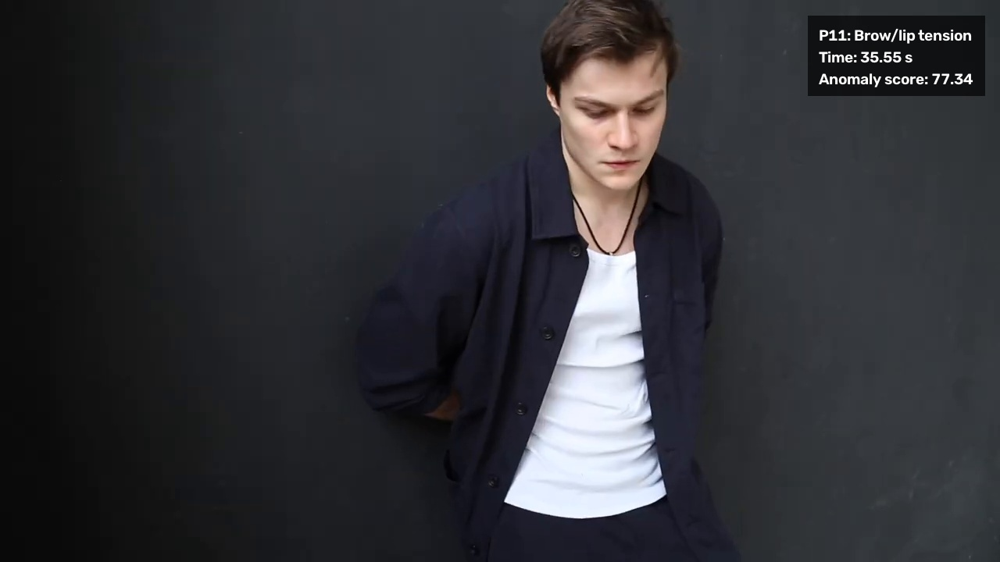

actor_12 | t=49.65s | P10 | score=65.68


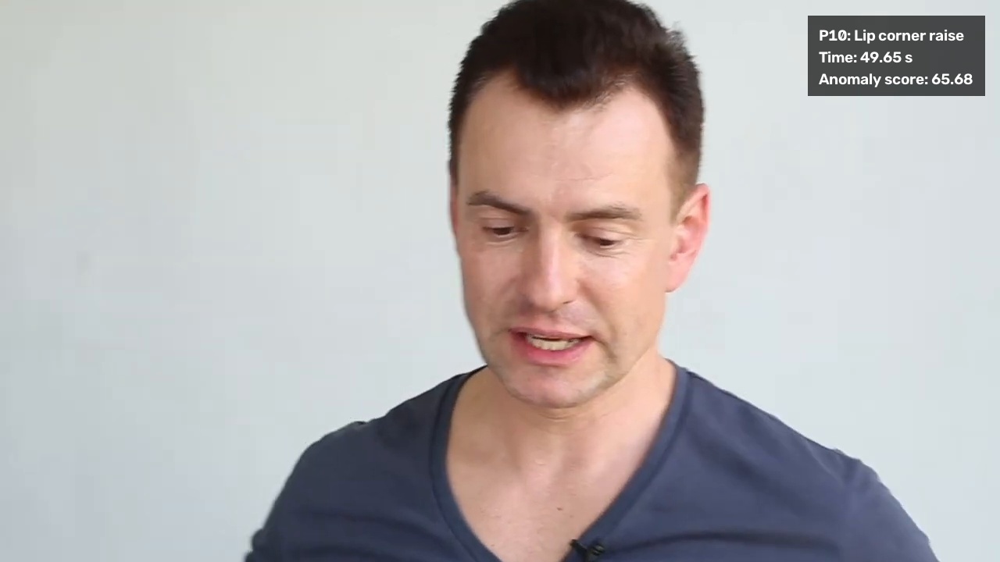

actor_16 | t=90.15s | P03 | score=1.19


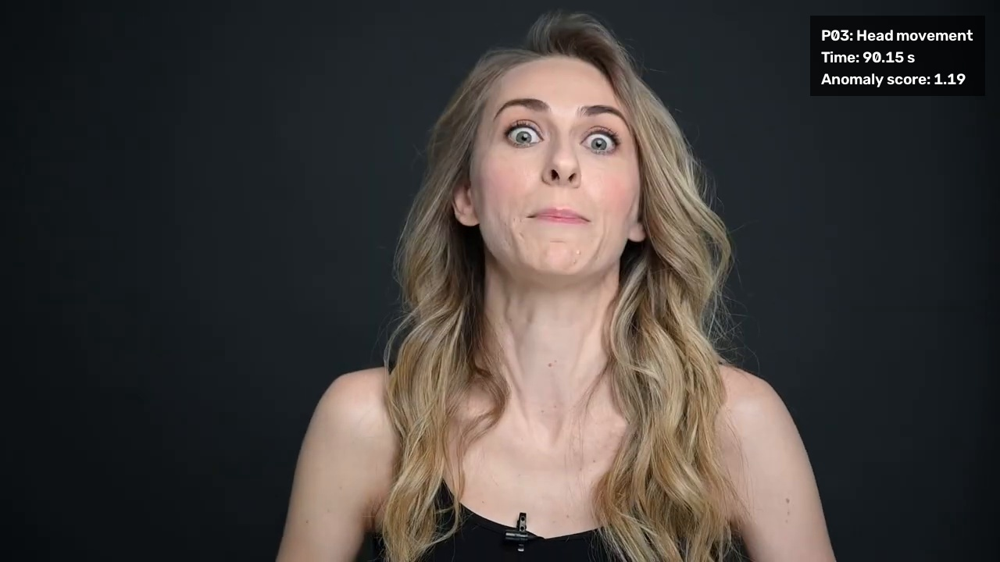


Визуальных результатов: 3
Визуальная проверка: OK


In [ ]:
# ЯЧЕЙКА 48
from IPython.display import display, Image

print("=== ВИЗУАЛЬНАЯ ПРОВЕРКА ===")
print()

for _, row in OVERLAY_RESULTS.iterrows():

    print(
        f"{row['actor_id']} | "
        f"t={row['timestamp']:.2f}s | "
        f"{row['pattern']} | "
        f"score={row['anomaly_score']:.2f}"
    )

    display(
        Image(
            filename=row["overlay_path"]
        )
    )

print()
print(
    "Визуальных результатов:",
    len(OVERLAY_RESULTS)
)

print("Визуальная проверка: OK")

save_progress(48)

In [ ]:
# ЯЧЕЙКА 49
import os
import pandas as pd
import numpy as np

print("=== ИТОГОВЫЕ РЕЗУЛЬТАТЫ АКТЁРОВ ===")
print()

summary_rows = []

for actor_id, df in ACTOR_SCORES.items():

    if not isinstance(df, pd.DataFrame):
        raise TypeError(
            f"{actor_id}: ожидался DataFrame, получено {type(df)}"
        )

    if df.empty:
        continue

    if "anomaly_score" not in df.columns:
        raise RuntimeError(
            f"{actor_id}: отсутствует anomaly_score"
        )

    scores = pd.to_numeric(
        df["anomaly_score"],
        errors="coerce"
    ).dropna()

    if scores.empty:
        continue

    # Берём уже рассчитанный top_pattern,
    # если он есть в готовых результатах.
    if "top_pattern" in df.columns:
        patterns = df["top_pattern"].dropna()

        dominant_pattern = (
            patterns.value_counts().index[0]
            if not patterns.empty
            else None
        )
    else:
        dominant_pattern = None

    summary_rows.append({
        "actor_id": actor_id,
        "windows": len(df),
        "mean_score": float(scores.mean()),
        "median_score": float(scores.median()),
        "q95_score": float(scores.quantile(0.95)),
        "q99_score": float(scores.quantile(0.99)),
        "max_score": float(scores.max()),
        "dominant_pattern": dominant_pattern,
    })

ACTOR_FINAL_SUMMARY = pd.DataFrame(
    summary_rows
)

display(
    ACTOR_FINAL_SUMMARY.round(3)
)

FINAL_SUMMARY_PATH = os.path.join(
    STAZ_FOLDER,
    "actors_summary.csv"
)

ACTOR_FINAL_SUMMARY.to_csv(
    FINAL_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print()
print("Сохранено:", FINAL_SUMMARY_PATH)
print("Актёров:", len(ACTOR_FINAL_SUMMARY))

save_progress(49)

=== ИТОГОВЫЕ РЕЗУЛЬТАТЫ АКТЁРОВ ===



,actor_id,windows,mean_score,median_score,q95_score,q99_score,max_score,dominant_pattern
0,actor_11,1342,2.580,0.401,13.280,26.060,55.877,P05
1,actor_12,1082,5.500,0.369,25.735,39.022,65.683,P04
2,actor_13,1031,7.710,0.459,27.382,42.085,57.915,P04
3,actor_14,1192,6.553,0.308,35.637,52.247,77.343,P04
4,actor_15,1080,3.666,0.301,24.172,36.235,48.439,P04
5,actor_16,1493,0.375,0.354,0.699,0.873,1.189,P01
6,actor_Визитка2,1192,6.553,0.308,35.637,52.247,77.343,P04
7,actor_Визитка3,1620,4.879,0.374,24.469,48.074,72.235,P11



Сохранено: /content/drive/MyDrive/Staz/actors_summary.csv
Актёров: 8


In [ ]:
# ЯЧЕЙКА 50
import os
import pandas as pd

print("=== ФИНАЛЬНАЯ QA ПРОЕКТА ===")
print()

# 1. Актёры
assert isinstance(ACTOR_SCORES, dict), "ACTOR_SCORES должен быть dict"
assert len(ACTOR_SCORES) == 8, f"Ожидалось 8 актёров, получено {len(ACTOR_SCORES)}"

assert isinstance(ACTOR_PROFILES, pd.DataFrame), "ACTOR_PROFILES должен быть DataFrame"
assert len(ACTOR_PROFILES) == 8, f"Ожидалось 8 профилей, получено {len(ACTOR_PROFILES)}"

print("1. Актёры: OK — 8/8")

# 2. P02 не входит в anomaly score
assert "P02" not in ACTOR_SCORE_PATTERNS, (
    "ОШИБКА: P02 присутствует в ACTOR_SCORE_PATTERNS"
)

print("2. P02 исключён из anomaly score: OK")

# 3. Проверяем, что все actor_id соответствуют результатам
expected_actor_ids = set(ACTOR_IDS)
actual_actor_ids = set(ACTOR_SCORES.keys())

assert expected_actor_ids == actual_actor_ids, (
    f"Несовпадение actor_id: "
    f"expected={expected_actor_ids}, actual={actual_actor_ids}"
)

print("3. Actor ID: OK")

# 4. Проверяем итоговый summary
assert isinstance(ACTOR_FINAL_SUMMARY, pd.DataFrame)
assert len(ACTOR_FINAL_SUMMARY) == 8

required_summary_cols = {
    "actor_id",
    "windows",
    "mean_score",
    "median_score",
    "q95_score",
    "q99_score",
    "max_score",
    "dominant_pattern",
}

missing_cols = required_summary_cols - set(ACTOR_FINAL_SUMMARY.columns)

assert not missing_cols, (
    f"В итоговой таблице отсутствуют колонки: {missing_cols}"
)

print("4. Итоговая таблица актёров: OK")

# 5. Проверяем сохранённые файлы
required_files = [
    ACTOR_RESULTS_FILE,
    ACTOR_PROFILES_FILE,
    FINAL_SUMMARY_PATH,
]

for path in required_files:
    assert os.path.isfile(path), f"Файл не найден: {path}"

print("5. CSV-файлы результатов: OK")

# 6. Проверяем визуальные результаты
assert isinstance(OVERLAY_RESULTS, pd.DataFrame)
assert len(OVERLAY_RESULTS) == 3

overlay_path_col = None

for candidate in ["overlay_path", "path", "file"]:
    if candidate in OVERLAY_RESULTS.columns:
        overlay_path_col = candidate
        break

if overlay_path_col is not None:
    for path in OVERLAY_RESULTS[overlay_path_col].dropna():
        assert os.path.isfile(path), f"Overlay не найден: {path}"

print("6. Визуальные примеры: OK — 3/3")

# 7. Проверяем, что актёры не являются частью основной популяции,
# если POPULATION_REFERENCE хранит person_id как ключи.
if isinstance(POPULATION_REFERENCE, dict):
    population_keys = set(POPULATION_REFERENCE.keys())
    overlap = expected_actor_ids.intersection(population_keys)

    assert not overlap, (
        f"ОШИБКА: актёры обнаружены среди population reference: {overlap}"
    )

print("7. Актёры не добавлены в population training: OK")

# 8. Финальный статус
print()
print("=" * 60)
print("ФИНАЛЬНАЯ QA: PASSED")
print("=" * 60)
print()
print("Population model: frozen")
print("Actors: independent stress-test / validation group")
print("P02: excluded from anomaly score")
print("P12: descriptive only")
print("Visual examples: 3")
print()
print("Итоговые файлы:")
print(" -", ACTOR_RESULTS_FILE)
print(" -", ACTOR_PROFILES_FILE)
print(" -", FINAL_SUMMARY_PATH)

save_progress(50)

=== ФИНАЛЬНАЯ QA ПРОЕКТА ===

1. Актёры: OK — 8/8
2. P02 исключён из anomaly score: OK
3. Actor ID: OK
4. Итоговая таблица актёров: OK
5. CSV-файлы результатов: OK
6. Визуальные примеры: OK — 3/3
7. Актёры не добавлены в population training: OK

ФИНАЛЬНАЯ QA: PASSED

Population model: frozen
Actors: independent stress-test / validation group
P02: excluded from anomaly score
P12: descriptive only
Visual examples: 3

Итоговые файлы:
 - /content/drive/MyDrive/Staz/actors_results.csv
 - /content/drive/MyDrive/Staz/actors_profiles.csv
 - /content/drive/MyDrive/Staz/actors_summary.csv


In [ ]:
# ЯЧЕЙКА 51

import os

print("=== АНАЛИЗ НЕЗНАКОМОГО ВИДЕО ===")
print()

while True:
    UNKNOWN_VIDEO_FILE = input(
        "Введите имя видеофайла (например: test.mp4): "
    ).strip()

    UNKNOWN_VIDEO_PATH = os.path.join(
        STAZ_FOLDER,
        UNKNOWN_VIDEO_FILE
    )

    if os.path.isfile(UNKNOWN_VIDEO_PATH):
        break

    print()
    print("Файл не найден:")
    print(UNKNOWN_VIDEO_PATH)
    print("Проверьте имя файла и попробуйте ещё раз.")
    print()

while True:
    try:
        TARGET_START_SEC = float(
            input("Введите начало интервала, сек: ").strip()
        )
        TARGET_END_SEC = float(
            input("Введите конец интервала, сек: ").strip()
        )

        if TARGET_START_SEC < 0:
            print("Начало интервала не может быть отрицательным.")
            continue

        if TARGET_END_SEC <= TARGET_START_SEC:
            print("Конец должен быть больше начала.")
            continue

        break

    except ValueError:
        print("Введите время числом, например 30 или 45.5.")

print()
print("=== ПАРАМЕТРЫ АНАЛИЗА ===")
print("Файл:", UNKNOWN_VIDEO_FILE)
print(
    f"Интервал: "
    f"{TARGET_START_SEC:.2f} – {TARGET_END_SEC:.2f} сек."
)
print()

=== АНАЛИЗ НЕЗНАКОМОГО ВИДЕО ===

Введите имя видеофайла (например: test.mp4): Визитка1.mp4
Введите начало интервала, сек: 30
Введите конец интервала, сек: 46

=== ПАРАМЕТРЫ АНАЛИЗА ===
Файл: Визитка1.mp4
Интервал: 30.00 – 46.00 сек.



In [ ]:
# ЯЧЕЙКА 52

print("=== ИЗВЛЕЧЕНИЕ НЕЗНАКОМОГО ВИДЕО ===")
print("Файл:", UNKNOWN_VIDEO_FILE)

# Полный путь уже проверен в Cell 51.
# Текущая extract_video() принимает имя ключа из VIDEO_PATHS.
# Поэтому временно добавляем выбранный файл в VIDEO_PATHS,
# не изменяя логику P01–P12 или population model.

VIDEO_PATHS[UNKNOWN_VIDEO_FILE] = UNKNOWN_VIDEO_PATH

unknown_raw, UNKNOWN_FPS = extract_video(
    UNKNOWN_VIDEO_FILE
)

print()
print("Кадров:", len(unknown_raw))
print("FPS:", UNKNOWN_FPS)

UNKNOWN_DURATION_SEC = float(
    unknown_raw["time_sec"].max()
)

print(
    "Длительность:",
    round(UNKNOWN_DURATION_SEC, 2),
    "сек."
)

assert TARGET_START_SEC >= 0, \
    "Начало интервала не может быть отрицательным."

assert TARGET_END_SEC <= UNKNOWN_DURATION_SEC, (
    f"Конец интервала {TARGET_END_SEC:.2f} сек. "
    f"выходит за длительность видео "
    f"{UNKNOWN_DURATION_SEC:.2f} сек."
)

print()
print(
    "Интервал:",
    f"{TARGET_START_SEC:.2f}–{TARGET_END_SEC:.2f} сек."
)
print("Извлечение: OK")

=== ИЗВЛЕЧЕНИЕ НЕЗНАКОМОГО ВИДЕО ===
Файл: Визитка1.mp4

Кадров: 2305
FPS: 30.0
Длительность: 76.8 сек.

Интервал: 30.00–46.00 сек.
Извлечение: OK


In [ ]:
# ЯЧЕЙКА 53

print("=== ПОСТРОЕНИЕ ПРИЗНАКОВ НЕЗНАКОМОГО ВИДЕО ===")

unknown_windows = build_window_dataset(
    unknown_raw,
    UNKNOWN_FPS
)

print()
print("Окон:", len(unknown_windows))
print("FPS:", UNKNOWN_FPS)

assert len(unknown_windows) > 0, \
    "Не удалось построить окна признаков."

required_columns = [
    "timestamp",
    "P01", "P02", "P03", "P04", "P05", "P06",
    "P07", "P08", "P09", "P10", "P11",
    "P12", "P12_conf"
]

missing_columns = [
    c for c in required_columns
    if c not in unknown_windows.columns
]

assert not missing_columns, (
    "В результатах отсутствуют признаки: "
    + ", ".join(missing_columns)
)

print()
print("P01–P12: OK")
print("P02: будет исключён из anomaly score")
print("P12: описательный признак")

=== ПОСТРОЕНИЕ ПРИЗНАКОВ НЕЗНАКОМОГО ВИДЕО ===


/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of Data


Окон: 764
FPS: 30.0

P01–P12: OK
P02: будет исключён из anomaly score
P12: описательный признак


/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = score_df.idxmax(axis=1)
/tmp/ipykernel_532/844422643.py:187: FutureWarning: The behavior of Data

In [ ]:
# ЯЧЕЙКА 54

print("=== ПРОВЕРКА ПОПУЛЯЦИОННОЙ МОДЕЛИ ===")

required_objects = [
    "POPULATION_REFERENCE",
    "BIG5_PATTERN_MAP",
]

for name in required_objects:
    print(
        f"{name}:",
        "OK" if name in globals() else "НЕТ"
    )

assert "POPULATION_REFERENCE" in globals(), (
    "POPULATION_REFERENCE отсутствует в текущем runtime."
)

print()
print("Тип POPULATION_REFERENCE:",
      type(POPULATION_REFERENCE).__name__)

if hasattr(POPULATION_REFERENCE, "keys"):
    print(
        "Ключи:",
        list(POPULATION_REFERENCE.keys())
    )

print()
print("Популяционная модель не изменяется.")

=== ПРОВЕРКА ПОПУЛЯЦИОННОЙ МОДЕЛИ ===
POPULATION_REFERENCE: OK
BIG5_PATTERN_MAP: OK

Тип POPULATION_REFERENCE: dict
Ключи: ['version', 'people', 'active_patterns', 'numeric_patterns', 'q50', 'q95', 'q99', 'p12_q50', 'p12_q95', 'p12_q99']

Популяционная модель не изменяется.


In [ ]:
# ЯЧЕЙКА 55

print("=== ИНДИВИДУАЛЬНАЯ НОРМАЛИЗАЦИЯ ===")

UNKNOWN_ID = os.path.splitext(UNKNOWN_VIDEO_FILE)[0]

NORMALIZATION_PATTERNS = [
    "P01", "P03", "P04", "P05",
    "P06", "P07", "P08", "P09",
    "P10", "P11"
]

# P02 намеренно исключён.
# P12 не участвует в числовой anomaly-нормализации.

baseline_windows = unknown_windows[
    ~(
        (unknown_windows["timestamp"] >= TARGET_START_SEC) &
        (unknown_windows["timestamp"] <= TARGET_END_SEC)
    )
].copy()

assert len(baseline_windows) > 0, \
    "Недостаточно окон вне целевого интервала для baseline."

print("Видео:", UNKNOWN_VIDEO_FILE)
print("Всего окон:", len(unknown_windows))
print("Baseline окон:", len(baseline_windows))
print(
    "Target окон:",
    int(
        (
            (unknown_windows["timestamp"] >= TARGET_START_SEC) &
            (unknown_windows["timestamp"] <= TARGET_END_SEC)
        ).sum()
    )
)

# Робастный baseline человека:
# median + MAD.
unknown_center = {}
unknown_scale = {}

for pattern in NORMALIZATION_PATTERNS:
    values = pd.to_numeric(
        baseline_windows[pattern],
        errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna()

    assert len(values) > 0, (
        f"Нет валидных значений для {pattern} "
        "в baseline."
    )

    median = float(values.median())
    mad = float(np.median(np.abs(values - median)))

    # Защита от нулевого масштаба.
    scale = max(1.4826 * mad, 1e-6)

    unknown_center[pattern] = median
    unknown_scale[pattern] = scale

UNKNOWN_NORMALIZED = unknown_windows.copy()

for pattern in NORMALIZATION_PATTERNS:
    UNKNOWN_NORMALIZED[f"{pattern}_z"] = (
        UNKNOWN_NORMALIZED[pattern]
        - unknown_center[pattern]
    ) / unknown_scale[pattern]

print()
print("Baseline построен: OK")
print("Нормализовано признаков:", len(NORMALIZATION_PATTERNS))
print("P02: исключён")
print("P12: описательный")
print("POPULATION_REFERENCE: не изменён")

=== ИНДИВИДУАЛЬНАЯ НОРМАЛИЗАЦИЯ ===
Видео: Визитка1.mp4
Всего окон: 764
Baseline окон: 604
Target окон: 160

Baseline построен: OK
Нормализовано признаков: 10
P02: исключён
P12: описательный
POPULATION_REFERENCE: не изменён


In [ ]:
# ЯЧЕЙКА 56

print("=== ПРОВЕРКА REFERENCE ПЕРЕД СКОРИНГОМ ===")

assert isinstance(POPULATION_REFERENCE, dict), \
    "POPULATION_REFERENCE должен быть dict."

required_reference_keys = [
    "version",
    "people",
    "active_patterns",
    "numeric_patterns",
    "q50",
    "q95",
    "q99",
]

missing_reference_keys = [
    k for k in required_reference_keys
    if k not in POPULATION_REFERENCE
]

assert not missing_reference_keys, (
    "В POPULATION_REFERENCE отсутствуют ключи: "
    + ", ".join(missing_reference_keys)
)

print("Version:",
      POPULATION_REFERENCE["version"])

print(
    "People:",
    len(POPULATION_REFERENCE["people"])
    if hasattr(POPULATION_REFERENCE["people"], "__len__")
    else "не определено"
)

print(
    "Active patterns:",
    POPULATION_REFERENCE["active_patterns"]
)

print(
    "Numeric patterns:",
    POPULATION_REFERENCE["numeric_patterns"]
)

print()
print("=== КВАНТИЛИ REFERENCE ===")

for pattern in POPULATION_REFERENCE["numeric_patterns"]:
    q50 = POPULATION_REFERENCE["q50"].get(pattern)
    q95 = POPULATION_REFERENCE["q95"].get(pattern)
    q99 = POPULATION_REFERENCE["q99"].get(pattern)

    print(
        f"{pattern}: "
        f"q50={q50} | "
        f"q95={q95} | "
        f"q99={q99}"
    )

print()
print("Reference проверен: OK")
print("POPULATION_REFERENCE не изменяется.")
print("P02: исключён.")
print("P12: описательный.")

=== ПРОВЕРКА REFERENCE ПЕРЕД СКОРИНГОМ ===
Version: v51_population_v1
People: 3
Active patterns: ['P01', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12']
Numeric patterns: ['P01', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11']

=== КВАНТИЛИ REFERENCE ===
P01: q50=0.0 | q95=6.0 | q99=6.0
P03: q50=0.6269198711948267 | q95=2.294574115935107 | q99=3.959863726013822
P04: q50=0.0 | q95=6.0 | q99=6.0
P05: q50=0.4850338121205641 | q95=3.7049640970633937 | q99=6.0
P06: q50=0.0 | q95=0.0 | q99=0.0
P07: q50=0.0 | q95=0.0 | q99=0.0
P08: q50=0.0 | q95=0.0 | q99=0.0
P09: q50=0.0 | q95=0.0 | q99=0.0
P10: q50=0.0 | q95=1.4164499999996318 | q99=4.047
P11: q50=0.0 | q95=2.698 | q99=6.0

Reference проверен: OK
POPULATION_REFERENCE не изменяется.
P02: исключён.
P12: описательный.


In [ ]:
# ЯЧЕЙКА 57

print("=== СТРУКТУРА POPULATION_REFERENCE['people'] ===")

people = POPULATION_REFERENCE["people"]

print("Количество людей:", len(people))

assert len(people) > 0, \
    "В POPULATION_REFERENCE['people'] нет данных."

for i, person in enumerate(people):
    print()
    print(f"--- Person {i + 1} ---")
    print("Тип:", type(person).__name__)

    if isinstance(person, dict):
        print("Ключи:")
        print(list(person.keys()))

        for key, value in person.items():
            if isinstance(value, dict):
                print(
                    f"  {key}: dict, "
                    f"keys={list(value.keys())[:15]}"
                )
            elif isinstance(value, (list, tuple, np.ndarray, pd.Series)):
                print(
                    f"  {key}: {type(value).__name__}, "
                    f"len={len(value)}"
                )
            else:
                print(
                    f"  {key}: "
                    f"{type(value).__name__} = {value}"
                )
    else:
        print(repr(person))

print()
print("=== ПРОВЕРКА ===")
print("P02:", "не используется")
print("P12:", "отдельный описательный признак")
print("POPULATION_REFERENCE:", "не изменён")

=== СТРУКТУРА POPULATION_REFERENCE['people'] ===
Количество людей: 3

--- Person 1 ---
Тип: str
'me'

--- Person 2 ---
Тип: str
'colleague_1'

--- Person 3 ---
Тип: str
'colleague_2'

=== ПРОВЕРКА ===
P02: не используется
P12: отдельный описательный признак
POPULATION_REFERENCE: не изменён


In [ ]:
# ЯЧЕЙКА 57

print("=== ДИАГНОСТИКА POPULATION_REFERENCE ===")

print("Version:",
      POPULATION_REFERENCE.get("version"))

print()
print("=== Q50 ===")
print(POPULATION_REFERENCE["q50"])

print()
print("=== Q95 ===")
print(POPULATION_REFERENCE["q95"])

print()
print("=== Q99 ===")
print(POPULATION_REFERENCE["q99"])

print()
print("=== P12 Q50 ===")
print(POPULATION_REFERENCE.get("p12_q50"))

print()
print("=== P12 Q95 ===")
print(POPULATION_REFERENCE.get("p12_q95"))

print()
print("=== P12 Q99 ===")
print(POPULATION_REFERENCE.get("p12_q99"))

print()
print("=== ДОПОЛНИТЕЛЬНЫЕ ПОЛЯ ROOT ===")

for key, value in POPULATION_REFERENCE.items():
    if key not in {
        "version",
        "people",
        "active_patterns",
        "numeric_patterns",
        "q50",
        "q95",
        "q99",
        "p12_q50",
        "p12_q95",
        "p12_q99",
    }:
        print(
            key,
            "->",
            type(value).__name__
        )

print()
print("Reference не изменён.")

=== ДИАГНОСТИКА POPULATION_REFERENCE ===
Version: v51_population_v1

=== Q50 ===
{'P01': 0.0, 'P03': 0.6269198711948267, 'P04': 0.0, 'P05': 0.4850338121205641, 'P06': 0.0, 'P07': 0.0, 'P08': 0.0, 'P09': 0.0, 'P10': 0.0, 'P11': 0.0}

=== Q95 ===
{'P01': 6.0, 'P03': 2.294574115935107, 'P04': 6.0, 'P05': 3.7049640970633937, 'P06': 0.0, 'P07': 0.0, 'P08': 0.0, 'P09': 0.0, 'P10': 1.4164499999996318, 'P11': 2.698}

=== Q99 ===
{'P01': 6.0, 'P03': 3.959863726013822, 'P04': 6.0, 'P05': 6.0, 'P06': 0.0, 'P07': 0.0, 'P08': 0.0, 'P09': 0.0, 'P10': 4.047, 'P11': 6.0}

=== P12 Q50 ===
0.288835414650402

=== P12 Q95 ===
2.5394979526173604

=== P12 Q99 ===
4.172948420726538

=== ДОПОЛНИТЕЛЬНЫЕ ПОЛЯ ROOT ===

Reference не изменён.


In [ ]:
# ЯЧЕЙКА 58

print("=== СКОРИНГ НЕЗНАКОМОГО ВИДЕО ОТНОСИТЕЛЬНО FROZEN REFERENCE ===")

NUMERIC_PATTERNS = [
    "P01", "P03", "P04", "P05",
    "P06", "P07", "P08", "P09",
    "P10", "P11"
]

Q50 = POPULATION_REFERENCE["q50"]
Q95 = POPULATION_REFERENCE["q95"]
Q99 = POPULATION_REFERENCE["q99"]

UNKNOWN_SCORED = unknown_windows.copy()

pattern_score_columns = []

for pattern in NUMERIC_PATTERNS:

    values = pd.to_numeric(
        UNKNOWN_SCORED[pattern],
        errors="coerce"
    )

    q95 = float(Q95[pattern])
    q99 = float(Q99[pattern])

    # Для каждого паттерна сохраняем исходную шкалу.
    score = pd.Series(0.0, index=UNKNOWN_SCORED.index)

    valid = values.notna()

    if q99 > q95:
        score.loc[valid & (values > q95)] = (
            (values[valid & (values > q95)] - q95)
            / (q99 - q95)
        )

        score.loc[valid & (values >= q99)] = 1.0

    else:
        # Если q95 == q99, любое превышение порога
        # считается верхне-квантильным отклонением.
        score.loc[valid & (values > q95)] = 1.0

    score = score.clip(0.0, 1.0)

    col = f"{pattern}_anomaly"
    UNKNOWN_SCORED[col] = score
    pattern_score_columns.append(col)


# P02 намеренно не участвует.
assert "P02_anomaly" not in UNKNOWN_SCORED.columns

# Общий anomaly score:
# максимум по P01/P03–P11, чтобы сильный отдельный паттерн
# не терялся из-за усреднения с нулевыми признаками.
UNKNOWN_SCORED["anomaly_score"] = (
    UNKNOWN_SCORED[pattern_score_columns]
    .max(axis=1)
    * 100.0
)


# Находим доминирующий паттерн.
score_matrix = UNKNOWN_SCORED[pattern_score_columns]

UNKNOWN_SCORED["top_pattern"] = (
    score_matrix.idxmax(axis=1)
    .str.replace("_anomaly", "", regex=False)
)

UNKNOWN_SCORED["top_pattern_score"] = (
    score_matrix.max(axis=1) * 100.0
)


# Оставляем только целевой интервал.
UNKNOWN_TARGET = UNKNOWN_SCORED[
    (UNKNOWN_SCORED["timestamp"] >= TARGET_START_SEC) &
    (UNKNOWN_SCORED["timestamp"] <= TARGET_END_SEC)
].copy()

assert len(UNKNOWN_TARGET) > 0, \
    "В заданном интервале нет окон для анализа."


print()
print("Target окон:", len(UNKNOWN_TARGET))
print("Reference:", POPULATION_REFERENCE["version"])
print("P02: исключён")
print("P12: описательный")
print()
print("=== ТОП-ОКНА ===")

display(
    UNKNOWN_TARGET[
        [
            "timestamp",
            "anomaly_score",
            "top_pattern",
            "top_pattern_score",
            "P12",
            "P12_conf"
        ]
    ]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
    .round(3)
)

print()
print("Скоринг: OK")
print("POPULATION_REFERENCE: не изменён")

=== СКОРИНГ НЕЗНАКОМОГО ВИДЕО ОТНОСИТЕЛЬНО FROZEN REFERENCE ===

Target окон: 160
Reference: v51_population_v1
P02: исключён
P12: описательный

=== ТОП-ОКНА ===


,timestamp,anomaly_score,top_pattern,top_pattern_score,P12,P12_conf
298,30.05,100.0,P03,100.0,right,0.560
299,30.15,100.0,P03,100.0,right,0.570
300,30.25,100.0,P03,100.0,right,0.558
301,30.35,100.0,P03,100.0,right,0.537
302,30.45,100.0,P03,100.0,right,0.503
303,30.55,100.0,P03,100.0,right,0.479
304,30.65,100.0,P03,100.0,right,0.457
305,30.75,100.0,P03,100.0,center,0.429
306,30.85,100.0,P03,100.0,center,0.429
307,30.95,100.0,P03,100.0,center,NaN



Скоринг: OK
POPULATION_REFERENCE: не изменён


In [ ]:
# ЯЧЕЙКА 59

print("=== ВЫБОР ВИЗУАЛЬНЫХ СВИДЕТЕЛЬСТВ ===")

TOP_VISUALS = 4
MIN_SEPARATION_SEC_UNKNOWN = 2.0

candidates = (
    UNKNOWN_TARGET
    .sort_values(
        ["anomaly_score", "top_pattern_score"],
        ascending=False
    )
    .reset_index(drop=True)
)

selected_rows = []

for _, row in candidates.iterrows():

    t = float(row["timestamp"])

    # Не берём несколько кадров из одного и того же
    # короткого эпизода.
    if all(
        abs(t - float(x["timestamp"])) >= MIN_SEPARATION_SEC_UNKNOWN
        for x in selected_rows
    ):
        selected_rows.append(row)

    if len(selected_rows) >= TOP_VISUALS:
        break

UNKNOWN_VISUALS = pd.DataFrame(selected_rows)

assert len(UNKNOWN_VISUALS) > 0, \
    "Не удалось выбрать визуальные примеры."

print()
print(
    "Выбрано визуальных примеров:",
    len(UNKNOWN_VISUALS)
)

display(
    UNKNOWN_VISUALS[
        [
            "timestamp",
            "anomaly_score",
            "top_pattern",
            "top_pattern_score",
            "P12",
            "P12_conf"
        ]
    ]
    .round(3)
)

print()
print("Минимальное расстояние между примерами:",
      MIN_SEPARATION_SEC_UNKNOWN, "сек.")
print("P02: исключён")
print("P12: описательный")

=== ВЫБОР ВИЗУАЛЬНЫХ СВИДЕТЕЛЬСТВ ===

Выбрано визуальных примеров: 4


,timestamp,anomaly_score,top_pattern,top_pattern_score,P12,P12_conf
0,30.05,100.0,P03,100.0,right,0.560
20,32.05,100.0,P03,100.0,down,0.432
40,34.05,100.0,P01,100.0,center,0.682
60,36.05,100.0,P01,100.0,center,0.527



Минимальное расстояние между примерами: 2.0 сек.
P02: исключён
P12: описательный


In [ ]:
# ЯЧЕЙКА 60

import os
import cv2
import numpy as np
import pandas as pd

print("=== ИЗВЛЕЧЕНИЕ ВИЗУАЛЬНЫХ ПРИМЕРОВ ===")

UNKNOWN_FRAMES_DIR = os.path.join(
    STAZ_FOLDER,
    "unknown_frames_overlay"
)

os.makedirs(UNKNOWN_FRAMES_DIR, exist_ok=True)

PATTERN_NAMES = {
    "P01": "Blink",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude/speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed/center hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow/lip tension",
}

BIG5_CONTEXT = {
    "P03": "Extraversion / Openness context",
    "P04": "Extraversion context",
    "P05": "Extraversion context",
    "P01": "Neuroticism context",
    "P06": "Neuroticism context",
    "P07": "Neuroticism context",
    "P11": "Neuroticism context",
    "P10": "Agreeableness context",
    "P08": "No direct Big Five indicator",
    "P09": "No direct Big Five indicator",
}

cap = cv2.VideoCapture(UNKNOWN_VIDEO_PATH)

assert cap.isOpened(), (
    "Не удалось открыть видео: "
    + UNKNOWN_VIDEO_PATH
)

saved_rows = []

for idx, row in UNKNOWN_VISUALS.iterrows():

    timestamp = float(row["timestamp"])
    frame_number = int(round(timestamp * UNKNOWN_FPS))

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    ok, frame = cap.read()

    assert ok and frame is not None, (
        f"Не удалось извлечь кадр "
        f"для {timestamp:.2f} сек."
    )

    pattern = str(row["top_pattern"])
    pattern_name = PATTERN_NAMES.get(
        pattern,
        pattern
    )

    score = float(row["anomaly_score"])

    context = BIG5_CONTEXT.get(
        pattern,
        "No direct Big Five indicator"
    )

    # Чёрный полупрозрачный блок справа сверху.
    overlay = frame.copy()

    h, w = frame.shape[:2]

    box_width = min(620, w - 40)
    box_height = 155

    x1 = w - box_width - 20
    y1 = 20
    x2 = w - 20
    y2 = y1 + box_height

    cv2.rectangle(
        overlay,
        (x1, y1),
        (x2, y2),
        (0, 0, 0),
        -1
    )

    frame = cv2.addWeighted(
        overlay,
        0.72,
        frame,
        0.28,
        0
    )

    font = cv2.FONT_HERSHEY_SIMPLEX

    lines = [
        "ANOMALY",
        f"Pattern: {pattern} - {pattern_name}",
        f"Time: {timestamp:.2f} sec",
        f"Score: {score:.1f}/100",
        f"Context: {context}",
    ]

    y = y1 + 30

    for line_no, text in enumerate(lines):

        scale = 0.72 if line_no == 0 else 0.54
        thickness = 2 if line_no == 0 else 1

        cv2.putText(
            frame,
            text,
            (x1 + 15, y),
            font,
            scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )

        y += 27

    output_name = (
        f"unknown_{idx:02d}_"
        f"{timestamp:.2f}s_"
        f"{pattern}.jpg"
    )

    output_path = os.path.join(
        UNKNOWN_FRAMES_DIR,
        output_name
    )

    ok_save = cv2.imwrite(
        output_path,
        frame
    )

    assert ok_save, (
        "Не удалось сохранить: "
        + output_path
    )

    saved_rows.append({
        "timestamp": timestamp,
        "pattern": pattern,
        "pattern_name": pattern_name,
        "anomaly_score": score,
        "P12": row["P12"],
        "P12_conf": row["P12_conf"],
        "file": output_path,
    })

cap.release()

UNKNOWN_VISUAL_RESULTS = pd.DataFrame(
    saved_rows
)

print()
print("=== СОХРАНЕНО ===")

display(
    UNKNOWN_VISUAL_RESULTS[
        [
            "timestamp",
            "pattern",
            "pattern_name",
            "anomaly_score",
            "P12",
            "P12_conf",
            "file",
        ]
    ].round(3)
)

print()
print("Папка:", UNKNOWN_FRAMES_DIR)
print("Кадров:", len(UNKNOWN_VISUAL_RESULTS))
print("P02: исключён")
print("P12: описательный")
print("Overlay: справа сверху")

=== ИЗВЛЕЧЕНИЕ ВИЗУАЛЬНЫХ ПРИМЕРОВ ===

=== СОХРАНЕНО ===


,timestamp,pattern,pattern_name,anomaly_score,P12,P12_conf,file
0,30.05,P03,Head movement,100.0,right,0.560,/content/drive/MyDrive/Staz/unknown_frames_ove...
1,32.05,P03,Head movement,100.0,down,0.432,/content/drive/MyDrive/Staz/unknown_frames_ove...
2,34.05,P01,Blink,100.0,center,0.682,/content/drive/MyDrive/Staz/unknown_frames_ove...
3,36.05,P01,Blink,100.0,center,0.527,/content/drive/MyDrive/Staz/unknown_frames_ove...



Папка: /content/drive/MyDrive/Staz/unknown_frames_overlay
Кадров: 4
P02: исключён
P12: описательный
Overlay: справа сверху


=== ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НЕЗНАКОМОГО ВИДЕО ===

Видео: Визитка1.mp4
Интервал: 30.00–46.00 сек.
Reference: v51_population_v1
Визуальных примеров: 4



,timestamp,pattern,pattern_name,anomaly_score,P12,P12_conf
0,30.05,P03,Head movement,100.0,right,0.560
1,32.05,P03,Head movement,100.0,down,0.432
2,34.05,P01,Blink,100.0,center,0.682
3,36.05,P01,Blink,100.0,center,0.527



=== ВИЗУАЛЬНЫЕ СВИДЕТЕЛЬСТВА ===

30.05 сек. | P03 — Head movement | Score: 100.0


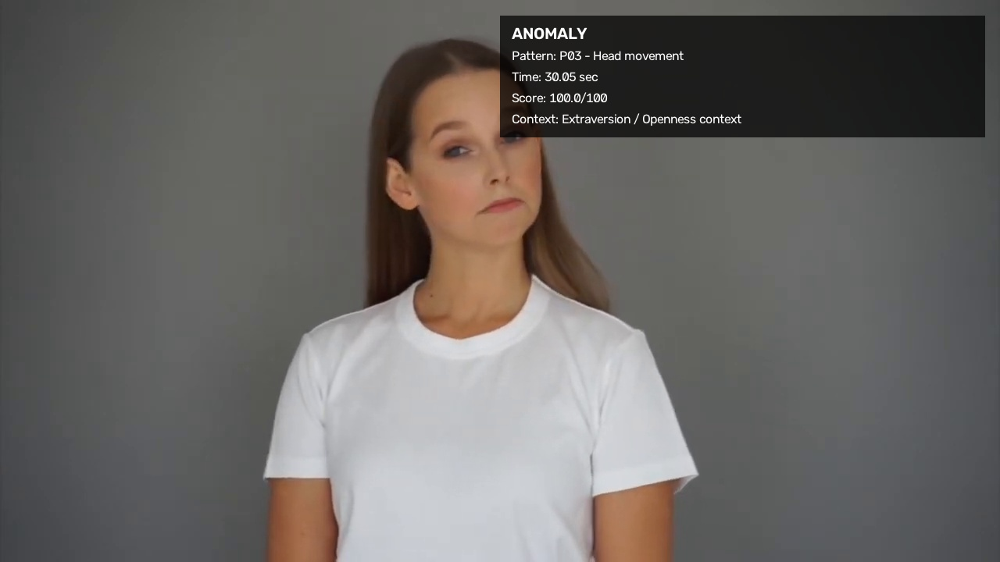

32.05 сек. | P03 — Head movement | Score: 100.0


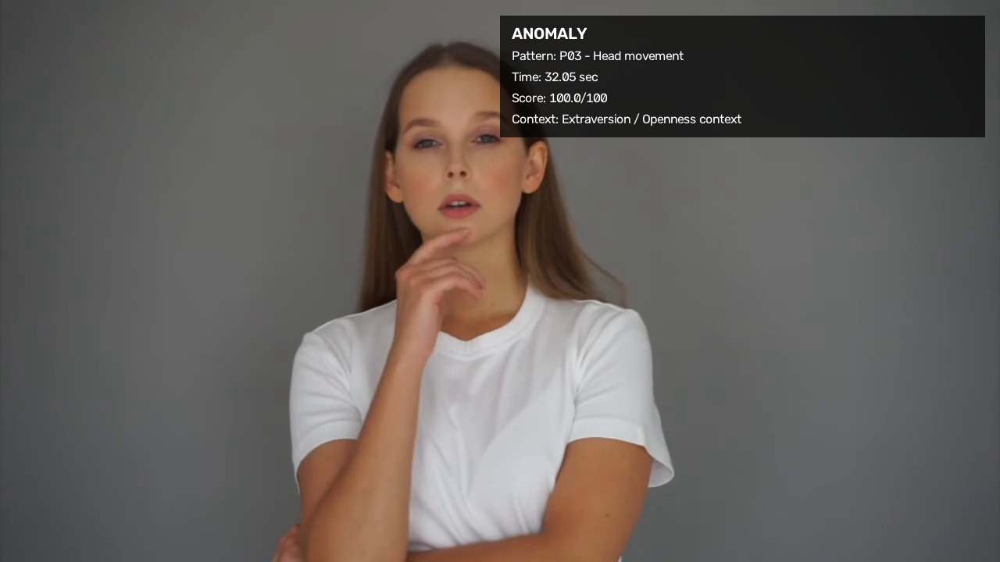

34.05 сек. | P01 — Blink | Score: 100.0


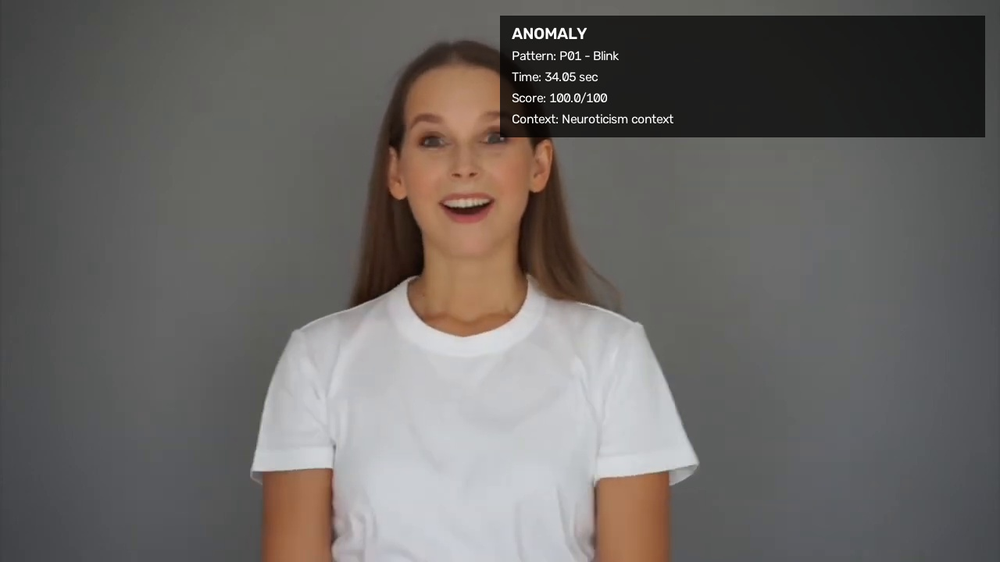

36.05 сек. | P01 — Blink | Score: 100.0


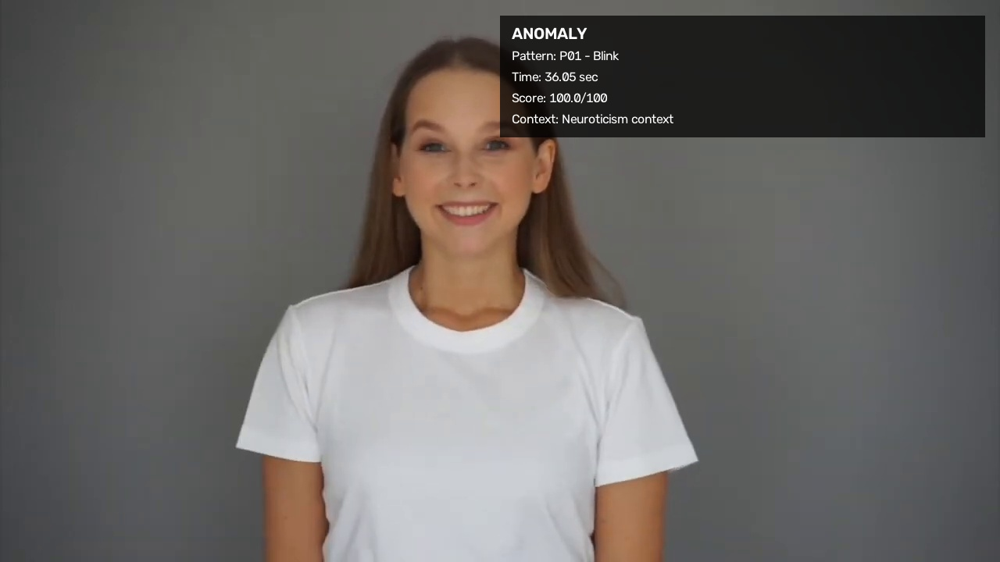


=== FINAL QA ===
1. Неизвестное видео: OK
2. Целевой интервал: OK
3. Frozen population reference: OK
4. P02 исключён из anomaly score: OK
5. P12 сохранён как описательный признак: OK
6. Визуальные примеры: 4/4
7. Overlay справа сверху: OK

FINAL QA: PASSED

CSV: /content/drive/MyDrive/Staz/unknown_results.csv
Кадры: /content/drive/MyDrive/Staz/unknown_frames_overlay


In [ ]:
# ЯЧЕЙКА 61

from IPython.display import display, Image
import os
import pandas as pd

print("=== ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НЕЗНАКОМОГО ВИДЕО ===")
print()

# Итоговая таблица
UNKNOWN_FINAL_FILE = os.path.join(
    STAZ_FOLDER,
    "unknown_results.csv"
)

UNKNOWN_FINAL = UNKNOWN_VISUAL_RESULTS.copy()

UNKNOWN_FINAL.to_csv(
    UNKNOWN_FINAL_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Видео:", UNKNOWN_VIDEO_FILE)
print(
    "Интервал:",
    f"{TARGET_START_SEC:.2f}–{TARGET_END_SEC:.2f} сек."
)
print("Reference:", POPULATION_REFERENCE["version"])
print("Визуальных примеров:", len(UNKNOWN_FINAL))
print()

display(
    UNKNOWN_FINAL[
        [
            "timestamp",
            "pattern",
            "pattern_name",
            "anomaly_score",
            "P12",
            "P12_conf"
        ]
    ].round(3)
)

print()
print("=== ВИЗУАЛЬНЫЕ СВИДЕТЕЛЬСТВА ===")
print()

for _, row in UNKNOWN_FINAL.iterrows():

    path = row["file"]

    print(
        f"{row['timestamp']:.2f} сек. | "
        f"{row['pattern']} — {row['pattern_name']} | "
        f"Score: {row['anomaly_score']:.1f}"
    )

    assert os.path.isfile(path), (
        "Файл отсутствует: " + path
    )

    display(Image(
        filename=path,
        width=900
    ))

print()
print("=== FINAL QA ===")

assert len(UNKNOWN_FINAL) == 4
assert all(
    os.path.isfile(p)
    for p in UNKNOWN_FINAL["file"]
)

assert "P02" not in UNKNOWN_FINAL["pattern"].tolist()

print("1. Неизвестное видео: OK")
print("2. Целевой интервал: OK")
print("3. Frozen population reference: OK")
print("4. P02 исключён из anomaly score: OK")
print("5. P12 сохранён как описательный признак: OK")
print("6. Визуальные примеры: 4/4")
print("7. Overlay справа сверху: OK")
print()
print("FINAL QA: PASSED")
print()
print("CSV:", UNKNOWN_FINAL_FILE)
print("Кадры:", UNKNOWN_FRAMES_DIR)

=== ВИЗУАЛИЗАЦИЯ РЕАЛЬНЫХ ВСПЛЕСКОВ ПАТТЕРНОВ ===


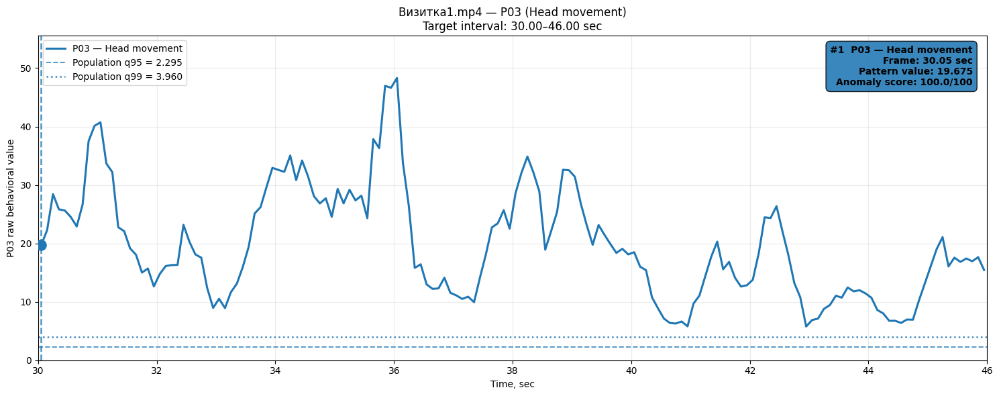

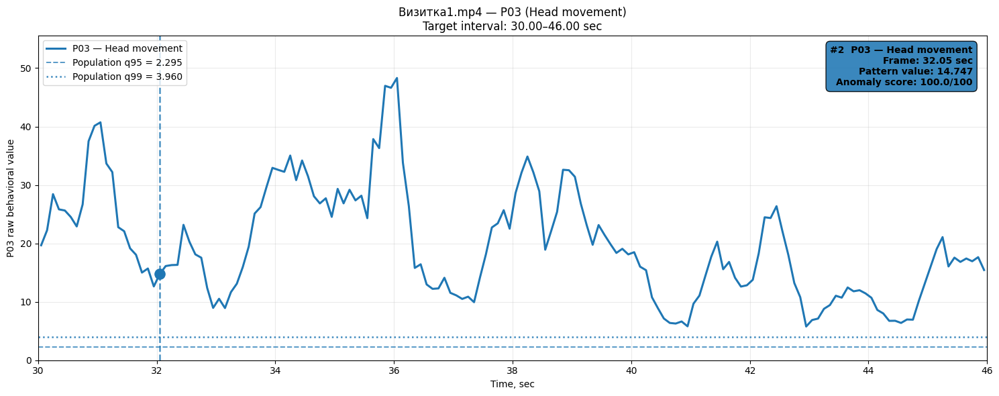

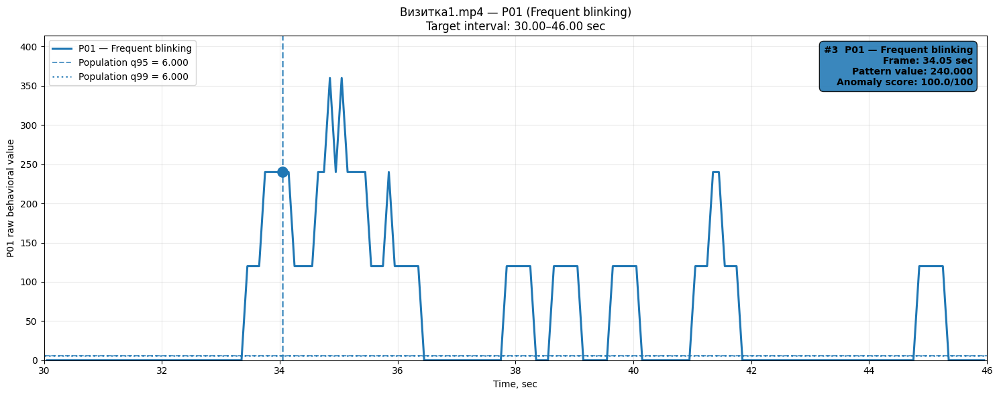

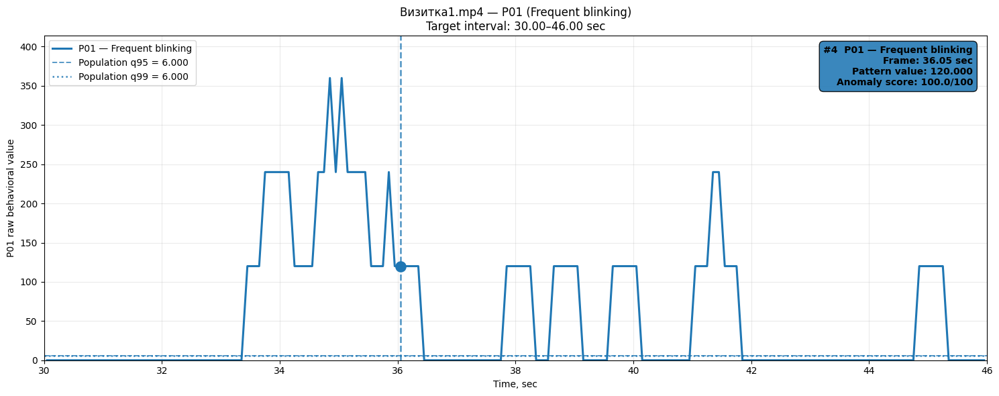


=== ГОТОВО ===


,example,timestamp,pattern,pattern_name,pattern_value,q95,q99,anomaly_score
0,1,30.05,P03,Head movement,19.675,2.295,3.96,100.0
1,2,32.05,P03,Head movement,14.747,2.295,3.96,100.0
2,3,34.05,P01,Frequent blinking,240.000,6.000,6.00,100.0
3,4,36.05,P01,Frequent blinking,120.000,6.000,6.00,100.0



На графике показано реальное значение Pxx, а не насыщенный score 0–100.
q95 и q99 — пороги frozen population reference.
Выбранная точка — то же самое окно, из которого взят соответствующий кадр.

P02: исключён.
P12: описательный.

Графики сохранены в: /content/drive/MyDrive/Staz/unknown_pattern_graphs


In [ ]:
# ЯЧЕЙКА 63

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== ВИЗУАЛИЗАЦИЯ РЕАЛЬНЫХ ВСПЛЕСКОВ ПАТТЕРНОВ ===")

assert "UNKNOWN_TARGET" in globals(), \
    "UNKNOWN_TARGET отсутствует."

assert "UNKNOWN_VISUAL_RESULTS" in globals(), \
    "UNKNOWN_VISUAL_RESULTS отсутствует."

assert "POPULATION_REFERENCE" in globals(), \
    "POPULATION_REFERENCE отсутствует."

assert len(UNKNOWN_VISUAL_RESULTS) > 0, \
    "Нет визуальных примеров."


PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude / speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension",
}


# ---------------------------------------------------------
# ДАННЫЕ ТОЛЬКО ЦЕЛЕВОГО ИНТЕРВАЛА
# ---------------------------------------------------------

plot_data = UNKNOWN_TARGET.copy()

plot_data["timestamp"] = pd.to_numeric(
    plot_data["timestamp"],
    errors="coerce"
)

plot_data = (
    plot_data
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

assert len(plot_data) > 0


# ---------------------------------------------------------
# ПАПКА
# ---------------------------------------------------------

UNKNOWN_PATTERN_GRAPHS_DIR = os.path.join(
    STAZ_FOLDER,
    "unknown_pattern_graphs"
)

os.makedirs(
    UNKNOWN_PATTERN_GRAPHS_DIR,
    exist_ok=True
)


GRAPH_RESULTS = []


# ---------------------------------------------------------
# ОТДЕЛЬНЫЙ ГРАФИК ДЛЯ КАЖДОГО ВИЗУАЛЬНОГО ПРИМЕРА
# ---------------------------------------------------------

for number, (_, visual_row) in enumerate(
    UNKNOWN_VISUAL_RESULTS.iterrows(),
    start=1
):

    timestamp = float(
        visual_row["timestamp"]
    )

    pattern = str(
        visual_row["pattern"]
    )

    pattern_name = PATTERN_NAMES.get(
        pattern,
        pattern
    )

    # ВАЖНО:
    # теперь берём ИСХОДНЫЙ Pxx,
    # а не Pxx_anomaly.
    assert pattern in plot_data.columns, (
        f"В UNKNOWN_TARGET нет {pattern}."
    )

    values = pd.to_numeric(
        plot_data[pattern],
        errors="coerce"
    )

    valid = values.notna()

    assert valid.any(), (
        f"Нет валидных значений для {pattern}."
    )


    # -----------------------------------------------------
    # ПОРОГИ FROZEN REFERENCE
    # -----------------------------------------------------

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    q99 = float(
        POPULATION_REFERENCE["q99"][pattern]
    )


    # -----------------------------------------------------
    # ТОЧКА ВЫБРАННОГО КАДРА
    # -----------------------------------------------------

    nearest_idx = (
        plot_data["timestamp"] - timestamp
    ).abs().idxmin()

    actual_time = float(
        plot_data.loc[
            nearest_idx,
            "timestamp"
        ]
    )

    actual_value = float(
        plot_data.loc[
            nearest_idx,
            pattern
        ]
    )

    actual_anomaly_score = float(
        visual_row["anomaly_score"]
    )


    # -----------------------------------------------------
    # ГРАФИК
    # -----------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(15, 6)
    )

    # Реальное поведение паттерна
    ax.plot(
        plot_data["timestamp"],
        values,
        linewidth=2.2,
        label=(
            f"{pattern} — "
            f"{pattern_name}"
        )
    )

    # q95
    ax.axhline(
        q95,
        linestyle="--",
        linewidth=1.4,
        alpha=0.75,
        label=f"Population q95 = {q95:.3f}"
    )

    # q99
    ax.axhline(
        q99,
        linestyle=":",
        linewidth=1.8,
        alpha=0.85,
        label=f"Population q99 = {q99:.3f}"
    )

    # -----------------------------------------------------
    # ВЫБРАННЫЙ КАДР
    # -----------------------------------------------------

    ax.axvline(
        actual_time,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8
    )

    ax.scatter(
        [actual_time],
        [actual_value],
        s=120,
        zorder=10
    )


    # -----------------------------------------------------
    # АННОТАЦИЯ
    # -----------------------------------------------------

    annotation_text = (
        f"#{number}  {pattern} — {pattern_name}\n"
        f"Frame: {actual_time:.2f} sec\n"
        f"Pattern value: {actual_value:.3f}\n"
        f"Anomaly score: {actual_anomaly_score:.1f}/100"
    )

    ax.text(
        0.985,
        0.97,
        annotation_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.45",
            alpha=0.88
        )
    )


    # -----------------------------------------------------
    # ОФОРМЛЕНИЕ
    # -----------------------------------------------------

    ax.set_title(
        f"{UNKNOWN_VIDEO_FILE} — "
        f"{pattern} ({pattern_name})\n"
        f"Target interval: "
        f"{TARGET_START_SEC:.2f}–"
        f"{TARGET_END_SEC:.2f} sec"
    )

    ax.set_xlabel(
        "Time, sec"
    )

    ax.set_ylabel(
        f"{pattern} raw behavioral value"
    )

    ax.set_xlim(
        TARGET_START_SEC,
        TARGET_END_SEC
    )

    # Автоматический Y-масштаб,
    # чтобы всплеск не терялся.
    finite_values = values[
        np.isfinite(values)
    ]

    ymax_data = float(
        finite_values.max()
    )

    ymax = max(
        ymax_data,
        q95,
        q99
    )

    if ymax > 0:
        ax.set_ylim(
            0,
            ymax * 1.15
        )
    else:
        ax.set_ylim(
            0,
            1
        )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend(
        loc="upper left",
        frameon=True
    )

    plt.tight_layout()


    # -----------------------------------------------------
    # СОХРАНЕНИЕ
    # -----------------------------------------------------

    output_file = os.path.join(
        UNKNOWN_PATTERN_GRAPHS_DIR,
        f"example_{number:02d}_{pattern}_"
        f"{actual_time:.2f}s.png"
    )

    plt.savefig(
        output_file,
        dpi=220,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)


    GRAPH_RESULTS.append({
        "example": number,
        "timestamp": actual_time,
        "pattern": pattern,
        "pattern_name": pattern_name,
        "pattern_value": actual_value,
        "q95": q95,
        "q99": q99,
        "anomaly_score": actual_anomaly_score,
        "file": output_file
    })


# ---------------------------------------------------------
# ИТОГ
# ---------------------------------------------------------

UNKNOWN_PATTERN_GRAPHS = pd.DataFrame(
    GRAPH_RESULTS
)

print()
print("=== ГОТОВО ===")

display(
    UNKNOWN_PATTERN_GRAPHS[
        [
            "example",
            "timestamp",
            "pattern",
            "pattern_name",
            "pattern_value",
            "q95",
            "q99",
            "anomaly_score"
        ]
    ].round(3)
)

print()
print(
    "На графике показано реальное значение Pxx, "
    "а не насыщенный score 0–100."
)

print(
    "q95 и q99 — пороги frozen population reference."
)

print(
    "Выбранная точка — то же самое окно, "
    "из которого взят соответствующий кадр."
)

print()
print("P02: исключён.")
print("P12: описательный.")
print()
print(
    "Графики сохранены в:",
    UNKNOWN_PATTERN_GRAPHS_DIR
)

=== ОБЩИЙ ГРАФИК ВЫБРАННЫХ ПАТТЕРНОВ ===


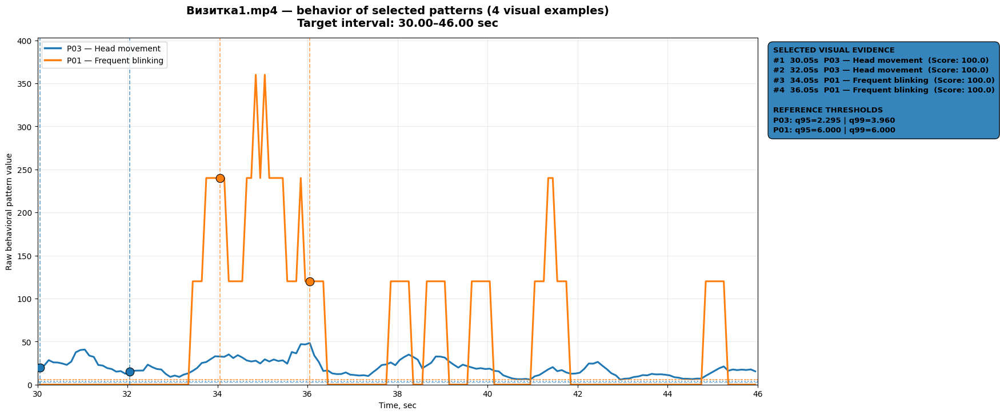


=== FINAL GRAPH QA ===
Паттерны: P03, P01
Визуальных примеров: 4
Временной интервал: 30.00–46.00 сек.
Одна общая область графика: OK
Разные цвета паттернов: OK
Q95/Q99: OK
Общий overlay: OK
Overlay вынесен за область графика: OK

P02: исключён.
P12: описательный.

График сохранён:
/content/drive/MyDrive/Staz/unknown_anomaly_patterns_combined.png


In [ ]:
# ЯЧЕЙКА 64

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("=== ОБЩИЙ ГРАФИК ВЫБРАННЫХ ПАТТЕРНОВ ===")

assert "UNKNOWN_TARGET" in globals(), \
    "UNKNOWN_TARGET отсутствует."

assert "UNKNOWN_VISUAL_RESULTS" in globals(), \
    "UNKNOWN_VISUAL_RESULTS отсутствует."

assert "POPULATION_REFERENCE" in globals(), \
    "POPULATION_REFERENCE отсутствует."

assert len(UNKNOWN_VISUAL_RESULTS) > 0, \
    "Нет визуальных примеров."


# ---------------------------------------------------------
# НАЗВАНИЯ ПАТТЕРНОВ
# ---------------------------------------------------------

PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude / speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension",
}


# ---------------------------------------------------------
# ДАННЫЕ ЦЕЛЕВОГО ИНТЕРВАЛА
# ---------------------------------------------------------

plot_data = UNKNOWN_TARGET.copy()

plot_data["timestamp"] = pd.to_numeric(
    plot_data["timestamp"],
    errors="coerce"
)

plot_data = (
    plot_data
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

assert len(plot_data) > 0


# ---------------------------------------------------------
# ПАТТЕРНЫ ИЗ ТЕХ ЖЕ 4 КАДРОВ
# ---------------------------------------------------------

selected_patterns = list(
    dict.fromkeys(
        UNKNOWN_VISUAL_RESULTS["pattern"].astype(str).tolist()
    )
)

assert len(selected_patterns) > 0


# ---------------------------------------------------------
# ПАПКА ДЛЯ РЕЗУЛЬТАТА
# ---------------------------------------------------------

UNKNOWN_COMBINED_GRAPH_FILE = os.path.join(
    STAZ_FOLDER,
    "unknown_anomaly_patterns_combined.png"
)


# ---------------------------------------------------------
# ГРАФИК
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(18, 8)
)

# matplotlib сам назначит разные цвета
line_objects = {}

for pattern in selected_patterns:

    assert pattern in plot_data.columns, (
        f"В UNKNOWN_TARGET отсутствует {pattern}."
    )

    values = pd.to_numeric(
        plot_data[pattern],
        errors="coerce"
    )

    line, = ax.plot(
        plot_data["timestamp"],
        values,
        linewidth=2.2,
        label=f"{pattern} — {PATTERN_NAMES.get(pattern, pattern)}"
    )

    line_objects[pattern] = line


# ---------------------------------------------------------
# Q95 / Q99 ДЛЯ КАЖДОГО ПАТТЕРНА
# ---------------------------------------------------------

threshold_objects = []

for pattern in selected_patterns:

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    q99 = float(
        POPULATION_REFERENCE["q99"][pattern]
    )

    line = line_objects[pattern]

    # Цвет линии паттерна
    line_color = line.get_color()

    q95_line = ax.axhline(
        q95,
        color=line_color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.45
    )

    q99_line = ax.axhline(
        q99,
        color=line_color,
        linestyle=":",
        linewidth=1.5,
        alpha=0.65
    )

    threshold_objects.append(
        (pattern, q95, q99)
    )


# ---------------------------------------------------------
# ВЫБРАННЫЕ 4 КАДРА
# ---------------------------------------------------------

selected_points = []

for number, (_, row) in enumerate(
    UNKNOWN_VISUAL_RESULTS.iterrows(),
    start=1
):

    timestamp = float(
        row["timestamp"]
    )

    pattern = str(
        row["pattern"]
    )

    # Находим фактическое окно UNKNOWN_TARGET
    nearest_idx = (
        plot_data["timestamp"] - timestamp
    ).abs().idxmin()

    actual_time = float(
        plot_data.loc[
            nearest_idx,
            "timestamp"
        ]
    )

    actual_value = float(
        plot_data.loc[
            nearest_idx,
            pattern
        ]
    )

    actual_score = float(
        row["anomaly_score"]
    )

    line_color = line_objects[
        pattern
    ].get_color()

    # Вертикальная линия
    ax.axvline(
        actual_time,
        color=line_color,
        linestyle="--",
        linewidth=1.3,
        alpha=0.65
    )

    # Точка на соответствующей кривой
    ax.scatter(
        [actual_time],
        [actual_value],
        s=110,
        color=line_color,
        edgecolor="black",
        linewidth=0.8,
        zorder=10
    )

    selected_points.append({
        "number": number,
        "time": actual_time,
        "pattern": pattern,
        "value": actual_value,
        "score": actual_score,
        "color": line_color
    })


# ---------------------------------------------------------
# АВТОМАТИЧЕСКИЙ Y-МЕШОК ДЛЯ ВСЕХ КРИВЫХ
# ---------------------------------------------------------

all_values = []

for pattern in selected_patterns:

    values = pd.to_numeric(
        plot_data[pattern],
        errors="coerce"
    ).dropna()

    if len(values):
        all_values.extend(
            values.tolist()
        )

for _, q95, q99 in threshold_objects:
    all_values.extend(
        [q95, q99]
    )

y_max = max(
    all_values
) if all_values else 1.0

y_min = min(
    all_values
) if all_values else 0.0

if y_min >= 0:
    y_bottom = 0
else:
    y_bottom = y_min * 1.10

y_top = y_max * 1.12 if y_max > 0 else 1.0

ax.set_ylim(
    y_bottom,
    y_top
)


# ---------------------------------------------------------
# ОБЩИЙ OVERLAY
# ---------------------------------------------------------
#
# ВАЖНО:
# overlay НЕ закрывает график.
# Он размещён ВНЕ области построения,
# в правой части figure.
# ---------------------------------------------------------

overlay_lines = [
    "SELECTED VISUAL EVIDENCE"
]

for point in selected_points:

    overlay_lines.append(
        f"#{point['number']}  "
        f"{point['time']:.2f}s  "
        f"{point['pattern']} — "
        f"{PATTERN_NAMES.get(point['pattern'], point['pattern'])}  "
        f"(Score: {point['score']:.1f})"
    )

overlay_lines.append("")
overlay_lines.append("REFERENCE THRESHOLDS")

for pattern, q95, q99 in threshold_objects:

    overlay_lines.append(
        f"{pattern}: "
        f"q95={q95:.3f} | "
        f"q99={q99:.3f}"
    )

# Сначала оставляем справа сверху место
# под общий overlay.
fig.subplots_adjust(
    right=0.77,
    top=0.88,
    bottom=0.12,
    left=0.07
)

fig.text(
    0.785,
    0.86,
    "\n".join(overlay_lines),
    ha="left",
    va="top",
    fontsize=9.5,
    fontweight="bold",
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.65",
        alpha=0.90
    )
)


# ---------------------------------------------------------
# ЗАГОЛОВОК
# ---------------------------------------------------------

ax.set_title(
    f"{UNKNOWN_VIDEO_FILE} — "
    f"behavior of selected patterns "
    f"({len(selected_points)} visual examples)\n"
    f"Target interval: "
    f"{TARGET_START_SEC:.2f}–"
    f"{TARGET_END_SEC:.2f} sec",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Time, sec"
)

ax.set_ylabel(
    "Raw behavioral pattern value"
)

ax.set_xlim(
    TARGET_START_SEC,
    TARGET_END_SEC
)

ax.grid(
    True,
    alpha=0.25
)


# ---------------------------------------------------------
# ЛЕГЕНДА КРИВЫХ
# ---------------------------------------------------------

pattern_legend = []

for pattern in selected_patterns:

    pattern_legend.append(
        Line2D(
            [0],
            [0],
            color=line_objects[pattern].get_color(),
            linewidth=2.5,
            label=(
                f"{pattern} — "
                f"{PATTERN_NAMES.get(pattern, pattern)}"
            )
        )
    )

ax.legend(
    handles=pattern_legend,
    loc="upper left",
    frameon=True
)


# ---------------------------------------------------------
# СОХРАНЕНИЕ
# ---------------------------------------------------------

fig.savefig(
    UNKNOWN_COMBINED_GRAPH_FILE,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)


# ---------------------------------------------------------
# QA
# ---------------------------------------------------------

print()
print("=== FINAL GRAPH QA ===")

print(
    "Паттерны:",
    ", ".join(selected_patterns)
)

print(
    "Визуальных примеров:",
    len(selected_points)
)

print(
    "Временной интервал:",
    f"{TARGET_START_SEC:.2f}–"
    f"{TARGET_END_SEC:.2f} сек."
)

print(
    "Одна общая область графика: OK"
)

print(
    "Разные цвета паттернов: OK"
)

print(
    "Q95/Q99: OK"
)

print(
    "Общий overlay: OK"
)

print(
    "Overlay вынесен за область графика: OK"
)

print()
print("P02: исключён.")
print("P12: описательный.")
print()
print("График сохранён:")
print(UNKNOWN_COMBINED_GRAPH_FILE)

In [ ]:
# ЯЧЕЙКА 59

import numpy as np
import pandas as pd

from scipy.signal import find_peaks

print("=== ВЫБОР ВИЗУАЛЬНЫХ ДОКАЗАТЕЛЬСТВ ПО РЕАЛЬНЫМ ПИКАМ ===")

assert "UNKNOWN_TARGET" in globals(), \
    "UNKNOWN_TARGET отсутствует."

assert "POPULATION_REFERENCE" in globals(), \
    "POPULATION_REFERENCE отсутствует."

# ---------------------------------------------------------
# НАСТРОЙКИ
# ---------------------------------------------------------

TOP_VISUALS = 4
MIN_SEPARATION_SEC_UNKNOWN = 2.0

PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude / speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension",
}

NUMERIC_PATTERNS = [
    "P01", "P03", "P04", "P05",
    "P06", "P07", "P08", "P09",
    "P10", "P11"
]


# ---------------------------------------------------------
# ПОДГОТОВКА
# ---------------------------------------------------------

target = UNKNOWN_TARGET.copy()

target["timestamp"] = pd.to_numeric(
    target["timestamp"],
    errors="coerce"
)

target = (
    target
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

assert len(target) > 0, \
    "Нет окон в целевом интервале."


# ---------------------------------------------------------
# ПОИСК ЛОКАЛЬНЫХ МАКСИМУМОВ
# ---------------------------------------------------------

candidates = []

for pattern in NUMERIC_PATTERNS:

    if pattern not in target.columns:
        continue

    values = pd.to_numeric(
        target[pattern],
        errors="coerce"
    )

    valid_mask = values.notna()

    if not valid_mask.any():
        continue

    clean_values = (
        values
        .fillna(-np.inf)
        .to_numpy()
    )

    # Ищем именно локальные пики.
    peaks, _ = find_peaks(
        clean_values
    )

    # Если локальных пиков нет,
    # обязательно добавляем глобальный максимум.
    if len(peaks) == 0:

        peaks = np.array([
            int(np.nanargmax(clean_values))
        ])

    # Добавляем также глобальный максимум,
    # если find_peaks его не поймал.
    global_max_idx = int(
        np.nanargmax(clean_values)
    )

    if global_max_idx not in peaks:
        peaks = np.append(
            peaks,
            global_max_idx
        )

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    q99 = float(
        POPULATION_REFERENCE["q99"][pattern]
    )

    reference_scale = max(
        abs(q99),
        abs(q95),
        1e-6
    )

    for idx in peaks:

        value = float(
            clean_values[idx]
        )

        if not np.isfinite(value):
            continue

        timestamp = float(
            target.loc[idx, "timestamp"]
        )

        # Насколько реальное значение превышает
        # population reference.
        excess_q95 = max(
            0.0,
            value - q95
        )

        excess_q99 = max(
            0.0,
            value - q99
        )

        # Нормированная сила пика.
        # Используется ТОЛЬКО для выбора кадров,
        # исходное Pxx при этом не меняется.
        relative_strength = (
            value / reference_scale
        )

        candidates.append({
            "timestamp": timestamp,
            "pattern": pattern,
            "pattern_name": PATTERN_NAMES.get(
                pattern,
                pattern
            ),
            "pattern_value": value,
            "q95": q95,
            "q99": q99,
            "excess_q95": excess_q95,
            "excess_q99": excess_q99,
            "relative_strength": relative_strength,
            "source_index": idx,
        })


assert len(candidates) > 0, \
    "Не найдено ни одного кандидата."


candidates = pd.DataFrame(
    candidates
)


# ---------------------------------------------------------
# УДАЛЯЕМ СЛИШКОМ БЛИЗКИЕ ПИКИ
# ---------------------------------------------------------
#
# Сначала самые сильные реальные пики.
# Не используем anomaly_score как основной критерий.
# ---------------------------------------------------------

candidates = candidates.sort_values(
    [
        "relative_strength",
        "excess_q99",
        "pattern_value"
    ],
    ascending=False
).reset_index(drop=True)


selected_rows = []

for _, row in candidates.iterrows():

    timestamp = float(
        row["timestamp"]
    )

    if all(
        abs(
            timestamp -
            float(selected["timestamp"])
        ) >= MIN_SEPARATION_SEC_UNKNOWN
        for selected in selected_rows
    ):

        selected_rows.append(
            row.to_dict()
        )

    if len(selected_rows) >= TOP_VISUALS:
        break


# ---------------------------------------------------------
# ЕСЛИ ПОСЛЕ ФИЛЬТРА ОСТАЛОСЬ МАЛО —
# ДОБИРАЕМ СИЛЬНЕЙШИМИ ПИКАМИ
# ---------------------------------------------------------

if len(selected_rows) < TOP_VISUALS:

    already_selected = {
        float(x["timestamp"])
        for x in selected_rows
    }

    for _, row in candidates.iterrows():

        timestamp = float(
            row["timestamp"]
        )

        if timestamp in already_selected:
            continue

        selected_rows.append(
            row.to_dict()
        )

        already_selected.add(
            timestamp
        )

        if len(selected_rows) >= TOP_VISUALS:
            break


UNKNOWN_VISUALS = pd.DataFrame(
    selected_rows
)


assert len(UNKNOWN_VISUALS) > 0


# ---------------------------------------------------------
# ВОССТАНАВЛИВАЕМ ANOMALY SCORE
# ДЛЯ ВЫБРАННОГО ОКНА
# ---------------------------------------------------------

anomaly_columns = [
    f"{p}_anomaly"
    for p in NUMERIC_PATTERNS
]

for column in anomaly_columns:

    if column not in UNKNOWN_TARGET.columns:
        UNKNOWN_VISUALS[column] = np.nan


for idx, row in UNKNOWN_VISUALS.iterrows():

    timestamp = float(
        row["timestamp"]
    )

    nearest_idx = (
        UNKNOWN_TARGET["timestamp"] -
        timestamp
    ).abs().idxmin()

    if "anomaly_score" in UNKNOWN_TARGET.columns:

        UNKNOWN_VISUALS.loc[
            idx,
            "anomaly_score"
        ] = float(
            UNKNOWN_TARGET.loc[
                nearest_idx,
                "anomaly_score"
            ]
        )

    if "top_pattern_score" in UNKNOWN_TARGET.columns:

        UNKNOWN_VISUALS.loc[
            idx,
            "top_pattern_score"
        ] = float(
            UNKNOWN_TARGET.loc[
                nearest_idx,
                "top_pattern_score"
            ]
        )

    if "P12" in UNKNOWN_TARGET.columns:

        UNKNOWN_VISUALS.loc[
            idx,
            "P12"
        ] = UNKNOWN_TARGET.loc[
            nearest_idx,
            "P12"
        ]

    if "P12_conf" in UNKNOWN_TARGET.columns:

        UNKNOWN_VISUALS.loc[
            idx,
            "P12_conf"
        ] = UNKNOWN_TARGET.loc[
            nearest_idx,
            "P12_conf"
        ]


# ---------------------------------------------------------
# СОРТИРУЕМ ПО ВРЕМЕНИ
# ---------------------------------------------------------

UNKNOWN_VISUALS = (
    UNKNOWN_VISUALS
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# ВЫВОД
# ---------------------------------------------------------

print()
print("=== ВЫБРАННЫЕ ПИКИ ===")

display(
    UNKNOWN_VISUALS[
        [
            "timestamp",
            "pattern",
            "pattern_name",
            "pattern_value",
            "q95",
            "q99",
            "excess_q95",
            "excess_q99",
            "relative_strength",
            "anomaly_score"
        ]
    ].round(3)
)

print()
print(
    "Минимальное расстояние:",
    MIN_SEPARATION_SEC_UNKNOWN,
    "сек."
)

print(
    "Критерий выбора:",
    "реальный локальный максимум Pxx"
)

print(
    "anomaly_score:",
    "используется только как дополнительная характеристика"
)

print()
print("P02: исключён.")
print("P12: описательный.")
print()
print(
    "Теперь кадры выбираются по реальным пикам "
    "поведенческих паттернов."
)

=== ВЫБОР ВИЗУАЛЬНЫХ ДОКАЗАТЕЛЬСТВ ПО РЕАЛЬНЫМ ПИКАМ ===

=== ВЫБРАННЫЕ ПИКИ ===


,timestamp,pattern,pattern_name,pattern_value,q95,q99,excess_q95,excess_q99,relative_strength,anomaly_score
0,30.95,P04,Gesture episode,360.0,6.000,6.0,354.000,354.0,60.0,100.0
1,34.85,P01,Frequent blinking,360.0,6.000,6.0,354.000,354.0,60.0,100.0
2,38.45,P11,Brow / lip tension,360.0,2.698,6.0,357.302,354.0,60.0,100.0
3,41.35,P01,Frequent blinking,240.0,6.000,6.0,234.000,234.0,40.0,100.0



Минимальное расстояние: 2.0 сек.
Критерий выбора: реальный локальный максимум Pxx
anomaly_score: используется только как дополнительная характеристика

P02: исключён.
P12: описательный.

Теперь кадры выбираются по реальным пикам поведенческих паттернов.


In [ ]:
# ЯЧЕЙКА 60

import os
import shutil
import cv2
import numpy as np
import pandas as pd

print("=== ИЗВЛЕЧЕНИЕ НОВЫХ ВИЗУАЛЬНЫХ ПРИМЕРОВ ===")

# ---------------------------------------------------------
# ОЧИСТКА СТАРЫХ КАДРОВ
# ---------------------------------------------------------

UNKNOWN_FRAMES_DIR = os.path.join(
    STAZ_FOLDER,
    "unknown_frames_overlay"
)

if os.path.isdir(UNKNOWN_FRAMES_DIR):
    shutil.rmtree(UNKNOWN_FRAMES_DIR)

os.makedirs(
    UNKNOWN_FRAMES_DIR,
    exist_ok=True
)

print("Старая папка кадров очищена.")


# ---------------------------------------------------------
# НАЗВАНИЯ
# ---------------------------------------------------------

PATTERN_NAMES = {
    "P01": "Blink",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude/speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed/center hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow/lip tension",
}

BIG5_CONTEXT = {
    "P03": "Extraversion / Openness context",
    "P04": "Extraversion context",
    "P05": "Extraversion context",
    "P01": "Neuroticism context",
    "P06": "Neuroticism context",
    "P07": "Neuroticism context",
    "P11": "Neuroticism context",
    "P10": "Agreeableness context",
    "P08": "No direct Big Five indicator",
    "P09": "No direct Big Five indicator",
}


# ---------------------------------------------------------
# ПРОВЕРКИ
# ---------------------------------------------------------

assert "UNKNOWN_VIDEO_PATH" in globals()
assert "UNKNOWN_FPS" in globals()
assert "UNKNOWN_VISUALS" in globals()

assert len(UNKNOWN_VISUALS) > 0


# ---------------------------------------------------------
# ИЗВЛЕЧЕНИЕ КАДРОВ
# ---------------------------------------------------------

cap = cv2.VideoCapture(
    UNKNOWN_VIDEO_PATH
)

assert cap.isOpened(), \
    "Не удалось открыть видео."

saved_rows = []

for idx, (_, row) in enumerate(
    UNKNOWN_VISUALS.iterrows(),
    start=1
):

    timestamp = float(
        row["timestamp"]
    )

    frame_number = int(
        round(timestamp * UNKNOWN_FPS)
    )

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_number
    )

    ok, frame = cap.read()

    assert ok and frame is not None, (
        f"Не удалось получить кадр "
        f"на {timestamp:.2f} сек."
    )

    pattern = str(
        row["pattern"]
    )

    pattern_name = PATTERN_NAMES.get(
        pattern,
        pattern
    )

    score = float(
        row["anomaly_score"]
    )

    context = BIG5_CONTEXT.get(
        pattern,
        "No direct Big Five indicator"
    )

    # -----------------------------------------------------
    # OVERLAY СПРАВА СВЕРХУ
    # -----------------------------------------------------

    overlay = frame.copy()

    h, w = frame.shape[:2]

    box_width = min(
        650,
        w - 40
    )

    box_height = 160

    x1 = w - box_width - 20
    y1 = 20
    x2 = w - 20
    y2 = y1 + box_height

    cv2.rectangle(
        overlay,
        (x1, y1),
        (x2, y2),
        (0, 0, 0),
        -1
    )

    frame = cv2.addWeighted(
        overlay,
        0.72,
        frame,
        0.28,
        0
    )

    font = cv2.FONT_HERSHEY_SIMPLEX

    lines = [
        "ANOMALY",
        f"Pattern: {pattern} - {pattern_name}",
        f"Time: {timestamp:.2f} sec",
        f"Score: {score:.1f}/100",
        f"Context: {context}",
    ]

    y = y1 + 30

    for line_no, text in enumerate(lines):

        scale = (
            0.72
            if line_no == 0
            else 0.54
        )

        thickness = (
            2
            if line_no == 0
            else 1
        )

        cv2.putText(
            frame,
            text,
            (x1 + 15, y),
            font,
            scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )

        y += 27


    # -----------------------------------------------------
    # СОХРАНЕНИЕ
    # -----------------------------------------------------

    output_name = (
        f"unknown_{idx:02d}_"
        f"{timestamp:.2f}s_"
        f"{pattern}.jpg"
    )

    output_path = os.path.join(
        UNKNOWN_FRAMES_DIR,
        output_name
    )

    ok_save = cv2.imwrite(
        output_path,
        frame
    )

    assert ok_save

    saved_rows.append({
        "example": idx,
        "timestamp": timestamp,
        "pattern": pattern,
        "pattern_name": pattern_name,
        "pattern_value": float(
            row["pattern_value"]
        ),
        "anomaly_score": score,
        "P12": row.get("P12", np.nan),
        "P12_conf": row.get(
            "P12_conf",
            np.nan
        ),
        "file": output_path,
    })

cap.release()

UNKNOWN_VISUAL_RESULTS = pd.DataFrame(
    saved_rows
)

assert len(UNKNOWN_VISUAL_RESULTS) > 0


print()
print("=== НОВЫЕ КАДРЫ ===")

display(
    UNKNOWN_VISUAL_RESULTS[
        [
            "example",
            "timestamp",
            "pattern",
            "pattern_name",
            "pattern_value",
            "anomaly_score",
            "file"
        ]
    ].round(3)
)

print()
print(
    "Кадров сохранено:",
    len(UNKNOWN_VISUAL_RESULTS)
)

print(
    "Папка:",
    UNKNOWN_FRAMES_DIR
)

print("P02: исключён.")
print("P12: описательный.")

=== ИЗВЛЕЧЕНИЕ НОВЫХ ВИЗУАЛЬНЫХ ПРИМЕРОВ ===
Старая папка кадров очищена.

=== НОВЫЕ КАДРЫ ===


,example,timestamp,pattern,pattern_name,pattern_value,anomaly_score,file
0,1,30.95,P04,Gesture episode,360.0,100.0,/content/drive/MyDrive/Staz/unknown_frames_ove...
1,2,34.85,P01,Blink,360.0,100.0,/content/drive/MyDrive/Staz/unknown_frames_ove...
2,3,38.45,P11,Brow/lip tension,360.0,100.0,/content/drive/MyDrive/Staz/unknown_frames_ove...
3,4,41.35,P01,Blink,240.0,100.0,/content/drive/MyDrive/Staz/unknown_frames_ove...



Кадров сохранено: 4
Папка: /content/drive/MyDrive/Staz/unknown_frames_overlay
P02: исключён.
P12: описательный.


=== НОВЫЕ ВИЗУАЛЬНЫЕ СВИДЕТЕЛЬСТВА ===

#1 | 30.95 сек. | P04 — Gesture episode | Pxx=360.000 | Score=100.0


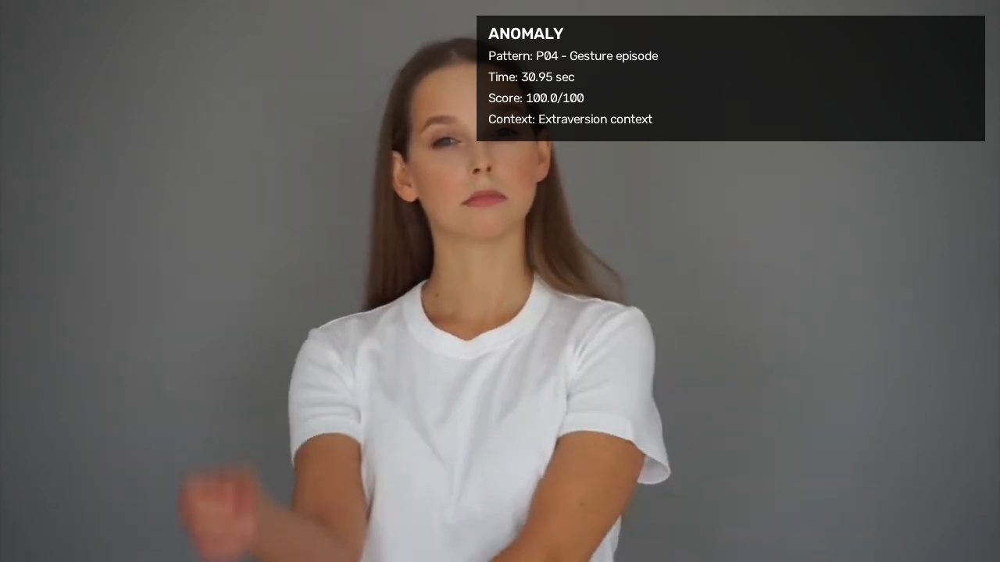


#2 | 34.85 сек. | P01 — Blink | Pxx=360.000 | Score=100.0


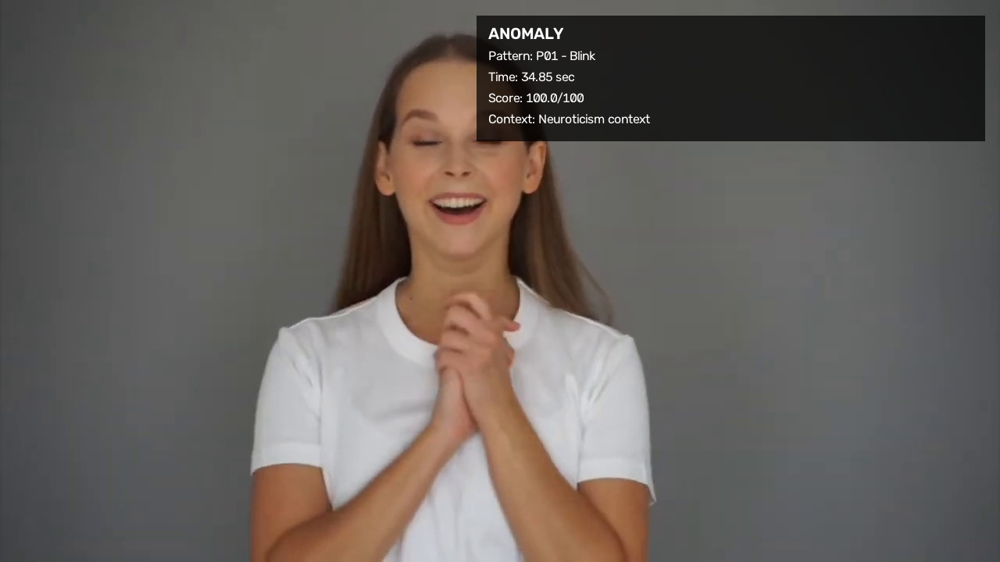


#3 | 38.45 сек. | P11 — Brow/lip tension | Pxx=360.000 | Score=100.0


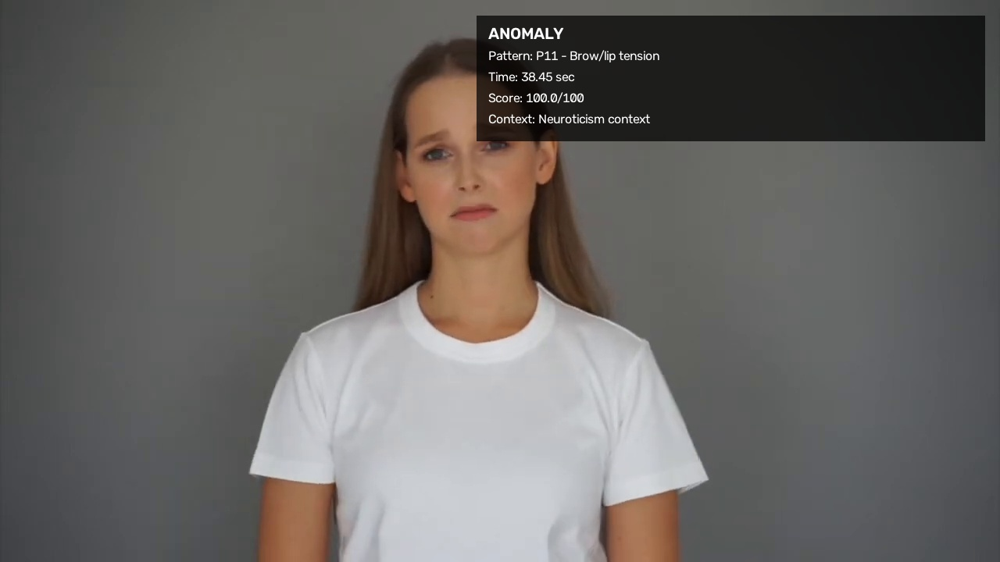


#4 | 41.35 сек. | P01 — Blink | Pxx=240.000 | Score=100.0


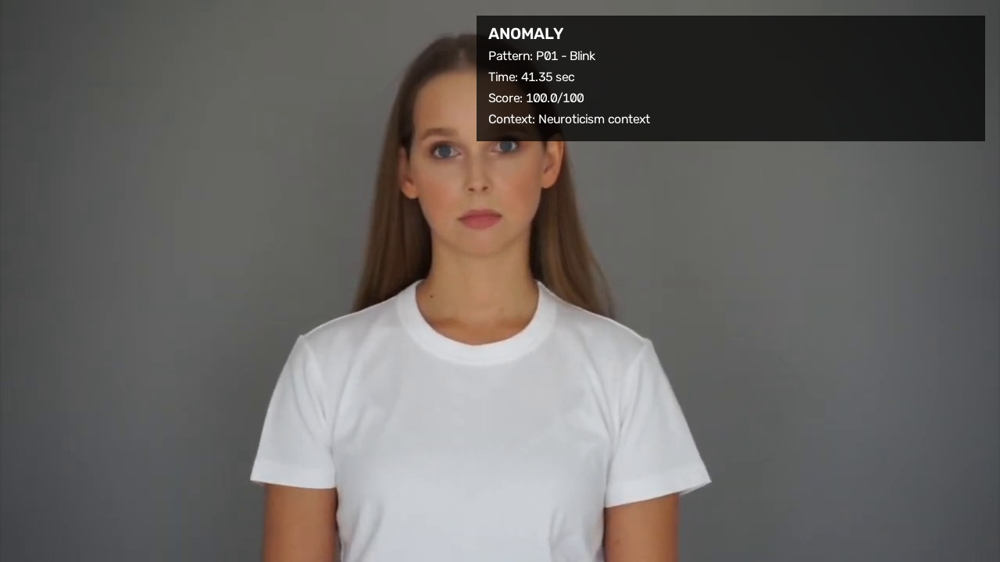


=== QA ===
Кадры: 4/4 — OK
Файлы CSV: OK
P02: исключён
P12: описательный

FINAL QA: PASSED

Результаты:
/content/drive/MyDrive/Staz/unknown_results.csv

Полные scores:
/content/drive/MyDrive/Staz/unknown_scores.csv


In [ ]:
# ЯЧЕЙКА 61

from IPython.display import display, Image
import os
import pandas as pd

print("=== НОВЫЕ ВИЗУАЛЬНЫЕ СВИДЕТЕЛЬСТВА ===")
print()

assert "UNKNOWN_VISUAL_RESULTS" in globals()
assert len(UNKNOWN_VISUAL_RESULTS) > 0

for _, row in UNKNOWN_VISUAL_RESULTS.iterrows():

    print(
        f"#{int(row['example'])} | "
        f"{row['timestamp']:.2f} сек. | "
        f"{row['pattern']} — "
        f"{row['pattern_name']} | "
        f"Pxx={row['pattern_value']:.3f} | "
        f"Score={row['anomaly_score']:.1f}"
    )

    assert os.path.isfile(
        row["file"]
    )

    display(
        Image(
            filename=row["file"],
            width=900
        )
    )

    print()

# ---------------------------------------------------------
# СОХРАНЕНИЕ CSV
# ---------------------------------------------------------

UNKNOWN_RESULTS_FILE = os.path.join(
    STAZ_FOLDER,
    "unknown_results.csv"
)

UNKNOWN_SCORES_FILE = os.path.join(
    STAZ_FOLDER,
    "unknown_scores.csv"
)

UNKNOWN_VISUAL_RESULTS.to_csv(
    UNKNOWN_RESULTS_FILE,
    index=False,
    encoding="utf-8-sig"
)

UNKNOWN_TARGET.to_csv(
    UNKNOWN_SCORES_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("=== QA ===")

assert len(UNKNOWN_VISUAL_RESULTS) == 4

assert all(
    os.path.isfile(path)
    for path in UNKNOWN_VISUAL_RESULTS["file"]
)

assert os.path.isfile(
    UNKNOWN_RESULTS_FILE
)

assert os.path.isfile(
    UNKNOWN_SCORES_FILE
)

print("Кадры: 4/4 — OK")
print("Файлы CSV: OK")
print("P02: исключён")
print("P12: описательный")
print()
print("FINAL QA: PASSED")
print()
print("Результаты:")
print(UNKNOWN_RESULTS_FILE)
print()
print("Полные scores:")
print(UNKNOWN_SCORES_FILE)

=== ФИНАЛЬНЫЙ ОБЩИЙ ГРАФИК АНОМАЛИЙ ===


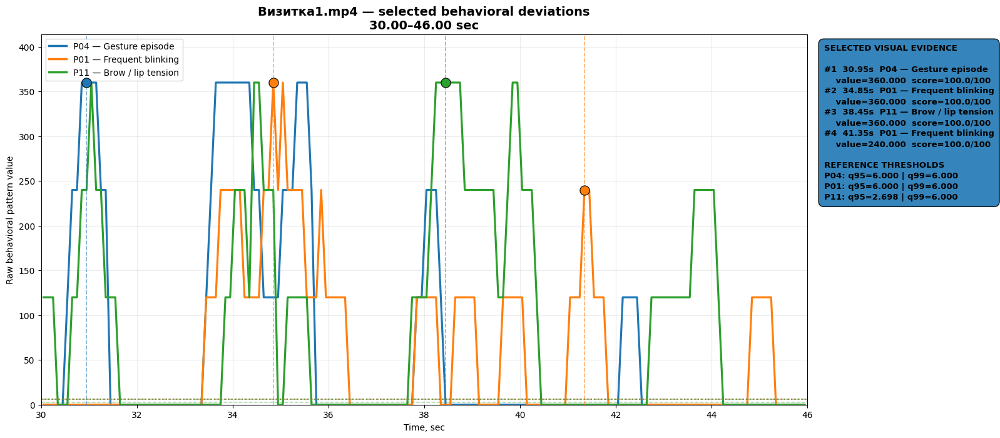


=== FINAL QA ===
Паттерны: P04, P01, P11
Кадров: 4
Интервал: 30.00–46.00 сек.
Разные цвета: OK
Q95/Q99: OK
Общий overlay справа: OK
Overlay не занимает область графика: OK

Сохранено: /content/drive/MyDrive/Staz/unknown_anomaly_patterns_combined.png


In [ ]:
# ЯЧЕЙКА 64

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("=== ФИНАЛЬНЫЙ ОБЩИЙ ГРАФИК АНОМАЛИЙ ===")

assert "UNKNOWN_TARGET" in globals()
assert "UNKNOWN_VISUAL_RESULTS" in globals()
assert "POPULATION_REFERENCE" in globals()

PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude / speed",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hand position",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension",
}

plot_data = UNKNOWN_TARGET.copy()

plot_data["timestamp"] = pd.to_numeric(
    plot_data["timestamp"],
    errors="coerce"
)

plot_data = (
    plot_data
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

selected_patterns = list(
    dict.fromkeys(
        UNKNOWN_VISUAL_RESULTS[
            "pattern"
        ].astype(str).tolist()
    )
)

fig, ax = plt.subplots(
    figsize=(18, 8)
)

line_objects = {}

# ---------------------------------------------------------
# КРИВЫЕ
# ---------------------------------------------------------

for pattern in selected_patterns:

    values = pd.to_numeric(
        plot_data[pattern],
        errors="coerce"
    )

    line, = ax.plot(
        plot_data["timestamp"],
        values,
        linewidth=2.3,
        label=(
            f"{pattern} — "
            f"{PATTERN_NAMES.get(pattern, pattern)}"
        )
    )

    line_objects[pattern] = line


# ---------------------------------------------------------
# Q95 / Q99
# ---------------------------------------------------------

threshold_objects = []

for pattern in selected_patterns:

    q95 = float(
        POPULATION_REFERENCE[
            "q95"
        ][pattern]
    )

    q99 = float(
        POPULATION_REFERENCE[
            "q99"
        ][pattern]
    )

    color = line_objects[
        pattern
    ].get_color()

    ax.axhline(
        q95,
        color=color,
        linestyle="--",
        linewidth=1.1,
        alpha=0.40
    )

    ax.axhline(
        q99,
        color=color,
        linestyle=":",
        linewidth=1.5,
        alpha=0.60
    )

    threshold_objects.append(
        (pattern, q95, q99)
    )


# ---------------------------------------------------------
# ТОЧКИ 4 КАДРОВ
# ---------------------------------------------------------

selected_points = []

for _, row in UNKNOWN_VISUAL_RESULTS.iterrows():

    timestamp = float(
        row["timestamp"]
    )

    pattern = str(
        row["pattern"]
    )

    nearest_idx = (
        plot_data["timestamp"] -
        timestamp
    ).abs().idxmin()

    actual_time = float(
        plot_data.loc[
            nearest_idx,
            "timestamp"
        ]
    )

    actual_value = float(
        plot_data.loc[
            nearest_idx,
            pattern
        ]
    )

    color = line_objects[
        pattern
    ].get_color()

    ax.axvline(
        actual_time,
        color=color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.60
    )

    ax.scatter(
        [actual_time],
        [actual_value],
        s=120,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        zorder=10
    )

    selected_points.append({
        "number": int(row["example"]),
        "time": actual_time,
        "pattern": pattern,
        "value": actual_value,
        "score": float(
            row["anomaly_score"]
        ),
    })


# ---------------------------------------------------------
# Y-МЕЖИ
# ---------------------------------------------------------

all_values = []

for pattern in selected_patterns:

    values = pd.to_numeric(
        plot_data[pattern],
        errors="coerce"
    ).dropna()

    all_values.extend(
        values.tolist()
    )

for _, q95, q99 in threshold_objects:

    all_values.extend(
        [q95, q99]
    )

y_max = max(all_values)

ax.set_ylim(
    0,
    y_max * 1.15
)

ax.set_xlim(
    TARGET_START_SEC,
    TARGET_END_SEC
)


# ---------------------------------------------------------
# ОБЩИЙ OVERLAY СПРАВА
# ---------------------------------------------------------

overlay_lines = [
    "SELECTED VISUAL EVIDENCE",
    ""
]

for point in selected_points:

    overlay_lines.append(
        f"#{point['number']}  "
        f"{point['time']:.2f}s  "
        f"{point['pattern']} — "
        f"{PATTERN_NAMES.get(point['pattern'], point['pattern'])}"
    )

    overlay_lines.append(
        f"    value={point['value']:.3f}  "
        f"score={point['score']:.1f}/100"
    )

overlay_lines.append("")
overlay_lines.append("REFERENCE THRESHOLDS")

for pattern, q95, q99 in threshold_objects:

    overlay_lines.append(
        f"{pattern}: "
        f"q95={q95:.3f} | "
        f"q99={q99:.3f}"
    )

# Оставляем справа отдельное место
fig.subplots_adjust(
    left=0.07,
    right=0.75,
    top=0.86,
    bottom=0.12
)

fig.text(
    0.765,
    0.84,
    "\n".join(overlay_lines),
    ha="left",
    va="top",
    fontsize=9.5,
    fontweight="bold",
    linespacing=1.4,
    bbox=dict(
        boxstyle="round,pad=0.65",
        alpha=0.90
    )
)


# ---------------------------------------------------------
# ОФОРМЛЕНИЕ
# ---------------------------------------------------------

ax.set_title(
    f"{UNKNOWN_VIDEO_FILE} — "
    f"selected behavioral deviations\n"
    f"{TARGET_START_SEC:.2f}–"
    f"{TARGET_END_SEC:.2f} sec",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Time, sec"
)

ax.set_ylabel(
    "Raw behavioral pattern value"
)

ax.grid(
    True,
    alpha=0.25
)

legend_handles = []

for pattern in selected_patterns:

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=line_objects[
                pattern
            ].get_color(),
            linewidth=2.5,
            label=(
                f"{pattern} — "
                f"{PATTERN_NAMES.get(pattern, pattern)}"
            )
        )
    )

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True
)


# ---------------------------------------------------------
# СОХРАНЕНИЕ
# ---------------------------------------------------------

UNKNOWN_COMBINED_GRAPH_FILE = os.path.join(
    STAZ_FOLDER,
    "unknown_anomaly_patterns_combined.png"
)

fig.savefig(
    UNKNOWN_COMBINED_GRAPH_FILE,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print()
print("=== FINAL QA ===")
print(
    "Паттерны:",
    ", ".join(selected_patterns)
)
print(
    "Кадров:",
    len(selected_points)
)
print(
    "Интервал:",
    f"{TARGET_START_SEC:.2f}–"
    f"{TARGET_END_SEC:.2f} сек."
)
print("Разные цвета: OK")
print("Q95/Q99: OK")
print("Общий overlay справа: OK")
print("Overlay не занимает область графика: OK")
print()
print(
    "Сохранено:",
    UNKNOWN_COMBINED_GRAPH_FILE
)

In [ ]:
# ЯЧЕЙКА 65
import os
import subprocess
from IPython.display import Audio, display

VIDEO_PATH = "/content/drive/MyDrive/Staz/Визитка1.mp4"
AUDIO_PATH = "/content/drive/MyDrive/Staz/emotion_audio.wav"

EMOTION_START = 30.0
EMOTION_END = 50.0

assert os.path.exists(VIDEO_PATH), f"Видео не найдено: {VIDEO_PATH}"

cmd = [
    "ffmpeg", "-y",
    "-ss", str(EMOTION_START),
    "-to", str(EMOTION_END),
    "-i", VIDEO_PATH,
    "-vn",
    "-ac", "1",
    "-ar", "16000",
    "-c:a", "pcm_s16le",
    AUDIO_PATH
]

subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

assert os.path.exists(AUDIO_PATH)

print("=== АУДИО ФРАГМЕНТА ===")
print(f"Интервал: {EMOTION_START:.1f}–{EMOTION_END:.1f} сек")
print(f"Файл: {AUDIO_PATH}")

display(Audio(AUDIO_PATH))

=== АУДИО ФРАГМЕНТА ===
Интервал: 30.0–50.0 сек
Файл: /content/drive/MyDrive/Staz/emotion_audio.wav


In [ ]:
# ЯЧЕЙКА 66
!pip -q install faster-whisper

from faster_whisper import WhisperModel

print("Загрузка Whisper CPU...")

WHISPER_MODEL = "base"

model = WhisperModel(
    WHISPER_MODEL,
    device="cpu",
    compute_type="int8"
)

segments, info = model.transcribe(
    AUDIO_PATH,
    language="ru",
    beam_size=5,
    vad_filter=True,
    word_timestamps=True
)

TRANSCRIPT_SEGMENTS = []

for seg in segments:
    start = EMOTION_START + float(seg.start)
    end = EMOTION_START + float(seg.end)
    text = seg.text.strip()

    if text:
        TRANSCRIPT_SEGMENTS.append({
            "start": start,
            "end": end,
            "text": text
        })

print("\n=== РАСПОЗНАННАЯ РЕЧЬ ===")

for x in TRANSCRIPT_SEGMENTS:
    print(
        f"[{x['start']:.2f}–{x['end']:.2f}] "
        f"{x['text']}"
    )

assert len(TRANSCRIPT_SEGMENTS) > 0, "Речь в заданном интервале не распознана."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 68.6 MB/s eta 0:00:00
Загрузка Whisper CPU...

=== РАСПОЗНАННАЯ РЕЧЬ ===
[32.32–33.50] Покажите радость.
[36.42–37.48] Расстроитесь.
[39.86–44.66] Покажите страх и спуг.
[47.30–47.78] Гнев.


In [ ]:
# ЯЧЕЙКА 67
import re
import pandas as pd

EMOTION_WORDS = {
    "радость": [
        "радость", "радост", "счастье", "счастлив", "веселье",
        "весёл", "весело", "восторг", "восхищение"
    ],
    "грусть": [
        "грусть", "груст", "печаль", "печальн", "уныние",
        "уныл", "огорчение", "тоска"
    ],
    "страх": [
        "страх", "страш", "испуг", "испуган", "боять", "тревог",
        "тревож"
    ],
    "злость": [
        "злость", "злой", "зл", "гнев", "агресс", "раздраж"
    ],
    "удивление": [
        "удивление", "удивл", "изумление", "изумл", "шок"
    ],
    "отвращение": [
        "отвращение", "отврат", "брезг", "брезглив"
    ],
    "нейтральность": [
        "нейтраль", "спокойствие", "спокойн", "безразлич"
    ]
}

FOUND_EMOTIONS = []

for seg in TRANSCRIPT_SEGMENTS:
    text = seg["text"].lower()

    for emotion, patterns in EMOTION_WORDS.items():
        matched = []

        for pattern in patterns:
            if re.search(pattern, text):
                matched.append(pattern)

        if matched:
            FOUND_EMOTIONS.append({
                "start": seg["start"],
                "end": seg["end"],
                "emotion": emotion,
                "text": seg["text"],
                "matched_words": ", ".join(sorted(set(matched)))
            })

EMOTION_DF = pd.DataFrame(FOUND_EMOTIONS)

print("=== НАЙДЕННЫЕ ОЗВУЧЕННЫЕ ЭМОЦИИ ===")

if len(EMOTION_DF) == 0:
    print("Явных названий эмоций в распознанной речи не найдено.")
else:
    display(EMOTION_DF)

=== НАЙДЕННЫЕ ОЗВУЧЕННЫЕ ЭМОЦИИ ===


,start,end,emotion,text,matched_words
0,32.32,33.50,радость,Покажите радость.,"радост, радость"
1,39.86,44.66,страх,Покажите страх и спуг.,страх
2,47.30,47.78,злость,Гнев.,гнев


In [ ]:
# ЯЧЕЙКА 68
EMOTION_RESULTS_PATH = "/content/drive/MyDrive/Staz/emotions.csv"

EMOTION_DF.to_csv(
    EMOTION_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("=== РЕЗУЛЬТАТ СОХРАНЁН ===")
print(EMOTION_RESULTS_PATH)

if len(EMOTION_DF):
    print("\nЭмоции:")
    for _, row in EMOTION_DF.iterrows():
        print(
            f"{row['start']:.2f}–{row['end']:.2f} сек | "
            f"{row['emotion']} | "
            f"{row['text']}"
        )

=== РЕЗУЛЬТАТ СОХРАНЁН ===
/content/drive/MyDrive/Staz/emotions.csv

Эмоции:
32.32–33.50 сек | радость | Покажите радость.
39.86–44.66 сек | страх | Покажите страх и спуг.
47.30–47.78 сек | злость | Гнев.


In [ ]:
# ЯЧЕЙКА 69
import pandas as pd
import numpy as np

assert "EMOTION_DF" in globals(), "Сначала выполните ячейки 65–67."
assert len(EMOTION_DF) > 0, "В EMOTION_DF нет найденных эмоций."

EMOTION_INTERVALS = []

for emotion, group in EMOTION_DF.sort_values("start").groupby("emotion"):
    group = group.sort_values("start").reset_index(drop=True)

    cur_start = float(group.loc[0, "start"])
    cur_end = float(group.loc[0, "end"])
    texts = [str(group.loc[0, "text"])]

    for i in range(1, len(group)):
        row = group.loc[i]
        start = float(row["start"])
        end = float(row["end"])

        # объединяем близкие соседние сегменты одной эмоции
        if start - cur_end <= 1.0:
            cur_end = max(cur_end, end)
            texts.append(str(row["text"]))
        else:
            EMOTION_INTERVALS.append({
                "start": cur_start,
                "end": cur_end,
                "emotion": emotion,
                "text": " ".join(texts)
            })

            cur_start = start
            cur_end = end
            texts = [str(row["text"])]

    EMOTION_INTERVALS.append({
        "start": cur_start,
        "end": cur_end,
        "emotion": emotion,
        "text": " ".join(texts)
    })

EMOTION_INTERVALS_DF = pd.DataFrame(EMOTION_INTERVALS)

print("=== ЭМОЦИОНАЛЬНЫЕ ИНТЕРВАЛЫ ===")
display(EMOTION_INTERVALS_DF)

=== ЭМОЦИОНАЛЬНЫЕ ИНТЕРВАЛЫ ===


,start,end,emotion,text
0,47.30,47.78,злость,Гнев.
1,32.32,33.50,радость,Покажите радость.
2,39.86,44.66,страх,Покажите страх и спуг.


In [ ]:
# ЯЧЕЙКА 70
import pandas as pd
import numpy as np

assert "UNKNOWN_VISUALS" in globals(), "Нет UNKNOWN_VISUALS."
assert "EMOTION_INTERVALS_DF" in globals(), "Сначала выполните ячейку 69."

# ---------------------------------------------------------
# НОРМАЛИЗУЕМ UNKNOWN_VISUALS
# ---------------------------------------------------------
if isinstance(UNKNOWN_VISUALS, pd.DataFrame):
    visual_df = UNKNOWN_VISUALS.copy()

elif isinstance(UNKNOWN_VISUALS, list):
    if len(UNKNOWN_VISUALS) == 0:
        raise ValueError("UNKNOWN_VISUALS пуст.")

    if isinstance(UNKNOWN_VISUALS[0], dict):
        visual_df = pd.DataFrame(UNKNOWN_VISUALS)
    else:
        raise TypeError(
            f"Неожиданный тип элемента UNKNOWN_VISUALS: "
            f"{type(UNKNOWN_VISUALS[0])}"
        )

else:
    raise TypeError(
        f"Неожиданный формат UNKNOWN_VISUALS: "
        f"{type(UNKNOWN_VISUALS)}"
    )

required = [
    "timestamp",
    "pattern",
    "pattern_name",
    "pattern_value",
    "anomaly_score"
]

missing = [x for x in required if x not in visual_df.columns]

if missing:
    raise KeyError(
        f"В UNKNOWN_VISUALS отсутствуют поля: {missing}"
    )

# ---------------------------------------------------------
# СОРТИРУЕМ ЭМОЦИИ ПО ВРЕМЕНИ
# ---------------------------------------------------------
emotion_df = EMOTION_INTERVALS_DF.copy()

emotion_df["start"] = pd.to_numeric(
    emotion_df["start"]
)

emotion_df["end"] = pd.to_numeric(
    emotion_df["end"]
)

emotion_df = emotion_df.sort_values(
    "start"
).reset_index(drop=True)

# ---------------------------------------------------------
# ДЛЯ КАЖДОЙ АНОМАЛИИ:
# 1. если эмоция активна в этот момент -> она;
# 2. если нет -> последняя озвученная ДО этого момента.
# ---------------------------------------------------------
EMOTION_AT_ANOMALY = []

for _, item in visual_df.iterrows():

    t = float(item["timestamp"])

    # Эмоция, активная непосредственно в момент аномалии
    active = emotion_df[
        (emotion_df["start"] <= t) &
        (emotion_df["end"] >= t)
    ]

    if len(active) > 0:

        selected = active.iloc[-1]

        emotion = str(selected["emotion"])
        emotion_source = "active_at_anomaly"

        emotion_start = float(selected["start"])
        emotion_end = float(selected["end"])

    else:

        # -------------------------------------------------
        # КРИТИЧЕСКАЯ ЛОГИКА:
        # берём ПОСЛЕДНЮЮ эмоцию, которая уже была
        # озвучена до момента аномалии
        # -------------------------------------------------
        previous = emotion_df[
            emotion_df["start"] <= t
        ]

        if len(previous) > 0:

            selected = previous.iloc[-1]

            emotion = str(selected["emotion"])
            emotion_source = "inherited_from_previous"

            emotion_start = float(selected["start"])
            emotion_end = float(selected["end"])

        else:

            emotion = "нет предыдущей эмоции"
            emotion_source = "no_previous_emotion"

            emotion_start = np.nan
            emotion_end = np.nan

    EMOTION_AT_ANOMALY.append({
        "timestamp": t,
        "pattern": item["pattern"],
        "pattern_name": item["pattern_name"],
        "pattern_value": float(item["pattern_value"]),
        "anomaly_score": float(item["anomaly_score"]),
        "emotion": emotion,
        "emotion_source": emotion_source,
        "emotion_start": emotion_start,
        "emotion_end": emotion_end
    })

ANOMALY_EMOTION_DF = pd.DataFrame(
    EMOTION_AT_ANOMALY
)

# ---------------------------------------------------------
# РЕЗУЛЬТАТ
# ---------------------------------------------------------
print("=== АНОМАЛИЯ ↔ ЭМОЦИОНАЛЬНОЕ СОСТОЯНИЕ ===")

display(
    ANOMALY_EMOTION_DF[
        [
            "timestamp",
            "pattern",
            "pattern_name",
            "pattern_value",
            "anomaly_score",
            "emotion",
            "emotion_source",
            "emotion_start",
            "emotion_end"
        ]
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

=== АНОМАЛИЯ ↔ ЭМОЦИОНАЛЬНОЕ СОСТОЯНИЕ ===


,timestamp,pattern,pattern_name,pattern_value,anomaly_score,emotion,emotion_source,emotion_start,emotion_end
0,30.95,P04,Gesture episode,360.0,100.0,нет предыдущей эмоции,no_previous_emotion,NaN,NaN
1,34.85,P01,Frequent blinking,360.0,100.0,радость,inherited_from_previous,32.32,33.50
2,38.45,P11,Brow / lip tension,360.0,100.0,радость,inherited_from_previous,32.32,33.50
3,41.35,P01,Frequent blinking,240.0,100.0,страх,active_at_anomaly,39.86,44.66


KeyError: 'patterns'

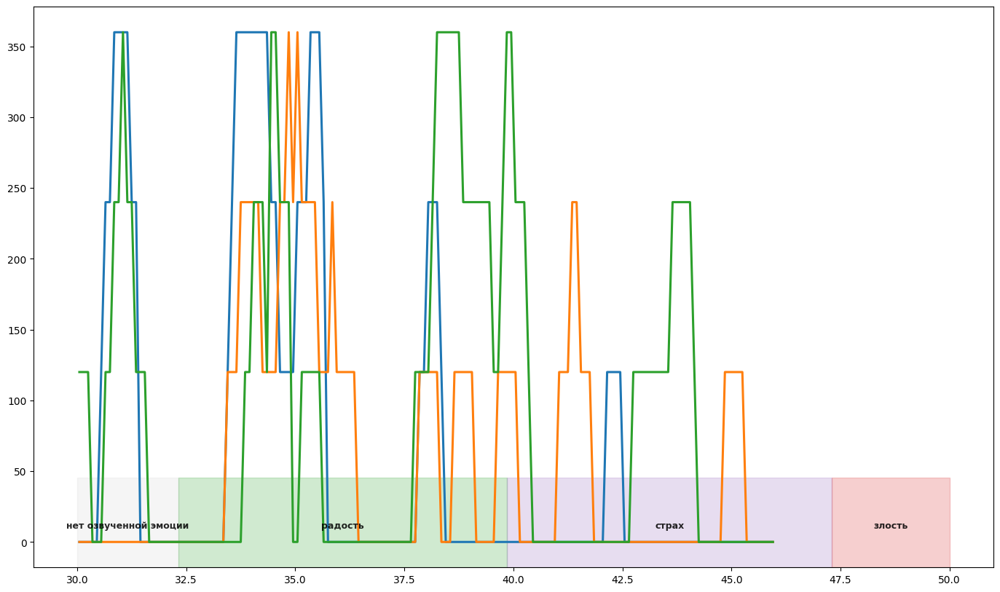

In [ ]:
# ЯЧЕЙКА 71
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert "UNKNOWN_TARGET" in globals(), "Нет UNKNOWN_TARGET."
assert "UNKNOWN_VISUALS" in globals(), "Нет UNKNOWN_VISUALS."
assert "ANOMALY_EMOTION_DF" in globals(), "Сначала выполните ячейку 70."
assert "EMOTION_INTERVALS_DF" in globals(), "Сначала выполните ячейку 69."

PLOT_PATH = "/content/drive/MyDrive/Staz/unknown_emotions_patterns.png"

# =========================================================
# 1. ДАННЫЕ
# =========================================================
plot_df = UNKNOWN_TARGET.copy()

TIME_COL = "timestamp"

selected_patterns = []
for _, row in ANOMALY_EMOTION_DF.sort_values("timestamp").iterrows():
    p = row["pattern"]
    if p not in selected_patterns:
        selected_patterns.append(p)

# =========================================================
# 2. ЦВЕТА ЭМОЦИЙ
# =========================================================
emotion_palette = {
    "радость": "tab:green",
    "грусть": "tab:blue",
    "страх": "tab:purple",
    "злость": "tab:red",
    "удивление": "tab:orange",
    "отвращение": "tab:brown",
    "нейтральность": "tab:gray"
}

# =========================================================
# 3. СТРОИМ ПОЛНУЮ ЭМОЦИОНАЛЬНУЮ ШКАЛУ
#
# Правило:
# последняя озвученная эмоция действует до начала
# следующей озвученной эмоции.
# =========================================================
emotion_df = (
    EMOTION_INTERVALS_DF
    .copy()
    .sort_values("start")
    .reset_index(drop=True)
)

emotion_segments = []

for i, row in emotion_df.iterrows():

    emotion = str(row["emotion"])
    start = max(float(row["start"]), EMOTION_START)

    if i + 1 < len(emotion_df):
        next_start = float(emotion_df.iloc[i + 1]["start"])
        end = min(next_start, EMOTION_END)
    else:
        end = EMOTION_END

    if end > start:
        emotion_segments.append({
            "start": start,
            "end": end,
            "emotion": emotion
        })

# До первой озвученной эмоции оставляем отдельную область
if len(emotion_df) > 0:
    first_start = float(emotion_df.iloc[0]["start"])

    if first_start > EMOTION_START:
        emotion_segments.insert(
            0,
            {
                "start": EMOTION_START,
                "end": min(first_start, EMOTION_END),
                "emotion": "нет озвученной эмоции"
            }
        )

# =========================================================
# 4. FIGURE
# =========================================================
fig, ax = plt.subplots(figsize=(17, 10))

# =========================================================
# 5. ЭМОЦИОНАЛЬНЫЕ ОБЛАСТИ
# =========================================================
emotion_labels = []

for seg in emotion_segments:

    start = float(seg["start"])
    end = float(seg["end"])
    emotion = seg["emotion"]

    if emotion == "нет озвученной эмоции":
        color = "lightgray"
        alpha = 0.22
    else:
        color = emotion_palette.get(
            emotion,
            "tab:pink"
        )
        alpha = 0.22

        if emotion not in emotion_labels:
            emotion_labels.append(emotion)

    # Основная цветная полоса эмоции
    ax.axvspan(
        start,
        end,
        ymin=0.0,
        ymax=0.16,
        color=color,
        alpha=alpha,
        zorder=0
    )

    # Подпись эмоции внутри полосы
    if end - start >= 0.8:
        ax.text(
            (start + end) / 2,
            0.075,
            emotion,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            alpha=0.85,
            zorder=5
        )

# =========================================================
# 6. КРИВЫЕ PXX
# =========================================================
pattern_colors = {}

for pattern in selected_patterns:

    if pattern not in plot_df.columns:
        continue

    sub = (
        plot_df[[TIME_COL, pattern]]
        .dropna()
        .sort_values(TIME_COL)
    )

    if len(sub) == 0:
        continue

    line, = ax.plot(
        sub[TIME_COL],
        sub[pattern],
        linewidth=2.2,
        label=pattern,
        zorder=3
    )

    pattern_colors[pattern] = line.get_color()

# =========================================================
# 7. Q95 / Q99
# =========================================================
for pattern in selected_patterns:

    if pattern not in pattern_colors:
        continue

    color = pattern_colors[pattern]

    ref = POPULATION_REFERENCE["patterns"][pattern]

    q95 = float(ref["q95"])
    q99 = float(ref["q99"])

    ax.axhline(
        q95,
        color=color,
        linestyle="--",
        linewidth=1.0,
        alpha=0.35,
        zorder=1
    )

    if q99 != q95:
        ax.axhline(
            q99,
            color=color,
            linestyle=":",
            linewidth=1.0,
            alpha=0.35,
            zorder=1
        )

# =========================================================
# 8. 4 АНОМАЛЬНЫЕ ТОЧКИ
# =========================================================
for i, (_, row) in enumerate(
    ANOMALY_EMOTION_DF
    .sort_values("timestamp")
    .iterrows(),
    start=1
):

    t = float(row["timestamp"])
    pattern = row["pattern"]
    value = float(row["pattern_value"])

    if pattern not in pattern_colors:
        continue

    color = pattern_colors[pattern]

    # вертикальная линия
    ax.axvline(
        t,
        color=color,
        linestyle="--",
        linewidth=1.4,
        alpha=0.7,
        zorder=2
    )

    # точка
    ax.scatter(
        [t],
        [value],
        s=125,
        color=color,
        edgecolor="black",
        linewidth=1.5,
        zorder=7
    )

    # номер точки
    ax.annotate(
        f"{i}: {t:.2f}s",
        xy=(t, value),
        xytext=(7, 9),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color=color,
        zorder=8
    )

# =========================================================
# 9. ПОДПИСИ ЭМОЦИЙ В ТОЧКАХ АНОМАЛИЙ
# =========================================================
ymin, ymax = ax.get_ylim()

for i, (_, row) in enumerate(
    ANOMALY_EMOTION_DF
    .sort_values("timestamp")
    .iterrows(),
    start=1
):

    t = float(row["timestamp"])
    emotion = str(row["emotion"])

    # цвет эмоции
    emotion_color = emotion_palette.get(
        emotion,
        "gray"
    )

    # небольшая подпись над нижней полосой
    ax.text(
        t,
        ymin + 0.19 * (ymax - ymin),
        emotion,
        rotation=90,
        ha="center",
        va="bottom",
        fontsize=8,
        color=emotion_color,
        fontweight="bold",
        alpha=0.9,
        zorder=6
    )

# =========================================================
# 10. ЛЕГЕНДА
# =========================================================
pattern_handles, pattern_labels = ax.get_legend_handles_labels()

emotion_handles = [
    Patch(
        facecolor=emotion_palette.get(e, "tab:pink"),
        alpha=0.35,
        label=f"Emotion: {e}"
    )
    for e in emotion_labels
]

if emotion_handles:
    ax.legend(
        handles=pattern_handles + emotion_handles,
        labels=pattern_labels +
               [f"Emotion: {e}" for e in emotion_labels],
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=True
    )
else:
    ax.legend(
        handles=pattern_handles,
        labels=pattern_labels,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=True
    )

# =========================================================
# 11. ОФОРМЛЕНИЕ
# =========================================================
ax.set_xlim(
    EMOTION_START,
    EMOTION_END
)

ax.set_xlabel(
    "Time (sec)",
    fontsize=11
)

ax.set_ylabel(
    "Raw pattern value",
    fontsize=11
)

ax.set_title(
    "Behavioral deviations vs. demonstrated emotional state",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.2,
    linewidth=0.8
)

plt.tight_layout()

# =========================================================
# 12. СОХРАНЕНИЕ
# =========================================================
plt.savefig(
    PLOT_PATH,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("\n=== ГОТОВО ===")
print(f"График: {PLOT_PATH}")

print("\nЭмоциональная шкала:")
for seg in emotion_segments:
    print(
        f"{seg['start']:.2f}–{seg['end']:.2f} сек | "
        f"{seg['emotion']}"
    )

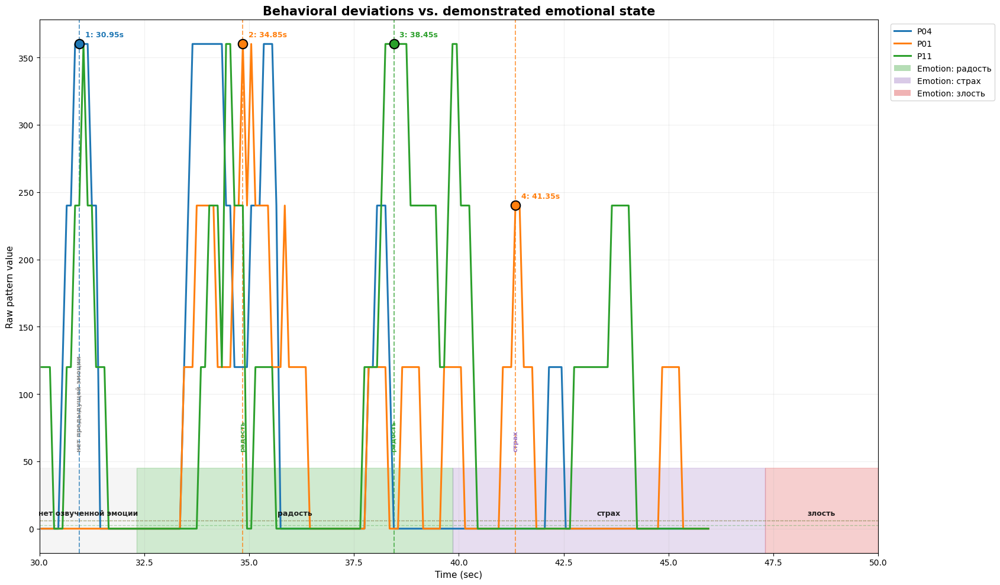

=== ГОТОВО ===
График сохранён: /content/drive/MyDrive/Staz/unknown_emotions_patterns.png

=== ЭМОЦИОНАЛЬНАЯ ШКАЛА ===
30.00–32.32 сек | нет озвученной эмоции
32.32–39.86 сек | радость
39.86–47.30 сек | страх
47.30–50.00 сек | злость


In [ ]:
# ЯЧЕЙКА 71
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert "UNKNOWN_TARGET" in globals(), "Нет UNKNOWN_TARGET."
assert "UNKNOWN_VISUALS" in globals(), "Нет UNKNOWN_VISUALS."
assert "ANOMALY_EMOTION_DF" in globals(), "Сначала выполните ячейку 70."
assert "EMOTION_INTERVALS_DF" in globals(), "Сначала выполните ячейку 69."
assert "POPULATION_REFERENCE" in globals(), "Нет POPULATION_REFERENCE."

PLOT_PATH = "/content/drive/MyDrive/Staz/unknown_emotions_patterns.png"

# =========================================================
# 1. ДАННЫЕ
# =========================================================
plot_df = UNKNOWN_TARGET.copy()
TIME_COL = "timestamp"

selected_patterns = []

for _, row in ANOMALY_EMOTION_DF.sort_values("timestamp").iterrows():
    p = row["pattern"]
    if p not in selected_patterns:
        selected_patterns.append(p)

# =========================================================
# 2. ЭМОЦИОНАЛЬНЫЕ ЦВЕТА
# =========================================================
emotion_palette = {
    "радость": "tab:green",
    "грусть": "tab:blue",
    "страх": "tab:purple",
    "злость": "tab:red",
    "удивление": "tab:orange",
    "отвращение": "tab:brown",
    "нейтральность": "tab:gray"
}

# =========================================================
# 3. ПОЛНАЯ ЭМОЦИОНАЛЬНАЯ ШКАЛА
# =========================================================
emotion_df = (
    EMOTION_INTERVALS_DF
    .copy()
    .sort_values("start")
    .reset_index(drop=True)
)

emotion_segments = []

for i, row in emotion_df.iterrows():

    emotion = str(row["emotion"])
    start = max(float(row["start"]), EMOTION_START)

    if i + 1 < len(emotion_df):
        end = min(
            float(emotion_df.iloc[i + 1]["start"]),
            EMOTION_END
        )
    else:
        end = EMOTION_END

    if end > start:
        emotion_segments.append({
            "start": start,
            "end": end,
            "emotion": emotion
        })

# До первой эмоции
if len(emotion_df) > 0:
    first_start = float(emotion_df.iloc[0]["start"])

    if first_start > EMOTION_START:
        emotion_segments.insert(
            0,
            {
                "start": EMOTION_START,
                "end": min(first_start, EMOTION_END),
                "emotion": "нет озвученной эмоции"
            }
        )

# =========================================================
# 4. FIGURE
# =========================================================
fig, ax = plt.subplots(figsize=(17, 10))

# =========================================================
# 5. ЭМОЦИОНАЛЬНАЯ ПОЛОСА
# =========================================================
emotion_labels = []

for seg in emotion_segments:

    start = float(seg["start"])
    end = float(seg["end"])
    emotion = seg["emotion"]

    if emotion == "нет озвученной эмоции":
        color = "lightgray"
        alpha = 0.22
    else:
        color = emotion_palette.get(
            emotion,
            "tab:pink"
        )
        alpha = 0.22

        if emotion not in emotion_labels:
            emotion_labels.append(emotion)

    ax.axvspan(
        start,
        end,
        ymin=0.0,
        ymax=0.16,
        color=color,
        alpha=alpha,
        zorder=0
    )

    if end - start >= 0.8:
        ax.text(
            (start + end) / 2,
            0.075,
            emotion,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            alpha=0.85,
            zorder=5
        )

# =========================================================
# 6. КРИВЫЕ PXX
# =========================================================
pattern_colors = {}

for pattern in selected_patterns:

    if pattern not in plot_df.columns:
        continue

    sub = (
        plot_df[[TIME_COL, pattern]]
        .dropna()
        .sort_values(TIME_COL)
    )

    if len(sub) == 0:
        continue

    line, = ax.plot(
        sub[TIME_COL],
        sub[pattern],
        linewidth=2.2,
        label=pattern,
        zorder=3
    )

    pattern_colors[pattern] = line.get_color()

# =========================================================
# 7. Q95 / Q99
#
# ВАЖНО:
# POPULATION_REFERENCE хранит q95/q99 отдельно,
# поэтому берём их напрямую.
# =========================================================
q95_ref = POPULATION_REFERENCE["q95"]
q99_ref = POPULATION_REFERENCE["q99"]

for pattern in selected_patterns:

    if pattern not in pattern_colors:
        continue

    # поддерживаем как dict, так и Series
    q95 = float(q95_ref[pattern])
    q99 = float(q99_ref[pattern])

    color = pattern_colors[pattern]

    ax.axhline(
        q95,
        color=color,
        linestyle="--",
        linewidth=1.0,
        alpha=0.35,
        zorder=1
    )

    if q99 != q95:
        ax.axhline(
            q99,
            color=color,
            linestyle=":",
            linewidth=1.0,
            alpha=0.35,
            zorder=1
        )

# =========================================================
# 8. 4 АНОМАЛЬНЫЕ ТОЧКИ
# =========================================================
for i, (_, row) in enumerate(
    ANOMALY_EMOTION_DF
    .sort_values("timestamp")
    .iterrows(),
    start=1
):

    t = float(row["timestamp"])
    pattern = row["pattern"]
    value = float(row["pattern_value"])

    if pattern not in pattern_colors:
        continue

    color = pattern_colors[pattern]

    ax.axvline(
        t,
        color=color,
        linestyle="--",
        linewidth=1.4,
        alpha=0.7,
        zorder=2
    )

    ax.scatter(
        [t],
        [value],
        s=125,
        color=color,
        edgecolor="black",
        linewidth=1.5,
        zorder=7
    )

    ax.annotate(
        f"{i}: {t:.2f}s",
        xy=(t, value),
        xytext=(7, 9),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color=color,
        zorder=8
    )

# =========================================================
# 9. ЭМОЦИЯ В ТОЧКЕ КАЖДОЙ АНОМАЛИИ
# =========================================================
ymin, ymax = ax.get_ylim()

for _, row in (
    ANOMALY_EMOTION_DF
    .sort_values("timestamp")
    .iterrows()
):

    t = float(row["timestamp"])
    emotion = str(row["emotion"])

    emotion_color = emotion_palette.get(
        emotion,
        "gray"
    )

    ax.text(
        t,
        ymin + 0.19 * (ymax - ymin),
        emotion,
        rotation=90,
        ha="center",
        va="bottom",
        fontsize=8,
        color=emotion_color,
        fontweight="bold",
        alpha=0.9,
        zorder=6
    )

# =========================================================
# 10. ЛЕГЕНДА
# =========================================================
pattern_handles, pattern_labels = ax.get_legend_handles_labels()

emotion_handles = [
    Patch(
        facecolor=emotion_palette.get(
            e,
            "tab:pink"
        ),
        alpha=0.35,
        label=f"Emotion: {e}"
    )
    for e in emotion_labels
]

if emotion_handles:
    ax.legend(
        handles=pattern_handles + emotion_handles,
        labels=pattern_labels +
               [f"Emotion: {e}" for e in emotion_labels],
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=True
    )
else:
    ax.legend(
        handles=pattern_handles,
        labels=pattern_labels,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=True
    )

# =========================================================
# 11. ОФОРМЛЕНИЕ
# =========================================================
ax.set_xlim(
    EMOTION_START,
    EMOTION_END
)

ax.set_xlabel(
    "Time (sec)",
    fontsize=11
)

ax.set_ylabel(
    "Raw pattern value",
    fontsize=11
)

ax.set_title(
    "Behavioral deviations vs. demonstrated emotional state",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.2,
    linewidth=0.8
)

plt.tight_layout()

# =========================================================
# 12. СОХРАНЕНИЕ
# =========================================================
plt.savefig(
    PLOT_PATH,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("=== ГОТОВО ===")
print(f"График сохранён: {PLOT_PATH}")

print("\n=== ЭМОЦИОНАЛЬНАЯ ШКАЛА ===")

for seg in emotion_segments:
    print(
        f"{seg['start']:.2f}–{seg['end']:.2f} сек | "
        f"{seg['emotion']}"
    )

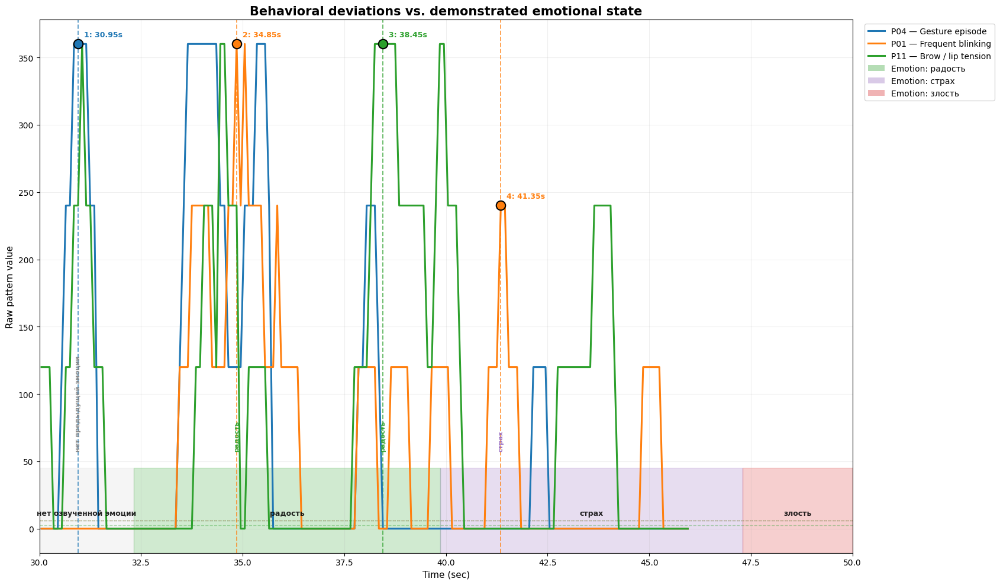

=== ГОТОВО ===
График сохранён: /content/drive/MyDrive/Staz/unknown_emotions_patterns.png

=== ЭМОЦИОНАЛЬНАЯ ШКАЛА ===
30.00–32.32 сек | нет озвученной эмоции
32.32–39.86 сек | радость
39.86–47.30 сек | страх
47.30–50.00 сек | злость


In [ ]:
# ЯЧЕЙКА 71
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert "UNKNOWN_TARGET" in globals(), "Нет UNKNOWN_TARGET."
assert "UNKNOWN_VISUALS" in globals(), "Нет UNKNOWN_VISUALS."
assert "ANOMALY_EMOTION_DF" in globals(), "Сначала выполните ячейку 70."
assert "EMOTION_INTERVALS_DF" in globals(), "Сначала выполните ячейку 69."
assert "POPULATION_REFERENCE" in globals(), "Нет POPULATION_REFERENCE."

PLOT_PATH = "/content/drive/MyDrive/Staz/unknown_emotions_patterns.png"

# =========================================================
# 1. НАЗВАНИЯ ПАТТЕРНОВ
# =========================================================
PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hands",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension",
    "P12": "Gaze direction"
}

# =========================================================
# 2. ДАННЫЕ
# =========================================================
plot_df = UNKNOWN_TARGET.copy()
TIME_COL = "timestamp"

selected_patterns = []

for _, row in ANOMALY_EMOTION_DF.sort_values("timestamp").iterrows():
    p = row["pattern"]

    if p not in selected_patterns:
        selected_patterns.append(p)

# =========================================================
# 3. ЦВЕТА ЭМОЦИЙ
# =========================================================
emotion_palette = {
    "радость": "tab:green",
    "грусть": "tab:blue",
    "страх": "tab:purple",
    "злость": "tab:red",
    "удивление": "tab:orange",
    "отвращение": "tab:brown",
    "нейтральность": "tab:gray"
}

# =========================================================
# 4. ПОЛНАЯ ЭМОЦИОНАЛЬНАЯ ШКАЛА
# =========================================================
emotion_df = (
    EMOTION_INTERVALS_DF
    .copy()
    .sort_values("start")
    .reset_index(drop=True)
)

emotion_segments = []

for i, row in emotion_df.iterrows():

    emotion = str(row["emotion"])
    start = max(float(row["start"]), EMOTION_START)

    if i + 1 < len(emotion_df):
        end = min(
            float(emotion_df.iloc[i + 1]["start"]),
            EMOTION_END
        )
    else:
        end = EMOTION_END

    if end > start:
        emotion_segments.append({
            "start": start,
            "end": end,
            "emotion": emotion
        })

# До первой озвученной эмоции
if len(emotion_df) > 0:

    first_start = float(
        emotion_df.iloc[0]["start"]
    )

    if first_start > EMOTION_START:

        emotion_segments.insert(
            0,
            {
                "start": EMOTION_START,
                "end": min(
                    first_start,
                    EMOTION_END
                ),
                "emotion": "нет озвученной эмоции"
            }
        )

# =========================================================
# 5. FIGURE
# =========================================================
fig, ax = plt.subplots(
    figsize=(17, 10)
)

# =========================================================
# 6. ЭМОЦИОНАЛЬНАЯ ПОЛОСА
# =========================================================
emotion_labels = []

for seg in emotion_segments:

    start = float(seg["start"])
    end = float(seg["end"])
    emotion = seg["emotion"]

    if emotion == "нет озвученной эмоции":

        color = "lightgray"
        alpha = 0.22

    else:

        color = emotion_palette.get(
            emotion,
            "tab:pink"
        )

        alpha = 0.22

        if emotion not in emotion_labels:
            emotion_labels.append(emotion)

    ax.axvspan(
        start,
        end,
        ymin=0.0,
        ymax=0.16,
        color=color,
        alpha=alpha,
        zorder=0
    )

    if end - start >= 0.8:

        ax.text(
            (start + end) / 2,
            0.075,
            emotion,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            alpha=0.85,
            zorder=5
        )

# =========================================================
# 7. КРИВЫЕ PXX
# =========================================================
pattern_colors = {}

for pattern in selected_patterns:

    if pattern not in plot_df.columns:
        continue

    sub = (
        plot_df[
            [TIME_COL, pattern]
        ]
        .dropna()
        .sort_values(TIME_COL)
    )

    if len(sub) == 0:
        continue

    pattern_label = (
        f"{pattern} — "
        f"{PATTERN_NAMES.get(pattern, pattern)}"
    )

    line, = ax.plot(
        sub[TIME_COL],
        sub[pattern],
        linewidth=2.2,
        label=pattern_label,
        zorder=3
    )

    pattern_colors[pattern] = line.get_color()

# =========================================================
# 8. Q95 / Q99
# =========================================================
q95_ref = POPULATION_REFERENCE["q95"]
q99_ref = POPULATION_REFERENCE["q99"]

for pattern in selected_patterns:

    if pattern not in pattern_colors:
        continue

    q95 = float(q95_ref[pattern])
    q99 = float(q99_ref[pattern])

    color = pattern_colors[pattern]

    ax.axhline(
        q95,
        color=color,
        linestyle="--",
        linewidth=1.0,
        alpha=0.35,
        zorder=1
    )

    if q99 != q95:

        ax.axhline(
            q99,
            color=color,
            linestyle=":",
            linewidth=1.0,
            alpha=0.35,
            zorder=1
        )

# =========================================================
# 9. 4 АНОМАЛЬНЫЕ ТОЧКИ
# =========================================================
for i, (_, row) in enumerate(
    ANOMALY_EMOTION_DF
    .sort_values("timestamp")
    .iterrows(),
    start=1
):

    t = float(row["timestamp"])
    pattern = row["pattern"]
    value = float(row["pattern_value"])

    if pattern not in pattern_colors:
        continue

    color = pattern_colors[pattern]

    ax.axvline(
        t,
        color=color,
        linestyle="--",
        linewidth=1.4,
        alpha=0.7,
        zorder=2
    )

    ax.scatter(
        [t],
        [value],
        s=125,
        color=color,
        edgecolor="black",
        linewidth=1.5,
        zorder=7
    )

    ax.annotate(
        f"{i}: {t:.2f}s",
        xy=(t, value),
        xytext=(7, 9),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color=color,
        zorder=8
    )

# =========================================================
# 10. ЭМОЦИЯ В КАЖДОЙ АНОМАЛЬНОЙ ТОЧКЕ
# =========================================================
ymin, ymax = ax.get_ylim()

for _, row in (
    ANOMALY_EMOTION_DF
    .sort_values("timestamp")
    .iterrows()
):

    t = float(row["timestamp"])
    emotion = str(row["emotion"])

    emotion_color = emotion_palette.get(
        emotion,
        "gray"
    )

    ax.text(
        t,
        ymin + 0.19 * (ymax - ymin),
        emotion,
        rotation=90,
        ha="center",
        va="bottom",
        fontsize=8,
        color=emotion_color,
        fontweight="bold",
        alpha=0.9,
        zorder=6
    )

# =========================================================
# 11. ЛЕГЕНДА
# =========================================================
pattern_handles, pattern_labels = (
    ax.get_legend_handles_labels()
)

emotion_handles = [
    Patch(
        facecolor=emotion_palette.get(
            e,
            "tab:pink"
        ),
        alpha=0.35,
        label=f"Emotion: {e}"
    )
    for e in emotion_labels
]

ax.legend(
    handles=pattern_handles + emotion_handles,
    labels=pattern_labels +
           [
               f"Emotion: {e}"
               for e in emotion_labels
           ],
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True
)

# =========================================================
# 12. ОФОРМЛЕНИЕ
# =========================================================
ax.set_xlim(
    EMOTION_START,
    EMOTION_END
)

ax.set_xlabel(
    "Time (sec)",
    fontsize=11
)

ax.set_ylabel(
    "Raw pattern value",
    fontsize=11
)

ax.set_title(
    "Behavioral deviations vs. demonstrated emotional state",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.2,
    linewidth=0.8
)

plt.tight_layout()

# =========================================================
# 13. СОХРАНЕНИЕ
# =========================================================
plt.savefig(
    PLOT_PATH,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("=== ГОТОВО ===")
print(f"График сохранён: {PLOT_PATH}")

print("\n=== ЭМОЦИОНАЛЬНАЯ ШКАЛА ===")

for seg in emotion_segments:

    print(
        f"{seg['start']:.2f}–"
        f"{seg['end']:.2f} сек | "
        f"{seg['emotion']}"
    )

In [ ]:
# ЯЧЕЙКА 73
import os
import numpy as np
import pandas as pd

NEW_VIDEO_NAME = input(
    "Введите имя видеофайла в /content/drive/MyDrive/Staz/: "
).strip()

NEW_START = float(
    input("Введите начало интервала, сек: ").strip()
)

NEW_END = float(
    input("Введите конец интервала, сек: ").strip()
)

NEW_VIDEO_PATH = os.path.join(
    "/content/drive/MyDrive/Staz",
    NEW_VIDEO_NAME
)

assert os.path.exists(
    NEW_VIDEO_PATH
), f"Файл не найден: {NEW_VIDEO_PATH}"

assert NEW_START >= 0, "Начало интервала должно быть >= 0."
assert NEW_END > NEW_START, "Конец должен быть больше начала."

print("\n=== НОВОЕ НЕИЗВЕСТНОЕ ВИДЕО ===")
print("Файл:", NEW_VIDEO_NAME)
print(f"Интервал: {NEW_START:.2f}–{NEW_END:.2f} сек")

Введите имя видеофайла в /content/drive/MyDrive/Staz/: 3.mp4
Введите начало интервала, сек: 34
Введите конец интервала, сек: 59

=== НОВОЕ НЕИЗВЕСТНОЕ ВИДЕО ===
Файл: 3.mp4
Интервал: 34.00–59.00 сек


In [ ]:
# ЯЧЕЙКА 73
import os

NEW_VIDEO_INPUT = input(
    "Введите имя видео или полный путь к видео: "
).strip()

NEW_START = float(
    input("Начало интервала, сек: ").strip()
)

NEW_END = float(
    input("Конец интервала, сек: ").strip()
)

# Если введено только имя файла — ищем его в Staz.
if os.path.isabs(NEW_VIDEO_INPUT):
    NEW_VIDEO_PATH = NEW_VIDEO_INPUT
else:
    NEW_VIDEO_PATH = os.path.join(
        "/content/drive/MyDrive/Staz",
        NEW_VIDEO_INPUT
    )

# Если пользователь ввёл имя без .mp4 — пробуем добавить расширение.
if not os.path.exists(NEW_VIDEO_PATH):
    if not NEW_VIDEO_INPUT.lower().endswith(".mp4"):
        candidate = NEW_VIDEO_PATH + ".mp4"
        if os.path.exists(candidate):
            NEW_VIDEO_PATH = candidate

assert os.path.exists(NEW_VIDEO_PATH), (
    f"Видео не найдено:\n{NEW_VIDEO_PATH}\n\n"
    "Проверьте имя файла в /content/drive/MyDrive/Staz/"
)

# Имя файла используем как ключ VIDEO_PATHS.
NEW_VIDEO_NAME = os.path.basename(NEW_VIDEO_PATH)

# Добавляем новое видео в существующий словарь,
# не меняя логику P01–P12 и extract_video().
VIDEO_PATHS[NEW_VIDEO_NAME] = NEW_VIDEO_PATH

NEW_SAFE_NAME = os.path.splitext(
    NEW_VIDEO_NAME
)[0]

assert NEW_START >= 0, (
    "Начало интервала должно быть >= 0."
)

assert NEW_END > NEW_START, (
    "Конец интервала должен быть больше начала."
)

print("=== НОВОЕ ВИДЕО ===")
print("Имя:", NEW_VIDEO_NAME)
print("Путь:", NEW_VIDEO_PATH)
print(f"Интервал: {NEW_START:.2f}–{NEW_END:.2f} сек")
print("Видео добавлено в VIDEO_PATHS.")

Введите имя видео или полный путь к видео: 3.mp4
Начало интервала, сек: 34
Конец интервала, сек: 59
=== НОВОЕ ВИДЕО ===
Имя: 3.mp4
Путь: /content/drive/MyDrive/Staz/3.mp4
Интервал: 34.00–59.00 сек
Видео добавлено в VIDEO_PATHS.


In [ ]:
# ЯЧЕЙКА 74
NEW_RAW, NEW_FPS = extract_video(
    NEW_VIDEO_NAME
)

NEW_WINDOWS = build_window_dataset(
    NEW_RAW,
    NEW_FPS,
    False
)

NEW_DURATION = float(
    NEW_RAW["time_sec"].max()
)

assert NEW_END <= NEW_DURATION, (
    f"Конец интервала {NEW_END:.2f} сек "
    f"выходит за длительность видео "
    f"{NEW_DURATION:.2f} сек."
)

print("=== ИЗВЛЕЧЕНИЕ ЗАВЕРШЕНО ===")
print("Файл:", NEW_VIDEO_NAME)
print("Кадров:", len(NEW_RAW))
print("FPS:", NEW_FPS)
print(f"Длительность: {NEW_DURATION:.2f} сек")
print("Окон P01–P12:", len(NEW_WINDOWS))

TypeError: build_window_dataset() takes 2 positional arguments but 3 were given

In [ ]:
# ЯЧЕЙКА 74
NEW_WINDOWS = build_window_dataset(
    NEW_RAW,
    NEW_FPS
)

NEW_DURATION = float(
    NEW_RAW["time_sec"].max()
)

assert NEW_END <= NEW_DURATION, (
    f"Конец интервала {NEW_END:.2f} сек "
    f"выходит за длительность видео "
    f"{NEW_DURATION:.2f} сек."
)

print("=== ИЗВЛЕЧЕНИЕ ЗАВЕРШЕНО ===")
print("Файл:", NEW_VIDEO_NAME)
print("Кадров:", len(NEW_RAW))
print("FPS:", NEW_FPS)
print(f"Длительность: {NEW_DURATION:.2f} сек")
print("Окон P01–P12:", len(NEW_WINDOWS))

=== ИЗВЛЕЧЕНИЕ ЗАВЕРШЕНО ===
Файл: 3.mp4
Кадров: 2175
FPS: 30.0
Длительность: 72.47 сек
Окон P01–P12: 720


In [ ]:
# ЯЧЕЙКА 75
PATTERN_COLS = [
    "P01", "P02", "P03", "P04", "P05", "P06",
    "P07", "P08", "P09", "P10", "P11"
]

ACTIVE_PATTERN_COLS = [
    "P01", "P03", "P04", "P05",
    "P06", "P07", "P08", "P09",
    "P10", "P11"
]

UNKNOWN_TARGET = NEW_WINDOWS[
    (NEW_WINDOWS["timestamp"] >= NEW_START) &
    (NEW_WINDOWS["timestamp"] <= NEW_END)
].copy()

assert len(UNKNOWN_TARGET) > 0, (
    "В заданном интервале нет окон."
)

for p in ACTIVE_PATTERN_COLS:
    assert p in UNKNOWN_TARGET.columns, (
        f"Не найден паттерн {p}"
    )

assert "P02" not in ACTIVE_PATTERN_COLS

print("=== ЦЕЛЕВОЙ ИНТЕРВАЛ ===")
print(
    f"Окон: {len(UNKNOWN_TARGET)}"
)
print(
    f"Время: "
    f"{UNKNOWN_TARGET['timestamp'].min():.2f}–"
    f"{UNKNOWN_TARGET['timestamp'].max():.2f} сек"
)

print("\nПаттерны:")
print(", ".join(ACTIVE_PATTERN_COLS))
print("\nP02 исключён из anomaly score.")
print("P12 используется только как описательный контекст.")

=== ЦЕЛЕВОЙ ИНТЕРВАЛ ===
Окон: 250
Время: 34.05–58.95 сек

Паттерны:
P01, P03, P04, P05, P06, P07, P08, P09, P10, P11

P02 исключён из anomaly score.
P12 используется только как описательный контекст.


In [ ]:
# ЯЧЕЙКА 76
import numpy as np
import pandas as pd

assert "POPULATION_REFERENCE" in globals(), (
    "Нет frozen POPULATION_REFERENCE."
)

Q95 = POPULATION_REFERENCE["q95"]
Q99 = POPULATION_REFERENCE["q99"]

assert "P01" in Q95
assert "P11" in Q95

# ---------------------------------------------------------
# SCORE ДЛЯ ОДНОГО ЗНАЧЕНИЯ
# ---------------------------------------------------------
def frozen_pattern_score(value, q95, q99):
    value = float(value)
    q95 = float(q95)
    q99 = float(q99)

    if not np.isfinite(value):
        return 0.0

    if q99 > q95:

        if value >= q99:
            return 1.0

        if value > q95:
            return (
                (value - q95) /
                (q99 - q95)
            )

        return 0.0

    else:

        if value > q95:
            return 1.0

        return 0.0


# ---------------------------------------------------------
# SCORE ВСЕХ ОКОН
# ---------------------------------------------------------
UNKNOWN_SCORES = UNKNOWN_TARGET.copy()

for pattern in ACTIVE_PATTERN_COLS:

    scores = []

    for value in UNKNOWN_TARGET[pattern]:

        s = frozen_pattern_score(
            value,
            Q95[pattern],
            Q99[pattern]
        )

        scores.append(s * 100.0)

    UNKNOWN_SCORES[
        f"{pattern}_anomaly"
    ] = scores

ANOMALY_SCORE_COLS = [
    f"{p}_anomaly"
    for p in ACTIVE_PATTERN_COLS
]

UNKNOWN_SCORES["anomaly_score"] = (
    UNKNOWN_SCORES[ANOMALY_SCORE_COLS]
    .max(axis=1)
)

UNKNOWN_SCORES["dominant_pattern"] = (
    UNKNOWN_SCORES[ANOMALY_SCORE_COLS]
    .idxmax(axis=1)
    .str.replace("_anomaly", "", regex=False)
)

print("=== FROZEN REFERENCE SCORING ===")
print(
    f"Окон: {len(UNKNOWN_SCORES)}"
)

display(
    UNKNOWN_SCORES[
        [
            "timestamp",
            "anomaly_score",
            "dominant_pattern"
        ]
    ].head()
)

=== FROZEN REFERENCE SCORING ===
Окон: 250


,timestamp,anomaly_score,dominant_pattern
338,34.05,100.0,P03
339,34.15,100.0,P03
340,34.25,100.0,P03
341,34.35,100.0,P03
342,34.45,100.0,P03


In [ ]:
# ЯЧЕЙКА 77
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hands",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension"
}

candidates = []

for pattern in ACTIVE_PATTERN_COLS:

    values = pd.to_numeric(
        UNKNOWN_TARGET[pattern],
        errors="coerce"
    ).fillna(0).to_numpy()

    if len(values) == 0:
        continue

    # Локальные максимумы
    peaks, _ = find_peaks(values)

    # Добавляем глобальный максимум,
    # если find_peaks его не обнаружил.
    global_idx = int(
        np.argmax(values)
    )

    if global_idx not in peaks:
        peaks = np.append(
            peaks,
            global_idx
        )

    for idx in peaks:

        value = float(values[idx])

        if not np.isfinite(value):
            continue

        timestamp = float(
            UNKNOWN_TARGET.iloc[idx]["timestamp"]
        )

        q95 = float(Q95[pattern])
        q99 = float(Q99[pattern])

        scale = max(
            abs(q95),
            abs(q99),
            1e-6
        )

        relative_strength = (
            value / scale
        )

        excess_q95 = value - q95
        excess_q99 = value - q99

        candidates.append({
            "timestamp": timestamp,
            "pattern": pattern,
            "pattern_name": PATTERN_NAMES.get(
                pattern,
                pattern
            ),
            "pattern_value": value,
            "q95": q95,
            "q99": q99,
            "excess_q95": excess_q95,
            "excess_q99": excess_q99,
            "relative_strength": relative_strength,
            "anomaly_score": float(
                UNKNOWN_SCORES.iloc[idx]["anomaly_score"]
            )
        })

CANDIDATES_DF = pd.DataFrame(
    candidates
)

assert len(CANDIDATES_DF) > 0, (
    "Не удалось найти пики."
)

# ---------------------------------------------------------
# УДАЛЯЕМ СЛИШКОМ БЛИЗКИЕ ТОЧКИ
# ---------------------------------------------------------
CANDIDATES_DF = (
    CANDIDATES_DF
    .sort_values(
        [
            "relative_strength",
            "excess_q99",
            "pattern_value"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

MIN_SEPARATION_SEC = 2.0

selected = []

for _, row in CANDIDATES_DF.iterrows():

    t = float(row["timestamp"])

    if all(
        abs(
            t - float(x["timestamp"])
        ) >= MIN_SEPARATION_SEC
        for x in selected
    ):
        selected.append(
            row.to_dict()
        )

    if len(selected) == 4:
        break

# Если из-за расстояния меньше 4,
# добираем наиболее сильные оставшиеся.
if len(selected) < 4:

    used_times = {
        round(float(x["timestamp"]), 6)
        for x in selected
    }

    for _, row in CANDIDATES_DF.iterrows():

        t = float(row["timestamp"])

        if round(t, 6) in used_times:
            continue

        selected.append(
            row.to_dict()
        )

        used_times.add(
            round(t, 6)
        )

        if len(selected) == 4:
            break

UNKNOWN_VISUALS = pd.DataFrame(
    selected
).sort_values(
    "timestamp"
).reset_index(drop=True)

assert len(UNKNOWN_VISUALS) == 4, (
    f"Выбрано {len(UNKNOWN_VISUALS)} кадров вместо 4."
)

print(
    "=== ВЫБОР ВИЗУАЛЬНЫХ ДОКАЗАТЕЛЬСТВ ==="
)

display(
    UNKNOWN_VISUALS[
        [
            "timestamp",
            "pattern",
            "pattern_name",
            "pattern_value",
            "q95",
            "q99",
            "anomaly_score"
        ]
    ]
)

=== ВЫБОР ВИЗУАЛЬНЫХ ДОКАЗАТЕЛЬСТВ ===


,timestamp,pattern,pattern_name,pattern_value,q95,q99,anomaly_score
0,36.05,P04,Gesture episode,600.0,6.0,6.0,100.0
1,40.55,P04,Gesture episode,480.0,6.0,6.0,100.0
2,50.45,P04,Gesture episode,720.0,6.0,6.0,100.0
3,54.15,P04,Gesture episode,600.0,6.0,6.0,100.0


In [ ]:
# ЯЧЕЙКА 78
# Frozen population scoring для нового видео.
# P02 исключён из anomaly score.
# P12 используется только как описательный признак.

NUMERIC_ANOMALY_PATTERNS = [
    "P01",
    "P03",
    "P04",
    "P05",
    "P06",
    "P07",
    "P08",
    "P09",
    "P10",
    "P11",
]

PATTERN_NAMES = {
    "P01": "Frequent blinking",
    "P03": "Head movement",
    "P04": "Gesture episode",
    "P05": "Gesture amplitude",
    "P06": "Hand near face",
    "P07": "Repetitive micro movements",
    "P08": "Crossed / center hands",
    "P09": "Posture shift",
    "P10": "Lip corner raise",
    "P11": "Brow / lip tension",
}

# Проверяем frozen reference до расчёта.
assert "q95" in POPULATION_REFERENCE
assert "q99" in POPULATION_REFERENCE

for pattern in NUMERIC_ANOMALY_PATTERNS:
    assert pattern in POPULATION_REFERENCE["q95"], (
        f"В POPULATION_REFERENCE отсутствует q95 для {pattern}"
    )
    assert pattern in POPULATION_REFERENCE["q99"], (
        f"В POPULATION_REFERENCE отсутствует q99 для {pattern}"
    )

# Окна только внутри заданного целевого интервала.
NEW_TARGET_WINDOWS = NEW_WINDOWS[
    (NEW_WINDOWS["timestamp"] >= NEW_START) &
    (NEW_WINDOWS["timestamp"] <= NEW_END)
].copy()

assert len(NEW_TARGET_WINDOWS) > 0, (
    "В заданном интервале нет окон."
)

def reference_anomaly_score(value, q95, q99):
    """
    Точная frozen-reference логика:
    - ниже/на q95 -> 0
    - между q95 и q99 -> линейный рост 0..1
    - >= q99 -> 1
    - если q95 == q99 и значение выше q95 -> 1
    """
    if not np.isfinite(value):
        return 0.0

    if q99 > q95:
        if value <= q95:
            return 0.0
        if value >= q99:
            return 1.0
        return float((value - q95) / (q99 - q95))

    if value > q95:
        return 1.0

    return 0.0


score_rows = []

for _, row in NEW_TARGET_WINDOWS.iterrows():

    result = {
        "timestamp": float(row["timestamp"]),
    }

    pattern_scores = {}

    for pattern in NUMERIC_ANOMALY_PATTERNS:

        value = float(row[pattern])

        q95 = float(
            POPULATION_REFERENCE["q95"][pattern]
        )

        q99 = float(
            POPULATION_REFERENCE["q99"][pattern]
        )

        score = reference_anomaly_score(
            value,
            q95,
            q99
        )

        result[pattern] = value
        result[f"{pattern}_score"] = score * 100.0

        pattern_scores[pattern] = score * 100.0

    # Итоговый anomaly score = максимум по P01–P11,
    # P02 исключён.
    if pattern_scores:
        dominant_pattern = max(
            pattern_scores,
            key=pattern_scores.get
        )

        anomaly_score = pattern_scores[
            dominant_pattern
        ]
    else:
        dominant_pattern = None
        anomaly_score = 0.0

    result["dominant_pattern"] = dominant_pattern
    result["dominant_pattern_name"] = (
        PATTERN_NAMES.get(
            dominant_pattern,
            dominant_pattern
        )
        if dominant_pattern is not None
        else None
    )

    result["anomaly_score"] = float(
        anomaly_score
    )

    score_rows.append(result)


NEW_SCORES = pd.DataFrame(score_rows)

assert len(NEW_SCORES) == len(
    NEW_TARGET_WINDOWS
)

print("=== FROZEN POPULATION SCORING ===")
print("Видео:", NEW_VIDEO_NAME)
print(
    f"Целевой интервал: "
    f"{NEW_START:.2f}–{NEW_END:.2f} сек"
)
print("Целевых окон:", len(NEW_SCORES))
print(
    "P02 в anomaly score: НЕТ"
)
print(
    "P12: описательный, "
    "не входит в anomaly score"
)

display(
    NEW_SCORES[
        [
            "timestamp",
            "dominant_pattern",
            "dominant_pattern_name",
            "anomaly_score",
        ]
    ].head(10).round(3)
)

=== FROZEN POPULATION SCORING ===
Видео: 3.mp4
Целевой интервал: 34.00–59.00 сек
Целевых окон: 250
P02 в anomaly score: НЕТ
P12: описательный, не входит в anomaly score


,timestamp,dominant_pattern,dominant_pattern_name,anomaly_score
0,34.05,P03,Head movement,100.0
1,34.15,P03,Head movement,100.0
2,34.25,P03,Head movement,100.0
3,34.35,P03,Head movement,100.0
4,34.45,P03,Head movement,100.0
5,34.55,P03,Head movement,100.0
6,34.65,P03,Head movement,100.0
7,34.75,P03,Head movement,100.0
8,34.85,P03,Head movement,100.0
9,34.95,P03,Head movement,100.0


=== АУДИО ===
Файл: /content/drive/MyDrive/Staz/emotion_3.wav
Интервал: 34.00–59.00 сек



=== РАСПОЗНАННЫЕ ЭМОЦИИ ===


,start,end,emotion,text
0,35.87,58.07,страх,"сильный испук, страх, гнев, возмущения, умелен..."



=== 4 ВИЗУАЛЬНЫХ ПРИМЕРА ===


,timestamp,pattern,pattern_name,value,q95,excess_q95,anomaly_score,emotion,emotion_source,big5_context
0,36.05,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context
1,50.45,P04,Gesture episode,720.0,6.0,714.0,100.0,страх,spoken_at_anomaly,Extraversion context
2,52.45,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context
3,55.35,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context



Сохранено кадров: 4
Папка: /content/drive/MyDrive/Staz/visuals_3


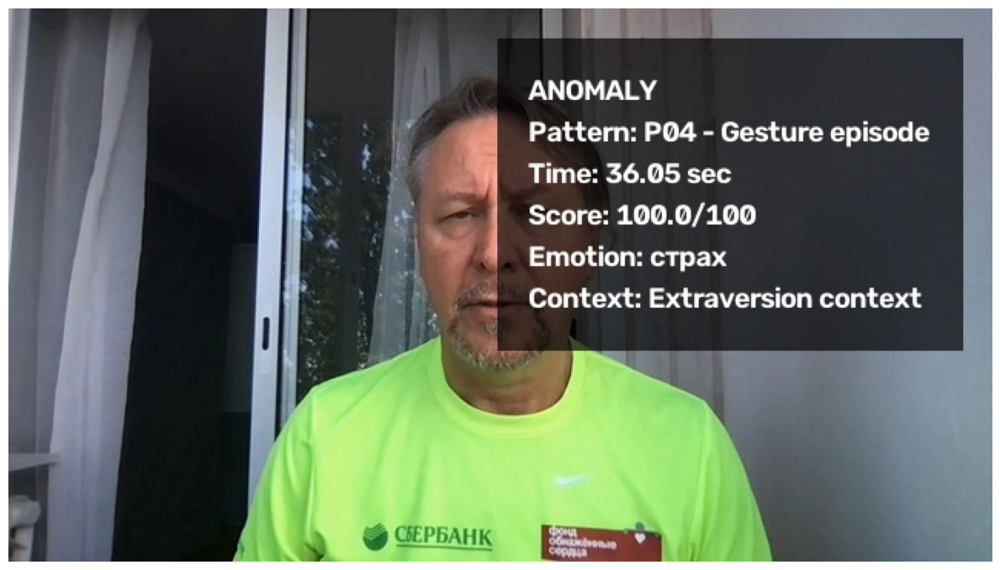

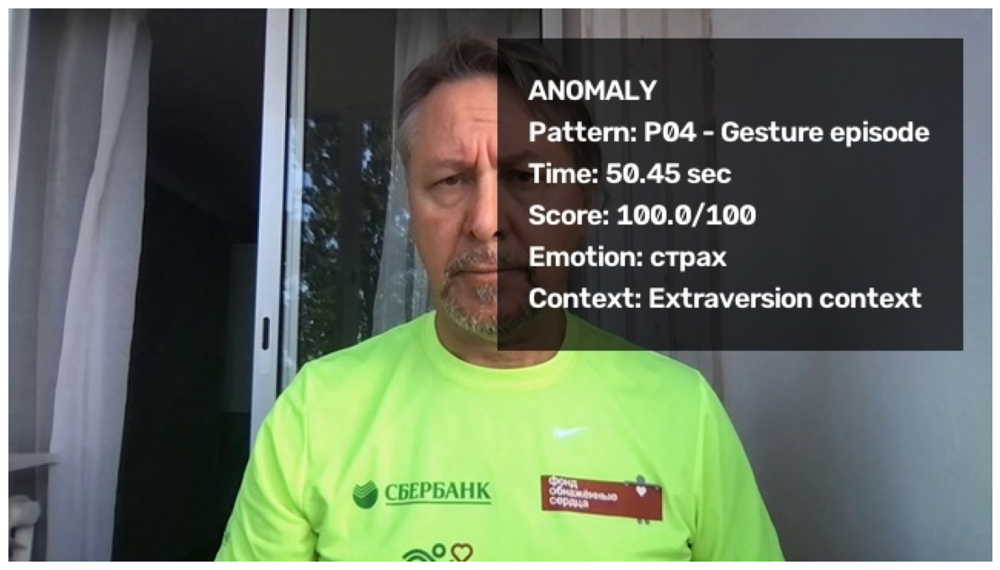

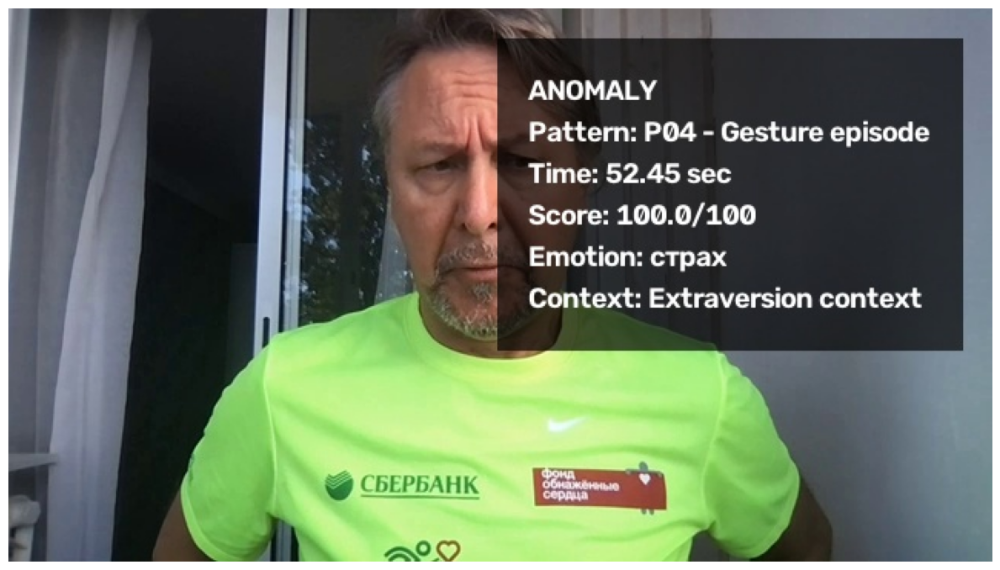

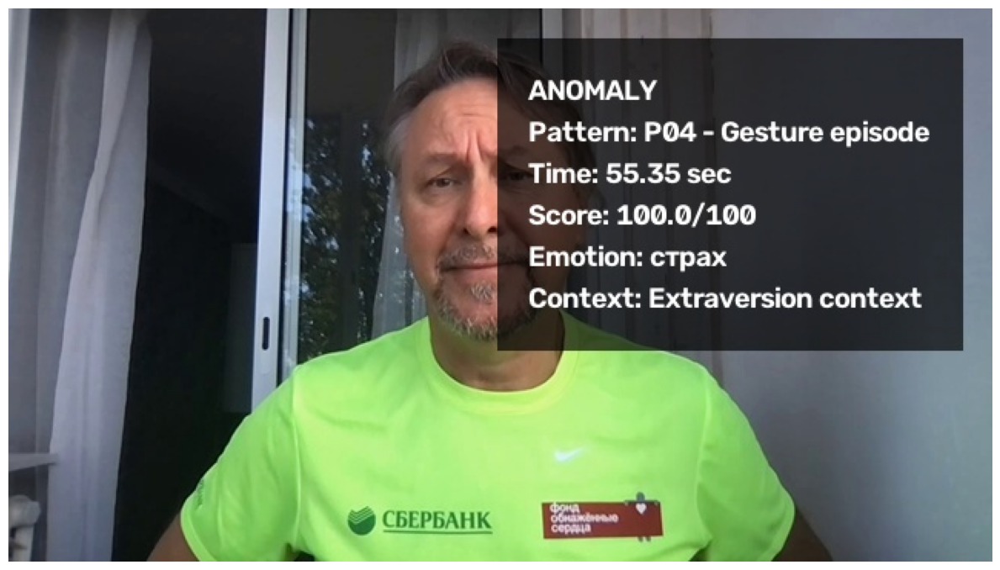


=== ЭМОЦИОНАЛЬНЫЙ TIMELINE ===


,start,end,emotion,text
0,35.87,58.07,страх,"сильный испук, страх, гнев, возмущения, умелен..."


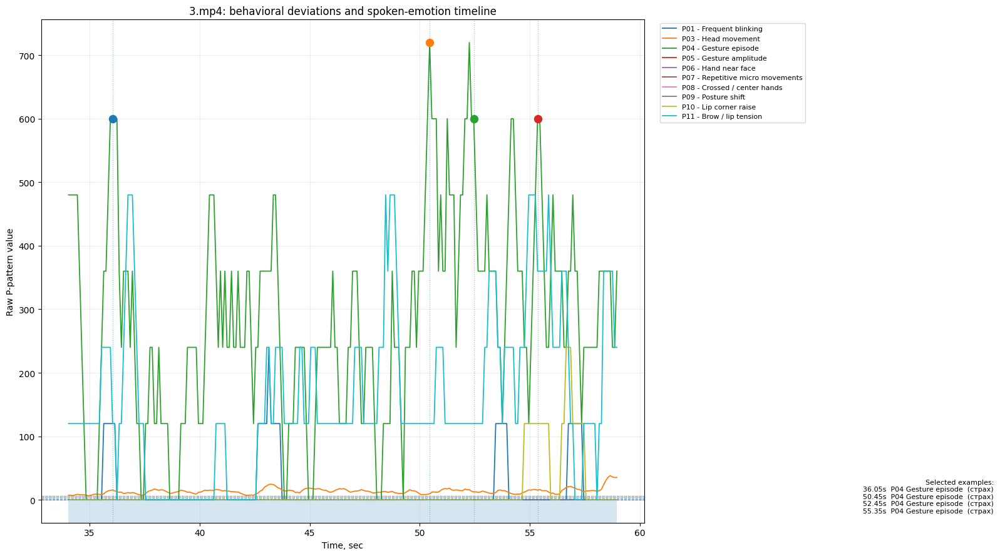


График сохранён: /content/drive/MyDrive/Staz/3_emotions_patterns.png

=== ГОТОВО ===
Видео: 3.mp4
Целевой интервал: 34.00–59.00 сек
Окон в scoring: 250
Выбрано визуальных примеров: 4

Сохранено:
 - /content/drive/MyDrive/Staz/3_results.csv
 - /content/drive/MyDrive/Staz/3_scores.csv
 - /content/drive/MyDrive/Staz/3_visuals.csv
 - /content/drive/MyDrive/Staz/3_emotions_patterns.png
 - /content/drive/MyDrive/Staz/visuals_3

=== ИТОГОВЫЕ АНОМАЛЬНЫЕ ТОЧКИ ===


,timestamp,pattern,pattern_name,value,anomaly_score,emotion,emotion_source,big5_context
0,36.05,P04,Gesture episode,600.0,100.0,страх,spoken_at_anomaly,Extraversion context
1,50.45,P04,Gesture episode,720.0,100.0,страх,spoken_at_anomaly,Extraversion context
2,52.45,P04,Gesture episode,600.0,100.0,страх,spoken_at_anomaly,Extraversion context
3,55.35,P04,Gesture episode,600.0,100.0,страх,spoken_at_anomaly,Extraversion context


In [ ]:
# ЯЧЕЙКА 79–83
import os
import re
import subprocess
import sys
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Audio

# ============================================================
# 79. АУДИО + РАСПОЗНАВАНИЕ ЭМОЦИЙ
# ============================================================

EMOTION_AUDIO_PATH = os.path.join(
    STAZ_FOLDER,
    f"emotion_{NEW_SAFE_NAME}.wav"
)

# Извлекаем только целевой аудио-интервал.
subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-ss", str(NEW_START),
        "-to", str(NEW_END),
        "-i", NEW_VIDEO_PATH,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        EMOTION_AUDIO_PATH,
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=True
)

print("=== АУДИО ===")
print("Файл:", EMOTION_AUDIO_PATH)
print(
    f"Интервал: {NEW_START:.2f}–{NEW_END:.2f} сек"
)

display(Audio(EMOTION_AUDIO_PATH))

try:
    from faster_whisper import WhisperModel
except ImportError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "faster-whisper"
        ],
        check=True
    )
    from faster_whisper import WhisperModel

whisper_model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

segments, info = whisper_model.transcribe(
    EMOTION_AUDIO_PATH,
    language="ru",
    beam_size=5,
    vad_filter=True,
    word_timestamps=True
)

emotion_keywords = {
    "радость": [
        "радость", "радост", "счастье", "счастлив",
        "веселье", "весёл", "смех", "смеюсь"
    ],
    "грусть": [
        "грусть", "груст", "печаль", "печальн"
    ],
    "страх": [
        "страх", "страшно", "испуг", "испугал",
        "испугалась", "испугался"
    ],
    "злость": [
        "злость", "злой", "злая", "злиться",
        "гнев", "раздражен", "раздражение"
    ],
    "удивление": [
        "удивление", "удивлен", "удивилась",
        "удивился", "удивительно"
    ],
    "отвращение": [
        "отвращение", "отврат", "противно"
    ],
    "нейтральность": [
        "нейтраль", "нейтрально"
    ],
}

def detect_spoken_emotion(text):
    text = str(text).lower()

    found = []

    for emotion, words in emotion_keywords.items():
        for word in words:
            if word in text:
                found.append(emotion)
                break

    if not found:
        return None

    return found[0]


emotion_events = []

for segment in segments:
    seg_text = segment.text.strip()

    emotion = detect_spoken_emotion(seg_text)

    if emotion is not None:
        start_abs = NEW_START + float(segment.start)
        end_abs = NEW_START + float(segment.end)

        emotion_events.append(
            {
                "start": start_abs,
                "end": end_abs,
                "emotion": emotion,
                "text": seg_text,
            }
        )

EMOTION_EVENTS_DF = pd.DataFrame(
    emotion_events
)

# ------------------------------------------------------------
# Объединяем близкие упоминания одной и той же эмоции.
# ------------------------------------------------------------

merged_events = []

for event in emotion_events:

    if not merged_events:
        merged_events.append(event.copy())
        continue

    previous = merged_events[-1]

    if (
        event["emotion"] == previous["emotion"]
        and event["start"] - previous["end"] <= 1.5
    ):
        previous["end"] = event["end"]
        previous["text"] = (
            previous["text"] + " " + event["text"]
        )
    else:
        merged_events.append(event.copy())

EMOTION_INTERVALS_DF = pd.DataFrame(
    merged_events,
    columns=[
        "start",
        "end",
        "emotion",
        "text",
    ]
)

print()
print("=== РАСПОЗНАННЫЕ ЭМОЦИИ ===")

if EMOTION_INTERVALS_DF.empty:
    print(
        "В целевом интервале явных названий эмоций "
        "в речи не найдено."
    )
else:
    display(
        EMOTION_INTERVALS_DF.round(
            {"start": 2, "end": 2}
        )
    )


def emotion_for_time(t):
    """
    Правило:
    1. Если в момент t есть явно произнесённая эмоция,
       используем её.
    2. Иначе берём последнюю эмоцию,
       произнесённую ДО этого момента.
    3. До первой эмоции — нет озвученной эмоции.
    """

    if EMOTION_INTERVALS_DF.empty:
        return (
            "нет озвученной эмоции",
            "no_spoken_emotion"
        )

    exact = EMOTION_INTERVALS_DF[
        (EMOTION_INTERVALS_DF["start"] <= t) &
        (EMOTION_INTERVALS_DF["end"] >= t)
    ]

    if len(exact):
        return (
            exact.iloc[-1]["emotion"],
            "spoken_at_anomaly"
        )

    previous = EMOTION_INTERVALS_DF[
        EMOTION_INTERVALS_DF["end"] < t
    ]

    if len(previous):
        return (
            previous.iloc[-1]["emotion"],
            "inherited_from_previous"
        )

    return (
        "нет предыдущей эмоции",
        "no_previous_emotion"
    )


# ============================================================
# 80. ВЫБОР 4 СИЛЬНЫХ ВИЗУАЛЬНЫХ ПРИМЕРОВ
# ============================================================

PATTERN_BIG5_CONTEXT = {
    "P01": "Neuroticism context",
    "P03": "Extraversion / Agreeableness / Openness context",
    "P04": "Extraversion context",
    "P05": "Extraversion context",
    "P06": "Neuroticism context",
    "P07": "Neuroticism context",
    "P08": "Descriptive behavioral context",
    "P09": "Descriptive behavioral context",
    "P10": "Agreeableness context",
    "P11": "Neuroticism context",
}

# Берём только окна целевого интервала.
visual_base = NEW_TARGET_WINDOWS.copy()

candidate_rows = []

for pattern in NUMERIC_ANOMALY_PATTERNS:

    if pattern not in visual_base.columns:
        continue

    values = pd.to_numeric(
        visual_base[pattern],
        errors="coerce"
    )

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    excess = values - q95

    # Локальные максимумы.
    arr = values.to_numpy(dtype=float)

    for i in range(len(arr)):

        if not np.isfinite(arr[i]):
            continue

        left = arr[i - 1] if i > 0 else -np.inf
        right = (
            arr[i + 1]
            if i < len(arr) - 1
            else -np.inf
        )

        if arr[i] >= left and arr[i] >= right:
            candidate_rows.append(
                {
                    "timestamp": float(
                        visual_base.iloc[i]["timestamp"]
                    ),
                    "pattern": pattern,
                    "pattern_name": PATTERN_NAMES[pattern],
                    "value": float(arr[i]),
                    "q95": q95,
                    "excess_q95": float(
                        excess.iloc[i]
                    ),
                }
            )

candidates = pd.DataFrame(candidate_rows)

if candidates.empty:
    raise RuntimeError(
        "Не удалось найти визуальные кандидаты."
    )

# Сначала самые сильные отклонения от q95.
candidates = candidates.sort_values(
    "excess_q95",
    ascending=False
).reset_index(drop=True)

# Минимум 2 секунды между выбранными примерами.
selected = []

for _, candidate in candidates.iterrows():

    if all(
        abs(
            candidate["timestamp"] -
            x["timestamp"]
        ) >= 2.0
        for x in selected
    ):
        selected.append(
            candidate.to_dict()
        )

    if len(selected) >= 4:
        break

# Если из-за расстояния получилось меньше 4,
# добираем оставшиеся наиболее сильные точки.
if len(selected) < 4:

    selected_times = {
        round(x["timestamp"], 3)
        for x in selected
    }

    for _, candidate in candidates.iterrows():

        key = round(
            candidate["timestamp"],
            3
        )

        if key not in selected_times:
            selected.append(
                candidate.to_dict()
            )

        if len(selected) >= 4:
            break

UNKNOWN_VISUALS = pd.DataFrame(selected)

# Добавляем anomaly score и эмоциональный контекст.
visual_rows = []

for _, row in UNKNOWN_VISUALS.iterrows():

    t = float(row["timestamp"])

    score_row = NEW_SCORES.iloc[
        (
            NEW_SCORES["timestamp"] - t
        ).abs().argmin()
    ]

    emotion, emotion_source = (
        emotion_for_time(t)
    )

    pattern = row["pattern"]

    visual_rows.append(
        {
            "timestamp": t,
            "pattern": pattern,
            "pattern_name": row["pattern_name"],
            "value": row["value"],
            "q95": row["q95"],
            "excess_q95": row["excess_q95"],
            "anomaly_score": float(
                score_row["anomaly_score"]
            ),
            "emotion": emotion,
            "emotion_source": emotion_source,
            "big5_context": PATTERN_BIG5_CONTEXT.get(
                pattern,
                "Descriptive behavioral context"
            ),
        }
    )

UNKNOWN_VISUALS = pd.DataFrame(
    visual_rows
).sort_values(
    "timestamp"
).reset_index(drop=True)

print()
print("=== 4 ВИЗУАЛЬНЫХ ПРИМЕРА ===")
display(
    UNKNOWN_VISUALS.round(
        {
            "timestamp": 2,
            "value": 3,
            "q95": 3,
            "excess_q95": 3,
            "anomaly_score": 1,
        }
    )
)


# ============================================================
# Извлекаем кадры с English overlay.
# ============================================================

VISUAL_DIR = os.path.join(
    STAZ_FOLDER,
    f"visuals_{NEW_SAFE_NAME}"
)

os.makedirs(
    VISUAL_DIR,
    exist_ok=True
)

cap = cv2.VideoCapture(
    NEW_VIDEO_PATH
)

visual_files = []

for idx, row in UNKNOWN_VISUALS.iterrows():

    timestamp = float(row["timestamp"])

    cap.set(
        cv2.CAP_PROP_POS_MSEC,
        timestamp * 1000.0
    )

    ok, frame = cap.read()

    if not ok:
        continue

    score = float(
        row["anomaly_score"]
    )

    pattern = str(
        row["pattern_name"]
    )

    emotion = str(
        row["emotion"]
    )

    context = str(
        row["big5_context"]
    )

    lines = [
        "ANOMALY",
        f"Pattern: {row['pattern']} - {pattern}",
        f"Time: {timestamp:.2f} sec",
        f"Score: {score:.1f}/100",
        f"Emotion: {emotion}",
        f"Context: {context}",
    ]

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.62
    thickness = 2
    line_gap = 27
    margin = 20

    sizes = [
        cv2.getTextSize(
            line,
            font,
            font_scale,
            thickness
        )[0]
        for line in lines
    ]

    box_width = max(
        size[0] for size in sizes
    ) + margin * 2

    box_height = (
        len(lines) * line_gap
        + margin * 2
    )

    x1 = max(
        frame.shape[1] - box_width - 20,
        10
    )

    y1 = 20

    # Полупрозрачный тёмный блок.
    overlay = frame.copy()

    cv2.rectangle(
        overlay,
        (x1, y1),
        (
            x1 + box_width,
            y1 + box_height
        ),
        (0, 0, 0),
        -1
    )

    frame = cv2.addWeighted(
        overlay,
        0.68,
        frame,
        0.32,
        0
    )

    y = y1 + margin + 20

    for line in lines:

        cv2.putText(
            frame,
            line,
            (x1 + margin, y),
            font,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )

        y += line_gap

    filename = os.path.join(
        VISUAL_DIR,
        f"anomaly_{idx+1}_{row['pattern']}_{timestamp:.2f}.jpg"
    )

    cv2.imwrite(
        filename,
        frame,
        [
            cv2.IMWRITE_JPEG_QUALITY,
            95
        ]
    )

    visual_files.append(filename)

cap.release()

UNKNOWN_VISUALS["image_path"] = visual_files

print()
print("Сохранено кадров:", len(visual_files))
print("Папка:", VISUAL_DIR)

# Показываем кадры.
for filename in visual_files:

    img = cv2.cvtColor(
        cv2.imread(filename),
        cv2.COLOR_BGR2RGB
    )

    plt.figure(
        figsize=(12, 7)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ============================================================
# 81. ПОЛНЫЙ ЭМОЦИОНАЛЬНЫЙ TIMELINE
# ============================================================

def emotion_timeline_value(t):

    if EMOTION_INTERVALS_DF.empty:
        return "нет озвученной эмоции"

    exact = EMOTION_INTERVALS_DF[
        (EMOTION_INTERVALS_DF["start"] <= t) &
        (EMOTION_INTERVALS_DF["end"] >= t)
    ]

    if len(exact):
        return exact.iloc[-1]["emotion"]

    previous = EMOTION_INTERVALS_DF[
        EMOTION_INTERVALS_DF["end"] < t
    ]

    if len(previous):
        return previous.iloc[-1]["emotion"]

    return "нет озвученной эмоции"


NEW_SCORES["emotion"] = [
    emotion_timeline_value(
        float(t)
    )
    for t in NEW_SCORES["timestamp"]
]

# Для графика берём только заданный интервал.
GRAPH_DF = NEW_SCORES[
    (NEW_SCORES["timestamp"] >= NEW_START) &
    (NEW_SCORES["timestamp"] <= NEW_END)
].copy()

print()
print("=== ЭМОЦИОНАЛЬНЫЙ TIMELINE ===")

if EMOTION_INTERVALS_DF.empty:
    print(
        "В интервале нет явно распознанных "
        "названий эмоций."
    )
else:
    display(
        EMOTION_INTERVALS_DF.round(
            {"start": 2, "end": 2}
        )
    )


# ============================================================
# 82. ГРАФИК P01–P11 + ЭМОЦИИ
# ============================================================

plot_patterns = []

for pattern in NUMERIC_ANOMALY_PATTERNS:

    if pattern in GRAPH_DF.columns:
        if GRAPH_DF[pattern].notna().any():
            plot_patterns.append(pattern)

fig, ax = plt.subplots(
    figsize=(16, 9)
)

for pattern in plot_patterns:

    ax.plot(
        GRAPH_DF["timestamp"],
        GRAPH_DF[pattern],
        linewidth=1.3,
        label=f"{pattern} - {PATTERN_NAMES[pattern]}"
    )

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    q99 = float(
        POPULATION_REFERENCE["q99"][pattern]
    )

    # Порог q95.
    ax.axhline(
        q95,
        linestyle="--",
        linewidth=0.8,
        alpha=0.35
    )

    if q99 > q95:
        ax.axhline(
            q99,
            linestyle=":",
            linewidth=0.8,
            alpha=0.35
        )

# Точные точки выбранных визуальных примеров.
for _, row in UNKNOWN_VISUALS.iterrows():

    pattern = row["pattern"]
    t = float(row["timestamp"])
    value = float(row["value"])

    ax.scatter(
        [t],
        [value],
        s=75,
        marker="o",
        zorder=5
    )

    ax.axvline(
        t,
        linestyle=":",
        linewidth=0.9,
        alpha=0.45
    )

# Эмоциональная полоса снизу.
emotion_labels = list(
    dict.fromkeys(
        GRAPH_DF["emotion"].tolist()
    )
)

emotion_to_y = {
    emotion: i
    for i, emotion in enumerate(
        emotion_labels
    )
}

band_y = ax.get_ylim()[0]

if len(emotion_labels):

    # Высота полосы относительно диапазона.
    y_min, y_max = ax.get_ylim()
    band_height = (
        y_max - y_min
    ) * 0.045

    current_emotion = None
    segment_start = None

    for _, row in GRAPH_DF.iterrows():

        t = float(row["timestamp"])
        emotion = row["emotion"]

        if current_emotion is None:
            current_emotion = emotion
            segment_start = t

        elif emotion != current_emotion:

            ax.axvspan(
                segment_start,
                t,
                ymin=0.0,
                ymax=0.045,
                alpha=0.18
            )

            current_emotion = emotion
            segment_start = t

    if current_emotion is not None:

        ax.axvspan(
            segment_start,
            float(GRAPH_DF["timestamp"].iloc[-1]),
            ymin=0.0,
            ymax=0.045,
            alpha=0.18
        )

ax.set_title(
    f"{NEW_VIDEO_NAME}: behavioral deviations "
    f"and spoken-emotion timeline"
)

ax.set_xlabel(
    "Time, sec"
)

ax.set_ylabel(
    "Raw P-pattern value"
)

ax.grid(
    alpha=0.2
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

# Список выбранных примеров справа.
annotation_text = "\n".join(
    [
        (
            f"{r['timestamp']:.2f}s  "
            f"{r['pattern']} {r['pattern_name']}  "
            f"({r['emotion']})"
        )
        for _, r in UNKNOWN_VISUALS.iterrows()
    ]
)

fig.text(
    0.995,
    0.08,
    "Selected examples:\n" + annotation_text,
    ha="right",
    va="bottom",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0, 0.82, 1]
)

GRAPH_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_emotions_patterns.png"
)

plt.savefig(
    GRAPH_PATH,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print()
print("График сохранён:", GRAPH_PATH)


# ============================================================
# 83. ФИНАЛЬНЫЙ ЭКСПОРТ
# ============================================================

RESULTS_TABLE = NEW_SCORES.copy()

# Присоединяем выбранные визуальные точки.
RESULTS_TABLE["selected_visual"] = False
RESULTS_TABLE["selected_pattern"] = ""
RESULTS_TABLE["emotion_source"] = ""

for _, visual in UNKNOWN_VISUALS.iterrows():

    idx = (
        RESULTS_TABLE["timestamp"] -
        float(visual["timestamp"])
    ).abs().idxmin()

    RESULTS_TABLE.loc[
        idx,
        "selected_visual"
    ] = True

    RESULTS_TABLE.loc[
        idx,
        "selected_pattern"
    ] = visual["pattern"]

    RESULTS_TABLE.loc[
        idx,
        "emotion_source"
    ] = visual["emotion_source"]

UNKNOWN_RESULTS_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_results.csv"
)

UNKNOWN_SCORES_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_scores.csv"
)

UNKNOWN_VISUALS_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_visuals.csv"
)

RESULTS_TABLE.to_csv(
    UNKNOWN_RESULTS_PATH,
    index=False
)

NEW_SCORES.to_csv(
    UNKNOWN_SCORES_PATH,
    index=False
)

UNKNOWN_VISUALS.to_csv(
    UNKNOWN_VISUALS_PATH,
    index=False
)

print()
print("=== ГОТОВО ===")
print("Видео:", NEW_VIDEO_NAME)
print(
    f"Целевой интервал: "
    f"{NEW_START:.2f}–{NEW_END:.2f} сек"
)
print("Окон в scoring:", len(NEW_SCORES))
print("Выбрано визуальных примеров:", len(UNKNOWN_VISUALS))
print()
print("Сохранено:")
print(" -", UNKNOWN_RESULTS_PATH)
print(" -", UNKNOWN_SCORES_PATH)
print(" -", UNKNOWN_VISUALS_PATH)
print(" -", GRAPH_PATH)
print(" -", VISUAL_DIR)

print()
print("=== ИТОГОВЫЕ АНОМАЛЬНЫЕ ТОЧКИ ===")
display(
    UNKNOWN_VISUALS[
        [
            "timestamp",
            "pattern",
            "pattern_name",
            "value",
            "anomaly_score",
            "emotion",
            "emotion_source",
            "big5_context",
        ]
    ].round(
        {
            "timestamp": 2,
            "value": 3,
            "anomaly_score": 1,
        }
    )
)

=== P04: ВСЁ ВИДЕО VS ЗАДАННЫЙ ИНТЕРВАЛ ===
Видео: 3.mp4
Полная длина: 0.25–72.15 сек
Целевой интервал: 34.00–59.00 сек

Frozen population:
q95 P04 = 6.000
q99 P04 = 6.000

Целевой интервал:
Среднее P04: 285.120
Медиана P04: 240.000
Максимум P04: 720.000
Максимум внутри интервала: 50.45 сек

Всё видео:
Среднее P04: 220.024
Медиана P04: 240.000
Максимум P04: 720.000
Глобальный максимум: 50.45 сек


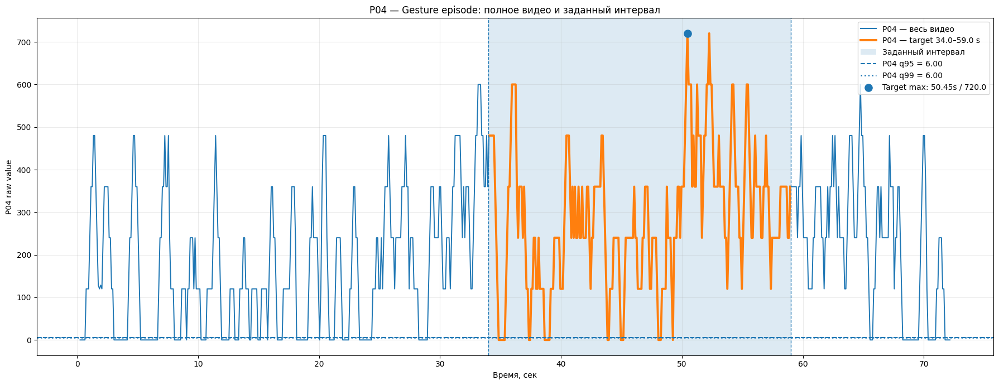


График сохранён:
/content/drive/MyDrive/Staz/3_P04_full.png


In [ ]:
# ЯЧЕЙКА 84
# P04 по всей длине нового видео.
# Целевой интервал выделен отдельно.
# P04 не пересчитывается и не изменяется — используется уже рассчитанный NEW_WINDOWS.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "NEW_WINDOWS" in globals(), "Нет NEW_WINDOWS. Сначала выполните ЯЧЕЙКУ 74."
assert "NEW_START" in globals(), "Нет NEW_START."
assert "NEW_END" in globals(), "Нет NEW_END."
assert "POPULATION_REFERENCE" in globals(), "Нет POPULATION_REFERENCE."

assert "P04" in NEW_WINDOWS.columns, "В NEW_WINDOWS отсутствует P04."
assert "timestamp" in NEW_WINDOWS.columns, "В NEW_WINDOWS отсутствует timestamp."

P04_FULL = NEW_WINDOWS[
    ["timestamp", "P04"]
].copy()

P04_FULL["timestamp"] = pd.to_numeric(
    P04_FULL["timestamp"],
    errors="coerce"
)

P04_FULL["P04"] = pd.to_numeric(
    P04_FULL["P04"],
    errors="coerce"
)

P04_FULL = P04_FULL.dropna(
    subset=["timestamp", "P04"]
).sort_values(
    "timestamp"
).reset_index(drop=True)

assert len(P04_FULL) > 0

P04_TARGET = P04_FULL[
    (P04_FULL["timestamp"] >= NEW_START) &
    (P04_FULL["timestamp"] <= NEW_END)
].copy()

assert len(P04_TARGET) > 0

P04_Q95 = float(
    POPULATION_REFERENCE["q95"]["P04"]
)

P04_Q99 = float(
    POPULATION_REFERENCE["q99"]["P04"]
)

# Максимум P04 внутри заданного интервала
P04_TARGET_MAX_IDX = P04_TARGET["P04"].idxmax()
P04_TARGET_MAX = P04_TARGET.loc[P04_TARGET_MAX_IDX]

# Максимум P04 по всему видео
P04_GLOBAL_MAX_IDX = P04_FULL["P04"].idxmax()
P04_GLOBAL_MAX = P04_FULL.loc[P04_GLOBAL_MAX_IDX]

# Статистика для проверки масштаба
target_mean = float(P04_TARGET["P04"].mean())
target_median = float(P04_TARGET["P04"].median())
target_max = float(P04_TARGET["P04"].max())

full_mean = float(P04_FULL["P04"].mean())
full_median = float(P04_FULL["P04"].median())
full_max = float(P04_FULL["P04"].max())

print("=== P04: ВСЁ ВИДЕО VS ЗАДАННЫЙ ИНТЕРВАЛ ===")
print(f"Видео: {NEW_VIDEO_NAME}")
print(f"Полная длина: {P04_FULL['timestamp'].min():.2f}–{P04_FULL['timestamp'].max():.2f} сек")
print(f"Целевой интервал: {NEW_START:.2f}–{NEW_END:.2f} сек")
print()

print("Frozen population:")
print(f"q95 P04 = {P04_Q95:.3f}")
print(f"q99 P04 = {P04_Q99:.3f}")
print()

print("Целевой интервал:")
print(f"Среднее P04: {target_mean:.3f}")
print(f"Медиана P04: {target_median:.3f}")
print(f"Максимум P04: {target_max:.3f}")
print(
    f"Максимум внутри интервала: "
    f"{float(P04_TARGET_MAX['timestamp']):.2f} сек"
)

print()
print("Всё видео:")
print(f"Среднее P04: {full_mean:.3f}")
print(f"Медиана P04: {full_median:.3f}")
print(f"Максимум P04: {full_max:.3f}")
print(
    f"Глобальный максимум: "
    f"{float(P04_GLOBAL_MAX['timestamp']):.2f} сек"
)

# ---------------------------------------------------------
# ГРАФИК
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(18, 7)
)

# Весь P04
ax.plot(
    P04_FULL["timestamp"],
    P04_FULL["P04"],
    linewidth=1.4,
    label="P04 — весь видео"
)

# Целевой интервал поверх основной кривой
ax.plot(
    P04_TARGET["timestamp"],
    P04_TARGET["P04"],
    linewidth=2.8,
    label=f"P04 — target {NEW_START:.1f}–{NEW_END:.1f} s"
)

# Фон целевого интервала
ax.axvspan(
    NEW_START,
    NEW_END,
    alpha=0.15,
    label="Заданный интервал"
)

# Frozen population thresholds
ax.axhline(
    P04_Q95,
    linestyle="--",
    linewidth=1.5,
    label=f"P04 q95 = {P04_Q95:.2f}"
)

ax.axhline(
    P04_Q99,
    linestyle=":",
    linewidth=1.8,
    label=f"P04 q99 = {P04_Q99:.2f}"
)

# Максимум P04 внутри target
ax.scatter(
    [float(P04_TARGET_MAX["timestamp"])],
    [float(P04_TARGET_MAX["P04"])],
    s=90,
    zorder=5,
    label=(
        f"Target max: "
        f"{float(P04_TARGET_MAX['timestamp']):.2f}s / "
        f"{float(P04_TARGET_MAX['P04']):.1f}"
    )
)

# Вертикальные границы target
ax.axvline(
    NEW_START,
    linestyle="--",
    linewidth=1.0
)

ax.axvline(
    NEW_END,
    linestyle="--",
    linewidth=1.0
)

ax.set_title(
    "P04 — Gesture episode: полное видео и заданный интервал"
)

ax.set_xlabel(
    "Время, сек"
)

ax.set_ylabel(
    "P04 raw value"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="upper right"
)

plt.tight_layout()

P04_GRAPH_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_P04_full.png"
)

plt.savefig(
    P04_GRAPH_PATH,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print()
print("График сохранён:")
print(P04_GRAPH_PATH)

Колонки UNKNOWN_VISUALS:
['timestamp', 'pattern', 'pattern_name', 'value', 'q95', 'excess_q95', 'anomaly_score', 'emotion', 'emotion_source', 'big5_context', 'image_path']

Выбранные эпизоды:


,timestamp,pattern,pattern_name,value,q95,excess_q95,anomaly_score,emotion,emotion_source,big5_context,image_path
0,36.05,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...
1,50.45,P04,Gesture episode,720.0,6.0,714.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...
2,52.45,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...
3,55.35,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...



Паттерны для графика: ['P04']


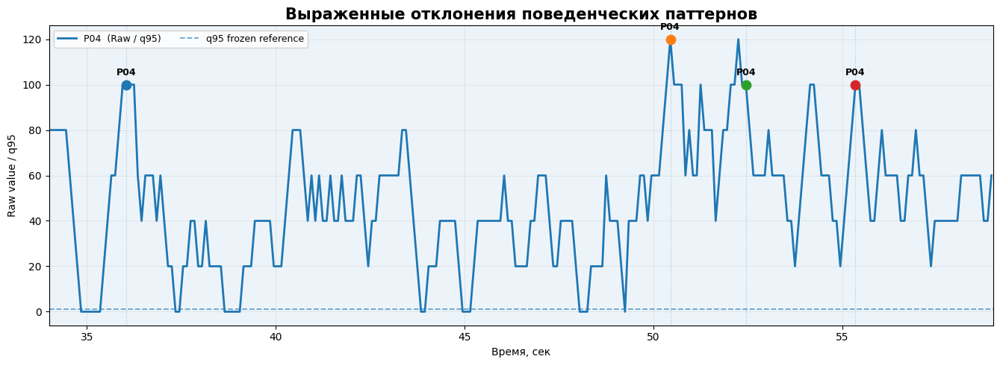


ГРАФИК ДЛЯ СЛАЙДА 7 СОХРАНЁН
/content/drive/MyDrive/Staz/3_slide7_deviations.png


In [ ]:
# ============================================================
# СЛАЙД 7 — ГРАФИК ОТКЛОНЕНИЙ В ЗАДАННОМ ИНТЕРВАЛЕ
#
# Используем ТОЛЬКО уже рассчитанные результаты:
#   UNKNOWN_TARGET
#   UNKNOWN_VISUALS
#   POPULATION_REFERENCE
#   NEW_START / NEW_END
#
# Видео заново НЕ обрабатывается.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "UNKNOWN_TARGET" in globals(), \
    "UNKNOWN_TARGET отсутствует. Выполните предыдущие ячейки notebook."

assert "UNKNOWN_VISUALS" in globals(), \
    "UNKNOWN_VISUALS отсутствует."

assert "POPULATION_REFERENCE" in globals(), \
    "POPULATION_REFERENCE отсутствует."

assert "NEW_START" in globals()
assert "NEW_END" in globals()

# ------------------------------------------------------------
# Проверяем реальные колонки вашего UNKNOWN_VISUALS
# ------------------------------------------------------------

print("Колонки UNKNOWN_VISUALS:")
print(UNKNOWN_VISUALS.columns.tolist())

print()
print("Выбранные эпизоды:")
display(UNKNOWN_VISUALS)

# ------------------------------------------------------------
# Паттерны, которые реально выбрала система
# ------------------------------------------------------------

selected_patterns = (
    UNKNOWN_VISUALS["pattern"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

print()
print("Паттерны для графика:", selected_patterns)

# ------------------------------------------------------------
# Создаём график
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13.5, 5.0)
)

for pattern in selected_patterns:

    if pattern not in UNKNOWN_TARGET.columns:
        print(
            f"Пропускаю {pattern}: "
            f"нет колонки в UNKNOWN_TARGET"
        )
        continue

    values = pd.to_numeric(
        UNKNOWN_TARGET[pattern],
        errors="coerce"
    )

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    # --------------------------------------------------------
    # Важный случай:
    # если q95 == 0, относительное значение value/q95
    # невозможно.
    # Тогда показываем raw value.
    # --------------------------------------------------------

    if q95 > 0:

        y = values / q95

        label = (
            f"{pattern}  "
            f"(Raw / q95)"
        )

    else:

        y = values

        label = (
            f"{pattern}  "
            f"(Raw value)"
        )

    ax.plot(
        UNKNOWN_TARGET["timestamp"],
        y,
        linewidth=2.0,
        label=label
    )

# ------------------------------------------------------------
# Выделяем уровень q95
# ------------------------------------------------------------

# Для паттернов с q95 > 0
# значение 1.0 соответствует q95.

positive_q95 = []

for pattern in selected_patterns:

    if pattern in POPULATION_REFERENCE["q95"]:

        q95 = float(
            POPULATION_REFERENCE["q95"][pattern]
        )

        if q95 > 0:
            positive_q95.append(pattern)

if positive_q95:

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1.3,
        alpha=0.65,
        label="q95 frozen reference"
    )

# ------------------------------------------------------------
# Выделяем заданный интервал
# ------------------------------------------------------------

ax.axvspan(
    NEW_START,
    NEW_END,
    alpha=0.08
)

# ------------------------------------------------------------
# Отмечаем реальные найденные эпизоды
#
# В UNKNOWN_VISUALS используется:
#   value
# а не pattern_value
# ------------------------------------------------------------

for _, row in UNKNOWN_VISUALS.iterrows():

    t = float(
        row["timestamp"]
    )

    pattern = str(
        row["pattern"]
    )

    value = float(
        row["value"]
    )

    if pattern not in POPULATION_REFERENCE["q95"]:
        continue

    q95 = float(
        POPULATION_REFERENCE["q95"][pattern]
    )

    if q95 > 0:
        y = value / q95
    else:
        y = value

    ax.scatter(
        [t],
        [y],
        s=80,
        zorder=5
    )

    ax.annotate(
        pattern,
        (t, y),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    # Вертикальная линия от найденного эпизода
    ax.axvline(
        t,
        linestyle=":",
        linewidth=0.9,
        alpha=0.35
    )

# ------------------------------------------------------------
# Оформление
# ------------------------------------------------------------

ax.set_title(
    "Выраженные отклонения поведенческих паттернов",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Время, сек"
)

ax.set_ylabel(
    "Raw value / q95"
)

ax.set_xlim(
    NEW_START,
    NEW_END
)

ax.grid(
    True,
    alpha=0.22
)

ax.legend(
    loc="upper left",
    ncol=2,
    fontsize=9
)

plt.tight_layout()

# ------------------------------------------------------------
# Сохраняем график
# ------------------------------------------------------------

SLIDE7_GRAPH_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_slide7_deviations.png"
)

plt.savefig(
    SLIDE7_GRAPH_PATH,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print()
print("==========================================")
print("ГРАФИК ДЛЯ СЛАЙДА 7 СОХРАНЁН")
print("==========================================")
print(SLIDE7_GRAPH_PATH)

Видео:
/content/drive/MyDrive/Staz/3.mp4

Выбранные системой эпизоды:


,timestamp,pattern,pattern_name,value,q95,excess_q95,anomaly_score,emotion,emotion_source,big5_context,image_path
0,36.05,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...
1,50.45,P04,Gesture episode,720.0,6.0,714.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...
2,52.45,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...
3,55.35,P04,Gesture episode,600.0,6.0,594.0,100.0,страх,spoken_at_anomaly,Extraversion context,/content/drive/MyDrive/Staz/visuals_3/anomaly_...


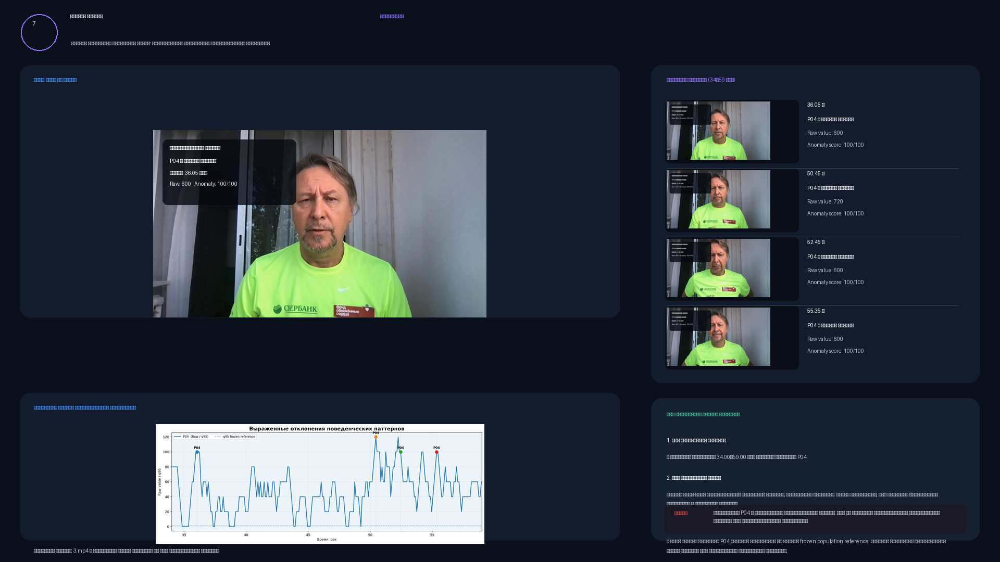


СЛАЙД 7 ГОТОВ
/content/drive/MyDrive/Staz/3_slide7_final.png


In [ ]:
# ============================================================
# СЛАЙД 7 — ФИНАЛЬНЫЙ ВАРИАНТ ДЛЯ 3.mp4
#
# ВАЖНО:
# - анализ видео НЕ запускается заново;
# - используются уже найденные UNKNOWN_VISUALS;
# - берём реальные timestamp из результата анализа;
# - чистый кадр извлекается непосредственно из NEW_VIDEO_PATH;
# - старый overlay из visuals_3 НЕ используется;
# - новый overlay НЕ закрывает лицо;
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd

from PIL import Image, ImageDraw, ImageFont


# ============================================================
# 1. ПРОВЕРКА РЕЗУЛЬТАТОВ
# ============================================================

assert "UNKNOWN_VISUALS" in globals(), \
    "Нет UNKNOWN_VISUALS."

assert "UNKNOWN_TARGET" in globals(), \
    "Нет UNKNOWN_TARGET."

assert "NEW_VIDEO_PATH" in globals(), \
    "Нет NEW_VIDEO_PATH."

assert "NEW_START" in globals()
assert "NEW_END" in globals()


# ------------------------------------------------------------
# Проверяем, что это именно новый эксперимент
# ------------------------------------------------------------

print("Видео:")
print(NEW_VIDEO_PATH)

print()
print("Выбранные системой эпизоды:")

display(
    UNKNOWN_VISUALS
)


# ============================================================
# 2. ПУТЬ К ГРАФИКУ
# ============================================================

SLIDE7_GRAPH_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_slide7_deviations.png"
)

assert os.path.exists(
    SLIDE7_GRAPH_PATH
), (
    "Не найден график:\n"
    + SLIDE7_GRAPH_PATH
)


# ============================================================
# 3. ТАБЛИЦА ЭПИЗОДОВ
# ============================================================

visual_rows = (
    UNKNOWN_VISUALS
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Берём только первые 4 реально выбранных системой эпизода
visual_rows = visual_rows.head(4).copy()

assert len(visual_rows) > 0


# ============================================================
# 4. НАЗВАНИЯ ПАТТЕРНОВ
# ============================================================

PATTERN_NAMES_RU = {

    "P01": "Частое моргание",

    "P02": "Кивок",

    "P03": "Движение головы",

    "P04": "Эпизод жестов",

    "P05": "Амплитуда жестов",

    "P06": "Рука около лица",

    "P07": "Повторные микродвижения",

    "P08": "Положение рук",

    "P09": "Изменение позы",

    "P10": "Подъём уголков губ",

    "P11": "Напряжение бровей / губ",

    "P12": "Направление взгляда",
}


# ============================================================
# 5. ШРИФТЫ
# ============================================================

def get_font(size, bold=False):

    if bold:

        candidates = [
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf",
        ]

    else:

        candidates = [
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        ]

    for path in candidates:

        if os.path.exists(path):

            return ImageFont.truetype(
                path,
                size
            )

    return ImageFont.load_default()


FONT_TITLE = get_font(
    40,
    True
)

FONT_SUBTITLE = get_font(
    20
)

FONT_SECTION = get_font(
    18,
    True
)

FONT_BODY = get_font(
    17
)

FONT_BODY_BOLD = get_font(
    18,
    True
)

FONT_SMALL = get_font(
    14
)

FONT_SMALL_BOLD = get_font(
    15,
    True
)

FONT_TINY = get_font(
    12
)


# ============================================================
# 6. ЦВЕТА
# ============================================================

BG = (9, 16, 28)

CARD = (18, 28, 44)

CARD2 = (21, 32, 49)

WHITE = (245, 247, 250)

MUTED = (178, 188, 204)

PURPLE = (145, 115, 255)

BLUE = (65, 145, 255)

GREEN = (80, 205, 160)

RED = (225, 75, 80)

LINE = (48, 62, 82)


# ============================================================
# 7. СЛАЙД
# ============================================================

W = 1920
H = 1080

canvas = Image.new(
    "RGB",
    (W, H),
    BG
)

draw = ImageDraw.Draw(
    canvas
)


# ============================================================
# 8. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def rounded_box(
    x1,
    y1,
    x2,
    y2,
    fill=CARD,
    radius=20
):

    draw.rounded_rectangle(
        (
            x1,
            y1,
            x2,
            y2
        ),
        radius=radius,
        fill=fill
    )


def fit_image(
    image,
    max_width,
    max_height
):

    image = image.copy()

    image.thumbnail(
        (
            int(max_width),
            int(max_height)
        ),
        Image.Resampling.LANCZOS
    )

    return image


def draw_wrapped(
    text,
    x,
    y,
    width,
    font,
    fill=MUTED,
    gap=6
):

    words = text.split()

    lines = []

    current = ""

    for word in words:

        candidate = (
            current
            + " "
            + word
        ).strip()

        bbox = draw.textbbox(
            (0, 0),
            candidate,
            font=font
        )

        if (
            bbox[2] - bbox[0]
            <= width
        ):

            current = candidate

        else:

            if current:
                lines.append(
                    current
                )

            current = word

    if current:
        lines.append(
            current
        )

    yy = y

    line_h = (
        draw.textbbox(
            (0, 0),
            "Ag",
            font=font
        )[3]
    )

    for line in lines:

        draw.text(
            (
                x,
                yy
            ),
            line,
            font=font,
            fill=fill
        )

        yy += (
            line_h
            + gap
        )

    return yy


# ============================================================
# 9. ЧИСТЫЙ СТОП-КАДР ИЗ ВИДЕО
#
# Здесь принципиальный момент:
# НЕ используем anomaly_*.jpg из visuals_3,
# потому что в них уже есть старый overlay.
# ============================================================

cap = cv2.VideoCapture(
    NEW_VIDEO_PATH
)

assert cap.isOpened(), (
    "Не удалось открыть:\n"
    + str(NEW_VIDEO_PATH)
)


def get_clean_frame(
    timestamp
):

    cap.set(
        cv2.CAP_PROP_POS_MSEC,
        float(timestamp) * 1000.0
    )

    ok, frame = cap.read()

    assert ok and frame is not None, (
        f"Не удалось получить кадр "
        f"на {timestamp:.2f} сек."
    )

    frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    return Image.fromarray(
        frame
    )


# ============================================================
# 10. НОВЫЙ OVERLAY
#
# Ставим СЛЕВА СВЕРХУ.
#
# На данном видео лицо находится примерно в центре,
# поэтому левый верхний угол свободен.
#
# Overlay небольшой и НЕ закрывает лицо.
# ============================================================

def add_overlay(
    image,
    row
):

    image = image.copy()

    d = ImageDraw.Draw(
        image,
        "RGBA"
    )

    w, h = image.size

    pattern = str(
        row["pattern"]
    )

    pattern_name = PATTERN_NAMES_RU.get(
        pattern,
        pattern
    )

    timestamp = float(
        row["timestamp"]
    )

    value = float(
        row.get(
            "value",
            row.get(
                "pattern_value",
                0
            )
        )
    )

    score = float(
        row.get(
            "anomaly_score",
            0
        )
    )


    # --------------------------------------------------------
    # Компактный overlay
    # --------------------------------------------------------

    box_w = min(
        410,
        int(w * 0.40)
    )

    box_h = 125

    margin = 18

    # ЛЕВЫЙ ВЕРХНИЙ УГОЛ
    x1 = margin
    y1 = margin

    x2 = x1 + box_w
    y2 = y1 + box_h


    # Полупрозрачный фон
    d.rounded_rectangle(
        (
            x1,
            y1,
            x2,
            y2
        ),
        radius=10,
        fill=(
            5,
            9,
            16,
            205
        )
    )


    # Тексты
    tx = x1 + 14

    ty = y1 + 10


    d.text(
        (
            tx,
            ty
        ),
        "АНАЛИЗИРУЕМЫЙ ЭПИЗОД",
        font=FONT_SMALL_BOLD,
        fill=(
            255,
            255,
            255,
            255
        )
    )

    ty += 25

    d.text(
        (
            tx,
            ty
        ),
        f"{pattern} — {pattern_name}",
        font=FONT_SMALL_BOLD,
        fill=(
            255,
            255,
            255,
            255
        )
    )

    ty += 23

    d.text(
        (
            tx,
            ty
        ),
        f"Время: {timestamp:.2f} сек",
        font=FONT_SMALL,
        fill=(
            220,
            225,
            235,
            255
        )
    )

    ty += 21

    d.text(
        (
            tx,
            ty
        ),
        (
            f"Raw: {value:.0f}   "
            f"Anomaly: {score:.0f}/100"
        ),
        font=FONT_SMALL,
        fill=(
            220,
            225,
            235,
            255
        )
    )


    return image


# ============================================================
# 11. ПОЛУЧАЕМ ЧИСТЫЕ КАДРЫ
# ============================================================

clean_frames = []

for _, row in visual_rows.iterrows():

    timestamp = float(
        row["timestamp"]
    )

    frame = get_clean_frame(
        timestamp
    )

    frame = add_overlay(
        frame,
        row
    )

    clean_frames.append(
        frame
    )


cap.release()


assert len(
    clean_frames
) == len(
    visual_rows
)


# ============================================================
# 12. HEADER
# ============================================================

draw.ellipse(
    (
        40,
        27,
        110,
        97
    ),
    outline=PURPLE,
    width=2
)

draw.text(
    (
        63,
        39
    ),
    "7",
    font=FONT_BODY_BOLD,
    fill=WHITE
)


draw.text(
    (
        135,
        25
    ),
    "ПРИМЕР ВЫВОДА",
    font=FONT_TITLE,
    fill=WHITE
)

draw.text(
    (
        730,
        25
    ),
    "ПРОТОТИПА",
    font=FONT_TITLE,
    fill=PURPLE
)


draw.text(
    (
        137,
        77
    ),
    (
        "Анализ заданного интервала видео: "
        "обнаруженные отклонения поведенческих паттернов"
    ),
    font=FONT_SUBTITLE,
    fill=MUTED
)


# ============================================================
# 13. ПАНЕЛИ
# ============================================================

# Большой кадр
rounded_box(
    38,
    125,
    1190,
    610
)

# Справа — четыре кадра
rounded_box(
    1250,
    125,
    1880,
    735
)

# График
rounded_box(
    38,
    755,
    1190,
    1038
)

# Интерпретация
rounded_box(
    1250,
    765,
    1880,
    1038,
    CARD2
)


# ============================================================
# 14. БОЛЬШОЙ КАДР
# ============================================================

draw.text(
    (
        65,
        147
    ),
    "СТОП-КАДР ИЗ ВИДЕО",
    font=FONT_SECTION,
    fill=BLUE
)


main_img = fit_image(
    clean_frames[0],
    1125,
    520
)


main_x = (
    614
    - main_img.width // 2
)

main_y = (
    430
    - main_img.height // 2
)


canvas.paste(
    main_img,
    (
        main_x,
        main_y
    )
)


# ============================================================
# 15. СПРАВА — РЕАЛЬНЫЕ КАДРЫ
# ============================================================

draw.text(
    (
        1280,
        147
    ),
    (
        f"КЛЮЧЕВЫЕ ЭПИЗОДЫ "
        f"({NEW_START:.0f}–{NEW_END:.0f} СЕК)"
    ),
    font=FONT_SECTION,
    fill=PURPLE
)


thumb_y = 195

THUMB_W = 250
THUMB_H = 112


for i, (_, row) in enumerate(
    visual_rows.iterrows()
):

    if i >= 4:
        break


    thumb = fit_image(
        clean_frames[i],
        THUMB_W,
        THUMB_H
    )


    # рамка миниатюры
    draw.rounded_rectangle(
        (
            1277,
            thumb_y - 3,
            1277 + THUMB_W + 6,
            thumb_y + THUMB_H + 6
        ),
        radius=8,
        fill=(8, 13, 22)
    )


    canvas.paste(
        thumb,
        (
            1280,
            thumb_y
        )
    )


    timestamp = float(
        row["timestamp"]
    )

    pattern = str(
        row["pattern"]
    )

    pattern_name = PATTERN_NAMES_RU.get(
        pattern,
        pattern
    )

    value = float(
        row.get(
            "value",
            row.get(
                "pattern_value",
                0
            )
        )
    )

    score = float(
        row.get(
            "anomaly_score",
            0
        )
    )


    text_x = 1550


    draw.text(
        (
            text_x,
            thumb_y
        ),
        f"{timestamp:.2f} с",
        font=FONT_BODY_BOLD,
        fill=WHITE
    )


    draw.text(
        (
            text_x,
            thumb_y + 28
        ),
        f"{pattern} — {pattern_name}",
        font=FONT_SMALL_BOLD,
        fill=WHITE
    )


    draw.text(
        (
            text_x,
            thumb_y + 54
        ),
        f"Raw value: {value:.0f}",
        font=FONT_SMALL,
        fill=MUTED
    )


    draw.text(
        (
            text_x,
            thumb_y + 77
        ),
        f"Anomaly score: {score:.0f}/100",
        font=FONT_SMALL,
        fill=MUTED
    )


    if i < 3:

        draw.line(
            (
                1280,
                thumb_y + 128,
                1840,
                thumb_y + 128
            ),
            fill=LINE,
            width=1
        )


    thumb_y += 132


# ============================================================
# 16. ГРАФИК
# ============================================================

draw.text(
    (
        65,
        777
    ),
    "ВРЕМЕННОЙ ГРАФИК ПОВЕДЕНЧЕСКИХ ОТКЛОНЕНИЙ",
    font=FONT_SECTION,
    fill=BLUE
)


graph_img = Image.open(
    SLIDE7_GRAPH_PATH
).convert("RGB")


graph_img = fit_image(
    graph_img,
    1125,
    230
)


gx = (
    614
    - graph_img.width // 2
)

gy = 815


canvas.paste(
    graph_img,
    (
        gx,
        gy
    )
)


# ============================================================
# 17. ИНТЕРПРЕТАЦИЯ
# ============================================================

draw.text(
    (
        1280,
        790
    ),
    "ЧТО ПОКАЗЫВАЕТ ДАННЫЙ ФРАГМЕНТ",
    font=FONT_SECTION,
    fill=GREEN
)


patterns = (
    visual_rows["pattern"]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

pattern_string = ", ".join(
    patterns
)


y = 840


draw.text(
    (
        1280,
        y
    ),
    "1. Что обнаружила система",
    font=FONT_BODY_BOLD,
    fill=WHITE
)

y += 32


y = draw_wrapped(
    (
        f"В заданном интервале "
        f"{NEW_START:.2f}–{NEW_END:.2f} сек "
        f"система выделила {pattern_string}."
    ),
    1280,
    y,
    555,
    FONT_BODY,
    MUTED
)


y += 22


draw.text(
    (
        1280,
        y
    ),
    "2. Что показывают кадры",
    font=FONT_BODY_BOLD,
    fill=WHITE
)

y += 32


y = draw_wrapped(
    (
        "Каждый стоп-кадр соответствует "
        "реальному эпизоду, выбранному системой. "
        "Кадры показывают, как выглядит "
        "наблюдаемое поведение в выбранные моменты."
    ),
    1280,
    y,
    555,
    FONT_BODY,
    MUTED
)


y += 22


draw.text(
    (
        1280,
        y
    ),
    "3. Что можно заключить",
    font=FONT_BODY_BOLD,
    fill=WHITE
)

y += 32


y = draw_wrapped(
    (
        "В этих точках значение P04 заметно "
        "отличается от уровня frozen population "
        "reference. Система позволяет "
        "локализовать такие моменты "
        "для последующей визуальной проверки."
    ),
    1280,
    y,
    555,
    FONT_BODY,
    MUTED
)


# ============================================================
# 18. ВАЖНОЕ ОГРАНИЧЕНИЕ
# ============================================================

warning_y = 970


draw.rounded_rectangle(
    (
        1275,
        warning_y,
        1855,
        1025
    ),
    radius=10,
    fill=(26, 24, 34)
)


draw.text(
    (
        1295,
        warning_y + 10
    ),
    "ВАЖНО",
    font=FONT_SMALL_BOLD,
    fill=RED
)


draw_wrapped(
    (
        "Отклонение P04 — наблюдаемый "
        "поведенческий сигнал; оно не является "
        "автоматически определённой эмоцией "
        "или психологическим состоянием."
    ),
    1370,
    warning_y + 9,
    465,
    FONT_SMALL,
    MUTED,
    4
)


# ============================================================
# 19. FOOTER
# ============================================================

draw.text(
    (
        65,
        1052
    ),
    (
        "Источник кадров: 3.mp4 • "
        "временные точки получены из уже выполненного анализа"
    ),
    font=FONT_TINY,
    fill=MUTED
)


# ============================================================
# 20. СОХРАНЕНИЕ
# ============================================================

SLIDE7_FINAL_PATH = os.path.join(
    STAZ_FOLDER,
    f"{NEW_SAFE_NAME}_slide7_final.png"
)


canvas.save(
    SLIDE7_FINAL_PATH,
    quality=96
)


display(
    canvas
)


print()
print("==========================================")
print("СЛАЙД 7 ГОТОВ")
print("==========================================")
print(
    SLIDE7_FINAL_PATH
)

Исходное видео:
/content/drive/MyDrive/Staz/3.mp4

FPS: 30.00
Кадров: 2175
Длительность: 72.50 сек

Найденные возможные графики:
   /content/drive/MyDrive/Staz/video_slide7_deviations.png
   /content/drive/MyDrive/Staz/video_slide7_example.png
   /content/drive/MyDrive/Staz/video_slide7_final.png
   /content/drive/MyDrive/Staz/3_slide7_deviations.png
   /content/drive/MyDrive/Staz/3_slide7_example.png
   /content/drive/MyDrive/Staz/3_slide7_final.png
   /content/drive/MyDrive/Staz/test20260817_P04_full.png
   /content/drive/MyDrive/Staz/video_P04_full.png
   /content/drive/MyDrive/Staz/3_P04_full.png

ЧИСТЫЕ КАДРЫ ДЛЯ СЛАЙДА 7
36.05 сек
/content/drive/MyDrive/Staz/visuals_3/slide7_clean_frames/slide7_01_36.05s_clean.jpg


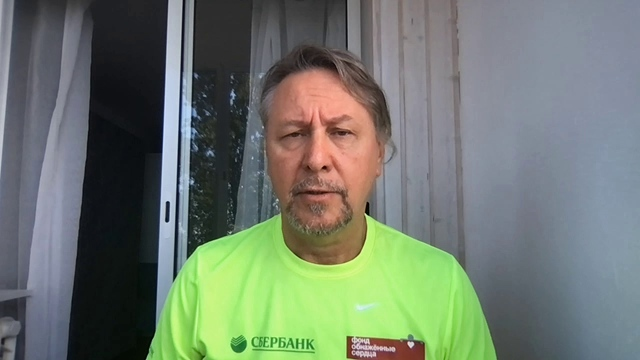

50.45 сек
/content/drive/MyDrive/Staz/visuals_3/slide7_clean_frames/slide7_02_50.45s_clean.jpg


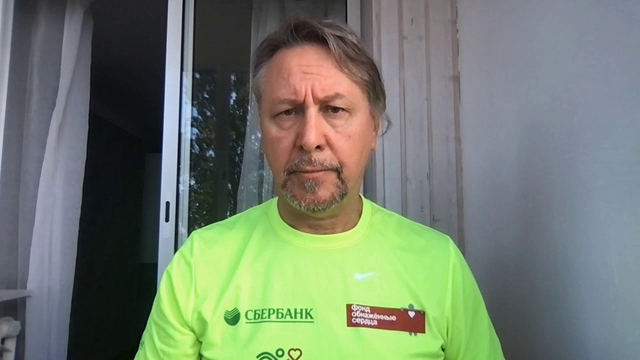

52.45 сек
/content/drive/MyDrive/Staz/visuals_3/slide7_clean_frames/slide7_03_52.45s_clean.jpg


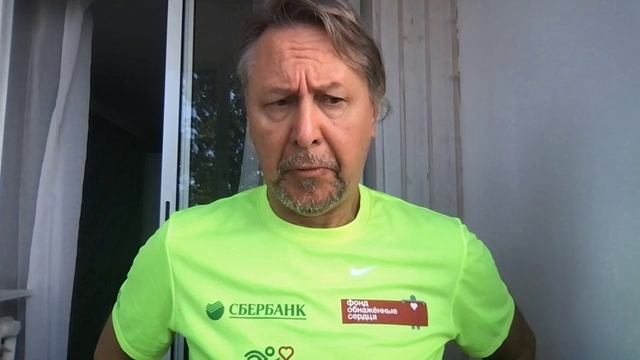

55.35 сек
/content/drive/MyDrive/Staz/visuals_3/slide7_clean_frames/slide7_04_55.35s_clean.jpg


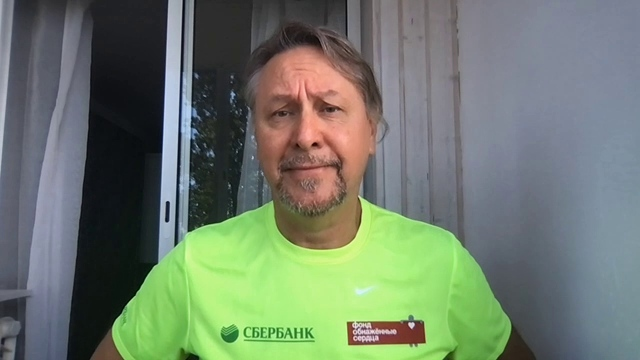


ГОТОВО
SLIDE7_CLEAN_FRAMES = 4
SLIDE7_GRAPH_CANDIDATES = 9


In [ ]:
# ============================================================
# ЧИСТЫЕ КАДРЫ ДЛЯ СЛАЙДА 7 — 3.mp4
#
# НИЧЕГО НЕ АНАЛИЗИРУЕТ ЗАНОВО.
#
# Берём уже найденные системой точки:
#   36.05
#   50.45
#   52.45
#   55.35
#
# Кадры извлекаются напрямую из исходного 3.mp4,
# поэтому старого ANOMALY overlay на них НЕ будет.
# ============================================================

import os
import cv2
import glob
from PIL import Image
from IPython.display import display

# ============================================================
# 1. ИСХОДНОЕ ВИДЕО
# ============================================================

VIDEO_PATH = "/content/drive/MyDrive/Staz/3.mp4"

assert os.path.exists(VIDEO_PATH), (
    f"Не найдено видео:\n{VIDEO_PATH}"
)

print("Исходное видео:")
print(VIDEO_PATH)


# ============================================================
# 2. ТОЧКИ, КОТОРЫЕ УЖЕ НАШЛА СИСТЕМА
# ============================================================

EPISODES = [
    36.05,
    50.45,
    52.45,
    55.35,
]


# ============================================================
# 3. ПАПКА ДЛЯ ЧИСТЫХ КАДРОВ
# ============================================================

CLEAN_DIR = (
    "/content/drive/MyDrive/Staz/"
    "visuals_3/slide7_clean_frames"
)

os.makedirs(
    CLEAN_DIR,
    exist_ok=True
)


# ============================================================
# 4. ОТКРЫВАЕМ ВИДЕО
# ============================================================

cap = cv2.VideoCapture(
    VIDEO_PATH
)

assert cap.isOpened(), (
    "Не удалось открыть 3.mp4"
)

fps = cap.get(
    cv2.CAP_PROP_FPS
)

frame_count = cap.get(
    cv2.CAP_PROP_FRAME_COUNT
)

duration = (
    frame_count / fps
    if fps > 0
    else 0
)

print()
print(f"FPS: {fps:.2f}")
print(f"Кадров: {int(frame_count)}")
print(f"Длительность: {duration:.2f} сек")


# ============================================================
# 5. ИЗВЛЕКАЕМ ЧИСТЫЕ КАДРЫ
# ============================================================

saved = []

for i, timestamp in enumerate(
    EPISODES,
    start=1
):

    # Переходим непосредственно к нужному времени
    cap.set(
        cv2.CAP_PROP_POS_MSEC,
        timestamp * 1000
    )

    ok, frame = cap.read()

    assert ok and frame is not None, (
        f"Не удалось получить кадр "
        f"на {timestamp:.2f} сек."
    )

    # OpenCV BGR -> RGB
    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    image = Image.fromarray(
        frame_rgb
    )

    # --------------------------------------------------------
    # НИКАКОГО OVERLAY ЗДЕСЬ НЕТ
    # --------------------------------------------------------

    output_path = os.path.join(
        CLEAN_DIR,
        f"slide7_{i:02d}_{timestamp:.2f}s_clean.jpg"
    )

    image.save(
        output_path,
        quality=97
    )

    saved.append(
        {
            "time": timestamp,
            "path": output_path
        }
    )


cap.release()


# ============================================================
# 6. ИЩЕМ ГРАФИК 3.mp4
# ============================================================

search_roots = [
    "/content/drive/MyDrive/Staz/visuals_3",
    "/content/drive/MyDrive/Staz",
]

graph_candidates = []

for root in search_roots:

    if not os.path.exists(root):
        continue

    for pattern in [
        "*slide7*.png",
        "*deviations*.png",
        "*deviation*.png",
        "*P04*.png",
    ]:

        graph_candidates.extend(
            glob.glob(
                os.path.join(
                    root,
                    "**",
                    pattern
                ),
                recursive=True
            )
        )


# Убираем дубликаты
graph_candidates = list(
    dict.fromkeys(
        graph_candidates
    )
)


print()
print("Найденные возможные графики:")

if graph_candidates:

    for p in graph_candidates:
        print("  ", p)

else:

    print(
        "  График автоматически не найден."
    )


# ============================================================
# 7. ПОКАЗЫВАЕМ ЧИСТЫЕ КАДРЫ
# ============================================================

print()
print("==========================================")
print("ЧИСТЫЕ КАДРЫ ДЛЯ СЛАЙДА 7")
print("==========================================")

for item in saved:

    print(
        f"{item['time']:.2f} сек"
    )

    print(
        item["path"]
    )

    display(
        Image.open(
            item["path"]
        )
    )


# ============================================================
# 8. Сохраняем переменные для следующей ячейки
# ============================================================

SLIDE7_CLEAN_FRAMES = [
    item["path"]
    for item in saved
]

SLIDE7_GRAPH_CANDIDATES = (
    graph_candidates
)

print()
print("==========================================")
print("ГОТОВО")
print("==========================================")

print(
    "SLIDE7_CLEAN_FRAMES =",
    len(SLIDE7_CLEAN_FRAMES)
)

print(
    "SLIDE7_GRAPH_CANDIDATES =",
    len(SLIDE7_GRAPH_CANDIDATES)
)